In [1]:
# import utils

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import tifffile
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from scipy.stats import norm, skewnorm

import os
import re

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import utils
import os

input_directory = r"E:\Users\Sebastian_van_Dijk\TEMP"
organoids = ["TL01", "TL09","TL10","TL11","TL12","TL31"]
dirs = []
for organoid in organoids:
    dir_path = os.path.join(input_directory, organoid, "properties")
    dirs.append(dir_path)

all_df = pd.DataFrame()
for organoid, directory in zip(organoids, dirs):
    for file in os.listdir(directory):
        if file.endswith(".txt"):
            df = pd.read_csv(os.path.join(directory, file), sep="\t")
            if organoid == "TL01":
                df["type"] = "WT"
            elif organoid == "TL26":
                df["type"] = "CRC"
            else:
                df["type"] = "mixed"
            df["organoid"] = organoid
            all_df = pd.concat([all_df, df], ignore_index=True)

all_df["ratioWT_CRC"] = all_df["raw_WT"] / all_df["raw_CRC"]



Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.6 
platform:       	win32 
python version: 	3.11.13 
torch version:  	2.7.1+cu128! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 


utils package loaded successfully


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'E:\\Users\\Sebastian_van_Dijk\\TEMP\\TL01\\properties'

In [15]:
df

,label,z,y,x,bounding_box,volume,area_WT,raw_WT,area_CRC,raw_CRC,Phenotype,type,organoid
0,1,1.592878,31.710720,145.026432,"(0, 17, 121, 5, 50, 172)",2724.0,2724.0,107.593245,2724.0,139.082232,CRC,mixed,TL31
1,2,0.502924,66.688304,178.958480,"(0, 51, 162, 2, 84, 198)",1710.0,1710.0,107.840351,1710.0,147.695322,CRC,mixed,TL31
2,3,0.428212,75.352645,115.767003,"(0, 60, 105, 2, 90, 127)",794.0,794.0,108.108312,794.0,129.226700,CRC,mixed,TL31
3,4,0.500000,87.396175,198.342896,"(0, 74, 188, 2, 102, 209)",732.0,732.0,108.256831,732.0,148.155738,CRC,mixed,TL31
4,5,0.365912,100.827175,150.847437,"(0, 85, 141, 2, 117, 162)",839.0,839.0,108.052443,839.0,129.520858,CRC,mixed,TL31
...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,306,22.197531,202.190329,213.412551,"(21, 189, 203, 24, 216, 223)",972.0,972.0,107.884774,972.0,114.017490,CRC,mixed,TL31
306,307,21.000000,211.465909,138.431818,"(21, 204, 132, 22, 221, 146)",176.0,176.0,108.034091,176.0,117.556818,CRC,mixed,TL31
307,308,21.515982,220.223744,237.465753,"(21, 214, 232, 23, 227, 244)",219.0,219.0,107.214612,219.0,121.447489,CRC,mixed,TL31
308,309,22.165574,229.445902,208.193443,"(21, 221, 198, 24, 238, 218)",610.0,610.0,107.824590,610.0,117.613115,CRC,mixed,TL31


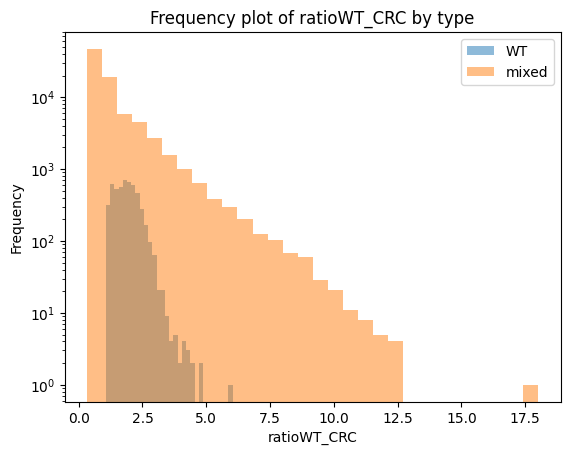

In [13]:
for t in all_df["type"].unique():
    subset = all_df[all_df["type"] == t]
    plt.hist(subset["ratioWT_CRC"], bins=30, alpha=0.5, label=t)

plt.xlabel("ratioWT_CRC")
plt.ylabel("Frequency")
plt.title("Frequency plot of ratioWT_CRC by type")
plt.yscale("log")  # Make y-axis logarithmic
plt.legend()
plt.show()

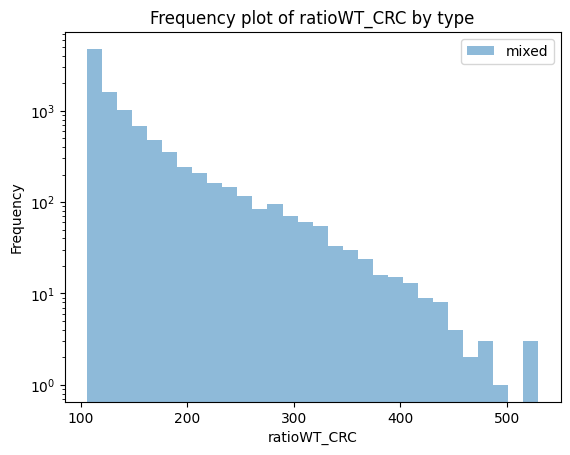

In [18]:
subset = all_df[all_df["organoid"] == "TL11"]
plt.hist(subset["raw_WT"], bins=30, alpha=0.5, label=t)

plt.xlabel("ratioWT_CRC")
plt.ylabel("Frequency")
plt.title("Frequency plot of ratioWT_CRC by type")
plt.yscale("log")  # Make y-axis logarithmic
plt.legend()
plt.show()

In [6]:
import tifffile
from scipy import ndimage
import os

input_directory = r"C:\Users\6331823\Desktop\Train model whole organoid segmentation"
for organoid in os.listdir(input_directory):
    if organoid.endswith(".tif"):
        original = os.path.join(input_directory, organoid)
        original = tifffile.imread(original)
        resize_factors = (200 / original.shape[0] , 200 / original.shape[1])
        XY = ndimage.zoom(original, resize_factors, order=0)
        XY = ndimage.gaussian_filter(XY, sigma=(2, 2))
        tifffile.imwrite(
            os.path.join(input_directory, "smoothed_XY", organoid),
            XY,
        )

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
import pandas as pd

# Your ratio data
ratios = np.array([
    0.843218545, 0.844873502, 1.668776133, 0.862274271, 0.809498911,
    0.737159537, 0.845353398, 0.775946006, 0.674322713, 0.649706156,
    1.112518394, 0.81620095, 1.705073941, 0.753885069, 0.77938578,
    0.793327383, 1.982575108, 0.737841096, 0.704847086, 0.701849541,
    0.847186436, 0.688447415, 0.695395085, 0.757498956, 1.13937129,
    2.126445938, 0.866231304, 2.3231805, 0.77348789, 0.761823995,
    0.773913337, 0.693962019, 0.760776805, 1.720121879, 0.753178687,
    1.351161179, 1.430329714, 0.846986397, 0.735142857, 1.350898729,
    1.972850816, 1.428831122, 1.641974047, 1.413566286, 0.810866686,
    0.837289092, 1.257008415, 0.869855683, 0.873884474, 0.865940501,
    0.908263305, 1.440489263, 1.289546879, 0.784626411, 0.888552437,
    0.822779145, 0.84824339
]).reshape(-1, 1)  # reshape for sklearn

for frame in range(14):
    ratios = pd.read_csv(f"E:\\Users\\Sebastian_van_Dijk\\Data_Anna\\s65\\properties\\Frame-{frame}_props.csv")
    ratios = ratios["wt_crc_ratio"].to_numpy().reshape(-1, 1)

    # Run KMeans with 2 clusters
    kmeans = KMeans(n_clusters=2, random_state=0)
    labels = kmeans.fit_predict(ratios)
    centers = kmeans.cluster_centers_.flatten()

    # Sort cluster centers to get lower and upper cluster means
    centers.sort()
    cutoff = (centers[0] + centers[1]) / 2

    print(f"frame: {frame}")
    print("Cluster centers:", centers)
    print("Estimated cutoff value:", cutoff)
    #cutoff = 1

    print(f"CRC cells: {np.sum(ratios.flatten() < cutoff)}")
    print(f"WT cells: {np.sum(ratios.flatten() >= cutoff)}\n")


frame: 0
Cluster centers: [0.80490334 1.5987637 ]
Estimated cutoff value: 1.201833517612973
CRC cells: 38
WT cells: 17

frame: 1
Cluster centers: [0.81025005 1.59913951]
Estimated cutoff value: 1.2046947819564797
CRC cells: 56
WT cells: 18

frame: 2
Cluster centers: [0.8431325  1.75521769]
Estimated cutoff value: 1.2991750972770781
CRC cells: 83
WT cells: 17

frame: 3
Cluster centers: [0.84671004 1.62655394]
Estimated cutoff value: 1.2366319891124362
CRC cells: 112
WT cells: 20

frame: 4
Cluster centers: [0.86165762 1.63344464]
Estimated cutoff value: 1.247551133147449
CRC cells: 159
WT cells: 22

frame: 5
Cluster centers: [0.85421118 1.63587196]
Estimated cutoff value: 1.245041572590544
CRC cells: 205
WT cells: 24

frame: 6
Cluster centers: [0.85839238 1.73696882]
Estimated cutoff value: 1.2976806005872792
CRC cells: 259
WT cells: 23

frame: 7
Cluster centers: [0.84025978 1.52140253]
Estimated cutoff value: 1.1808311579876176
CRC cells: 319
WT cells: 34

frame: 8
Cluster centers: [0.8

In [11]:

input_directory = r"C:\Users\6331823\Local SSD\s65"

segmented = os.path.join(input_directory, "segmented")
cropped = os.path.join(input_directory, "cropped")
WT_channel = 0
CRC_channel = 1

for file in range(15):
    segmented_stack = tifffile.imread(os.path.join(segmented, f"Frame-{file}_masks.tif"))
    frame = tifffile.imread(os.path.join(cropped, f"Frame-{file}.tif"))

    # Get properties of the masked nuclei, such as volume and location of every cell
    props = utils.properties_mask(segmented_stack)

    # Get properties of every cell in the WT and CRC channels at the masked nuclei locations
    frame_WT = frame[WT_channel, :, :, :]
    df_wt = utils.properties_channel(segmented_stack, frame_WT, "WT")

    frame_CRC = frame[CRC_channel, :, :, :]
    df_crc = utils.properties_channel(segmented_stack, frame_CRC, "CRC")

    # Combine the information of nuclei, WT, and CRC channel into a single dataframe
    df_final = props.merge(df_wt, on="label").merge(df_crc, on="label")
    df_final['wt_crc_ratio'] = df_final.apply(
        lambda row: row['raw_WT'] / row['raw_CRC'] if row['raw_CRC'] != 0 else 5,
        axis=1
    )

    ratios = df_final["wt_crc_ratio"].to_numpy().reshape(-1, 1)

    # Run KMeans with 2 clusters
    kmeans = KMeans(n_clusters=2, random_state=0)
    labels = kmeans.fit_predict(ratios)
    centers = kmeans.cluster_centers_.flatten()

    # Sort cluster centers to get lower and upper cluster means
    centers.sort()
    cutoff = (centers[0] + centers[1]) / 2

    print(f"frame: {file}")
    print("Cluster centers:", centers)
    print("Estimated cutoff value:", cutoff)
    # cutoff = 1

    print(f"CRC cells: {np.sum(ratios.flatten() < cutoff)}")
    print(f"WT cells: {np.sum(ratios.flatten() >= cutoff)}\n")

frame: 0
Cluster centers: [0.80490334 1.5987637 ]
Estimated cutoff value: 1.201833517612973
CRC cells: 38
WT cells: 17

frame: 1
Cluster centers: [0.81025005 1.59913951]
Estimated cutoff value: 1.2046947819564797
CRC cells: 56
WT cells: 18

frame: 2
Cluster centers: [0.8431325  1.75521769]
Estimated cutoff value: 1.2991750972770781
CRC cells: 83
WT cells: 17

frame: 3
Cluster centers: [0.84671004 1.62655394]
Estimated cutoff value: 1.2366319891124364
CRC cells: 112
WT cells: 20

frame: 4
Cluster centers: [0.86165762 1.63344464]
Estimated cutoff value: 1.247551133147449
CRC cells: 159
WT cells: 22

frame: 5
Cluster centers: [0.85421118 1.63587196]
Estimated cutoff value: 1.245041572590544
CRC cells: 205
WT cells: 24

frame: 6
Cluster centers: [0.85839238 1.73696882]
Estimated cutoff value: 1.2976806005872792
CRC cells: 259
WT cells: 23

frame: 7
Cluster centers: [0.84025978 1.52140253]
Estimated cutoff value: 1.1808311579876176
CRC cells: 319
WT cells: 34

frame: 8
Cluster centers: [0.8

In [8]:
def get_properties(input_directory):
    segmented = os.path.join(input_directory, "segmented")
    cropped = os.path.join(input_directory, "cropped")
    WT_channel = 0
    CRC_channel = 1
    frame_data = []

    for file in range(len(os.listdir(segmented))):
        segmented_stack = tifffile.imread(
            os.path.join(segmented, f"Frame-{file}_masks.tif")
        )

        frame = tifffile.imread(os.path.join(cropped, f"Frame-{file}.tif"))

        # Get properties of the masked nuclei, such as volume and location of every cell
        props = utils.properties_mask(segmented_stack)

        # Get properties of every cell in the WT and CRC channels at the masked nuclei locations
        frame_WT = frame[WT_channel, :, :, :]

        median_value = np.median(frame_WT[frame_WT > 0])
        offset_WT = frame_WT.astype(np.float32) - median_value
        offset_WT[offset_WT < 0] = 0  # Clip negative values
        offset_WT = np.clip(offset_WT, 0, 255).astype(np.uint16)
        print(segmented_stack.shape, offset_WT.shape)
        df_wt = utils.properties_channel(segmented_stack, offset_WT, "WT")
        #df_wt = utils.properties_channel(segmented_stack, frame_WT, "WT")

        frame_CRC = frame[CRC_channel, :, :, :]
        median_value = np.median(frame_CRC[frame_CRC > 0])
        offset_CRC = frame_CRC.astype(np.float32) - median_value
        offset_CRC[offset_CRC < 0] = 0  # Clip negative values
        offset_CRC = np.clip(offset_CRC, 0, 255).astype(np.uint16)
        df_crc = utils.properties_channel(segmented_stack, offset_CRC, "CRC")
        #df_crc = utils.properties_channel(segmented_stack, frame_CRC, "CRC")

        # Combine the information of nuclei, WT, and CRC channel into a single dataframe
        df_final = props.merge(df_wt, on="label").merge(df_crc, on="label")
        df_final["file"] = file
        df_final["wt_crc_ratio"] = df_final.apply(
            lambda row: (row["raw_WT"]+1e-6) / (row["raw_CRC"]+1e-6), axis=1
        )
        frame_data.append(df_final)

    properties = pd.concat(frame_data, ignore_index=True)
    return properties

# test = r"C:\Users\6331823\Local SSD\Data_Anna\crc\EXpansion_CRC_1"
# test_properties = get_properties(test)
# properties["wt_crc_ratio"].to_numpy().reshape(-1, 1)

(30, 154, 154) (30, 154, 154)
(24, 172, 176) (24, 172, 176)
(24, 199, 196) (24, 199, 196)
(29, 220, 219) (29, 220, 219)
(30, 251, 242) (30, 251, 242)
(32, 270, 270) (32, 270, 270)
(36, 309, 308) (36, 309, 308)
(38, 341, 340) (38, 341, 340)
(44, 388, 384) (44, 388, 384)
(51, 422, 426) (51, 422, 426)
(31, 457, 462) (31, 457, 462)
(50, 470, 470) (50, 470, 470)
(34, 415, 420) (34, 415, 420)
(38, 369, 361) (38, 369, 361)
(16, 99, 90) (16, 99, 90)
(17, 111, 104) (17, 111, 104)
(20, 117, 116) (20, 117, 116)
(19, 134, 135) (19, 134, 135)
(22, 155, 154) (22, 155, 154)
(22, 172, 170) (22, 172, 170)
(25, 195, 192) (25, 195, 192)
(28, 218, 216) (28, 218, 216)
(28, 244, 241) (28, 244, 241)
(31, 277, 268) (31, 277, 268)
(34, 304, 298) (34, 304, 298)
(37, 325, 325) (37, 325, 325)
(40, 360, 360) (40, 360, 360)
(54, 390, 389) (54, 390, 389)
(20, 124, 124) (20, 124, 124)
(22, 143, 138) (22, 143, 138)
(20, 165, 160) (20, 165, 160)
(23, 186, 183) (23, 186, 183)
(26, 209, 206) (26, 209, 206)
(28, 236, 231)

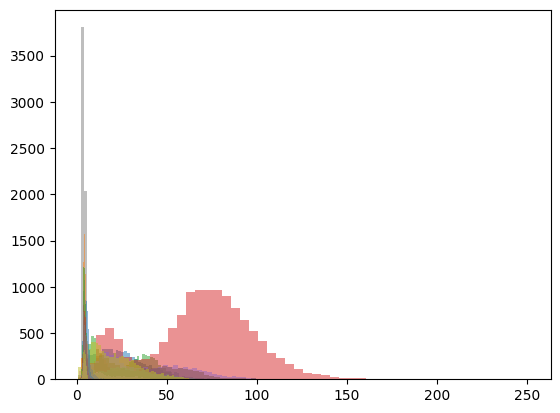

In [10]:
dir = r"C:\Users\6331823\Local SSD\Data_Anna\Exp137"
samples = [file for file in os.listdir(dir) if os.path.isdir(os.path.join(dir, file))]
all_data = []

for sample in samples:
    sample_path = os.path.join(dir, sample)
    properties = get_properties(sample_path)
    df = pd.DataFrame({
        "Type": sample.split("\\")[0],
        "Sample": sample.split("\\")[-1],
        "wt_crc_ratio": [properties["wt_crc_ratio"].to_numpy().reshape(-1, 1)],
    })
    plt.hist(properties["raw_CRC"], bins=50, alpha=0.5, label=sample)
    all_data.append(df)

all_data = pd.concat(all_data, ignore_index=True)



In [3]:
df

,frame,label,z_pixel,y_pixel,x_pixel,bounding_box,volume,z,y,x,...,raw_wt,ratio_crc_wt,log_ratio_crc_wt,ratio_wt_crc,log_ratio_wt_crc,phenotype,mean_knn_distance,5_knn_neighbors,cell_id,phenotype_similarity_score
0,0,1,5.982669,37.592721,79.157712,"(5, 27, 70, 8, 47, 90)",577.0,5.982669,37.592721,79.157712,...,3.712305,6.140055,0.788172,0.162865,-0.788170,crc,14.732286,[28 71 58 74 70],0,5
1,0,2,6.166667,46.946667,53.322222,"(5, 39, 46, 8, 56, 63)",450.0,6.166667,46.946667,53.322222,...,3.597778,9.542925,0.979682,0.104790,-0.979677,crc,17.900591,[73 77 88 71 3],1,5
2,0,3,6.049628,45.880893,95.253102,"(5, 37, 88, 8, 54, 102)",403.0,6.049628,45.880893,95.253102,...,3.970223,10.162498,1.007001,0.098401,-1.006996,crc,14.901149,[76 70 4 87 17],2,5
3,0,4,5.783972,57.540070,69.749129,"(5, 52, 63, 8, 65, 77)",287.0,5.783972,57.540070,69.749129,...,4.236934,5.597038,0.747958,0.178666,-0.747956,crc,15.086766,[74 77 6 95 19],3,5
4,0,5,5.000000,57.933333,102.133333,"(5, 53, 98, 6, 64, 107)",75.0,5.000000,57.933333,102.133333,...,3.960000,6.565655,0.817278,0.152308,-0.817275,crc,14.492642,[76 2 18 75 79],4,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,0,93,16.000000,94.756098,100.967480,"(16, 89, 95, 17, 103, 108)",123.0,16.000000,94.756098,100.967480,...,4.804878,3.458544,0.538893,0.289139,-0.538892,crc,12.354905,[93 82 10 61 13],92,5
93,0,94,17.011272,98.629630,92.296296,"(16, 88, 83, 19, 110, 106)",621.0,17.011272,98.629630,92.296296,...,3.990338,3.075867,0.487968,0.325112,-0.487966,crc,13.314965,[92 82 85 22 13],93,5
94,0,95,16.000000,125.702128,39.702128,"(16, 122, 36, 17, 130, 44)",47.0,16.000000,125.702128,39.702128,...,4.212766,1.202020,0.079912,0.831933,-0.079911,crc,7.262427,[53 68 24 69 52],94,5
95,0,96,17.490040,65.191235,63.673307,"(17, 56, 56, 19, 76, 73)",502.0,17.490040,65.191235,63.673307,...,3.697211,4.948814,0.694501,0.202069,-0.694499,crc,13.443560,[77 6 3 88 96],95,5


In [5]:
import os
import pandas as pd
import numpy as np


dir = r"C:\Users\6331823\Local SSD\Data_Anna\Exp137"
samples = [file for file in os.listdir(dir) if os.path.isdir(os.path.join(dir, file))]
test_data = []

for sample in samples:
    ratios = []
    for frame in os.listdir(os.path.join(dir, sample, "properties")):
        if frame.endswith(".csv"):
            df = pd.read_csv(os.path.join(dir, sample, "properties", frame))
            ratio = df["log_ratio_wt_crc"].to_numpy().reshape(-1, 1)
            ratios.append(ratio)
    sample_data = pd.DataFrame(
        {
            "Type": sample.split("_")[0],
            "Sample": sample.split("\\")[-1],
            "wt_crc_ratio": [np.vstack(ratios)],
        }
    )
    test_data.append(sample_data)
test_data = pd.concat(test_data, ignore_index=True)

In [29]:
test_data

,Type,Sample,wt_crc_ratio
0,CRC,CRC_s39,"[[6.4525331199290274], [10.17207932915046], [1..."
1,CRC,CRC_s41,"[[12.14760873831946], [9.712802436820349], [8...."
2,CRC,CRC_s89,"[[14.81228774303985], [2.8290594773176214], [1..."
3,CRC,CRC_s90,"[[10.444493142699812], [14.7638207222408], [1...."
4,CRC,CRC_s91,"[[15.349572127281242], [21.11145395410992], [1..."
5,CRC,CRC_s92,"[[1.6860984608780134], [3.1424652662339256], [..."
6,MIX,MIX_s47,"[[0.0184236409593647], [0.6319194895446282], [..."
7,MIX,MIX_s48,"[[1.859528094324856], [0.0149560600822615], [0..."
8,MIX,MIX_s52,"[[4.292443930091538], [3.39485706645893], [9.9..."
9,WT,WT_s66,"[[0.0201651958281705], [0.0541158788917258], [..."


Type: CRC, Sample: CRC_s39
  → Standard Deviation: 0.2607
WT cells: 100.00%
CRC cells: 0.00%


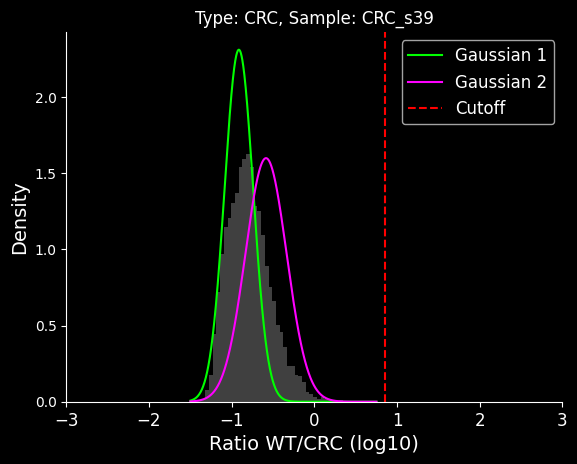

Type: CRC, Sample: CRC_s41
  → Standard Deviation: 0.2237
WT cells: 100.00%
CRC cells: 0.00%


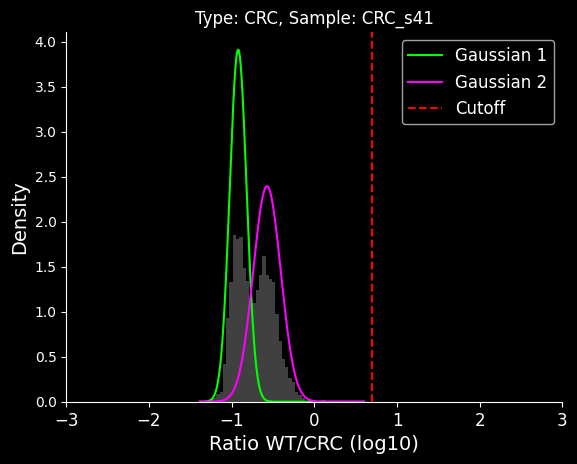

Type: CRC, Sample: CRC_s89
  → Standard Deviation: 0.2882
WT cells: 100.00%
CRC cells: 0.00%


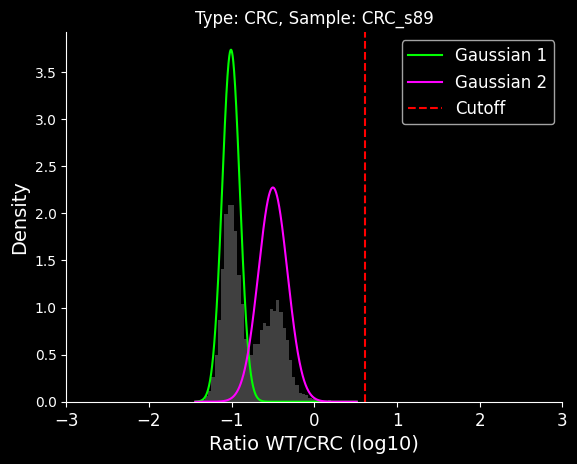

Type: CRC, Sample: CRC_s90
  → Standard Deviation: 0.2630
WT cells: 100.00%
CRC cells: 0.00%


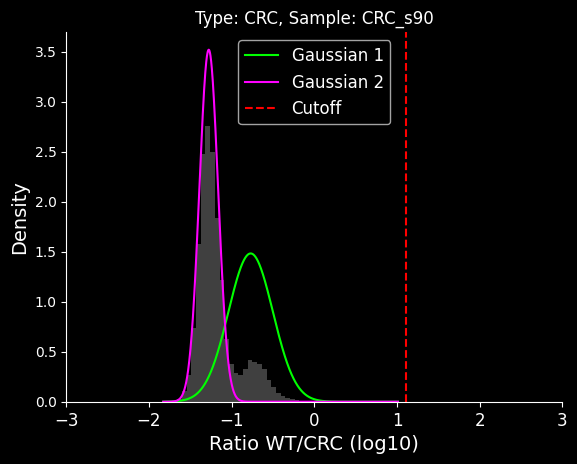

Type: CRC, Sample: CRC_s91
  → Standard Deviation: 0.3000
WT cells: 100.00%
CRC cells: 0.00%


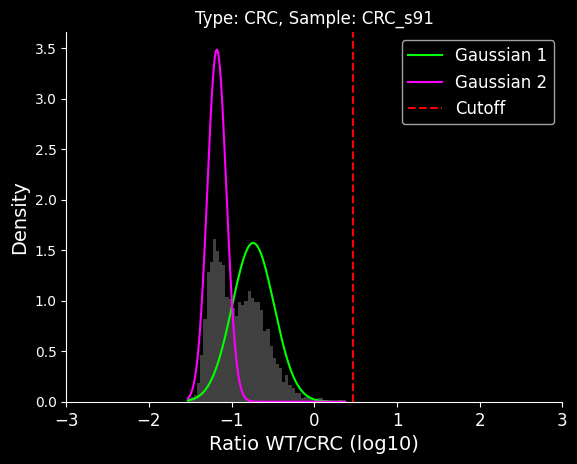

Type: CRC, Sample: CRC_s92
  → Standard Deviation: 0.3056
WT cells: 100.00%
CRC cells: 0.00%


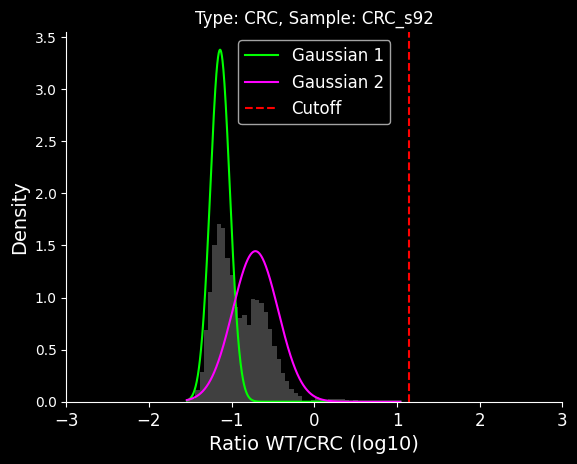

Type: MIX, Sample: MIX_s47
  → Standard Deviation: 0.6594
WT cells: 76.30%
CRC cells: 23.70%


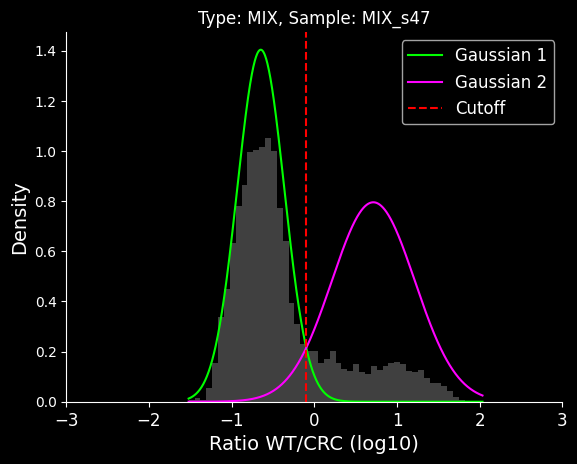

Type: MIX, Sample: MIX_s48
  → Standard Deviation: 1.9164
WT cells: 32.39%
CRC cells: 67.61%


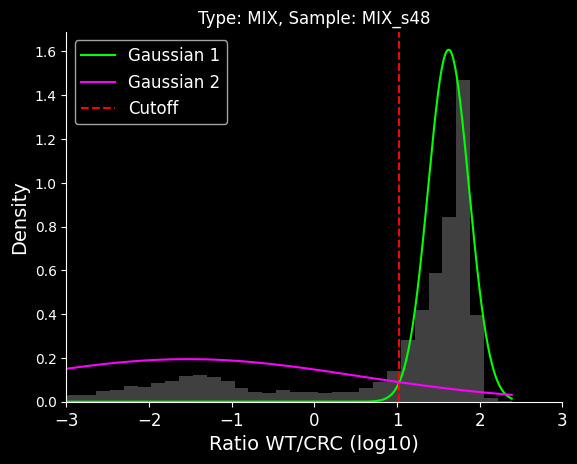

Type: MIX, Sample: MIX_s52
  → Standard Deviation: 0.7235
WT cells: 90.63%
CRC cells: 9.37%


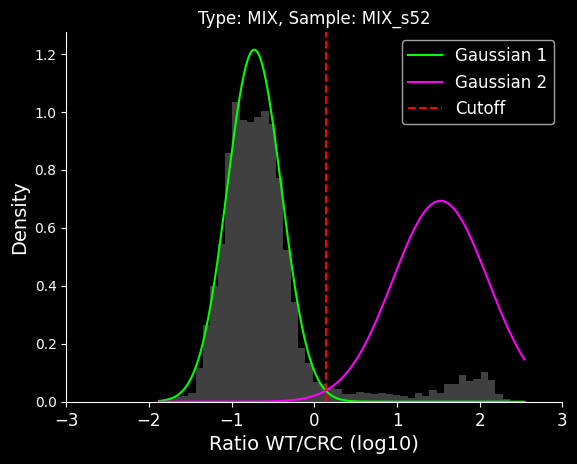

Type: WT, Sample: WT_s66
  → Standard Deviation: 0.2925
WT cells: 0.00%
CRC cells: 100.00%


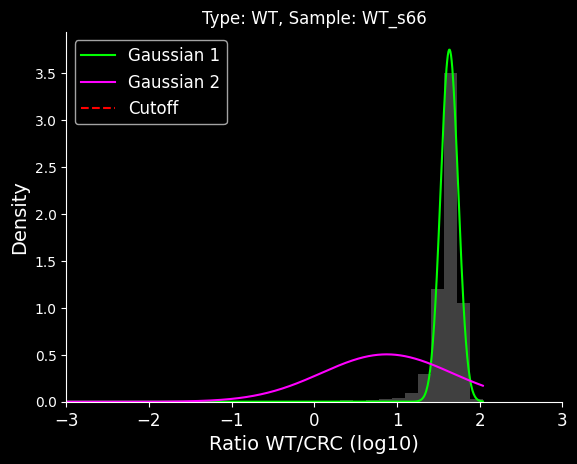

Type: WT, Sample: WT_s67
  → Standard Deviation: 0.2048
WT cells: 0.00%
CRC cells: 100.00%


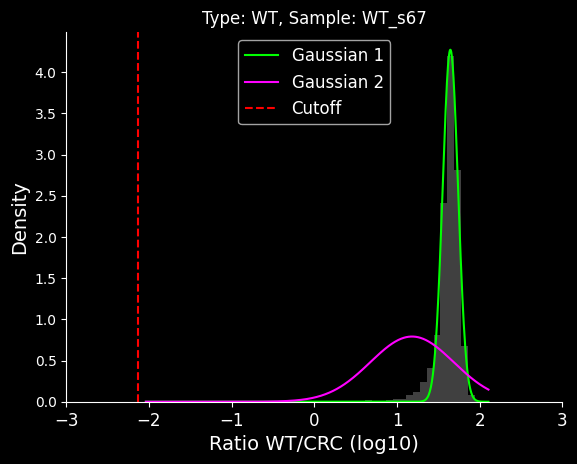

Type: WT, Sample: WT_s69
  → Standard Deviation: 0.3013
WT cells: 0.00%
CRC cells: 100.00%


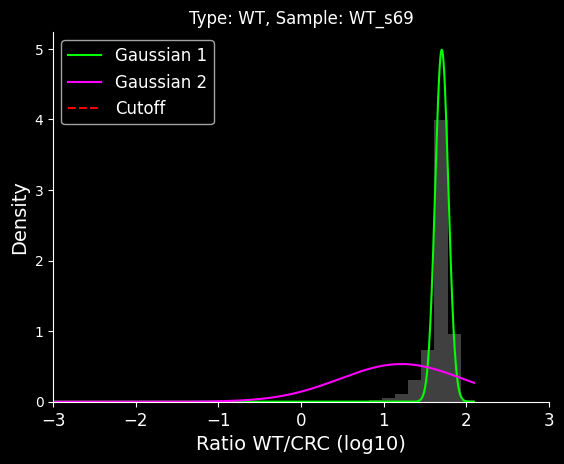

Type: WT, Sample: WT_s70
  → Standard Deviation: 0.2546
WT cells: 0.00%
CRC cells: 100.00%


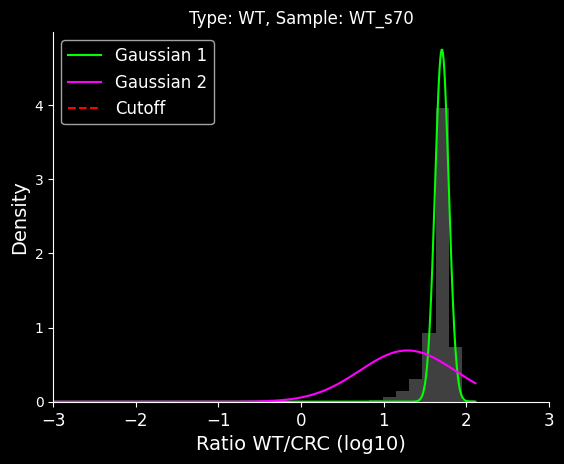

Type: WT, Sample: WT_s71
  → Standard Deviation: 0.2223
WT cells: 0.00%
CRC cells: 100.00%


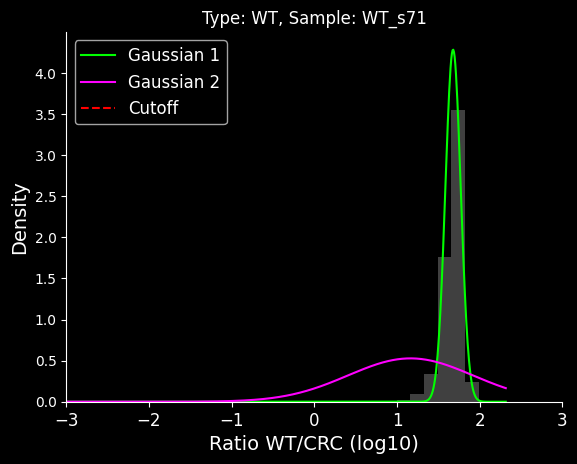

Type: WT, Sample: WT_s73
  → Standard Deviation: 0.2391
WT cells: 0.00%
CRC cells: 100.00%


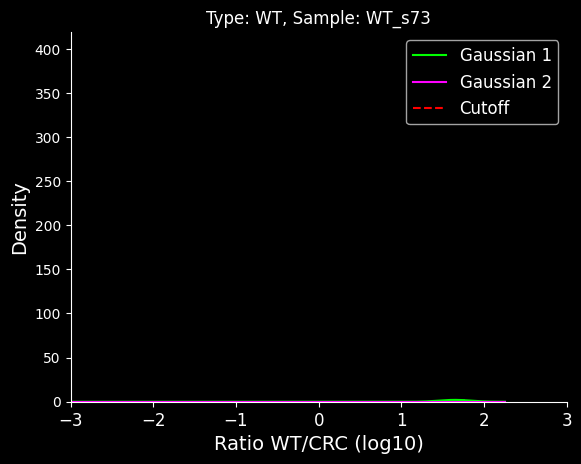

Type: WT, Sample: WT_s74
  → Standard Deviation: 0.2689
WT cells: 0.00%
CRC cells: 100.00%


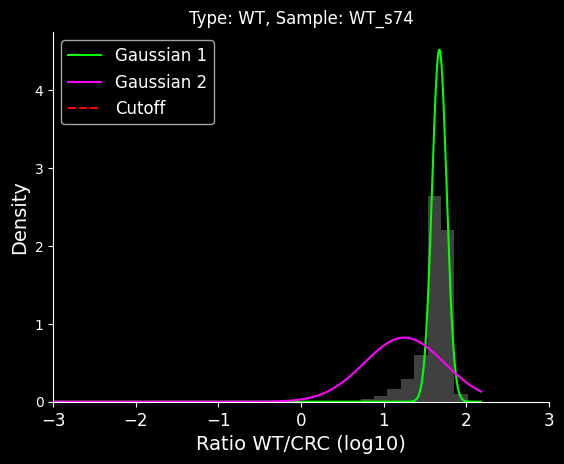

Type: WT, Sample: WT_s75
  → Standard Deviation: 0.3568
WT cells: 0.00%
CRC cells: 100.00%


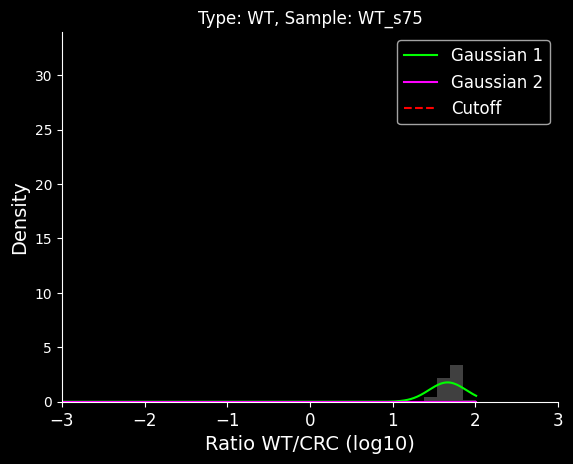

Type: WT, Sample: WT_s76
  → Standard Deviation: 0.1764
WT cells: 0.00%
CRC cells: 100.00%


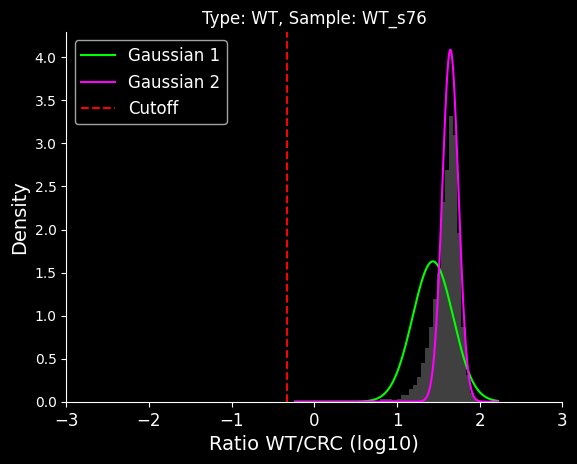

Type: WT, Sample: WT_s78
  → Standard Deviation: 0.1889
WT cells: 0.00%
CRC cells: 100.00%


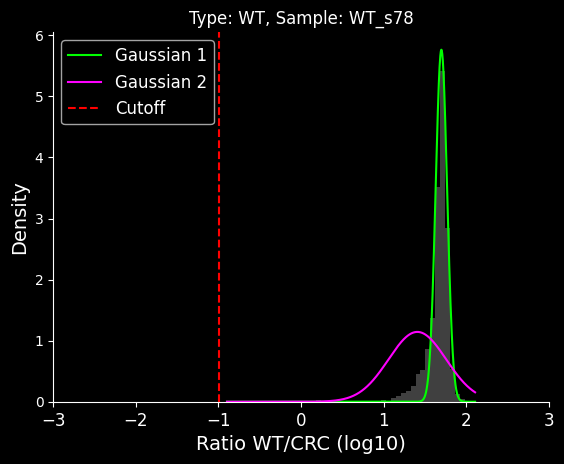

In [35]:
import scipy
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

# found online
def solve_gasussians(m1, s1, m2, s2):
    a = 1.0/(2.0*s1**2) - 1.0/(2.0*s2**2)
    b = m2/(s2**2) - m1/(s1**2)
    c = m1**2 /(2*s1**2) - m2**2 / (2.0*s2**2) - np.log(s2/s1)
    return np.roots([a,b,c])

def plot_gaussians(data):
    # Assuming data is already in shape (-1, 1)
    gmm = GaussianMixture(n_components=2, init_params='kmeans', random_state=0)
    gmm.fit(data)

    # Access the means of the Gaussian components
    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_.flatten())

    # Use the means and stds from your GMM
    mu1, mu2 = means
    sigma1, sigma2 = stds
    x_vals = np.linspace(data.min(), data.max(), 1000)
    pdf1 = norm(mu1, sigma1).pdf(x_vals)
    pdf2 = norm(mu2, sigma2).pdf(x_vals)

    if np.std(data) > 0.6: # High SD, so it is a mixed sample
        # Make two gaussian distributions on the data and
        # calculate the intersection
        solved_val = solve_gasussians(mu1, sigma1, mu2, sigma2)
        cutoff = solved_val[1]

    elif data.mean() > 0: # Means this sample is pure CRC
        cutoff = data.min() - 0.1

    elif data.mean() <= 0: # Means this sample is pure WT   
        cutoff = data.max() + 0.1

    print(f"WT cells: {np.sum(data.flatten() < cutoff) / len(data.flatten()) * 100:.2f}%")
    print(f"CRC cells: {np.sum(data.flatten() >= cutoff) / len(data.flatten()) * 100:.2f}%")

    # Plot as before

    plt.style.use("dark_background")
    plt.hist(data, bins=50, density=True, alpha=0.5, color="gray")
    x_vals = np.linspace(data.min(), data.max(), 1000)
    pdf1 = norm(mu1, sigma1).pdf(x_vals)
    pdf2 = norm(mu2, sigma2).pdf(x_vals)
    plt.plot(x_vals, pdf1, label="Gaussian 1", color="lime")
    plt.plot(x_vals, pdf2, label="Gaussian 2", color="magenta")
    plt.axvline(cutoff, color="red", linestyle="--", label="Cutoff")
    plt.ylabel("Density", size=14)
    plt.xlabel("Ratio WT/CRC (log10)", size=14)
    # make y and x labels larger
    plt.tick_params(axis='x', which='major', labelsize=12)
    plt.xlim(-3, 3)
    # Make legend text bigger
    plt.legend(fontsize=12)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.show()

for _, sample in test_data.iterrows():
    raw_ratios = [item[0] for item in sample["wt_crc_ratio"]]
    data = np.array(raw_ratios).reshape(-1, 1) #np.log10(np.array(raw_ratios) + 1e-6).reshape(-1, 1)
    #data = np.array(raw_ratios).reshape(-1, 1)  # Ensure data is in the correct shape for GaussianMixture
    print(f"Type: {sample['Type']}, Sample: {sample['Sample']}")

    std_dev = np.std(data)
    variance = np.var(data)
    print(f"  → Standard Deviation: {std_dev:.4f}")
    #print(f"  → Variance: {variance:.4f}")

    plt.title(f"Type: {sample['Type']}, Sample: {sample['Sample']}")
    plot_gaussians(data)

In [16]:
data

array([[nan],
       [nan],
       [nan],
       ...,
       [nan],
       [nan],
       [nan]])

In [34]:
output_directory = r"E:\demo_data"
import shutil

for sample in samples:
    props = [file for file in os.listdir(os.path.join(dir, sample, "properties")) if file.endswith(".csv")]

    os.makedirs(os.path.join(output_directory, sample), exist_ok=True)
    os.makedirs(os.path.join(output_directory, sample, "properties"), exist_ok=True)
    for prop in props:
        src = os.path.join(dir, sample, "properties", prop)
        dst = os.path.join(output_directory, sample, "properties", prop)
        shutil.copyfile(src, dst)


In [90]:
for _, sample in all_data.iterrows():
    raw_ratios = [item[0] for item in sample["raw_CRC"]]
    data = np.log10(np.array(raw_ratios) + 0.1).reshape(-1, 1)
    #data = np.array(raw_ratios).reshape(-1, 1)
    plt.hist(data, bins=50, alpha=0.5, label=sample["Sample"])
    plt.yscale("log")  # Make y-axis logarithmic
    #plt.xlim(0,500)
    plt.legend()


KeyError: 'raw_CRC'

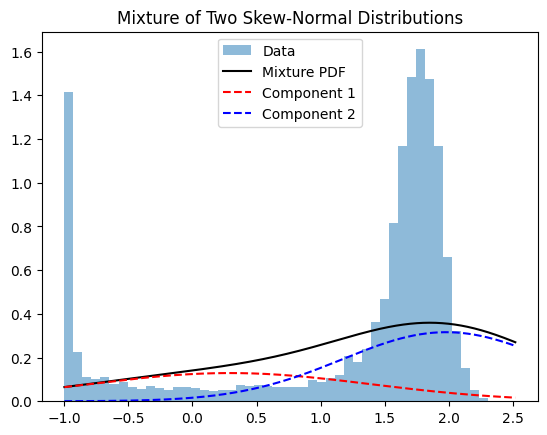

In [76]:
import numpy as np
from scipy.stats import skewnorm
from scipy.optimize import minimize


def skewnorm_mixture_pdf(x, params):
    # Unpack parameters
    w, a1, loc1, scale1, a2, loc2, scale2 = params
    w = np.clip(w, 0, 1)  # Ensure weight is between 0 and 1

    # Component PDFs
    pdf1 = skewnorm.pdf(x, a1, loc=loc1, scale=scale1)
    pdf2 = skewnorm.pdf(x, a2, loc=loc2, scale=scale2)

    return w * pdf1 + (1 - w) * pdf2


def neg_log_likelihood(params, x):
    pdf_vals = skewnorm_mixture_pdf(x, params)
    # Avoid log(0) by clipping
    pdf_vals = np.clip(pdf_vals, 1e-10, None)
    return -np.sum(np.log(pdf_vals))

# sample = pure
sample = np.log10(mixed_ratio + 0.1)

# Initial guess: [weight, a1, loc1, scale1, a2, loc2, scale2]
init_params = [0.5, 0, np.mean(sample) - 1, 1, 0, np.mean(sample) + 1, 1]

result = minimize(neg_log_likelihood, init_params, args=(sample,), method="L-BFGS-B")
params_fit = result.x

import matplotlib.pyplot as plt

# Unpack fitted parameters
w, a1, loc1, scale1, a2, loc2, scale2 = params_fit

# Generate x values
x_vals = np.linspace(sample.min(), sample.max(), 1000)

# Individual component PDFs
pdf1 = skewnorm.pdf(x_vals, a1, loc=loc1, scale=scale1)
pdf2 = skewnorm.pdf(x_vals, a2, loc=loc2, scale=scale2)

# Total mixture PDF
pdf_mix = w * pdf1 + (1 - w) * pdf2

# Plot
plt.hist(sample, bins=50, density=True, alpha=0.5, label="Data")
plt.plot(x_vals, pdf_mix, "k-", label="Mixture PDF")
plt.plot(x_vals, w * pdf1, "r--", label="Component 1")
plt.plot(x_vals, (1 - w) * pdf2, "b--", label="Component 2")
plt.title("Mixture of Two Skew-Normal Distributions")
plt.legend()
plt.show()

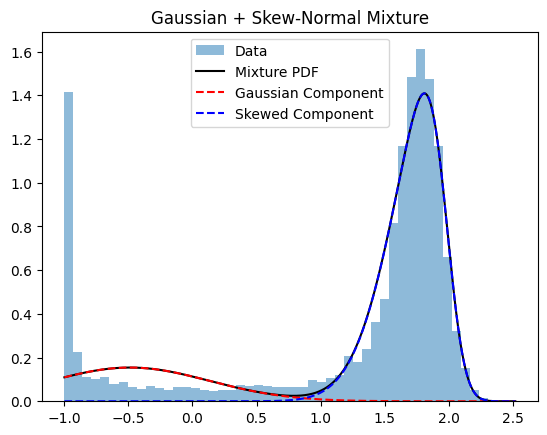

In [77]:
from scipy.stats import norm, skewnorm


def gaussian_skewnorm_mixture_pdf(x, params):
    # Unpack parameters
    w, mu1, sigma1, a2, loc2, scale2 = params
    w = np.clip(w, 0, 1)

    # Component PDFs
    pdf1 = norm.pdf(x, loc=mu1, scale=sigma1)
    pdf2 = skewnorm.pdf(x, a2, loc=loc2, scale=scale2)

    return w * pdf1 + (1 - w) * pdf2


def neg_log_likelihood(params, x):
    pdf_vals = gaussian_skewnorm_mixture_pdf(x, params)
    pdf_vals = np.clip(pdf_vals, 1e-10, None)  # Avoid log(0)
    return -np.sum(np.log(pdf_vals))

sample = np.log10(mixed_ratio + 0.1)

# Initial guess: [weight, mu1, sigma1, a2, loc2, scale2]
init_params = [0.5, np.mean(sample) - 1, 1, 5, np.mean(sample) + 1, 1]

from scipy.optimize import minimize

bounds = [
    (0.05, 0.95),        # weight: avoid extreme dominance
    (-2.0, 0.0),         # mu1: Gaussian mean near the peak (~−1.75)
    (0.3, 2.5),          # sigma1: allow moderate spread
    (-10.0, 10.0),       # a2: skewness, full range
    (0.0, 2.5),          # loc2: skewed component center (tail region)
    (0.3, 3.0)           # scale2: allow wider tail modeling
]

result = minimize(neg_log_likelihood, init_params, args=(sample,), method="L-BFGS-B", bounds= bounds)
params_fit = result.x

x_vals = np.linspace(sample.min(), sample.max(),1000)

# Unpack fitted parameters
w, mu1, sigma1, a2, loc2, scale2 = params_fit

pdf1 = norm.pdf(x_vals, loc=mu1, scale=sigma1)
pdf2 = skewnorm.pdf(x_vals, a2, loc=loc2, scale=scale2)
pdf_mix = w * pdf1 + (1 - w) * pdf2

plt.hist(sample, bins=50, density=True, alpha=0.5, label="Data")
plt.plot(x_vals, pdf_mix, "k-", label="Mixture PDF")
plt.plot(x_vals, w * pdf1, "r--", label="Gaussian Component")
plt.plot(x_vals, (1 - w) * pdf2, "b--", label="Skewed Component")
plt.title("Gaussian + Skew-Normal Mixture")
plt.legend()
plt.show()

In [68]:
samples = [pure, mixed]

for sample in samples:
    threshold = np.percentile(sample, 99)
    top_5_percent = sample[sample > threshold]

    print(f"sample {top_5_percent.mean()}")

sample -0.03592474489131749
sample 2.0605038696144056


In [51]:
from scipy.stats import norm, skewnorm
from scipy.integrate import quad

# Extract parameters
weight = params_fit[0]
mu1, sigma1 = params_fit[1], params_fit[2]
a2, loc2, scale2 = params_fit[3], params_fit[4], params_fit[5]

# Define Gaussian support region (e.g. ±2σ)
gauss_lower = mu1 - 2 * sigma1
gauss_upper = mu1 + 2 * sigma1

# Define skewed PDF
def skew_pdf(x):
    return skewnorm.pdf(x, a2, loc2, scale2)

# Total area under skewed component (should be ~1)
total_area = quad(skew_pdf, -np.inf, np.inf)[0]

# Area of skewed component within Gaussian support
overlap_area = quad(skew_pdf, gauss_lower, gauss_upper)[0]

# Percentage overlap
overlap_percent = 100 * overlap_area / total_area
print(f"Overlap of skewed component within Gaussian support: {overlap_percent:.2f}%")

Overlap of skewed component within Gaussian support: 33.77%


In [ ]:
summary_results = []
for number in range():
    df = properties[properties["file"] == number]
    crc_count = np.sum(df["log_ratio"] < cutoff)
    wt_count = np.sum(df["log_ratio"] >= cutoff)
    total = crc_count + wt_count

    results = {
        "file": number,
        "wt_count": wt_count,
        "crc_count": crc_count,
        "%wt": wt_count / total * 100,
        "%crc": crc_count / total * 100,
    }
    summary_results.append(pd.DataFrame([results]))

summary_results = pd.concat(summary_results, ignore_index=True)

    file  wt_count  crc_count        %wt       %crc
0      0       158         11  93.491124   6.508876
1      1       201          8  96.172249   3.827751
2      2       258         15  94.505495   5.494505
3      3       299         15  95.222930   4.777070
4      4       390          8  97.989950   2.010050
5      5       423         47  90.000000  10.000000
6      6       543         41  92.979452   7.020548
7      7       609         57  91.441441   8.558559
8      8       758         63  92.326431   7.673569
9      9       849         70  92.383025   7.616975
10    10       901         97  90.280561   9.719439
11    11      1034        107  90.622261   9.377739
12    12      1083        183  85.545024  14.454976
13    13      1338        174  88.492063  11.507937


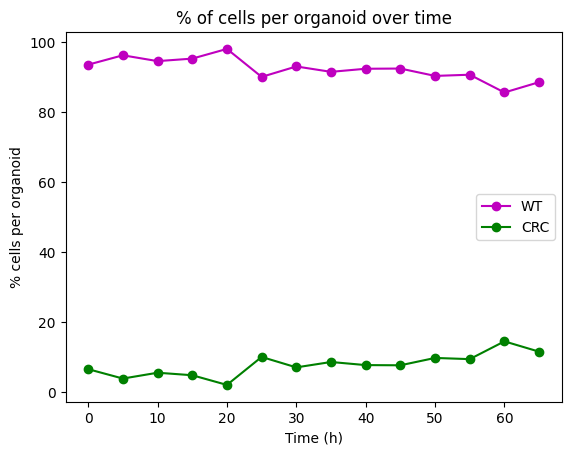

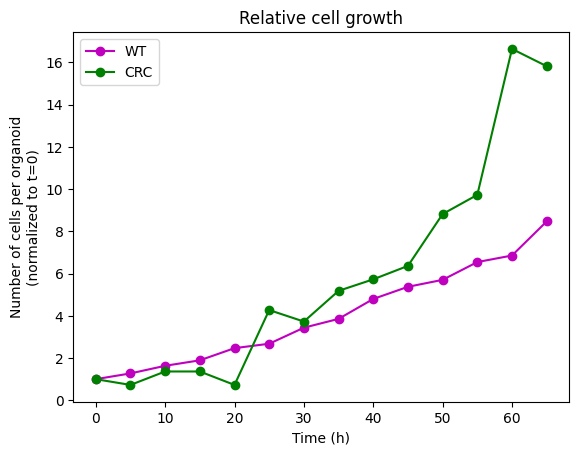

In [19]:
import matplotlib.pyplot as plt
print(summary_results)

# plot 1
plt.plot(summary_results["file"]*5, summary_results["%wt"], "m-", marker = "o", label = "WT")
plt.plot(summary_results["file"]*5, summary_results["%crc"], "g-", marker = "o", label = "CRC")

plt.title("% of cells per organoid over time")
plt.ylabel("% cells per organoid")
plt.xlabel("Time (h)")
plt.legend()

plt.show()

# plot 2
relative_wt = summary_results["wt_count"] / summary_results["wt_count"][0]
relative_crc = summary_results["crc_count"] / summary_results["crc_count"][0]

plt.plot(summary_results["file"] * 5, relative_wt, "m-", marker="o", label="WT")
plt.plot(summary_results["file"] * 5, relative_crc, "g-", marker="o", label="CRC")

plt.title("Relative cell growth")
plt.ylabel("Number of cells per organoid\n(normalized to t=0)")
plt.xlabel("Time (h)")
plt.legend()

plt.show()

In [24]:
import os
import re
import tifffile

input = r"C:\Users\6331823\Local SSD\Data_Anna\s65\s65.tif"
image = tifffile.imread(input)
print(image.shape)

input1 = r"C:\Users\6331823\Local SSD\Data_Anna\s55\s55.tif"
image1 = tifffile.imread(input1)
print(image1.shape)

(15, 3, 61, 1024, 1024)
(15, 61, 3, 1024, 1024)


In [ ]:
input_directory = r"C:\Users\6331823\Local SSD\Data_Anna\mixed\EXpansionLMix_12"

segmented = os.path.join(input_directory, "segmented")
cropped = os.path.join(input_directory, "cropped")
WT_channel = 0
CRC_channel = 1
all_ratios = []
frame_data = []

for file in range(15):
    segmented_stack = tifffile.imread(
        os.path.join(segmented, f"Frame-{file}_masks.tif")
    )
    frame = tifffile.imread(os.path.join(cropped, f"Frame-{file}.tif"))

    # Get properties of the masked nuclei, such as volume and location of every cell
    props = utils.properties_mask(segmented_stack)

    # Get properties of every cell in the WT and CRC channels at the masked nuclei locations
    frame_WT = frame[WT_channel, :, :, :]
    # threshold = frame_WT.copy()
    # threshold = utils.threshold(threshold)
    # blurred = ndimage.gaussian_filter(threshold, sigma=(0, 2, 2))

    median_value = np.median(frame_WT[frame_WT > 0])
    offset_image = frame_WT.astype(np.float32) - median_value
    offset_image[offset_image < 0] = 0  # Clip negative values
    offset_image = np.clip(offset_image, 0, 255).astype(np.uint16)
    df_wt = utils.properties_channel(segmented_stack, offset_image, "WT")

    frame_CRC = frame[CRC_channel, :, :, :]
    df_crc = utils.properties_channel(segmented_stack, frame_CRC, "CRC")

    # Combine the information of nuclei, WT, and CRC channel into a single dataframe
    df_final = props.merge(df_wt, on="label").merge(df_crc, on="label")
    df_final["file"] = file
    df_final["wt_crc_ratio"] = df_final.apply(
        lambda row: row["raw_WT"] / row["raw_CRC"] if row["raw_CRC"] != 0 else 5, axis=1
    )

    frame_data.append(df_final)

properties = pd.concat(frame_data, ignore_index=True)
print(properties)
ratios = properties["wt_crc_ratio"]

      label          z           y           x                  bounding_box  \
0         1   7.127551   46.301020   76.003401        (6, 37, 65, 9, 56, 85)   
1         2   6.462810   61.421488   48.839669        (6, 51, 39, 8, 75, 59)   
2         3   7.107450   67.340974   91.563037       (6, 58, 82, 9, 78, 103)   
3         4   7.208931   71.119617   68.886762        (6, 61, 59, 9, 81, 78)   
4         5   7.191077   96.287100   90.289040      (6, 84, 80, 9, 109, 103)   
...     ...        ...         ...         ...                           ...   
7818   1228  56.543103  558.685345  323.349138  (56, 551, 318, 58, 566, 331)   
7819   1229  56.388889  563.370370  333.438272  (56, 557, 327, 58, 571, 339)   
7820   1230  57.000000  419.983871  539.193548  (57, 413, 533, 58, 428, 545)   
7821   1231  57.000000  441.805369  519.281879  (57, 435, 513, 58, 449, 527)   
7822   1232  57.000000  537.000000  447.500000  (57, 533, 444, 58, 542, 452)   

      volume  area_WT     raw_WT  area_

In [15]:
import numpy as np
from sklearn.cluster import KMeans
import scipy.ndimage as ndimage

In [ ]:
channel_names = ["WT","CRC","Test","Nuclei"]

# Extract channel indices with a dictionary for dynamic access
channel_indices = {ch.lower(): i for i, ch in enumerate(channel_names) if ch.strip()}

# Always process the nuclei channel
nuclei_index = channel_indices.get("nuclei", -1)
if nuclei_index == -1:
    raise ValueError("Nuclei channel is required.")

# Placeholder for channel dataframes
channel_dfs = {}

for ch_name, ch_index in channel_indices.items():
    if ch_name == "nuclei":
        continue  # Skip nuclei for separate processing or if handled elsewhere

    # frame_ch = frame[ch_index, :, :, :]
    # offset_ch = utils.offset_image(frame_ch, type="median")
    # df_ch = utils.properties_channel(segmented_stack, offset_ch, channel_names[ch_index])
    # channel_dfs[ch_name.upper()] = df_ch

    print(ch_index, channel_names[ch_index])



0 WT
1 CRC
2 Test


TypeError: index expected at least 1 argument, got 0

In [3]:
import utils
import napari
from scipy.ndimage import gaussian_filter
from scipy.signal import wiener
import tifffile



Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.6 
platform:       	win32 
python version: 	3.11.13 
torch version:  	2.7.1+cu128! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 


utils package loaded successfully


In [11]:
input = r"C:\Users\6331823\Local SSD\Data_Anna\s65\cropped\Frame-14.tif"

WT_channel = 0
CRC_channel = 1
Nuclei_channel = 2


image = tifffile.imread(input)


image = image[CRC_channel,:,:,:]


threshold = image.copy()

threshold = utils.threshold(threshold)


blurred = gaussian_filter(threshold, sigma=(0, 2, 2))


offset_image = utils.offset_image(image, type="median")


viewer = napari.Viewer()


new_layer = viewer.add_image(image)


new_layer2 = viewer.add_image(threshold)


new_layer2 = viewer.add_image(blurred)


new_layer2 = viewer.add_image(offset_image)

In [ ]:
import tifffile
import scipy.ndimage as ndimage
from imaris_ims_file_reader.ims import ims
import numpy as np
import random

import os

input_directory = r"C:\Users\6331823\Local SSD\Data_Anna\crc"
output_directory = r"C:\Users\6331823\Local SSD\Train model whole organoid segmentation"

for file in os.listdir(input_directory):
    if file.endswith(".tif"):
        max_data = tifffile.imread(os.path.join(input_directory, file))
        max_data = max_data[:,:,2,:,:] # T Z X Y
        max_data = np.max(max_data, axis=1) # T X Y
        frames = random.sample(range(0, max_data.shape[0]), 4)

        for frame_n in frames:
            frame = max_data[frame_n,:,:]
            resize_factors = (200 / frame.shape[0], 200 / frame.shape[1])
            print(frame.shape)
            XY = ndimage.zoom(frame, resize_factors, order=0)
            XY = ndimage.gaussian_filter(XY, sigma=(2, 2))
            tifffile.imwrite(
                f"{os.path.join(output_directory,file.split('.')[0])}-{frame_n}_small.tif", XY
            )

In [3]:
import re
test = pd.read_csv(r"C:\Users\6331823\Local SSD\Data_Anna\all\summary_results.csv")

def classify_type(organoid):
    if "CRC" in organoid:
        return "CRC"
    elif "WT" in organoid:
        return "WT"
    elif "Mix" in organoid:
        return "Mixed"


test["type"] = test["organoid"].apply(classify_type)
test["time"] = test["file"].apply(lambda x: int(re.search(r'\d+', x).group()))
test = test[test["organoid"] != "EXpansionLMix_14"]

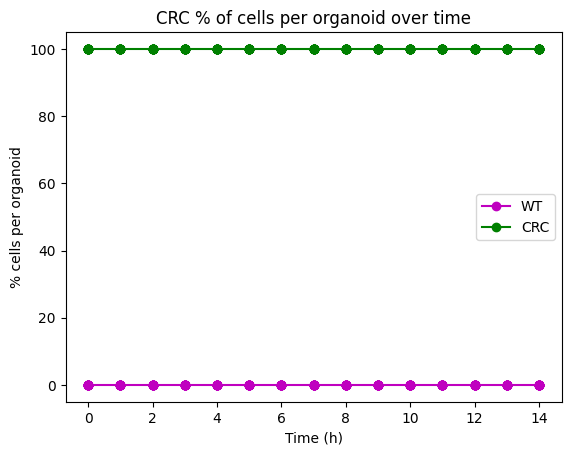

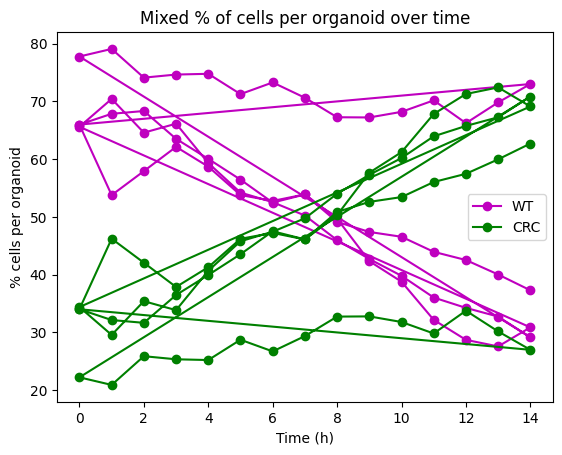

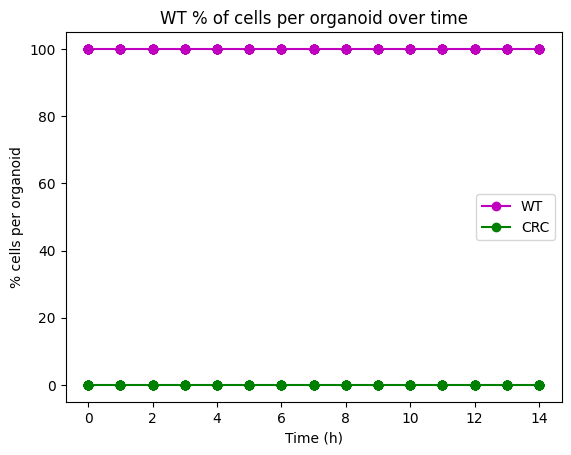

In [4]:
for type in test["type"].unique():
    data = test[test["type"] == type]
    
    plt.plot(data["time"], data["%wt"], "m-", marker="o", label="WT")
    plt.plot(data["time"], data["%crc"], "g-", marker="o", label="CRC")
    plt.title(f"{type} % of cells per organoid over time")
    plt.ylabel("% cells per organoid")
    plt.xlabel("Time (h)")
    plt.legend()
    plt.show()


In [27]:
print(test["type"].unique())
for type in data["type"].unique():
    data = test[test["type"] == type]
# WT relative growth
    plt.plot(data["time"], data["relative_wt"], "m-", marker="o", label="WT")
    plt.title(f"Sample:{type}, WT relative cell growth")
    plt.ylabel("Number of cells per organoid\n(normalized to t=0)")
    plt.xlabel("Time (h)")
    plt.legend()
    plt.show()


    # CRC relative growth
    plt.plot(data["time"], data["relative_crc"], "g-", marker="o", label="CRC")
    plt.title("CRC relative cell growth")
    plt.ylabel("Number of cells per organoid\n(normalized to t=0)")
    plt.xlabel("Time (h)")
    plt.legend()
    plt.show()

NameError: name 'test' is not defined

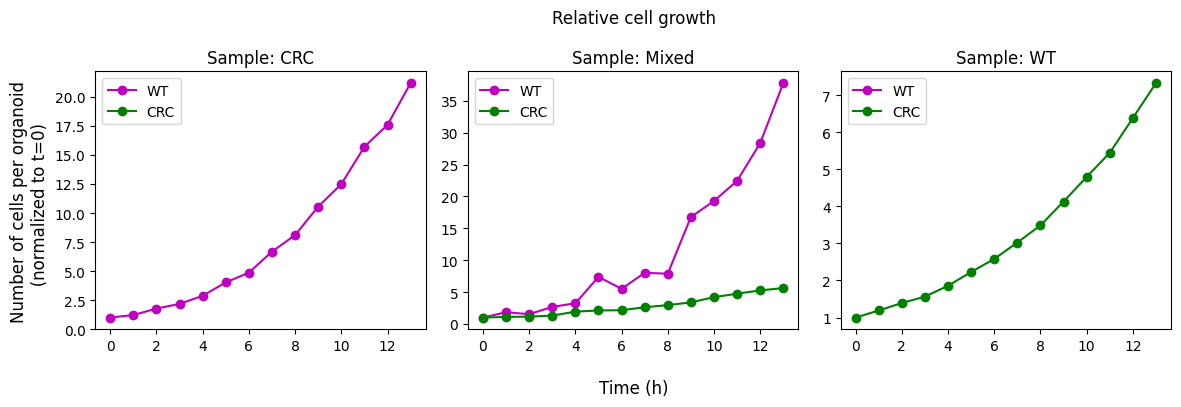

In [48]:
new = data.groupby(["type","time"])[["%wt", "%crc", "relative_wt","relative_crc"]].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=False)

for i, type in enumerate(new["type"].unique()):
    to_plot = new[new["type"] == type]
    # WT relative growth
    ax = axes[i]
    ax.plot(to_plot["time"], to_plot["relative_wt"], "m-", marker="o", label="WT")
    ax.plot(to_plot["time"], to_plot["relative_crc"], "g-", marker="o", label="CRC")
    ax.set_title(f"Sample: {type}") 
    ax.set_xticks(to_plot["time"][::2])
    ax.legend()


fig.suptitle(f"Relative cell growth", x = 0.54)
fig.supylabel("Number of cells per organoid\n       (normalized to t=0)")
fig.supxlabel("Time (h)", x = 0.54)
plt.tight_layout()
plt.show()

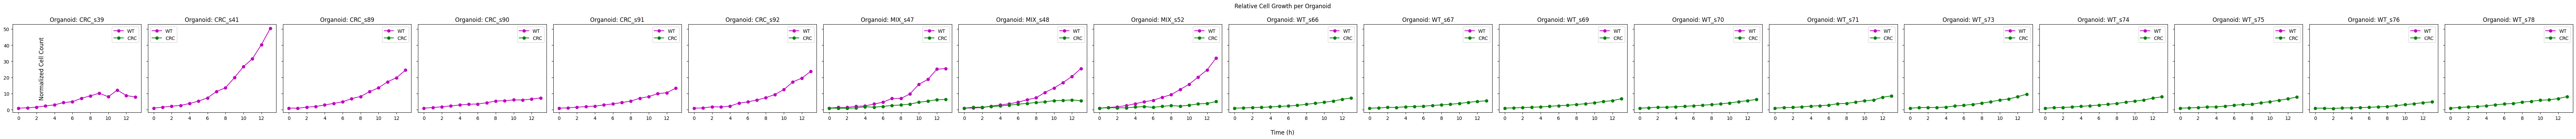

In [52]:
# Group by organoid and time to preserve individual traces
organoid_data = (
    data.groupby(["organoid", "time"])[["relative_wt", "relative_crc"]]
    .mean()
    .reset_index()
)

# Get unique organoids
organoids = organoid_data["organoid"].unique()

# Create subplots: one per organoid
fig, axes = plt.subplots(
    1, len(organoids), figsize=(4 * len(organoids), 4), sharey=True
)

# If only one organoid, axes won't be iterable
if len(organoids) == 1:
    axes = [axes]

for ax, organoid in zip(axes, organoids):
    to_plot = organoid_data[organoid_data["organoid"] == organoid]
    ax.plot(to_plot["time"], to_plot["relative_wt"], "m-", marker="o", label="WT")
    ax.plot(to_plot["time"], to_plot["relative_crc"], "g-", marker="o", label="CRC")
    ax.set_title(f"Organoid: {organoid}")
    ax.set_xticks(to_plot["time"][::2])
    ax.legend()

fig.suptitle("Relative Cell Growth per Organoid", x=0.5)
fig.supxlabel("Time (h)", x=0.5)
fig.supylabel("Normalized Cell Count")
plt.tight_layout()
plt.show()

C:\Users\6331823\AppData\Local\Temp\ipykernel_24552\1722036845.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  grouped = grouped[data["organoid"] != "CRC_s39"]


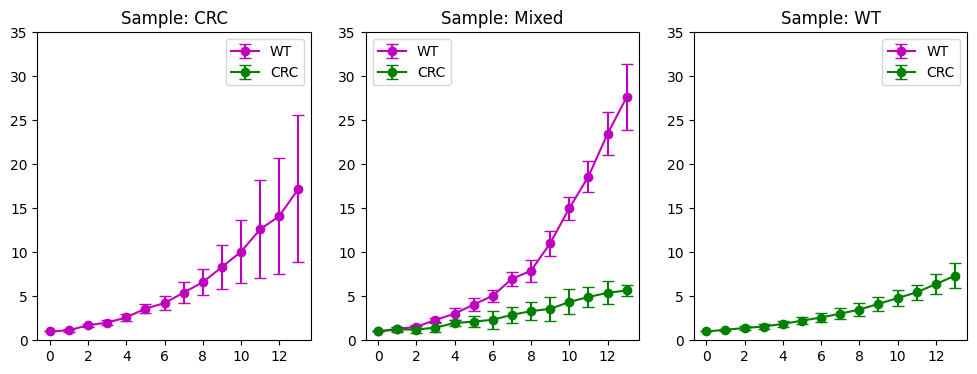

In [64]:
grouped = data[data["organoid"] != "CRC_s41"]
grouped = grouped[data["organoid"] != "CRC_s39"]
grouped = grouped.groupby(["type", "time"])[["relative_wt", "relative_crc"]]
mean = grouped.mean().reset_index()
std = grouped.std().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=False)

for i, type in enumerate(mean["type"].unique()):
    data_mean = mean[mean["type"] == type]
    data_std = std[std["type"] == type]

    ax = axes[i]

    # WT with error bars
    ax.errorbar(
        data_mean["time"],
        data_mean["relative_wt"],
        yerr=data_std["relative_wt"],
        fmt="m-o",
        label="WT",
        capsize=4,
    )

    # CRC with error bars
    ax.errorbar(
        data_mean["time"],
        data_mean["relative_crc"],
        yerr=data_std["relative_crc"],
        fmt="g-o",
        label="CRC",
        capsize=4,
    )

    ax.set_ylim(0,35)
    ax.set_title(f"Sample: {type}")
    ax.set_xticks(data_mean["time"][::2])
    ax.legend()

In [8]:
test["organoid"].unique()

array(['EXpansion_CRC_1', 'EXpansion_CRC_10', 'EXpansion_CRC_11',
       'EXpansion_CRC_12', 'EXpansion_CRC_13', 'EXpansion_CRC_14',
       'EXpansion_CRC_15', 'EXpansion_CRC_3', 'EXpansion_CRC_4',
       'EXpansion_CRC_5', 'EXpansion_CRC_6', 'EXpansion_CRC_7',
       'EXpansion_CRC_8', 'EXpansionLMix_11', 'EXpansionLMix_19',
       'EXpansionLMix_5', 'EXpansionLMix_8', 'EXpansionLWT_Pure_1',
       'EXpansionLWT_Pure_10', 'EXpansionLWT_Pure_11',
       'EXpansionLWT_Pure_12', 'EXpansionLWT_Pure_13',
       'EXpansionLWT_Pure_14', 'EXpansionLWT_Pure_2',
       'EXpansionLWT_Pure_3', 'EXpansionLWT_Pure_4',
       'EXpansionLWT_Pure_5', 'EXpansionLWT_Pure_6',
       'EXpansionLWT_Pure_7', 'EXpansionLWT_Pure_8',
       'EXpansionLWT_Pure_9'], dtype=object)

In [38]:
import napari
import numpy as np
import tifffile
import pandas as pd

import os

input_directory = r"C:\Users\6331823\Local SSD\Data_Anna\Exp137\MIX_s47"

movie = os.path.join(input_directory, "segmented_movie.tif")
movie = tifffile.imread(movie)

timepoints, z, y, x = movie.shape

labeled = []

for timepoint in range(timepoints):
    frame = movie[timepoint]
    props = pd.read_csv(
        os.path.join(input_directory, "properties", f"Frame-{timepoint}_props.csv")
    )
    new_frame = frame.copy()
    for _, row in props.iterrows():
        label_id = row["label"]
        phenotype = row["phenotype"]

        if phenotype == "CRC":
            new_label = 1
        elif phenotype == "WT":
            new_label = 2

        new_frame[frame == label_id] = new_label

    labeled.append(new_frame)

labeled = np.stack(labeled, axis = 0)

In [39]:
from utils.pad_to_shape import pad_to_shape

original = []
max_dims = [0,0,0,0]
for timepoint in range(timepoints):
    frame = tifffile.imread(os.path.join(input_directory, "cropped", f"Frame-{timepoint}.tif"))
    print(frame.shape)
    original.append(frame)

    for i in range(4):
        max_dims[i] = max(max_dims[i], frame.shape[i])
print(max_dims)

padded = [
    pad_to_shape(stack, max_dims) for stack in original
]

padded = np.stack(padded, axis=0)



Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.6 
platform:       	win32 
python version: 	3.11.13 
torch version:  	2.8.0+cu128! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 


utils package loaded successfully
(3, 17, 100, 97)
(3, 18, 106, 111)
(3, 22, 112, 118)
(3, 19, 110, 115)
(3, 21, 123, 114)
(3, 21, 135, 126)
(3, 23, 142, 141)
(3, 28, 158, 156)
(3, 26, 180, 167)
(3, 27, 189, 184)
(3, 27, 207, 205)
(3, 32, 220, 226)
(3, 32, 234, 240)
(3, 33, 245, 250)
[3, 33, 245, 250]


In [46]:
contrast = (150,300)
viewer = napari.Viewer(ndisplay=3)
viewer.add_image(
    padded[:, 0].astype(np.uint16),
    name="nuclei",
    scale=(1, 8, 1, 1),
    colormap="gray",
    blending="additive",
    #contrast_limits=(100,500),
)
viewer.add_image(
    padded[:, 1].astype(np.uint16),
    name="CRC",
    scale=(1, 8, 1, 1),
    colormap="green",
    blending="additive",
    #contrast_limits=contrast,
)
viewer.add_image(
    padded[:, 2].astype(np.uint16),
    name="WT",
    scale=(1, 8, 1, 1),
    colormap="magenta",
    blending="additive",
    #contrast_limits=(120,200),
)
viewer.add_labels(
    labeled,
    scale=(1, 8, 1, 1),
    colormap=["black", "lime", "magenta"],
    blending="additive",
)
collapsed = (movie > 0).astype(int)  # All labeled regions become 1

viewer.add_labels(collapsed, name = "Segmented Nuclei", colormap=["black","blue"], scale=(1, 8, 1, 1), blending = "additive")

<Labels layer 'Segmented Nuclei' at 0x216c01b6e10>

In [20]:
collapsed.shape

(15, 44, 525, 543)

In [38]:
import napari
import numpy as np
from napari_animation import Animation
from napari.layers import Labels

# Create viewer
viewer = napari.Viewer(ndisplay=3)

# Add all layers
viewer.add_image(
    padded[:, 0].astype(np.uint16),
    name="WT",
    scale=(1, 8, 1, 1),
    colormap="magenta",
    blending="additive",
    contrast_limits=(100, 500),
    visible=False,
)

viewer.add_image(
    padded[:, 1].astype(np.uint16),
    name="CRC",
    scale=(1, 8, 1, 1),
    colormap="green",
    blending="additive",
    contrast_limits=(150, 250),
    visible=False,
)

viewer.add_image(
    padded[:, 2].astype(np.uint16),
    name="Nuclei",
    scale=(1, 8, 1, 1),
    colormap="blue",
    blending="additive",
    contrast_limits=(120, 200),
)

viewer.add_labels(
    labeled,
    name = "Labeled",
    scale=(1, 8, 1, 1),
    colormap=["black", "lime", "magenta"],
    blending="additive",
    visible=False,
)

viewer.add_labels(
    collapsed, 
    name = "Segmented Nuclei", 
    colormap=["black","blue"], 
    scale=(1, 8, 1, 1), 
    blending = "additive", 
    visible=False,
    )

# Create animation
animation = Animation(viewer)

n_frames = padded.shape[0]
n_steps = 9  # total keyframes for each direction
original = Labels._update_thumbnail
angle_offset = 0
# Forward sweep
for i in range(n_steps):
    frame = int(i * n_frames / n_steps)
    angle = angle_offset + i * 360 / n_steps
    viewer.dims.set_point(0, frame)
    viewer.camera.angles = (angle, 30)
    Labels._update_thumbnail = lambda self: None
    animation.capture_keyframe()
    angle_offset += 360

    # Export animation
animation.animate(
    filename=r"C:\Users\6331823\Downloads\top_left.mp4", fps=30
)

animation = Animation(viewer)
viewer.layers["Segmented Nuclei"].visible = True
viewer.layers["Nuclei"].visible = False

for i in range(n_steps):
    frame = int(i * n_frames / n_steps)
    angle = angle_offset + i * 360 / n_steps
    viewer.dims.set_point(0, frame)
    viewer.camera.angles = (angle, 30)
    Labels._update_thumbnail = lambda self: None
    animation.capture_keyframe()
    angle_offset += 360

    # Export animation
animation.animate(
    filename=r"C:\Users\6331823\Downloads\top_right.mp4", fps=30
)

animation = Animation(viewer)
viewer.layers["WT"].visible = True
viewer.layers["CRC"].visible = True

for i in range(n_steps):
    frame = int(i * n_frames / n_steps)
    angle = angle_offset + i * 360 / n_steps
    viewer.dims.set_point(0, frame)
    viewer.camera.angles = (angle, 30)
    Labels._update_thumbnail = lambda self: None
    animation.capture_keyframe()
    angle_offset += 360

    # Export animation
animation.animate(
    filename=r"C:\Users\6331823\Downloads\bottom_left.mp4", fps=30
)
animation = Animation(viewer)
viewer.layers["Segmented Nuclei"].visible = False
viewer.layers["Labeled"].visible = True
viewer.layers["WT"].visible = False
viewer.layers["CRC"].visible = False
for i in range(n_steps):
    frame = int(i * n_frames / n_steps)
    angle = angle_offset + i * 360 / n_steps
    viewer.dims.set_point(0, frame)
    viewer.camera.angles = (angle, 30)
    Labels._update_thumbnail = lambda self: None
    animation.capture_keyframe()
    angle_offset += 360

    # Export animation
animation.animate(filename=r"C:\Users\6331823\Downloads\bottom_right.mp4", fps=30)


viewer.close_all()

Rendering frames...


100%|██████████| 121/121 [00:05<00:00, 21.44it/s]


Rendering frames...


100%|██████████| 121/121 [00:07<00:00, 16.37it/s]


Rendering frames...


100%|██████████| 121/121 [00:10<00:00, 11.83it/s]


Rendering frames...


100%|██████████| 121/121 [00:05<00:00, 23.82it/s]


RuntimeError: wrapped C/C++ object of type QtViewer has been deleted

In [60]:
import os
import tifffile
import napari
import numpy as np

shift_amount = 63

input_directory = (
    r"Z:\users\5595347\Microscope\From Imaris computer\Processed TL\AKG_Exp137\Raw"
)
output_directory = r"C:\Users\6331823\Local SSD\Data_Anna\Exp137"

#samples = [39,41,47,48,52,66,67,69,70,71,73,74,75,76,78,89,90,91,92]
#names = ["CRC","CRC","MIX","MIX","MIX","WT","WT","WT","WT","WT","WT","WT","WT","WT","WT","CRC","CRC","CRC","CRC"]
samples = [70, 71, 73, 74, 75, 76, 78, 89, 90, 91, 92]
names = [
    "WT",
    "WT",
    "WT",
    "WT",
    "WT",
    "WT",
    "WT",
    "CRC",
    "CRC",
    "CRC",
    "CRC",
]

for sample, name in zip(enumerate(samples), enumerate(names)):
    sample = sample[1]
    name = name[1]
    movie = []

    file_name = f"{name}_s{sample}"
    os.makedirs(os.path.join(output_directory, file_name), exist_ok=True)

    for timepoint in range(1,15):
        images = [file 
                for file in os.listdir(input_directory) 
                if f"s{sample}" in file and f"t{timepoint}." in file]

        frame = []

        for image in images:
            if "CSU-445" in image:
                image = tifffile.imread(os.path.join(input_directory, image))
                padded = np.pad(
                    image,
                    ((0, 0), (0, 0), (shift_amount, 0)),
                    mode="constant",
                    constant_values=0,
                )
                image = padded[:, :, :-shift_amount]
            else:
                image = tifffile.imread(os.path.join(input_directory, image))
            frame.append(image)

        frame = np.stack(frame, axis=1)
        movie.append(frame)
    movie = np.stack(movie, axis = 0)
    tifffile.imwrite(
        os.path.join(output_directory, file_name, f"{file_name}.tif"),
        movie,
        shape=movie.shape,
        imagej=True,
        metadata={
            "unit": "um",
            "axes": "TZCYX",
        },
    )
    print(f"saved movie {file_name}")

c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\tifffile\tifffile.py:3817: UserWarning: <tifffile.TiffWriter 'WT_s70.tif'> truncating ImageJ file
  warnings.warn(


saved movie WT_s70


c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\tifffile\tifffile.py:3817: UserWarning: <tifffile.TiffWriter 'WT_s71.tif'> truncating ImageJ file
  warnings.warn(


saved movie WT_s71


c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\tifffile\tifffile.py:3817: UserWarning: <tifffile.TiffWriter 'WT_s73.tif'> truncating ImageJ file
  warnings.warn(


...

c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\tifffile\tifffile.py:3817: UserWarning: <tifffile.TiffWriter 'CRC_s90.tif'> truncating ImageJ file
  warnings.warn(


saved movie CRC_s90


c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\tifffile\tifffile.py:3817: UserWarning: <tifffile.TiffWriter 'CRC_s91.tif'> truncating ImageJ file
  warnings.warn(


saved movie CRC_s91
saved movie CRC_s92


c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\tifffile\tifffile.py:3817: UserWarning: <tifffile.TiffWriter 'CRC_s92.tif'> truncating ImageJ file
  warnings.warn(


In [51]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import re

input_directory = r"C:\Users\6331823\Local SSD\Data_Anna\Exp137"

folders = [
    os.path.join(input_directory, folder)
    for folder in os.listdir(input_directory)
    if os.path.isdir(os.path.join(input_directory, folder))
]

data = []
for folder in folders:
    results = pd.read_csv(os.path.join(folder, "summary_results_organoid.csv"))
    data.append(results)

data = pd.concat(data, ignore_index=True)


data["time"] = data["file"].apply(lambda f: int(re.search(r"\d+", f).group()))


def classify_type(organoid):
    if "CRC" in organoid:
        return "CRC"
    elif "WT" in organoid:
        return "WT"
    elif "mix" in organoid.lower():
        return "Mixed"


data["type"] = data["organoid"].apply(classify_type)

In [46]:
data

,organoid,file,wt_count,crc_count,%wt,%crc,relative_wt,relative_crc,time,type
0,CRC_s39,Frame-0.tif,92,0,100.0,0.0,1.000000,NaN,0,CRC
1,CRC_s39,Frame-1.tif,108,0,100.0,0.0,1.173913,NaN,1,CRC
2,CRC_s39,Frame-2.tif,151,0,100.0,0.0,1.641304,NaN,2,CRC
3,CRC_s39,Frame-3.tif,215,0,100.0,0.0,2.336957,NaN,3,CRC
4,CRC_s39,Frame-4.tif,277,0,100.0,0.0,3.010870,NaN,4,CRC
...,...,...,...,...,...,...,...,...,...,...
261,WT_s78,Frame-9.tif,0,423,0.0,100.0,NaN,5.222222,9,WT
262,WT_s78,Frame-10.tif,0,479,0.0,100.0,NaN,5.913580,10,WT
263,WT_s78,Frame-11.tif,0,494,0.0,100.0,NaN,6.098765,11,WT
264,WT_s78,Frame-12.tif,0,561,0.0,100.0,NaN,6.925926,12,WT


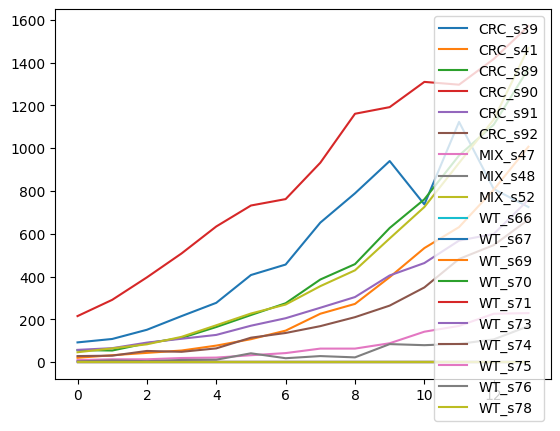

In [ ]:
for sample in data["organoid"].unique():
    to_plot = data[data["organoid"] == sample]

    if to_plot["type"].unique() ==
    plt.plot(to_plot["frame"], to_plot["wt_count"], label = sample)

# plt.legend()
plt.show()

KeyError: 'nearest_other_pheno_dist'

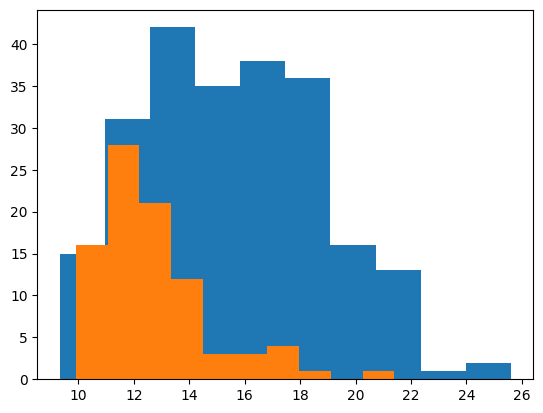

In [3]:
import numpy as np
import sklearn.neighbors as neighbors
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv(
    r"C:\Users\6331823\Local SSD\Data_Anna\Exp137\MIX_s47\properties\Frame-13_props.csv"
)

data["new_z"] = data["z"] * 7
test = data[["x","y","new_z"]].to_numpy()
nbrs = neighbors.NearestNeighbors(n_neighbors=5, algorithm="kd_tree").fit(test)
distances, indices = nbrs.kneighbors(test)
mean = [distance.mean() for distance in distances]
data["mean_distance"] = mean
plt.hist(data[data["phenotype"] == "WT"]["mean_distance"])
plt.hist(data[data["phenotype"] == "CRC"]["mean_distance"])
plt.hist(
    data[(data["phenotype"] == "WT") & (data["nearest_other_pheno_dist"] < 10)][
        "mean_distance"
    ],
    alpha=0.6,
)
plt.legend(["CRC","WT"])
plt.show()

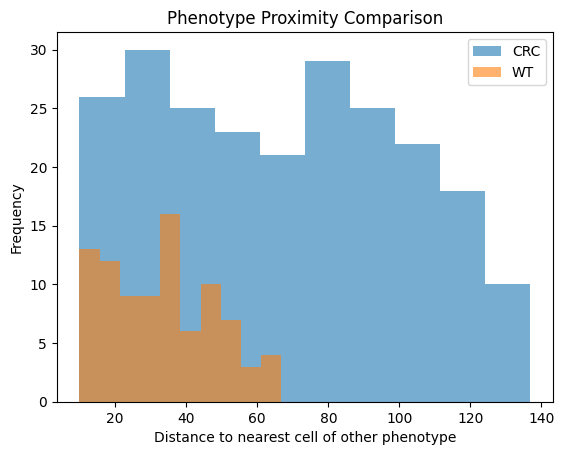

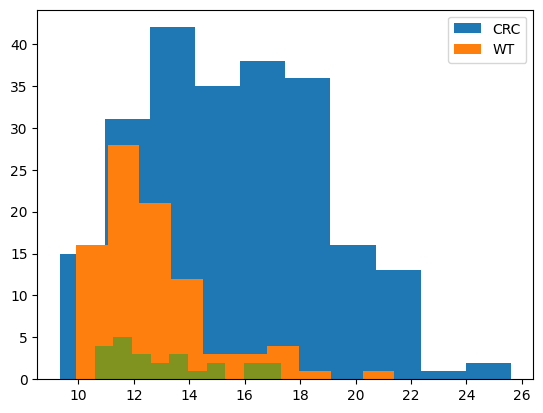

In [4]:
nearest_other_pheno = []

# Loop through each cell
for i, (coord, pheno) in enumerate(zip(test, data["phenotype"])):
    # Filter out cells with the same phenotype
    mask = data["phenotype"] != pheno
    other_coords = test[mask]

    # Fit NearestNeighbors on other phenotype cells
    nbrs = neighbors.NearestNeighbors(n_neighbors=1, algorithm="kd_tree").fit(other_coords)
    distance, _ = nbrs.kneighbors([coord])

    # Store the distance
    nearest_other_pheno.append(distance[0][0])

# Add to DataFrame
data["nearest_other_pheno_dist"] = nearest_other_pheno

# Plot histograms
plt.hist(data[data["phenotype"] == "WT"]["nearest_other_pheno_dist"], alpha=0.6)
plt.hist(data[data["phenotype"] == "CRC"]["nearest_other_pheno_dist"], alpha=0.6)
plt.legend(["CRC", "WT"])
plt.xlabel("Distance to nearest cell of other phenotype")
plt.ylabel("Frequency")
plt.title("Phenotype Proximity Comparison")
plt.show()

nbrs = neighbors.NearestNeighbors(n_neighbors=5, algorithm="kd_tree").fit(test)
distances, indices = nbrs.kneighbors(test)
mean = [distance.mean() for distance in distances]
data["mean_distance"] = mean

plt.hist(data[data["phenotype"] == "WT"]["mean_distance"])
plt.hist(data[data["phenotype"] == "CRC"]["mean_distance"])
plt.hist(
    data[(data["phenotype"] == "WT") & (data["nearest_other_pheno_dist"] < 20)][
        "mean_distance"
    ],
    alpha=0.6,
)
plt.legend(["CRC", "WT"])
plt.show()

In [5]:
from sklearn.neighbors import NearestNeighbors

# Prepare coordinates
coords = data[["x", "y", "new_z"]].to_numpy()
phenotypes = data["phenotype"].to_numpy()

# Fit NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=6, algorithm="kd_tree").fit(coords)
distances, indices = nbrs.kneighbors(coords)

# Skip the first neighbor (it's the cell itself)
neighbor_indices = indices[:, 1:]

# Compute diversity score
diversity_scores = []
for i, neighbors in enumerate(neighbor_indices):
    own_pheno = phenotypes[i]
    neighbor_phenos = phenotypes[neighbors]
    diff_count = sum(neighbor_phenos != own_pheno)
    score = diff_count / len(neighbors)  # Normalize to [0, 1]
    diversity_scores.append(score)

# Add to DataFrame
data["diversity_score"] = diversity_scores

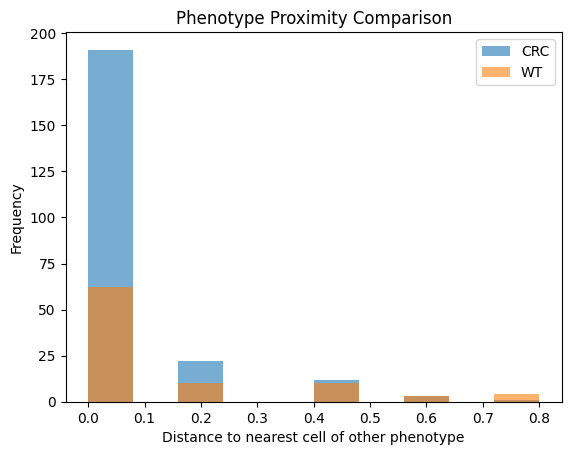

In [6]:
plt.hist(data[data["phenotype"] == "WT"]["diversity_score"], alpha=0.6)
plt.hist(data[data["phenotype"] == "CRC"]["diversity_score"], alpha=0.6)
plt.legend(["CRC", "WT"])
plt.xlabel("Distance to nearest cell of other phenotype")
plt.ylabel("Frequency")
plt.title("Phenotype Proximity Comparison")
plt.show()

In [16]:
import napari
import tifffile
import numpy as np
from matplotlib import cm
from matplotlib.colors import Normalize

image = tifffile.imread(r"C:\Users\6331823\Local SSD\Data_Anna\Exp137\MIX_s47\segmented\Frame-13_masks.tif")

properties = {
    "diversity_score": data["diversity_score"].to_numpy(),
    "phenotype": data["phenotype"].to_numpy(),
}

label_ids = data["label"].to_numpy()


# Normalize diversity scores to [0, 1]
norm = Normalize(vmin=0, vmax=1)
cmap = matplotlib.colormaps.get_cmap('viridis')
colors = cmap(norm(data['diversity_score'].to_numpy()))

# Build color dict: label ID → RGB
color_dict = {int(label): tuple(color[:3]) for label, color in zip(data['label'], colors)}

# Launch napari viewer
viewer = napari.Viewer()

# Add label image
labels_layer = viewer.add_labels(image, name='Cell Masks')

# Apply custom colors
labels_layer.color = color_dict

napari.run()

NameError: name 'matplotlib' is not defined

In [43]:
import imaris_ims_file_reader.ims as ims
import numpy as np
import h5py
import hdf5plugin

file = r"C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\250620_Imaging_20x_F08_cropped.ims"
movie = ims(file, ResolutionLevelLock= 0)
print(movie.shape)
t0 = movie[0]
t0 = np.expand_dims(t0, axis=0)
t1 = movie[1:]
movie = np.concatenate([t0, t1], axis=0)

Opening readonly file: C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\250620_Imaging_20x_F08_cropped.ims 

Closing file: C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\250620_Imaging_20x_F08_cropped.ims 

(37, 3, 54, 803, 933)
Closing file: C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\250620_Imaging_20x_F08_cropped.ims 



In [ ]:
import sys

# test = movie.astype(np.uint8)
# movie_12bit = np.clip(movie, 0, 4095).astype(np.uint16)
full_movie = ims(file,)
print(sys.getsizeof(movie) / 1e9)
print(sys.getsizeof(movie_12bit) / 1e9)
print(sys.getsizeof(test) / 1e9)
print(sys.getsizeof(full_movie) / 1e9)

Opening readonly file: C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\250620_Imaging_20x_F08_cropped.ims 

Closing file: C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\250620_Imaging_20x_F08_cropped.ims 

8.981397788
8.981397788
4.490698982
5.6e-08


In [31]:
import h5py

broken = r"C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\250620_Imaging_20x_F08_cropped.ims"
file = r"C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\250620_Imaging_20x_F08.ims"

with h5py.File(broken, "r") as f:

    def print_structure(name, obj):
        print(name)

    f.visititems(print_structure)

DataSet
DataSet/ResolutionLevel 0
DataSet/ResolutionLevel 0/TimePoint 0
DataSet/ResolutionLevel 0/TimePoint 0/Channel 0
DataSet/ResolutionLevel 0/TimePoint 0/Channel 0/Data
DataSet/ResolutionLevel 0/TimePoint 0/Channel 0/Histogram
DataSet/ResolutionLevel 0/TimePoint 0/Channel 0/Histogram1024
DataSet/ResolutionLevel 0/TimePoint 0/Channel 1
DataSet/ResolutionLevel 0/TimePoint 0/Channel 1/Data
DataSet/ResolutionLevel 0/TimePoint 0/Channel 1/Histogram
DataSet/ResolutionLevel 0/TimePoint 0/Channel 1/Histogram1024
DataSet/ResolutionLevel 0/TimePoint 0/Channel 2
DataSet/ResolutionLevel 0/TimePoint 0/Channel 2/Data
DataSet/ResolutionLevel 0/TimePoint 0/Channel 2/Histogram
DataSet/ResolutionLevel 0/TimePoint 0/Channel 2/Histogram1024
DataSet/ResolutionLevel 0/TimePoint 1
DataSet/ResolutionLevel 0/TimePoint 1/Channel 0
DataSet/ResolutionLevel 0/TimePoint 1/Channel 0/Data
DataSet/ResolutionLevel 0/TimePoint 1/Channel 0/Histogram
DataSet/ResolutionLevel 0/TimePoint 1/Channel 0/Histogram1024
DataSe

In [50]:
import h5py


def get_structure(path):
    structure = []
    with h5py.File(path, "r") as f:
        f.visit(lambda name: structure.append(name))
    return set(structure)


# Paths to your files
broken_path = r"C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\250620_Imaging_20x_F08_cropped.ims"
original_path = r"C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\250620_Imaging_20x_F08.ims"

# Get structures
broken_structure = get_structure(broken_path)
original_structure = get_structure(original_path)

# Compare
missing_in_broken = original_structure - broken_structure
extra_in_broken = broken_structure - original_structure

print("🔍 Missing in broken file:")
for item in sorted(missing_in_broken):
    print(item)

print("\n🧪 Extra in broken file:")
for item in sorted(extra_in_broken):
    print(item)

🔍 Missing in broken file:
DataSet/ResolutionLevel 4
DataSet/ResolutionLevel 4/TimePoint 0
DataSet/ResolutionLevel 4/TimePoint 0/Channel 0
DataSet/ResolutionLevel 4/TimePoint 0/Channel 0/Data
DataSet/ResolutionLevel 4/TimePoint 0/Channel 0/Histogram
DataSet/ResolutionLevel 4/TimePoint 0/Channel 0/Histogram1024
DataSet/ResolutionLevel 4/TimePoint 0/Channel 1
DataSet/ResolutionLevel 4/TimePoint 0/Channel 1/Data
DataSet/ResolutionLevel 4/TimePoint 0/Channel 1/Histogram
DataSet/ResolutionLevel 4/TimePoint 0/Channel 1/Histogram1024
DataSet/ResolutionLevel 4/TimePoint 0/Channel 2
DataSet/ResolutionLevel 4/TimePoint 0/Channel 2/Data
DataSet/ResolutionLevel 4/TimePoint 0/Channel 2/Histogram
DataSet/ResolutionLevel 4/TimePoint 0/Channel 2/Histogram1024
DataSet/ResolutionLevel 4/TimePoint 1
DataSet/ResolutionLevel 4/TimePoint 1/Channel 0
DataSet/ResolutionLevel 4/TimePoint 1/Channel 0/Data
DataSet/ResolutionLevel 4/TimePoint 1/Channel 0/Histogram
DataSet/ResolutionLevel 4/TimePoint 1/Channel 0/Hi

In [52]:
file = r"C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\testshuffleLZ4.ims"
with h5py.File(original_path, "r") as f:
    dset = f["DataSet/ResolutionLevel 0/TimePoint 0/Channel 0/Data"]
    print("Compression:", dset.compression)
    print("Chunks:", dset.chunks)
    print("Shape:", dset.shape)
    print("Dtype:", dset.dtype)

Compression: None
Chunks: (8, 128, 128)
Shape: (64, 1024, 1024)
Dtype: uint16


In [ ]:
from PyImarisWriter import PyImarisWriter as PW
import tables
from alive_progress import alive_bar
from matplotlib.colors import to_rgba
from datetime import datetime
from utils import dummy_callback
import imaris_ims_file_reader.ims as ims
import numpy as np
import tifffile

file = r"C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\250620_Imaging_20x_F08.ims"
new_movie = tifffile.imread(r"C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\tif.tif")
movie = ims(file)


output_filename = r"C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\test2.ims"
voxel_size = movie.resolution  # (Z, Y, X)
timepoints = movie.TimePoints
with tables.open_file(file, "r") as hf:
    time_values = hf.root.DataSetTimes.Time.read()
timestamps = np.array([row[2] for row in time_values])
timestamps = timestamps // 1000
channel_colors = ["magenta", "green", "blue"]
channel_names = ["magenta", "green", "blue"]

Z, Y, X, C, T = new_movie.shape

# Create image size
dimension_sequence = PW.DimensionSequence("x", "y", "z", "c", "t")
image_size = PW.ImageSize(x=X, y=Y, z=Z, c=C, t=T)
block_size = PW.ImageSize(x=X, y=Y, z=1, c=1, t=1)
sample_size = PW.ImageSize(x=1, y=1, z=1, c=1, t=1)
image_extents = PW.ImageExtents(
    0.0, 0.0, 0.0, voxel_size[2] * X, voxel_size[1] * Y, voxel_size[0] * Z
)

# Compression
options = PW.Options()
options.mNumberOfThreads = 6
options.mCompressionAlgorithmType = PW.eCompressionAlgorithmLZ4
options.mEnableLogProgress = True

# Dummy progress callback
callback_class = dummy_callback()

# Create converter
converter = PW.ImageConverter(
    "uint16",
    image_size,
    sample_size,
    dimension_sequence,
    block_size,
    output_filename,
    options,
    "OrganoidSegmenter",
    "v1.0",
    callback_class,
)

num_blocks = image_size / block_size
block_index = PW.ImageSize()
total_blocks = Z * C * T

with alive_bar(total_blocks, title="Writing cropped IMS file") as bar:
    for c in range(num_blocks.c):
        block_index.c = c
        for t in range(num_blocks.t):
            block_index.t = t
            for z in range(num_blocks.z):
                block_index.z = z
                z_start = z * block_size.z
                z_end = min(z_start + block_size.z, Z)
                for y in range(num_blocks.y):
                    block_index.y = y
                    y_start = y * block_size.y
                    y_end = min(y_start + block_size.y, Y)
                    for x in range(num_blocks.x):
                        block_index.x = x
                        x_start = x * block_size.x
                        x_end = min(x_start + block_size.x, X)

                        # Extract real voxel block
                        block = new_movie[
                            z_start:z_end, y_start:y_end, x_start:x_end, c, t
                        ]

                        # Reshape to (Z, Y, X, 1, 1) for compatibility
                        block = block[:, :, :, np.newaxis, np.newaxis].astype(
                            np.uint16
                        )

                        if converter.NeedCopyBlock(block_index):
                            converter.CopyBlock(block, block_index)

                        bar()

parameters = PW.Parameters()
for i in range(C):
    parameters.set_channel_name(
        i, channel_names[i] if i < len(channel_names) else f"Channel {i}"
    )
# Time info
time_infos = [datetime.utcfromtimestamp(t / 1e6) for t in timestamps]

# Convert to PW.Color using to_rgba
colors = []
for name in channel_colors:
    try:
        r, g, b, a = to_rgba(name)
        colors.append(PW.Color(r, g, b, a))
    except ValueError:
        print(f"Color '{name}' is not recognized. Using default white.")
        colors.append(PW.Color(1, 1, 1, 1))

# --- Apply colors to ColorInfo objects ---
color_infos = []
for i in range(C):  # assuming C is the number of channels
    ci = PW.ColorInfo()
    if i < len(channel_colors):
        ci.set_base_color(colors[i])
    else:
        ci.set_base_color(PW.Color(1, 1, 1, 1))  # default white for extras
    color_infos.append(ci)

# Finalize writing
converter.Finish(
    image_extents,  # Required physical bounds
    parameters,  # Parameters
    time_infos,  # TimeInfos
    color_infos,  # ColorInfos
    False,  # adjust_color_range
)
try:
    converter.Destroy()
except OSError as e:
    print("Warning: cleanup failed — continuing anyway")

print(f"✅ Wrote IMS file: {output_filename}")

Opening readonly file: C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\250620_Imaging_20x_F08.ims 

Closing file: C:\Users\6331823\Local SSD\Maria\250620_Imaging_20x_F08\250620_Imaging_20x_F08.ims 



on 5695574: Exception ignored on calling ctypes callback function: <bound method ImageConverter._progress_callback of <PyImarisWriter.PyImarisWriter.ImageConverter object at 0x0000023688676F10>>
on 5695594: MemoryError:


In [17]:
from natsort import natsorted

input_directory = r"C:\Users\6331823\Local SSD\Data_Anna\Exp137\CRC_s91"

files = [file for file in os.listdir(os.path.join(input_directory,"cropped")) if file.endswith(".tif")]
print(natsorted(files))

['Frame-0.tif', 'Frame-1.tif', 'Frame-2.tif', 'Frame-3.tif', 'Frame-4.tif', 'Frame-5.tif', 'Frame-6.tif', 'Frame-7.tif', 'Frame-8.tif', 'Frame-9.tif', 'Frame-10.tif', 'Frame-11.tif', 'Frame-12.tif', 'Frame-13.tif']


In [18]:
input_directory = r"C:\Users\6331823\Local SSD\Data_Anna\Exp137\CRC_s91"

movie = []
max_dims = [0, 0, 0, 0]
files = [
    file
    for file in os.listdir(os.path.join(input_directory, "cropped"))
    if file.endswith(".tif")
]

for file in natsorted(files):
    if file.endswith(".tif"):
        image = tifffile.imread(os.path.join(input_directory, "cropped", file))
        movie.append(image)
        for i in range(4):
            max_dims[i] = max(max_dims[i], image.shape[i])

padded = [utils.pad_to_shape(stack, max_dims) for stack in movie]
movie = np.stack(padded, axis=0)
print(movie.shape)

(14, 3, 38, 335, 339)


In [26]:
viewer = napari.Viewer()
viewer.add_image(movie, scale = (1,1,7,1,1))
viewer.add_image(full_movie, scale=(1, 1, 7, 1, 1))

<Image layer 'full_movie' at 0x25a273cab50>

In [24]:
full_movie = tifffile.imread(os.path.join(input_directory, f"CRC_s91.tif"))
full_movie = np.transpose(full_movie, (0, 2, 1, 3, 4))

In [35]:
print(full_movie.shape) 
xz_full = full_movie[:,0]
xz_full = np.max(xz_full, axis=2)
print(xz_full.shape)
tifffile.imwrite(os.path.join(input_directory, "CRC_s91_xz_tracked.tif"), xz_full.astype(np.uint16))

(14, 3, 61, 1024, 1024)
(14, 61, 1024)


In [40]:
image = tifffile.imread(os.path.join(input_directory, "segmented", "Frame-13_masks.tif"))
image = image[0]
tifffile.imwrite(os.path.join(input_directory, "segmented", "Frame-13_1.tif"), image)

In [ ]:
# Function to calculate the k-nearest neighbors for all cells in an organoid.


import numpy as np
import sklearn.neighbors
import pandas as pd


def knn(data, k=5):
    print("Calculating KNN...")


def compute_knn_features(points, k=5):
    if len(points) == 0:
        return [], [], []

    setX = points["x"] / points["x"].max()
    setY = points["y"] / points["y"].max()
    setZ = points["z"] / points["z"].max()

    coords = np.stack([setX, setY, setZ], axis=1)

    tree = sklearn.neighbors.KDTree(coords)
    k_use = min(k, len(coords))
    distances, indices = tree.query(coords, k=k_use)

    distAv = []
    pWT = []
    pC = []

    for i in range(len(indices)):
        neighbor_indices = indices[i]
        neighbor_phenotypes = points.iloc[neighbor_indices]["phenotype"]

        count_WT = sum(p.startswith("WT") for p in neighbor_phenotypes)
        count_C = sum(p.startswith("C") for p in neighbor_phenotypes)
        total = len(neighbor_phenotypes)

        distAv.append(np.median(distances[i]))
        pWT.append(count_WT)
        pC.append(count_C)

    return distAv, pWT, pC


data = pd.read_csv(r"E:\Data_Anna\MIX_s47\properties\Frame-13_props.csv")
print(data)

     frame  label          z           y           x  \
0       13      1   7.000000   73.000000  153.782609   
1       13      2   9.216920   96.887202  109.811280   
2       13      3   8.859922  100.175097  127.961089   
3       13      4   9.027933  105.016760  155.868715   
4       13      5   8.839623  106.223270  140.657233   
..     ...    ...        ...         ...         ...   
313     13    314  30.000000  106.722892   95.415663   
314     13    315  30.612040  133.739130  158.642140   
315     13    316  30.000000  165.710843  167.168675   
316     13    317  31.000000   94.936842  129.063158   
317     13    318  31.000000  124.656566  126.626263   

                     bounding_box  volume  area_CRC    raw_CRC  area_WT  \
0        (7, 69, 150, 8, 78, 158)    46.0      46.0   2.043478     46.0   
1      (8, 91, 100, 12, 103, 125)   461.0     461.0   2.297180    461.0   
2      (8, 94, 122, 11, 107, 136)   257.0     257.0   1.715953    257.0   
3      (8, 97, 149, 11, 116

In [8]:
from imaris_ims_file_reader.ims import ims

ims_movie = ims(r"C:\Users\6331823\Downloads\250912_Exp.ML.031_Imaging_20x_F00.ims")
voxel_size = ims_movie.resolution  # (Z, Y, X)
print(voxel_size)

Opening readonly file: C:\Users\6331823\Downloads\250912_Exp.ML.031_Imaging_20x_F00.ims 

Closing file: C:\Users\6331823\Downloads\250912_Exp.ML.031_Imaging_20x_F00.ims 

(4.918, 0.642, 0.642)


In [21]:
import sklearn.neighbors as neighbors

data = pd.read_csv(
    r"C:\Users\6331823\Local SSD\Data_Anna\Exp137\MIX_s48\properties\Frame-13_props.csv"
)

def calculate_phenotype_similarity_score(row_idx, nn_indices_row, phenotype_series):
    current_phenotype = phenotype_series.iloc[row_idx]
    # Get phenotypes of the nearest neighbors
    neighbor_phenotypes = phenotype_series.iloc[nn_indices_row]
    # Count how many neighbors have the same phenotype
    same_phenotype_count = (neighbor_phenotypes == current_phenotype).sum()
    return same_phenotype_count


data["new_z"] = data["z"] * 7
test = data[["x", "y", "new_z"]].to_numpy()
nbrs = neighbors.NearestNeighbors(n_neighbors=6, algorithm="kd_tree").fit(test)
distances, indices = nbrs.kneighbors(test)  

distances = distances[:, 1:]
indices = indices[:, 1:]
mean = [distance.mean() for distance in distances]
data["mean_distance"] = mean
data["nn_indices"] = list(indices)  # Add column with arrays of 5 nearest neighbor indices


phenotype_scores = []
for i, nn_indices_row in enumerate(data["nn_indices"]):
    score = calculate_phenotype_similarity_score(i, nn_indices_row, data["phenotype"])
    phenotype_scores.append(score)

data["cell_id"] = range(len(data))
data["phenotype_similarity_score"] = phenotype_scores

data.head(n=15)

,frame,label,z,y,x,bounding_box,volume,raw_crc,raw_wt,ratio_crc_wt,...,ratio_wt_crc,log_ratio_wt_crc,phenotype,mean_knn_distance,5_knn_neighbors,cell_id,phenotype_similarity_score,new_z,mean_distance,nn_indices
0,13,1,3.623377,201.975469,153.994228,"(1, 195, 146, 8, 210, 162)",693.0,12.982684,1.190476,10.905446,...,0.091697,-1.037639,crc,18.108213,[115 48 22 111 26],0,5,25.363636,19.834322,"[22, 48, 115, 26, 9]"
1,13,2,3.310236,148.820472,183.400000,"(2, 140, 175, 7, 158, 191)",635.0,11.135433,3.040945,3.661832,...,0.273087,-0.563697,crc,14.233037,[ 33 99 220 95 18],1,5,23.171654,18.832924,"[33, 99, 18, 95, 102]"
2,13,3,3.765507,168.065053,204.596067,"(2, 157, 198, 7, 180, 213)",661.0,6.231467,48.167927,0.129370,...,7.729788,0.888168,crc,13.416074,[38 41 47 19 34],2,2,26.358548,14.340355,"[38, 41, 47, 19, 34]"
3,13,4,3.557037,180.082963,236.874074,"(2, 172, 226, 7, 188, 246)",675.0,3.174815,53.068148,0.059825,...,16.715347,1.223115,wt,15.925349,[40 43 52 19 25],3,4,24.899259,18.112382,"[40, 43, 52, 19, 25]"
4,13,5,2.897727,192.248106,199.189394,"(2, 184, 188, 6, 202, 212)",528.0,17.924242,2.178030,8.229562,...,0.121513,-0.915373,crc,13.656951,[ 49 47 21 116 7],4,5,20.284091,16.758635,"[49, 21, 47, 7, 5]"
5,13,6,3.157761,201.251908,181.977099,"(2, 192, 176, 6, 210, 190)",393.0,15.513995,1.582697,9.802245,...,0.102017,-0.991321,crc,13.248580,[116 22 8 49 26],5,5,22.104326,15.756219,"[22, 116, 8, 26, 49]"
6,13,7,3.920152,203.922053,268.372624,"(2, 196, 262, 7, 212, 280)",526.0,2.747148,109.604563,0.025064,...,39.897564,1.600946,wt,14.101491,[50 55 23 24 58],6,5,27.441065,15.905602,"[23, 50, 55, 24, 58]"
7,13,8,3.119403,210.166045,204.805970,"(2, 203, 197, 6, 220, 214)",536.0,14.819030,6.787313,2.183342,...,0.458013,-0.339121,crc,17.623055,[61 57 4 21 8],7,5,21.835821,19.277750,"[57, 61, 4, 21, 8]"
8,13,9,3.127907,215.930233,185.066860,"(2, 209, 178, 6, 222, 193)",344.0,21.360465,3.436047,6.216581,...,0.160860,-0.793549,crc,16.426972,[ 26 64 5 61 116],8,5,21.895349,18.065254,"[5, 26, 64, 7, 61]"
9,13,10,3.543933,222.194561,160.453975,"(2, 215, 152, 6, 230, 170)",478.0,18.974895,1.280335,14.820251,...,0.067475,-1.170849,crc,18.884712,[26 68 62 0 69],9,5,24.807531,20.105156,"[26, 68, 62, 0, 8]"


In [68]:
frame = tifffile.imread(r"C:\Users\6331823\Local SSD\Data_Anna\Exp137\MIX_s47\segmented_movie.tif")

frame.shape

(14, 33, 245, 250)

In [10]:
test = r"E:\Data_Anna\MIX_s47\properties"

import os

print(os.path.basename(os.path.dirname(test)))

MIX_s47


In [30]:
viewer = napari.Viewer(ndisplay=3)  

coords_3d = data[["new_z", "y", "x"]].to_numpy()

for phenotype in data["phenotype"].unique():
    subset = data[data["phenotype"] == phenotype]
    if phenotype == "wt":
        color = "magenta"
    else:
        color = "green"
    viewer.add_points(
        subset[["new_z", "y", "x"]].to_numpy(),
        size=8,
        face_color=color,
        name=phenotype,
        opacity=1.0,
        blending="additive",
    )

# Create a colormap for phenotype similarity scores (1-5 scale)
similarity_scores = data["phenotype_similarity_score"].to_numpy()
print(similarity_scores)

# Create a custom colormap for similarity scores
# Low similarity (1) = red, High similarity (5) = blue
similarity_cmap = plt.cm.RdYlBu  # Red-Yellow-Blue colormap
norm_similarity = Normalize(vmin=1, vmax=5)

#  Map scores to colors
similarity_colors = similarity_cmap(norm_similarity(similarity_scores))

viewer.add_points(
    coords_3d,
    face_color=similarity_colors,
    size=12,
    name="Phenotype Similarity Score",
    opacity=0.9,
    blending="additive",
    visible=False,  # Start hidden so you can toggle between views
)

image = tifffile.imread(r"C:\Users\6331823\Local SSD\Data_Anna\Exp137\MIX_s48\cropped\Frame-13.tif")

viewer.add_image(image[0], scale=(7, 1, 1), colormap="gray", blending="additive", name="Nuclei")
viewer.add_image(
    image[1], scale=(7, 1, 1), colormap="green", blending="additive", name="CRC"
)
viewer.add_image(
    image[2], scale=(7, 1, 1), colormap="magenta", blending="additive", name="WT"
)

[5 5 2 ... 1 2 5]


<Image layer 'WT' at 0x133587ce6d0>

In [31]:
image = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Anna\Exp137\MIX_s48\cropped\Frame-13.tif"
)
segmented = tifffile.imread(r"C:\Users\6331823\Local SSD\Data_Anna\Exp137\MIX_s48\segmented_movie.tif")
segmented = segmented[13]
viewer = napari.Viewer(ndisplay=3)
viewer.add_image(
    image[0], scale=(7, 1, 1), colormap="gray", blending="additive", name="Nuclei"
)
viewer.add_image(
    image[1], scale=(7, 1, 1), colormap="green", blending="additive", name="CRC"
)
viewer.add_image(
    image[2], scale=(7, 1, 1), colormap="magenta", blending="additive", name="WT"
)
viewer.add_labels(segmented, scale=(7, 1, 1), name="Segmented Cells", blending="additive")

<Labels layer 'Segmented Cells' at 0x1337e768a50>

In [12]:
import numpy as np
from scipy.spatial import Voronoi
from scipy.spatial.distance import cdist
import napari
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import tifffile

# Set maximum cell radius (10 µm radius = 20 µm diameter)
max_radius = 20.0  # in micrometers

# Create 3D coordinates
coords_3d = data[["x", "y", "new_z"]].to_numpy()

# Define volume bounds with padding for the max radius
x_min, x_max = coords_3d[:, 0].min() - max_radius, coords_3d[:, 0].max() + max_radius
y_min, y_max = coords_3d[:, 1].min() - max_radius, coords_3d[:, 1].max() + max_radius
z_min, z_max = coords_3d[:, 2].min() - max_radius, coords_3d[:, 2].max() + max_radius

# Create 3D grid for visualization
resolution = 100  # Adjust for detail vs. performance
x_grid = np.linspace(x_min, x_max, resolution)
y_grid = np.linspace(y_min, y_max, resolution)
z_grid = np.linspace(z_min, z_max, resolution)

X, Y, Z = np.meshgrid(x_grid, y_grid, z_grid, indexing="ij")
grid_points = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])

# Calculate distances from each grid point to all cell centers
print("Calculating distances for bounded Voronoi...")
distances_to_cells = cdist(grid_points, coords_3d)

# Find nearest cell for each grid point
nearest_cell_indices = np.argmin(distances_to_cells, axis=1)
nearest_distances = np.min(distances_to_cells, axis=1)

# Apply radius constraint: only assign grid points within max_radius
valid_mask = nearest_distances <= max_radius
bounded_voronoi_volume = np.full(grid_points.shape[0], 0)  # 0 = empty space
bounded_voronoi_volume[valid_mask] = (
    nearest_cell_indices[valid_mask] + 1
)  # +1 for napari labels

# Reshape to 3D volume
bounded_voronoi_volume = bounded_voronoi_volume.reshape(X.shape)

# Create napari visualization
viewer = napari.Viewer(ndisplay=3)


# Add cell centers colored by phenotype
colors_pheno = {"WT": [1, 0, 1, 1], "CRC": [0, 1, 0, 1]}  # magenta, green
point_colors = [colors_pheno.get(pheno, [0, 0, 1, 1]) for pheno in data["phenotype"]]

viewer.add_points(
    coords_3d, face_color=point_colors, size=8, name="Cell Centers", opacity=1.0
)

# Create a colormap for phenotype similarity scores (1-5 scale)
similarity_scores = data["phenotype_similarity_score"].to_numpy()

# Create a custom colormap for similarity scores
# Low similarity (1) = red, High similarity (5) = blue
similarity_cmap = plt.cm.RdYlBu  # Red-Yellow-Blue colormap
norm_similarity = Normalize(vmin=1, vmax=5)

#  Map scores to colors
similarity_colors = similarity_cmap(norm_similarity(similarity_scores))

viewer.add_points(
    coords_3d,
    face_color=similarity_colors,
    size=12,
    name="Phenotype Similarity Score",
    opacity=0.9,
    blending="additive",
    visible=False,  # Start hidden so you can toggle between views
)

color_dict = {0: [0, 0, 0, 0]}  # Transparent for background (label 0)
for i, color in enumerate(similarity_colors):
    color_dict[i + 1] = color  # Map cell index to label index (+1)

# Add bounded Voronoi regions as labels
viewer.add_labels(
    bounded_voronoi_volume,
    colormap=color_dict,
    name="Bounded Voronoi Regions",
    opacity=1,
    scale=[
        (x_max - x_min) / resolution,
        (y_max - y_min) / resolution,
        (z_max - z_min) / resolution,
    ],
    translate=[x_min, y_min, z_min],
    blending="additive",
)

# Create a colormap for phenotype similarity scores (1-5 scale)
similarity_scores_voronoi = data["voronoi_phenotype_dissimilarity"].to_numpy()

# Create a custom colormap for similarity scores
# Low similarity (1) = red, High similarity (5) = blue
similarity_cmap_voronoi = plt.cm.RdYlBu_r  # Blue-Yellow-Red colormap
norm_similarity_voronoi = Normalize(vmin=1, vmax=6)

#  Map scores to colors
similarity_colors_voronoi = similarity_cmap_voronoi(norm_similarity_voronoi(similarity_scores_voronoi))

viewer.add_points(
    coords_3d,
    face_color=similarity_colors_voronoi,
    size=12,
    name="Phenotype dissimnilarity voronoi Score",
    opacity=0.9,
    blending="additive",
    visible=False,  # Start hidden so you can toggle between views
)

color_dict_voronoi = {0: [0, 0, 0, 0]}  # Transparent for background (label 0)
for i, color in enumerate(similarity_colors_voronoi):
    color_dict_voronoi[i + 1] = color  # Map cell index to label index (+1)

# Add bounded Voronoi regions as labels
viewer.add_labels(
    bounded_voronoi_volume,
    colormap=color_dict_voronoi,
    name="Bounded Voronoi Regions dissimilarity voronoi",
    opacity=1,
    scale=[
        (x_max - x_min) / resolution,
        (y_max - y_min) / resolution,
        (z_max - z_min) / resolution,
    ],
    translate=[x_min, y_min, z_min],
    blending="additive",
)

viewer.add_labels(frame[13],
                 scale=(7,1,1),
                 blending="additive",
                 visible=False)

# Set camera to 3D mode
viewer.camera.angles = (45, 45, 0)
viewer.camera.zoom = 0.8

print(f"Bounded Voronoi tessellation created!")
print(f"- Maximum cell radius: {max_radius} µm")
print(f"- Resolution: {resolution}³ voxels")
print(f"- Black regions: Empty space where no cells can reach")
print(f"- Colored regions: Cell territories (max {max_radius} µm from center)")

Calculating distances for bounded Voronoi...


c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


KeyError: 'voronoi_phenotype_dissimilarity'

In [46]:
voronoi_dissimilarity_scores

array([4, 3, 2, 0, 0, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 3, 4, 1, 3, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       5, 6, 2, 4, 2, 3, 5, 3, 2, 4, 1, 0, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 3, 2, 4, 3,
       1, 0, 2, 4, 4, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 4, 3, 2, 0, 1,
       0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 1, 3, 2, 3,
       2, 3, 3, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 4, 3, 3, 3, 3, 0, 2, 3, 4,
       0, 1, 0, 4, 3, 0, 0, 1, 1, 0, 4, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 5, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [61]:
# ...existing code...

def calculate_knn_phenotype_dissimilarity(row_idx, nn_indices_row, phenotype_series):
    """Calculate dissimilarity score based on KNN - count neighbors with different phenotype"""
    current_phenotype = phenotype_series.iloc[row_idx]
    # Get phenotypes of the nearest neighbors
    neighbor_phenotypes = phenotype_series.iloc[nn_indices_row]
    # Count how many neighbors have DIFFERENT phenotype
    different_phenotype_count = (neighbor_phenotypes != current_phenotype).sum()
    return different_phenotype_count


def calculate_voronoi_phenotype_dissimilarity(neighbors_dict, phenotypes):
    """Calculate phenotype dissimilarity based on Voronoi neighbors"""
    voronoi_dissimilarity_scores = []

    for cell_idx in range(len(phenotypes)):
        current_phenotype = phenotypes[cell_idx]
        voronoi_neighbors = list(neighbors_dict.get(cell_idx, []))

        if len(voronoi_neighbors) == 0:
            # Isolated cell (no neighbors within radius)
            voronoi_dissimilarity_scores.append(0)
        else:
            # Count neighbors with DIFFERENT phenotype
            neighbor_phenotypes = [phenotypes[n] for n in voronoi_neighbors]
            different_phenotype_count = sum(
                1 for p in neighbor_phenotypes if p != current_phenotype
            ) + 1
            voronoi_dissimilarity_scores.append(different_phenotype_count)

    return voronoi_dissimilarity_scores


# Calculate KNN-based dissimilarity scores
knn_dissimilarity_scores = []
for i, nn_indices_row in enumerate(data["nn_indices"]):
    score = calculate_knn_phenotype_dissimilarity(i, nn_indices_row, data["phenotype"])
    knn_dissimilarity_scores.append(score)

data["knn_phenotype_dissimilarity"] = knn_dissimilarity_scores

# Calculate Voronoi-based dissimilarity scores
voronoi_dissimilarity_scores = calculate_voronoi_phenotype_dissimilarity(
    neighbors_dict, phenotypes
)
data["voronoi_phenotype_dissimilarity"] = voronoi_dissimilarity_scores

print(f"Dissimilarity scores calculated!")
print(f"KNN Dissimilarity range: {min(knn_dissimilarity_scores)} - {max(knn_dissimilarity_scores)}")
print(f"Voronoi Dissimilarity range: {min(voronoi_dissimilarity_scores)} - {max(voronoi_dissimilarity_scores)}")

# Compare all measures
print("\nComparison of similarity and dissimilarity measures:")
print("Cell ID | KNN Sim | KNN Dissim | Vor Sim | Vor Dissim | Phenotype")
print("-" * 70)
for i in range(min(15, len(data))):
    knn_sim = data.iloc[i]["phenotype_similarity_score"]
    knn_dissim = data.iloc[i]["knn_phenotype_dissimilarity"]
    vor_sim = data.iloc[i]["voronoi_phenotype_similarity"]
    vor_dissim = data.iloc[i]["voronoi_phenotype_dissimilarity"]
    phenotype = data.iloc[i]["phenotype"]
    print(f"{i:7d} | {knn_sim:7d} | {knn_dissim:10d} | {vor_sim:7d} | {vor_dissim:10d} | {phenotype}")

# Create visualization with dissimilarity measures
viewer = napari.Viewer(ndisplay=3)

# Add cell centers colored by phenotype
colors_pheno = {"WT": [1, 0, 1, 1], "CRC": [0, 1, 0, 1]}
point_colors = [colors_pheno.get(pheno, [0, 0, 1, 1]) for pheno in data["phenotype"]]

viewer.add_points(
    coords_3d, face_color=point_colors, size=8, name="Cell Centers", opacity=1.0
)

# KNN-based dissimilarity scores
knn_dissimilarity_scores = np.array(knn_dissimilarity_scores)
knn_dissim_cmap = plt.cm.Reds  # Red colormap for dissimilarity (high = more red)
knn_dissim_norm = Normalize(vmin=knn_dissimilarity_scores.min(), vmax=knn_dissimilarity_scores.max())
knn_dissim_colors = knn_dissim_cmap(knn_dissim_norm(knn_dissimilarity_scores))

viewer.add_points(
    coords_3d,
    face_color=knn_dissim_colors,
    size=12,
    name="KNN Phenotype Dissimilarity",
    opacity=0.9,
    visible=False,
)

# Voronoi-based dissimilarity scores
voronoi_dissimilarity_scores = np.array(voronoi_dissimilarity_scores)
vor_dissim_cmap = plt.cm.Oranges  # Orange colormap for Voronoi dissimilarity
vor_dissim_norm = Normalize(
    vmin=voronoi_dissimilarity_scores.min(), vmax=voronoi_dissimilarity_scores.max()
)
vor_dissim_colors = vor_dissim_cmap(vor_dissim_norm(voronoi_dissimilarity_scores))

viewer.add_points(
    coords_3d,
    face_color=vor_dissim_colors,
    size=12,
    name="Voronoi Phenotype Dissimilarity",
    opacity=0.9,
    visible=False,
)

# Also keep the similarity measures for comparison
knn_similarity_scores = data["phenotype_similarity_score"].to_numpy()
knn_cmap = plt.cm.Blues
knn_norm = Normalize(vmin=knn_similarity_scores.min(), vmax=knn_similarity_scores.max())
knn_colors = knn_cmap(knn_norm(knn_similarity_scores))

viewer.add_points(
    coords_3d,
    face_color=knn_colors,
    size=12,
    name="KNN Phenotype Similarity",
    opacity=0.9,
    visible=False,
)

voronoi_similarity_scores = data["voronoi_phenotype_similarity"].to_numpy()
vor_cmap = plt.cm.Purples
vor_norm = Normalize(
    vmin=voronoi_similarity_scores.min(), vmax=voronoi_similarity_scores.max()
)
vor_colors = vor_cmap(vor_norm(voronoi_similarity_scores))

viewer.add_points(
    coords_3d,
    face_color=vor_colors,
    size=12,
    name="Voronoi Phenotype Similarity",
    opacity=0.9,
    visible=False,
)

# Add Voronoi tessellation colored by dissimilarity
voronoi_volume_for_napari = voronoi_volume.copy()
voronoi_volume_for_napari[voronoi_volume == -1] = 0
valid_mask = voronoi_volume != -1
voronoi_volume_for_napari[valid_mask] = voronoi_volume[valid_mask] + 1

x_scale = (x_max - x_min) / resolution
y_scale = (y_max - y_min) / resolution
z_scale = (z_max - z_min) / resolution

# Create dissimilarity-colored Voronoi regions
dissim_color_mapping = {}
dissim_color_mapping[0] = [0, 0, 0, 0]  # Background (transparent)

for i, color in enumerate(vor_dissim_colors):
    label_id = i + 1  # +1 because we shifted indices
    dissim_color_mapping[label_id] = color

labels_layer = viewer.add_labels(
    voronoi_volume_for_napari,
    name="Voronoi Regions (Dissimilarity)",
    opacity=0.3,
    visible=False,
    scale=[z_scale, y_scale, x_scale],
    translate=[z_min, y_min, x_min],
)

labels_layer.color = dissim_color_mapping

# Set camera to 3D mode
viewer.camera.angles = (45, 45, 0)
viewer.camera.zoom = 0.8

print(f"\n🎯 Napari visualization ready with dissimilarity measures!")
print(f"Toggle between layers to compare:")
print(f"- 'Cell Centers': Raw phenotype colors")
print(f"- 'KNN Phenotype Similarity': Blues (high = more similar neighbors)")
print(f"- 'KNN Phenotype Dissimilarity': Reds (high = more different neighbors)")
print(f"- 'Voronoi Phenotype Similarity': Purples (high = more similar neighbors)")
print(f"- 'Voronoi Phenotype Dissimilarity': Oranges (high = more different neighbors)")
print(f"- 'Voronoi Regions (Dissimilarity)': Tessellation colored by dissimilarity")

# Print statistics for dissimilarity measures
print(f"\n📊 Dissimilarity Statistics:")
print(f"KNN Dissimilarity - Mean: {knn_dissimilarity_scores.mean():.2f}, Std: {knn_dissimilarity_scores.std():.2f}")
print(f"Voronoi Dissimilarity - Mean: {voronoi_dissimilarity_scores.mean():.2f}, Std: {voronoi_dissimilarity_scores.std():.2f}")

# Show correlation between dissimilarity measures
dissim_correlation = np.corrcoef(knn_dissimilarity_scores, voronoi_dissimilarity_scores)[0, 1]
print(f"Correlation between KNN and Voronoi dissimilarity: {dissim_correlation:.3f}")

# Show how dissimilarity relates to similarity (should be somewhat inverse)
knn_sim_dissim_corr = np.corrcoef(knn_similarity_scores, knn_dissimilarity_scores)[0, 1]
vor_sim_dissim_corr = np.corrcoef(voronoi_similarity_scores, voronoi_dissimilarity_scores)[0, 1]
print(f"KNN: Similarity vs Dissimilarity correlation: {knn_sim_dissim_corr:.3f}")
print(f"Voronoi: Similarity vs Dissimilarity correlation: {vor_sim_dissim_corr:.3f}")

# ...existing code...

Dissimilarity scores calculated!
KNN Dissimilarity range: 0 - 4
Voronoi Dissimilarity range: 1 - 7

Comparison of similarity and dissimilarity measures:
Cell ID | KNN Sim | KNN Dissim | Vor Sim | Vor Dissim | Phenotype
----------------------------------------------------------------------
      0 |       2 |          3 |       7 |          5 | CRC
      1 |       3 |          2 |       4 |          4 | CRC
      2 |       5 |          0 |       9 |          3 | CRC
      3 |       5 |          0 |       8 |          1 | CRC
      4 |       5 |          0 |       9 |          1 | CRC
      5 |       4 |          1 |       5 |          3 | CRC
      6 |       5 |          0 |       5 |          2 | CRC
      7 |       5 |          0 |       7 |          1 | CRC
      8 |       5 |          0 |       8 |          1 | CRC
      9 |       5 |          0 |       9 |          1 | CRC
     10 |       5 |          0 |       9 |          1 | CRC
     11 |       5 |          0 |       7 |        

RuntimeError: sequence argument must have length equal to input rank


🎯 Napari visualization ready with dissimilarity measures!
Toggle between layers to compare:
- 'Cell Centers': Raw phenotype colors
- 'KNN Phenotype Similarity': Blues (high = more similar neighbors)
- 'KNN Phenotype Dissimilarity': Reds (high = more different neighbors)
- 'Voronoi Phenotype Similarity': Purples (high = more similar neighbors)
- 'Voronoi Phenotype Dissimilarity': Oranges (high = more different neighbors)
- 'Voronoi Regions (Dissimilarity)': Tessellation colored by dissimilarity

📊 Dissimilarity Statistics:
KNN Dissimilarity - Mean: 0.36, Std: 0.82
Voronoi Dissimilarity - Mean: 1.58, Std: 1.20
Correlation between KNN and Voronoi dissimilarity: 0.864
KNN: Similarity vs Dissimilarity correlation: -1.000
Voronoi: Similarity vs Dissimilarity correlation: -0.524


In [55]:
data[data["cell_id"]== 316]

,frame,label,z,y,x,bounding_box,volume,area_CRC,raw_CRC,area_WT,...,log_ratio_CRC_WT,phenotype,new_z,mean_distance,nn_indices,cell_id,phenotype_similarity_score,voronoi_phenotype_similarity,knn_phenotype_dissimilarity,voronoi_phenotype_dissimilarity
316,13,317,31.0,94.936842,129.063158,"(31, 89, 125, 32, 102, 135)",95.0,95.0,10.863158,95.0,...,0.768167,WT,217.0,17.733079,"[292, 293, 294, 291, 297]",316,5,12,0,0


In [8]:
# Function that will re-analyze statistics on phenotype and k-nearest neighbors if needed
# This is useful if you want to change the cutoff for the phenotype based on the whole experiment instead of on a per organoid basis

import numpy as np
from sklearn.mixture import GaussianMixture
import pandas as pd
import sys
sys.path.append(os.path.dirname(os.getcwd()))

from utils.calculate_cutoff import calculate_cutoff
from utils.compute_knn_features import compute_knn_features


# As an input we use data, which should be a dataframe of all the cells from all timepoints of all organoids in the experiment you want to recalculate for
# This dataframe should have the columns "sample", "log_ratio", "z", "y", "x"
def recalculate_statistics(data):

    # Find the column that contains log_ratio using regex
    column_name = data.filter(regex="log_ratio").columns[0]

    # Calculate the cutoff based on all data
    cutoff = calculate_cutoff(data, column=column_name)
    print(cutoff)

    # Loop over data of each sample and determine if it is WT or CRC based on the new cutoff
    new_data = []
    for _, df in data.groupby("sample"):
        percentage_cutoff = (df[column_name] < cutoff).sum() / len(df) * 100
        print(percentage_cutoff)

        # If there are this many cells above the threshold, its likely a pure WT sample
        if percentage_cutoff < 3:
            df["phenotype"] = "WT"
        # If there are this many cells below the threshold, its likely a pure CRC sample
        elif percentage_cutoff > 97:
            df["phenotype"] = "CRC"
        # Otherwise we have a mixed sample, where we use the cutoff to determine WT or CRC per cell
        else:
            df["phenotype"] = np.where(df[column_name] < cutoff, "CRC", "WT")

        # Loop over every individual frame to recalculate the knn_features
        new_dfs = []
        for _, frame_df in df.groupby("frame"):
            frame_df = compute_knn_features(frame_df, k=5)
            new_dfs.append(frame_df)
        df = pd.concat(new_dfs, ignore_index=True)

        # Append to new data
        new_data.append(df)

    # Make new data one big dataframe again
    new_data = pd.concat(new_data, ignore_index=True)

    return new_data


def solve_gasussians(m1, s1, m2, s2):
    a = 1.0 / (2.0 * s1**2) - 1.0 / (2.0 * s2**2)
    b = m2 / (s2**2) - m1 / (s1**2)
    c = m1**2 / (2 * s1**2) - m2**2 / (2.0 * s2**2) - np.log(s2 / s1)
    return np.roots([a, b, c])


def calculate_cutoff(df, column):

    # Reshape the data into something we can use for kmeans
    ratios = df[column].to_numpy().reshape(-1, 1)

    # Run a Gaussian Mixture Model to find two different groups of cells
    gmm = GaussianMixture(n_components=2, random_state=0)
    gmm.fit(ratios)

    # To fill in the formula
    mu1, mu2 = gmm.means_.flatten()
    sigma1, sigma2 = np.sqrt(gmm.covariances_.flatten())

    # Solve quadratic formula, and the highest intersection point is the cutoff value
    solved_val = solve_gasussians(mu1, sigma1, mu2, sigma2)
    cutoff = solved_val[1]
    print(np.std(ratios))

    return cutoff

In [9]:
# Here we will create a dataframe that has the data of all selected organoids and all frames

organoids_props = [r"C:\Users\6331823\Local SSD\Data_Anna\Exp137\MIX_s47\properties",]
all_data = []
for organoid in organoids_props:
    sample_data = []
    props = [file for file in os.listdir(organoid) if file.endswith(".csv")]
    for prop in props:
        data = pd.read_csv(os.path.join(organoid, prop))
        sample_data.append(data)
    sample_data = pd.concat(sample_data, ignore_index=True)
    sample_data.insert(0, "sample", os.path.basename(os.path.dirname(organoid)))
    all_data.append(sample_data)
all_data = pd.concat(all_data, ignore_index=True)

cutoff = calculate_cutoff(all_data, column="log_ratio_wt_crc")
print(cutoff)

0.659431960469721
-0.09691028355542208


In [26]:
movie = r"C:\Users\6331823\Local SSD\Data_Anna\Exp137\CRC_s39\CRC_s39.tif"
movie = tifffile.imread(movie)[10, :, 0, 300:650, 340:850]

In [33]:
import tifffile
import numpy as np
from libpysal.weights import KNN
from esda.moran import Moran
import os
import napari

def offset_image(image, type="none"):
    # Make sure we are caps proof
    type = type.lower()

    # Calculate either the median or mean of the image, neglacting black / 0 pixels (cropped sides of organoids)
    if type == "median":
        value = np.median(image[image > 0]) + 10
    if type == "mean":
        value = np.mean(image[image > 0])

    # Offset the image by subtracting the value from all pixels
    offset = image.astype(np.float32) - value

    # Values below the cutoff value should be 0
    offset[offset < 0] = 0

    # Convert image back to 16 bit image
    offset = np.clip(offset, 0, 255).astype(np.uint16)

    return offset


viewer = napari.Viewer()
viewer.add_image(movie, scale = (7,1,1))

# Make an max XZ projection that we will use to see what Z slices are important
XZ = np.max(movie, axis=1)
XZ = offset_image(XZ, type="median")
z_list = []
moran_values = []  # Collect Moran’s I for all rows

# Step 1: Calculate Moran's I for each row
for idx, row in enumerate(XZ):
    coords = np.arange(len(row)).reshape(-1, 1)
    w_1d = KNN.from_array(coords, k=2)
    moran = Moran(row, w_1d)
    moran_values.append((idx, moran.I))  # store both index and value
    print(f"Row {idx}: Moran's I = {moran.I}")

# Step 2: Calculate dynamic threshold based on max moran I value found
max_moran = max(val for _, val in moran_values)
threshold = 0.3 * max_moran

# Step 3: Filter Z slices using threshold
z_list = [idx for idx, val in moran_values if val >= threshold]
print(z_list)

z_vals_sorted = sorted(set(z_list))
max_block = []
current_block = [z_vals_sorted[0]]

for i in range(1, len(z_vals_sorted)):
    if z_vals_sorted[i] - z_vals_sorted[i - 1] <= 6:
        current_block.append(z_vals_sorted[i])
    else:
        if len(current_block) > len(max_block):
            max_block = current_block
        current_block = [z_vals_sorted[i]]

# Final check in case the longest block ends the loop
if len(current_block) > len(max_block):
    max_block = current_block

print(max_block)

AxisError: axis 2 is out of bounds for array of dimension 2

In [11]:
import tifffile
import napari
movie = tifffile.imread(r"C:\Users\6331823\Local SSD\Data_Anna\Exp137\MIX_s47\MIX_s47.tif")

viewer = napari.Viewer()
viewer.add_image(movie[:,:,0], name = "Nuclei", scale = (1,7,1,1))
viewer.add_image(movie[:,:,1], name = "CRC", scale = (1,7,1,1))
viewer.add_image(movie[:,:,2], name = "WT", scale = (1,7,1,1))

<Image layer 'WT' at 0x227df06b5d0>

      label phenotype_old phenotype_new      z_old  log_ratio_wt_crc_old
0         1            wt           crc   2.091503             -0.052191
1         2            wt           crc   1.547009              0.590093
53       54            wt           crc   3.000000             -0.047540
153     154            wt           crc   5.000000             -0.091950
289     290            wt           crc   9.459559              0.130960
...     ...           ...           ...        ...                   ...
1033   1034            wt           crc  41.483221              0.815911
1073   1074            wt           crc  42.000000              0.257341
1076   1077            wt           crc  42.000000              0.081759
1085   1086            wt           crc  42.000000              0.250544
1117   1118            wt           crc  43.000000              0.260194

[141 rows x 5 columns]


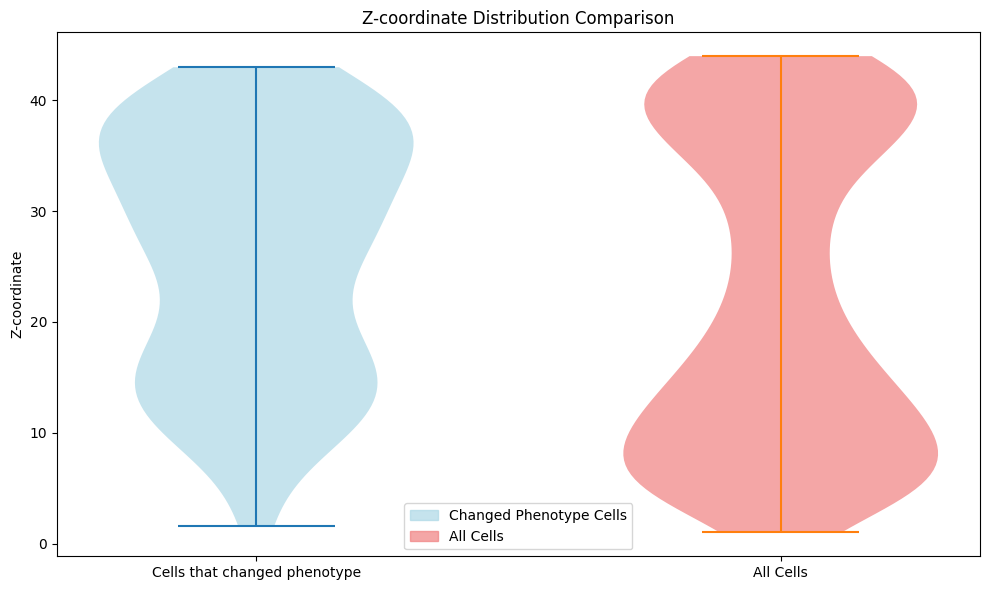

In [38]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

folder = r"C:\Users\6331823\Local SSD\Data_Anna\Exp137\MIX_s47"

props = pd.read_csv(os.path.join(folder, "properties", "Frame-13_props.csv"))
recalculated = pd.read_csv(os.path.join(folder, "properties_recalculated", "Frame-13_props.csv"))

# Find differences between two dataframes in the phenotype column
comparison = props.merge(recalculated, on = "label", suffixes=('_old', '_new'), how='outer', indicator=True)
data = comparison[comparison.phenotype_old != comparison.phenotype_new]

data = data[["label", "phenotype_old", "phenotype_new", "z_old", "log_ratio_wt_crc_old"]]

print(data)

labels = []
def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))


fig, ax = plt.subplots(figsize=(10, 6))

# Create violin plots
parts1 = ax.violinplot([data["z_old"]], positions=[1], widths=0.6)
parts2 = ax.violinplot([props["z"]], positions=[2], widths=0.6)

# Color the violin plots
for pc in parts1['bodies']:
    pc.set_facecolor('lightblue')
    pc.set_alpha(0.7)

for pc in parts2['bodies']:
    pc.set_facecolor('lightcoral')
    pc.set_alpha(0.7)

# Set labels and title
ax.set_xticks([1, 2])
ax.set_xticklabels(['Cells that changed phenotype', 'All Cells'])
ax.set_ylabel('Z-coordinate')
ax.set_title('Z-coordinate Distribution Comparison')

# Add legend
add_label(parts1, 'Changed Phenotype Cells')
add_label(parts2, 'All Cells')
ax.legend(*zip(*labels))

plt.tight_layout()
plt.show()

In [37]:
# found online
def solve_gasussians(m1, s1, m2, s2):
    a = 1.0 / (2.0 * s1**2) - 1.0 / (2.0 * s2**2)
    b = m2 / (s2**2) - m1 / (s1**2)
    c = m1**2 / (2 * s1**2) - m2**2 / (2.0 * s2**2) - np.log(s2 / s1)
    return np.roots([a, b, c])


def plot_gaussians(data):
    # Assuming data is already in shape (-1, 1)
    gmm = GaussianMixture(n_components=2, init_params="kmeans", random_state=0)
    gmm.fit(data)

    # Access the means of the Gaussian components
    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_.flatten())

    # Use the means and stds from your GMM
    mu1, mu2 = means
    sigma1, sigma2 = stds
    x_vals = np.linspace(data.min(), data.max(), 1000)
    pdf1 = norm(mu1, sigma1).pdf(x_vals)
    pdf2 = norm(mu2, sigma2).pdf(x_vals)

    if np.std(data) > 0.55:  # High SD, so it is a mixed sample
        # Make two gaussian distributions on the data and
        # calculate the intersection
        solved_val = solve_gasussians(mu1, sigma1, mu2, sigma2)
        cutoff = solved_val[1]
        print(f"Cutoff value (mixed sample): {cutoff:.2f}")

    elif data.mean() > 0:  # Means this sample is pure CRC
        cutoff = data.min() - 0.1

    elif data.mean() <= 0:  # Means this sample is pure WT
        cutoff = data.max() + 0.1

    print(
        f"Old WT cells: {np.sum(data.flatten() < cutoff) / len(data.flatten()) * 100:.2f}%"
    )
    print(
        f"Old CRC cells: {np.sum(data.flatten() >= cutoff) / len(data.flatten()) * 100:.2f}%"
    )
    print(
        f"New WT cells: {np.sum(data.flatten() < 0.356) / len(data.flatten()) * 100:.2f}%"
    )
    print(
        f"New CRC cells: {np.sum(data.flatten() >= 0.356) / len(data.flatten()) * 100:.2f}%"
    )

    # Plot as before
    plt.hist(data, bins=50, density=True, alpha=0.5, color="gray")
    x_vals = np.linspace(data.min(), data.max(), 1000)
    pdf1 = norm(mu1, sigma1).pdf(x_vals)
    pdf2 = norm(mu2, sigma2).pdf(x_vals)
    plt.plot(x_vals, pdf1, label="Gaussian 1")
    plt.plot(x_vals, pdf2, label="Gaussian 2")
    plt.axvline(cutoff, color="red", linestyle="--", label="Cutoff")
    plt.axvline(0.356, color="green", linestyle="--", label="New cutoff")
    plt.xlim(-3, 3)
    plt.legend()
    plt.show()

def calculate_cutoff(data):
    # Assuming data is already in shape (-1, 1)
    gmm = GaussianMixture(n_components=2, init_params="kmeans", random_state=0)
    gmm.fit(data)

    # Access the means of the Gaussian components
    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_.flatten())

    # Use the means and stds from your GMM
    mu1, mu2 = means
    sigma1, sigma2 = stds
    solved_val = solve_gasussians(mu1, sigma1, mu2, sigma2)
    cutoff = solved_val[1]
    return cutoff

MIX_s47
Cutoff value (mixed sample): -0.10
Old WT cells: 76.30%
Old CRC cells: 23.70%
New WT cells: 84.25%
New CRC cells: 15.75%


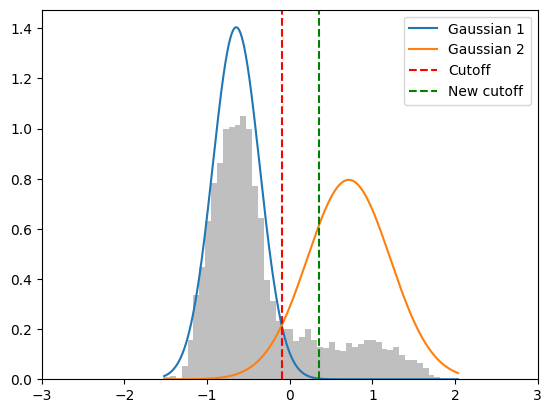

MIX_s48
Cutoff value (mixed sample): 1.03
Old WT cells: 32.39%
Old CRC cells: 67.61%
New WT cells: 27.05%
New CRC cells: 72.95%


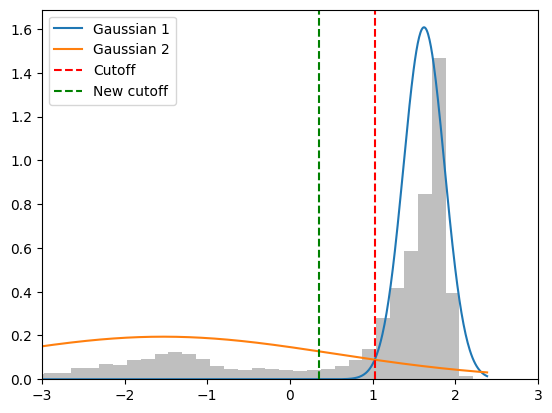

MIX_s52
Cutoff value (mixed sample): 0.14
Old WT cells: 90.63%
Old CRC cells: 9.37%
New WT cells: 91.64%
New CRC cells: 8.36%


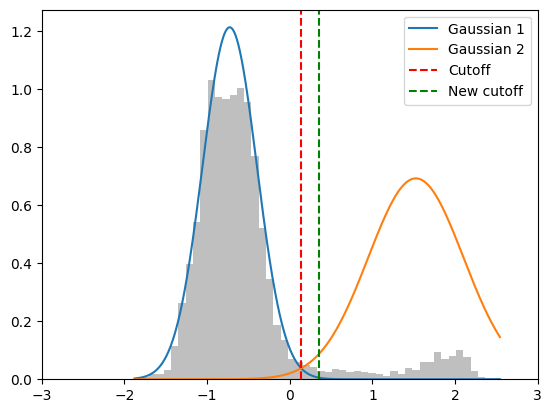

Mean cutoff across all samples: 0.35612976435123384
Cutoff value (mixed sample): 1.17
Old WT cells: 69.82%
Old CRC cells: 30.18%
New WT cells: 62.75%
New CRC cells: 37.25%


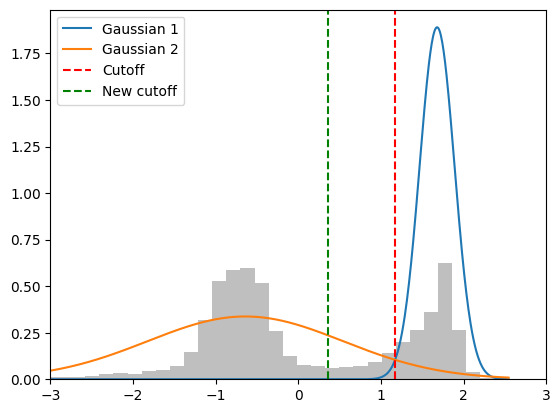

In [38]:
folders = r"C:\Users\6331823\Local SSD\Data_Anna\Exp137\MIX_s47\properties", r"C:\Users\6331823\Local SSD\Data_Anna\Exp137\MIX_s48\properties", r"C:\Users\6331823\Local SSD\Data_Anna\Exp137\MIX_s52\properties"

all_data = []
for folder in folders:
    for file in os.listdir(folder):
        if file.endswith(".csv"):
            data = pd.read_csv(os.path.join(folder, file))
            data.insert(0, "sample", os.path.basename(os.path.dirname(folder)))
        all_data.append(data)
all_data = pd.concat(all_data, ignore_index=True)

cutoffs = []
for sample in all_data["sample"].unique():
    print(sample)
    sample_data = all_data[all_data["sample"] == sample]
    plot_gaussians(sample_data["log_ratio_wt_crc"].to_numpy().reshape(-1, 1))
    cutoff = calculate_cutoff(sample_data["log_ratio_wt_crc"].to_numpy().reshape(-1, 1))
    cutoffs.append(cutoff)

mean_cutoff = np.mean(cutoffs)
print(f"Mean cutoff across all samples: {mean_cutoff}")

plot_gaussians(all_data["log_ratio_wt_crc"].to_numpy().reshape(-1, 1))

Opening readonly file: E:\MvL_Exp112_nonstained+Dapi\A_20x_F00.ims 

Closing file: E:\MvL_Exp112_nonstained+Dapi\A_20x_F00.ims 



c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\esda\moran.py:258: RuntimeWarning: invalid value encountered in scalar divide
  k = k_num / k_den
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\esda\moran.py:270: RuntimeWarning: invalid value encountered in scalar divide
  return self.n / s0 * inum / self.z2ss
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\esda\moran.py:227: RuntimeWarning: invalid value encountered in divide
  self.z /= sy


(3, 55, 464, 371)


<Image layer 'wt' at 0x249093c6390>

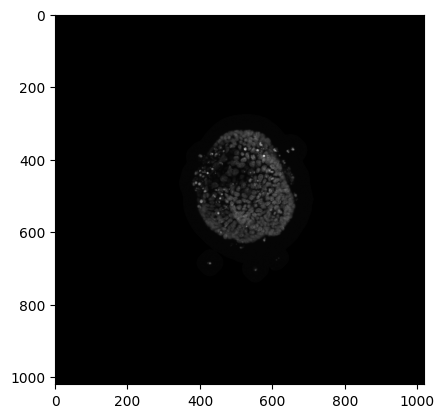

In [39]:
from imaris_ims_file_reader.ims import ims
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import numpy as np
import cv2
import pandas as pd

movie = ims(r"E:\MvL_Exp112_nonstained+Dapi\A_20x_F00.ims")

nuclei = movie[:, 0]

proj_XY = np.max(nuclei, axis=0)

frame = ndimage.gaussian_filter(proj_XY, sigma=(10, 10))

# Apply threshold (you can tweak the value)
median = np.median(frame)
_, binary_mask = cv2.threshold(frame, median + 5, 255, cv2.THRESH_BINARY)

binary_mask = ndimage.binary_dilation(binary_mask, iterations=10)

filled_mask = ndimage.binary_fill_holes(binary_mask).astype(np.uint8)
num_labels, labels, stats_array, centroids = cv2.connectedComponentsWithStats(
    filled_mask
)

center = np.array([frame.shape[0] // 2, frame.shape[1] // 2])

df = {
    "label": np.arange(1, num_labels),
    "area": stats_array[1:, cv2.CC_STAT_AREA],
    "centroid": [c for c in centroids[1:]],  # keep as array
}

df = pd.DataFrame(df)
# Compute distances to center
df["distance_to_center"] = df["centroid"].apply(
    lambda c: np.linalg.norm(center - c)
)

# Filter and select
filtered_df = df[df["area"] > 3000]
closest = filtered_df.loc[filtered_df["distance_to_center"].idxmin()]
selected_label = closest["label"]

# Create a binary mask for the selected label
selected_mask = (labels == selected_label).astype(np.uint8)
tracked = np.where(selected_mask > 0, proj_XY, 0)
plt.imshow(tracked, cmap="gray")

# Find the XY coordinates of the mask
maskXY = selected_mask > 0
coordsXY = np.where(maskXY)

# Adjust cropping limits based on XY projection, creating a bounding box around the organoid
if coordsXY[0].size > 0:
    row_min, row_max = (
        np.min(coordsXY[0]),
        np.max(coordsXY[0]) + 1,
    )
    col_min, col_max = (
        np.min(coordsXY[1]),
        np.max(coordsXY[1]) + 1,
    )

# Get a bounding box cropped version of the organoid
ref = nuclei[:, row_min:row_max, col_min:col_max]
ref_crop = selected_mask[row_min:row_max, col_min:col_max]


# In this bounding box image, create the Z axis of the same dimensions of the original movie
ref_expanded = ref_crop[np.newaxis, :, :]
ref_expanded = np.repeat(ref_expanded, ref.shape[0], axis=0)

# Use the this XYZ mask on the original movie to crop as both a bounding box and to make all pixels (corners) where there is no organoid actually black
ref_masked = np.where(ref_expanded > 0, ref, 0).astype(np.uint16)

# Make an max XZ projection that we will use to see what Z slices are important
XZ = np.max(ref_masked, axis=1)

# Apply offset to enhance contrast and make background and signal more distinct
XZ = offset_image(XZ, type="median")

z_list = []
moran_values = []  # Collect Moran’s I for all rows

# Step 1: Calculate Moran's I for each row
for idx, row in enumerate(XZ):
    coords = np.arange(len(row)).reshape(-1, 1)
    w_1d = KNN.from_array(coords, k=2)
    moran = Moran(row, w_1d)
    if not np.isnan(
        moran.I
    ):  # Make sure this value is not NA, which can happen in truly background / random data
        moran_values.append((idx, moran.I))  # store both index and value
    else:
        moran_values.append((idx, 0))

# Step 2: Calculate dynamic threshold based on max moran I value found
max_moran = max(val for _, val in moran_values)
threshold = 0.4 * max_moran

# Step 3: Filter Z slices using threshold
z_list = [idx for idx, val in moran_values if val >= threshold]

z_vals_sorted = sorted(set(z_list))
max_block = []
current_block = [z_vals_sorted[0]]

for i in range(1, len(z_vals_sorted)):
    if z_vals_sorted[i] - z_vals_sorted[i - 1] <= 6:
        current_block.append(z_vals_sorted[i])
    else:
        if len(current_block) > len(max_block):
            max_block = current_block
        current_block = [z_vals_sorted[i]]

# Final check in case the longest block ends the loop
if len(current_block) > len(max_block):
    max_block = current_block

slice_min = max(min(max_block) - 2, 0)
slice_max = min(max(max_block) + 2, ref.shape[0])

# This time, crop the frame of the movie on all channels using corrext XYZ
cropped_image = movie[
    :, :, slice_min:slice_max, row_min:row_max, col_min:col_max
]

# On this cropped frame, we again need to make it so that the pixels in the corners where no organoid is are actually black
mask_crop = maskXY[
    row_min:row_max, col_min:col_max
]  # shape: (Y_crop, X_crop)
# Expand mask to 4D: (C, Z, Y_crop, X_crop)
mask_expanded = mask_crop[np.newaxis, np.newaxis, :, :]
# Repeat over C and Z to match cropped_image shape
mask_expanded = np.repeat(
    mask_expanded, cropped_image.shape[0], axis=0
)  # C
mask_expanded = np.repeat(
    mask_expanded, cropped_image.shape[1], axis=1
)  # Z
# Apply the mask
cropped_image_masked = np.where(mask_expanded, cropped_image, 0).astype(
    np.uint16
)

print(cropped_image_masked.shape)

viewer = napari.Viewer()
viewer.add_image(cropped_image_masked[0], name= "nuclei", scale=(7, 1, 1), colormap="gray")
viewer.add_image(cropped_image_masked[1], name="crc", scale=(7, 1, 1), colormap = "green")
viewer.add_image(cropped_image_masked[2], name="wt", scale=(7, 1, 1), colormap = "magenta")

In [54]:
import napari
import pandas as pd

viewer = napari.Viewer()

data = pd.read_csv(r"C:\Users\6331823\Local SSD\Data_Merel\A_20x_F05\properties\Frame-0_props.csv")
wt = data[data["phenotype"] == "wt"]
crc = data[data["phenotype"] == "crc"]
movie = tifffile.imread(r"C:\Users\6331823\Local SSD\Data_Merel\A_20x_F05\cropped\Frame-0.tif")
segmentation = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Merel\A_20x_F05\segmented\Frame-0_masks.tif"
)

# Create 3D coordinates
coords_3d_wt = wt[
    [
        "z_pixel",
        "y_pixel",
        "x_pixel",
    ]
].to_numpy()
coords_3d_crc = crc[
    [
        "z_pixel",
        "y_pixel",
        "x_pixel",
    ]
].to_numpy()

# Add points to the viewer
viewer.add_points(coords_3d_wt, size=5, scale=(3.9,1,1), face_color='magenta', blending="additive", name="Cell centers_wt")
viewer.add_points(coords_3d_crc, size=5, scale=(3.9,1,1), face_color='green', blending="additive", name="Cell centers_crc")
viewer.add_image(movie[0], name="Nuclei", scale=(3.9, 1, 1), blending="additive", contrast_limits=[0, 3000])
viewer.add_image(movie[1], name="CRC", scale=(3.9, 1, 1), blending="additive",contrast_limits=[0, 2000], colormap="green")
viewer.add_image(movie[2], name="WT", scale=(3.9, 1, 1), blending="additive",contrast_limits=[0, 5000], colormap="magenta")
viewer.add_labels(
    segmentation, name="Segmentation", scale=(3.9, 1, 1), blending="additive"
)

<Labels layer 'Segmentation' at 0x2498b03a910>

In [1]:
# Analyse merel
import pandas as pd
import os
import re

folder_types = {
    range(0, 5): "WT Control 1",
    range(5, 15): "Mix Control 1",
    range(15, 20): "CRC Control 1",
    range(20, 25): "WT Control 2",
    range(25, 35): "Mix Control 2",
    range(35, 40): "CRC Control 2",
    range(40, 45): "WT Treated 1",
    range(45, 55): "Mix Treated 1",
    range(55, 60): "CRC Treated 1",
    range(60, 65): "WT Treated 2",
    range(65, 75): "Mix Treated 2",
    range(75, 80): "CRC Treated 2",
}

input_directory = r"C:\Users\6331823\Local SSD\Data_Merel"

data = []
for folder in os.listdir(input_directory):
    if os.path.isdir(os.path.join(input_directory, folder)):
        sub_data = pd.read_csv(
            os.path.join(input_directory, folder, "properties", "Frame-0_props.csv")
        )
        sub_data.insert(0, "sample", folder)
        match = re.search(r"F(\d+)", folder)
        folder_num = int(match.group(1))
        for num_range, type_val in folder_types.items():
            if folder_num in num_range:
                type = type_val
                break

        sub_data.insert(0, "type", type)
        data.append(sub_data)

data = pd.concat(data, ignore_index=True)

phenotype          type     sample  crc    wt  total_cells  percent_crc  \
65         WT Control 2  A_20x_F20    0   613          613     0.000000   
66         WT Control 2  A_20x_F21    0   578          578     0.000000   
67         WT Control 2  A_20x_F22    0   766          766     0.000000   
68         WT Control 2  A_20x_F23  185  1556         1741    10.626077   
69         WT Control 2  A_20x_F24  165   593          758    21.767810   

phenotype  percent_wt  
65         100.000000  
66         100.000000  
67         100.000000  
68          89.373923  
69          78.232190  


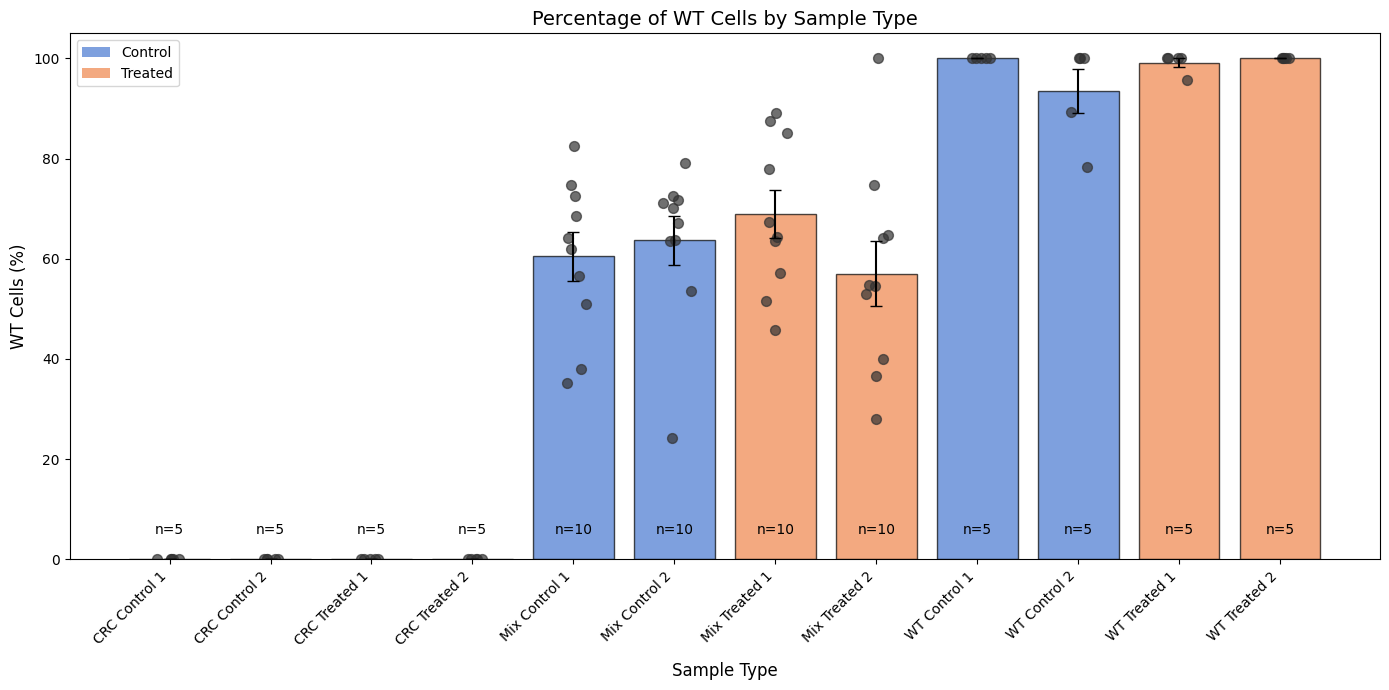

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
# Get a table that shows the total amount of WT and CRC phenotypes per sample
summary = (
    data.groupby(["type", "sample", "phenotype"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Remove phenotype column
summary["total_cells"] = summary["crc"] + summary["wt"]
summary["percent_crc"] = summary["crc"] / summary["total_cells"] * 100
summary["percent_wt"] = summary["wt"] / summary["total_cells"] * 100
print(summary[summary["type"] == "WT Control 2"])
# Calculate statistics for each type
type_stats = (
    summary.groupby("type")["percent_wt"].agg(["mean", "sem", "count"]).reset_index()
)

# Create figure
plt.figure(figsize=(14, 7))

# Create custom color palette based on sample types
colors = {"Control": "#4878D0", "Treated": "#EE854A"}
bar_colors = [
    colors["Control"] if "Control" in t else colors["Treated"]
    for t in type_stats["type"]
]

# Plot bars with error bars
bar_positions = np.arange(len(type_stats))
bars = plt.bar(
    bar_positions,
    type_stats["mean"],
    yerr=type_stats["sem"],
    capsize=4,
    alpha=0.7,
    color=bar_colors,
    edgecolor="black",
)

# Add individual data points
for i, type_name in enumerate(type_stats["type"]):
    # Get data points for this type
    points = summary[summary["type"] == type_name]["percent_wt"]
    # Add jittered points
    x_jitter = np.random.normal(i, 0.07, size=len(points))
    plt.scatter(x_jitter, points, color="#333333", alpha=0.7, s=50)

# Customize axes
plt.xticks(bar_positions, type_stats["type"], rotation=45, ha="right")
plt.xlabel("Sample Type", fontsize=12, labelpad=10)
plt.ylabel("WT Cells (%)", fontsize=12)
plt.title("Percentage of WT Cells by Sample Type", fontsize=14)

# Add sample counts
for i, stats_row in enumerate(type_stats.itertuples()):
    plt.text(i, 5, f"n={stats_row.count}", ha="center", fontsize=10)

# Add legend
ctrl_patch = plt.Rectangle((0, 0), 1, 1, fc=colors["Control"], alpha=0.7)
treated_patch = plt.Rectangle((0, 0), 1, 1, fc=colors["Treated"], alpha=0.7)
plt.legend([ctrl_patch, treated_patch], ["Control", "Treated"], loc="upper left")

# Adjust layout and show
plt.tight_layout()
plt.show()

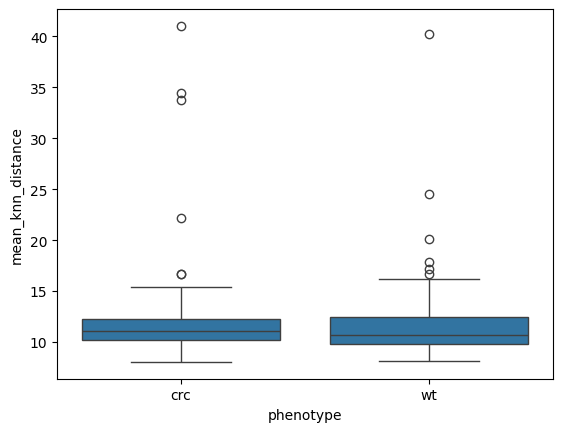

In [110]:
test = data[data["sample"] == "A_20x_F06"]

sns.boxplot(x="phenotype", y="mean_knn_distance", data=test)
plt.show()

In [3]:
input_directory = r"C:\Users\6331823\Local SSD\Data_Merel"

for folder in os.listdir(input_directory):
    path = os.path.join(input_directory, folder, "cropped", "Frame-0.tif")
    image = tifffile.imread(path)
    nuclei = image[0]

    # Get 4 random z slices
    z_slices = np.random.choice(nuclei.shape[0], size=4, replace=False)
    for z in z_slices:
        slice = nuclei[z]
        tifffile.imwrite(
            rf"C:\Users\6331823\Local SSD\Train model fixed intestinal organoid\{folder}_slice_{z}", slice
        )

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\6331823\\Local SSD\\Data_Merel\\full_results.csv\\cropped\\Frame-0.tif'

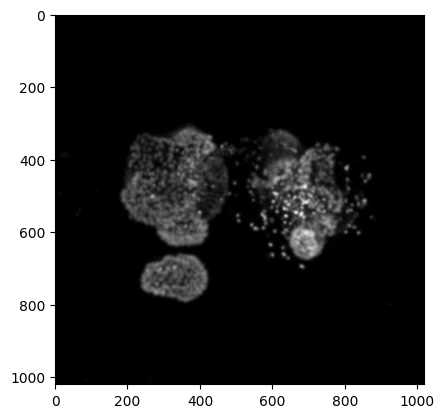

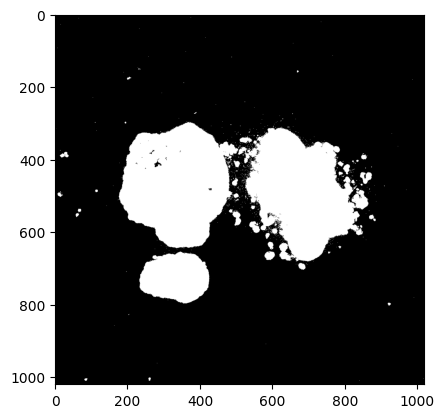

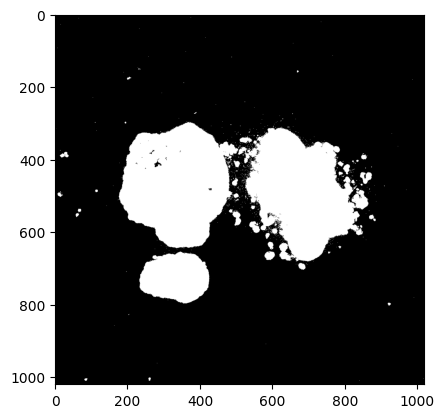

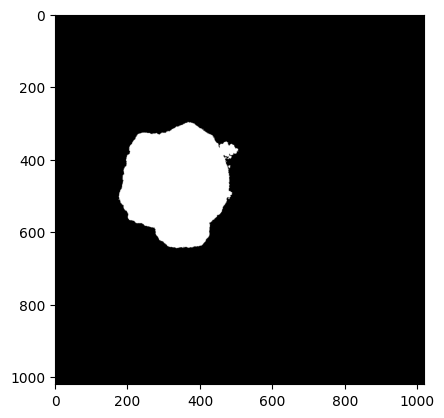

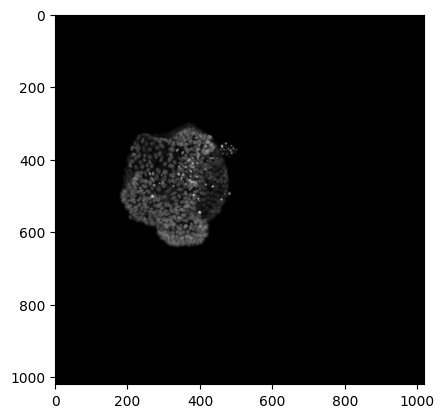

In [15]:
from scipy import ndimage
import cv2
import matplotlib.pyplot as plt

proj_XY = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Merel\A_20x_F63\A_20x_F63_projXY.tif"
)

# Apply gaussian filter to smooth the image and make thresholding more robust
frame = ndimage.gaussian_filter(proj_XY, sigma=(3, 3))

plt.imshow(frame, cmap="gray")
plt.show()

# Apply threshold (you can tweak the value)
median = np.median(proj_XY)
_, binary_mask = cv2.threshold(proj_XY, median + 30, 255, cv2.THRESH_BINARY)

plt.imshow(binary_mask, cmap="gray")
plt.show()

# binary_mask = ndimage.binary_dilation(binary_mask, iterations=5)

plt.imshow(binary_mask, cmap="gray")
plt.show()

filled_mask = ndimage.binary_fill_holes(binary_mask).astype(np.uint8)
num_labels, labels, stats_array, centroids = cv2.connectedComponentsWithStats(
    filled_mask
)

df = {
    "label": np.arange(1, num_labels),
    "area": stats_array[1:, cv2.CC_STAT_AREA],
    "centroid": [c for c in centroids[1:]],  # keep as array
}
df = pd.DataFrame(df)

# Filter and select
filtered_df = df[df["area"] == df["area"].max()]
selected_label = filtered_df["label"].values[0]

# Create a binary mask for the selected label
selected_mask = (labels == selected_label).astype(np.uint8)

plt.imshow(selected_mask, cmap="gray")
plt.show()

organoid_only = np.where(selected_mask > 0, proj_XY, 0)

plt.imshow(organoid_only, cmap="gray")
plt.show()

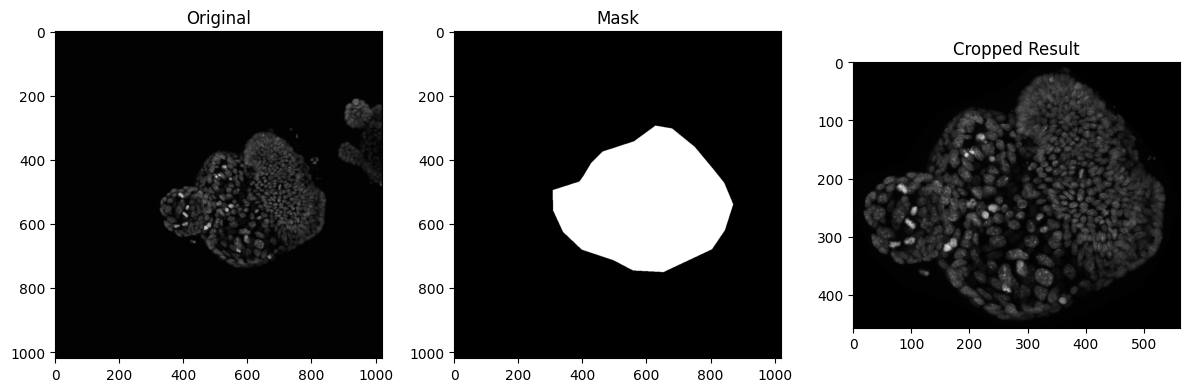

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def polygon_selection(image):
    """
    Allow user to select a polygon region by clicking points.
    Press 'c' to complete the selection.
    """
    # Make a copy of the image for drawing
    draw_image = image.copy()
    points = []

    # Mouse callback function
    def draw_polygon(event, x, y, flags, param):
        nonlocal draw_image

        # Left button click - add point
        if event == cv2.EVENT_LBUTTONDOWN:
            points.append((x, y))
            # Draw a small circle at clicked point
            cv2.circle(draw_image, center=(x, y), radius=3, color=(255, 255, 0), thickness=-1)

            # Connect lines between points
            if len(points) > 1:
                cv2.line(draw_image, points[-2], points[-1], thickness= 1, color=(255, 0, 0))

            # Show the image with selected points
            cv2.imshow("Select Polygon - Press C when done", draw_image)

    # Create window and set mouse callback
    cv2.imshow("Select Polygon - Press C when done", image)
    cv2.setMouseCallback("Select Polygon - Press C when done", draw_polygon)

    # Wait for key press
    while True:
        key = cv2.waitKey(1) & 0xFF
        if key == ord("c"):  # Press 'c' to complete
            break

    # Close the window
    cv2.destroyAllWindows()

    # Create mask from polygon if we have enough points
    if len(points) > 2:
        mask = np.zeros(image.shape[:2], dtype=np.uint8)
        points_array = np.array([points], dtype=np.int32)
        cv2.fillPoly(mask, points_array, 255)

        # Apply mask to extract region
        result = cv2.bitwise_and(image, image, mask=mask)

        # Get bounding box of non-zero region (for cropping)
        x, y, w, h = cv2.boundingRect(mask)
        cropped = result[y : y + h, x : x + w]

        return mask, result, cropped
    else:
        print("Not enough points selected for polygon")
        return None, None, None


# Load and process image
image = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Merel\A_20x_F14\A_20x_F14_projXY.tif"
)
# gray_image = np.max(image, axis=2).astype(np.uint8)
# add fake rGB channel axis

normalized_image = cv2.normalize(image[:,:], None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Get polygon selection
mask, masked_result, cropped_result = polygon_selection(normalized_image)

if mask is not None:
    # Display results
    plt.figure(figsize=(12, 4))
    plt.subplot(131), plt.imshow(normalized_image, cmap="gray"), plt.title("Original")
    plt.subplot(132), plt.imshow(mask, cmap="gray"), plt.title("Mask")
    plt.subplot(133), plt.imshow(cropped_result, cmap="gray"), plt.title("Cropped Result")
    # plt.subplot(134), plt.imshow(cropped_result, cmap="gray"), plt.title(
    #     "Cropped Result"
    # )
    plt.tight_layout()
    plt.show()

In [12]:
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.ndimage as ndimage
import tifffile
import napari

input_directory = r"C:\Users\6331823\Local SSD\Data_Merel"
viewer = napari.Viewer()

for folder in os.listdir(input_directory):
    path = os.path.join(input_directory, folder, f"{folder}_projXY.tif")
    proj_XY = tifffile.imread(path)

    viewer.add_image(proj_XY, name=f"{folder}_projXY")
    # Apply gaussian filter to smooth the image and make thresholding more robust
    frame = ndimage.gaussian_filter(proj_XY, sigma=(3, 3))

    # Apply threshold (you can tweak the value)
    median = np.median(frame)
    _, binary_mask = cv2.threshold(frame, median + 5, 255, cv2.THRESH_BINARY)

    binary_mask = ndimage.binary_dilation(binary_mask, iterations=5)

    filled_mask = ndimage.binary_fill_holes(binary_mask).astype(np.uint8)
    num_labels, labels, stats_array, centroids = cv2.connectedComponentsWithStats(
        filled_mask
    )

    center = np.array([frame.shape[0] // 2, frame.shape[1] // 2])

    df = {
        "label": np.arange(1, num_labels),
        "area": stats_array[1:, cv2.CC_STAT_AREA],
        "centroid": [c for c in centroids[1:]],  # keep as array
    }

    df = pd.DataFrame(df)
    # Compute distances to center
    df["distance_to_center"] = df["centroid"].apply(
        lambda c: np.linalg.norm(center - c)
    )

    # Filter and select
    filtered_df = df[df["area"] > 3000]
    closest = filtered_df.loc[filtered_df["distance_to_center"].idxmin()]

    area = closest["area"]
    if area > 200000:
        print(f"Folder: {folder}, Organoid too large with area: {closest['area']}")


Folder: A_20x_F12, Organoid too large with area: 296697
Folder: A_20x_F13, Organoid too large with area: 324702
Folder: A_20x_F25, Organoid too large with area: 478300
Folder: A_20x_F29, Organoid too large with area: 242798
Folder: A_20x_F32, Organoid too large with area: 418552
Folder: A_20x_F34, Organoid too large with area: 241714
Folder: A_20x_F42, Organoid too large with area: 323554
Folder: A_20x_F46, Organoid too large with area: 219598
Folder: A_20x_F47, Organoid too large with area: 217187
Folder: A_20x_F52, Organoid too large with area: 437929
Folder: A_20x_F63, Organoid too large with area: 281402
Folder: A_20x_F68, Organoid too large with area: 276389
Folder: A_20x_F71, Organoid too large with area: 217828
Folder: A_20x_F72, Organoid too large with area: 389694
Folder: A_20x_F73, Organoid too large with area: 287309
Folder: A_20x_F76, Organoid too large with area: 263167


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\6331823\\Local SSD\\Data_Merel\\full_results.csv\\full_results.csv_projXY.tif'

In [28]:
input_directory = r"C:\Users\6331823\Local SSD\Data_Merel\A_20x_F00"

image = tifffile.imread(os.path.join(input_directory, "cropped", "Frame-0.tif"))

segmentation = tifffile.imread(os.path.join(input_directory, "segmented", "Frame-0_masks.tif"))
viewer = napari.Viewer()
viewer.add_image(image[:,0], name="Nuclei", scale=(7,1,1), blending="additive", contrast_limits=[0, 3000])
viewer.add_image(image[:,1], name="CRC", scale=(7,1,1), blending="additive", contrast_limits=[0, 2000], colormap="green")
viewer.add_image(image[:,2], name="WT", scale=(7,1,1), blending="additive", contrast_limits=[0, 5000], colormap="magenta")
viewer.add_labels(segmentation, name="Segmentation", scale=(7,1,1), blending="additive")

<Labels layer 'Segmentation' at 0x15d261b4e50>

In [65]:
import os
import pandas as pd
import matplotlib.pyplot as plt

input_directory = r"C:\Users\6331823\Local SSD\Data_Anna\Exp137"

data = []
for folder in os.listdir(input_directory):
    if os.path.isdir(os.path.join(input_directory, folder)):
        path = os.path.join(input_directory, folder, "properties")
        for file in os.listdir(path):
            if file.endswith(".csv"):
                file_path = os.path.join(path, file)
                sub_data = pd.read_csv(file_path)
                sub_data.insert(0, "sample", folder)
                if folder.startswith("MIX"):
                    sub_data.insert(0, "type", "Mix")
                elif folder.startswith("WT"):
                    sub_data.insert(0, "type", "WT_pure")
                elif folder.startswith("CRC"):
                    sub_data.insert(0, "type", "CRC_pure")
                data.append(sub_data)
data = pd.concat(data, ignore_index=True)


In [71]:
data

,sample,frame,label,z,y,x,bounding_box,volume,raw_crc,raw_wt,ratio_crc_wt,log_ratio_crc_wt,ratio_wt_crc,log_ratio_wt_crc,phenotype,mean_knn_distance,5_knn_neighbors,cell_id,phenotype_similarity_score
0,MIX_s47,0,1,3.000000,38.207921,99.673267,"(3, 34, 94, 4, 44, 107)",101.0,11.831683,16.000000,0.739480,-0.131073,1.352301,0.131074,wt,11.685853,[14 29 9 21 3],0,2
1,MIX_s47,0,2,3.594306,42.204626,73.601423,"(3, 33, 63, 5, 53, 85)",562.0,23.475089,5.635231,4.165771,0.619696,0.240052,-0.619694,crc,18.842951,[34 36 2 12 3],1,4
2,MIX_s47,0,3,3.494157,50.949917,53.388982,"(3, 38, 42, 5, 65, 68)",599.0,13.767947,2.677796,5.141520,0.711092,0.194495,-0.711089,crc,17.777044,[37 12 10 36 1],2,5
3,MIX_s47,0,4,3.598131,51.638629,95.757009,"(3, 45, 88, 5, 60, 105)",321.0,14.763240,2.822430,5.230683,0.718558,0.191180,-0.718556,crc,16.324346,[14 0 21 31 22],3,4
4,MIX_s47,0,5,3.000000,75.413043,54.206522,"(3, 71, 49, 4, 81, 60)",92.0,8.695652,12.293478,0.707339,-0.150372,1.413750,0.150373,wt,15.904753,[ 6 7 12 32 37],4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20902,MIX_s52,9,622,36.000000,234.833333,195.893939,"(36, 231, 192, 37, 240, 201)",66.0,10.212121,2.484848,4.109755,0.613816,0.243324,-0.613814,crc,14.039459,[607 625 583 588 582],621,5
20903,MIX_s52,9,623,37.376471,171.823529,184.129412,"(37, 166, 176, 39, 179, 192)",255.0,7.690196,3.760784,2.044838,0.310659,0.489036,-0.310658,crc,18.849199,[623 597 617 616 598],622,5
20904,MIX_s52,9,624,37.000000,187.131868,187.912088,"(37, 182, 183, 38, 193, 194)",91.0,8.406593,3.703297,2.270029,0.356032,0.440523,-0.356030,crc,19.980402,[598 622 597 617 580],623,5
20905,MIX_s52,9,625,37.000000,205.327103,165.102804,"(37, 199, 158, 38, 211, 172)",107.0,6.990654,2.654206,2.633802,0.420583,0.379679,-0.420582,crc,17.577339,[619 606 601 580 605],624,5


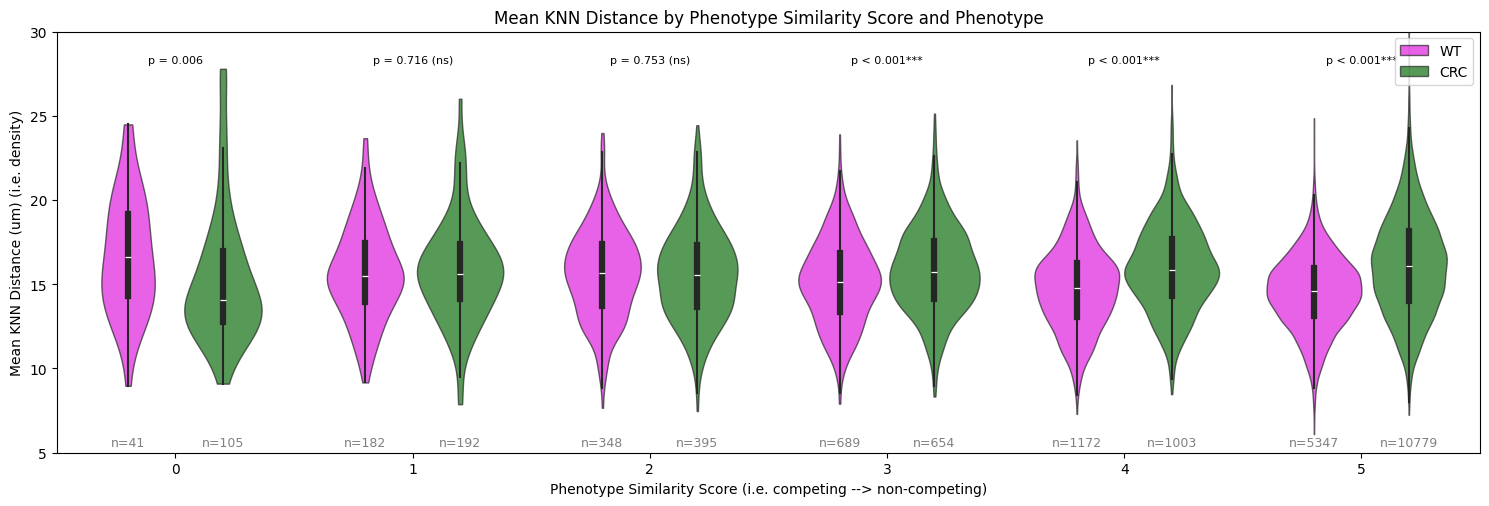

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

plt.figure(figsize=(15, 5))

# Define color palette
palette = {"wt": "magenta", "crc": "green"}

# Use seaborn's violinplot with split option for side-by-side comparison
ax = sns.violinplot(
    data=data,
    x="phenotype_similarity_score",
    y="mean_knn_distance",
    hue="phenotype",
    palette=palette,
    linewidth=1,
    alpha=0.7,
    dodge=True,  # This creates the offset effect
    cut = 0,
    
)

# Add sample counts and p-values for each score
for score in data["phenotype_similarity_score"].unique():
    wt_subset = data[
        (data["phenotype_similarity_score"] == score) & (data["phenotype"] == "wt")
    ]["mean_knn_distance"].dropna()

    crc_subset = data[
        (data["phenotype_similarity_score"] == score) & (data["phenotype"] == "crc")
    ]["mean_knn_distance"].dropna()

    # Only calculate p-value if both groups have data
    if len(wt_subset) > 0 and len(crc_subset) > 0:
        # Use Mann-Whitney U test (non-parametric) or t-test
        # Mann-Whitney is more robust for non-normal distributions
        statistic, p_value = stats.mannwhitneyu(
            wt_subset, crc_subset, alternative="two-sided"
        )

        # Format p-value for display
        if p_value < 0.001:
            p_text = "p < 0.001***"
        elif p_value < 0.01:
            p_text = f"p = {p_value:.3f}"
        elif p_value < 0.05:
            p_text = f"p = {p_value:.3f}"
        else:
            p_text = f"p = {p_value:.3f} (ns)"

        ax.text(
            score,
            28,
            p_text,
            ha="center",
            va="bottom",
            fontsize=8,
        )


# Add sample counts behind each violin
# Get unique combinations of score and phenotype
for score in data["phenotype_similarity_score"].unique():
    for i, phenotype in enumerate(["wt", "crc"]):
        subset = data[
            (data["phenotype_similarity_score"] == score)
            & (data["phenotype"] == phenotype)
        ]
        n = len(subset)

        if n > 0:
            # Calculate x position (offset for dodge)
            x_pos = score + (i - 0.5) * 0.4  # Adjust offset to match dodge spacing

            # Add text at the bottom of the plot
            ax.text(x_pos, 6, f"n={n}", ha="center", va="top", fontsize=9, color="gray")


plt.xlabel("Phenotype Similarity Score (i.e. competing --> non-competing)")
plt.ylabel("Mean KNN Distance (um) (i.e. density)")
plt.ylim(5, 30)
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, ["WT", "CRC"], loc="upper right")
plt.tight_layout()
plt.title("Mean KNN Distance by Phenotype Similarity Score and Phenotype")
plt.show()

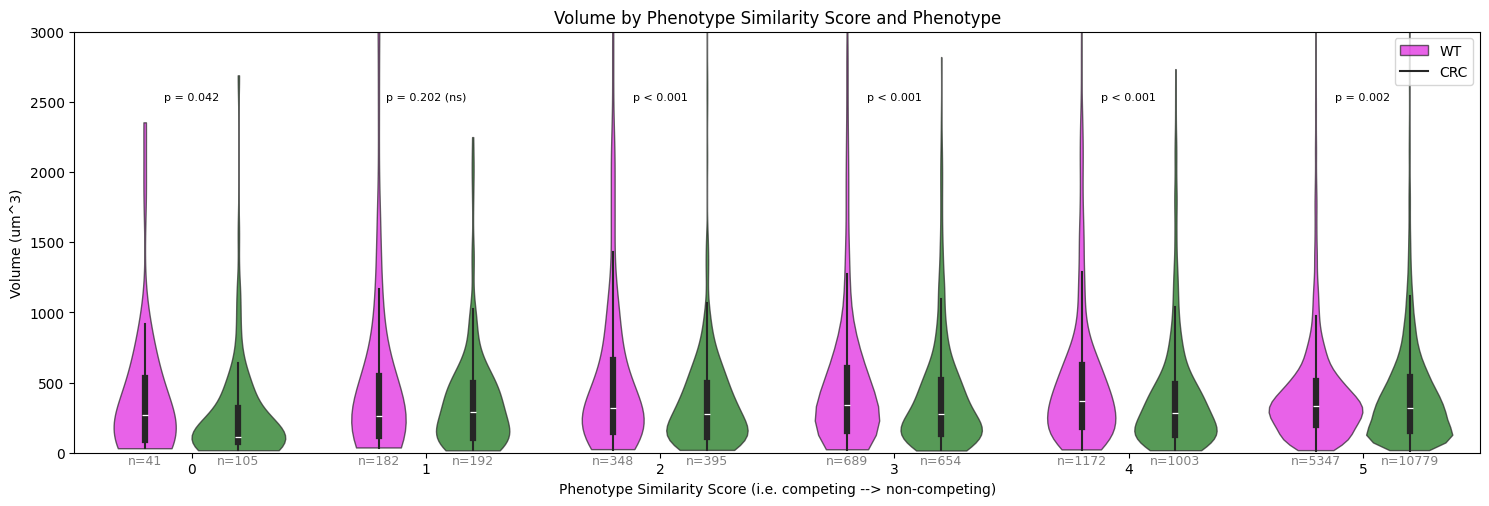

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(15, 5))

# Define color palette
palette = {"wt": "magenta", "crc": "green"}

# Use seaborn's violinplot with split option for side-by-side comparison
ax = sns.violinplot(
    data=data,
    x="phenotype_similarity_score",
    y="volume",
    hue="phenotype",
    palette=palette,
    linewidth=1,
    alpha=0.7,
    dodge=True,
    cut = 0,
)

# Add sample counts and p-values for each score
for score in data["phenotype_similarity_score"].unique():
    wt_subset = data[
        (data["phenotype_similarity_score"] == score) & (data["phenotype"] == "wt")
    ]["volume"].dropna()

    crc_subset = data[
        (data["phenotype_similarity_score"] == score) & (data["phenotype"] == "crc")
    ]["volume"].dropna()

    # Only calculate p-value if both groups have data
    if len(wt_subset) > 0 and len(crc_subset) > 0:
        # Use Mann-Whitney U test (non-parametric) or t-test
        # Mann-Whitney is more robust for non-normal distributions
        statistic, p_value = stats.mannwhitneyu(
            wt_subset, crc_subset, alternative="two-sided"
        )

        # Format p-value for display
        if p_value < 0.001:
            p_text = "p < 0.001"
        elif p_value < 0.01:
            p_text = f"p = {p_value:.3f}"
        elif p_value < 0.05:
            p_text = f"p = {p_value:.3f}"
        else:
            p_text = f"p = {p_value:.3f} (ns)"

        ax.text(
            score,
            2500,
            p_text,
            ha="center",
            va="bottom",
            fontsize=8,
        )

# Add sample counts behind each violin
# Get unique combinations of score and phenotype
for score in data["phenotype_similarity_score"].unique():
    for i, phenotype in enumerate(["wt", "crc"]):
        subset = data[
            (data["phenotype_similarity_score"] == score)
            & (data["phenotype"] == phenotype)
        ]
        n = len(subset)

        if n > 0:
            # Calculate x position (offset for dodge)
            x_pos = score + (i - 0.5) * 0.4  # Adjust offset to match dodge spacing

            # Add text at the bottom of the plot
            ax.text(x_pos, -10, f"n={n}", ha="center", va="top", fontsize=9, color="gray")


plt.xlabel("Phenotype Similarity Score (i.e. competing --> non-competing)")
plt.ylabel("Volume (um^3)")
plt.ylim(0, 3000)
plt.legend(labels=["WT", "CRC"], loc="upper right")
plt.tight_layout()
plt.title("Volume by Phenotype Similarity Score and Phenotype")
plt.show()

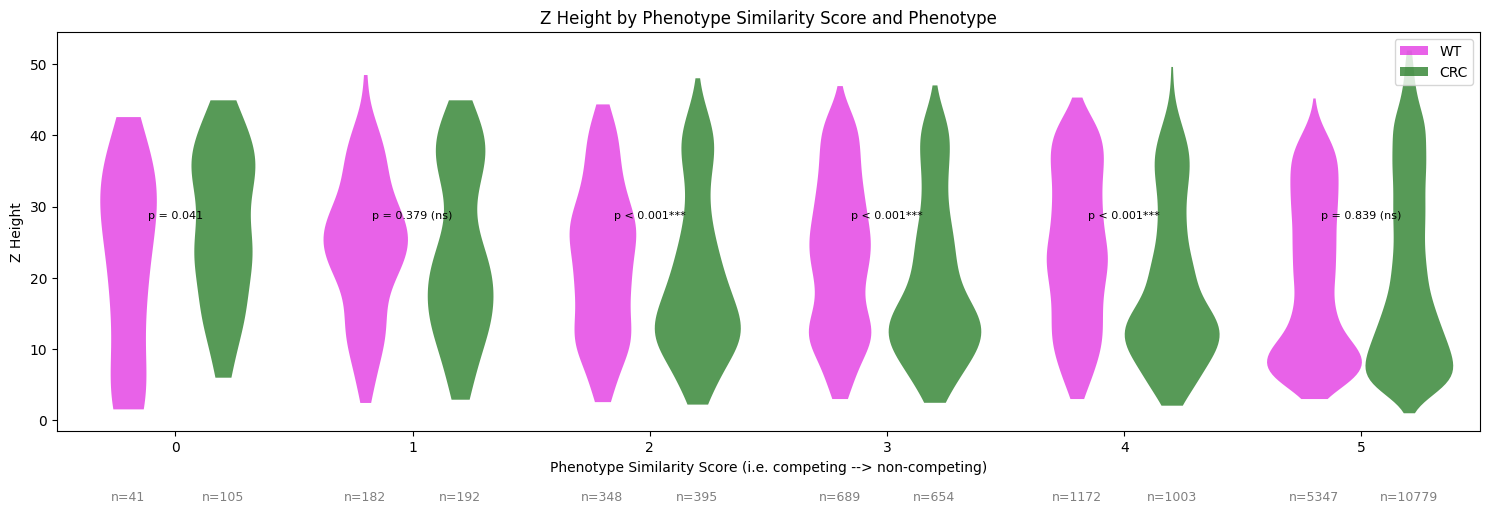

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(15, 5))

# Define color palette
palette = {"wt": "magenta", "crc": "green"}

# Use seaborn's violinplot with split option for side-by-side comparison
ax = sns.violinplot(
    data=data,
    x="phenotype_similarity_score",
    y="z",
    hue="phenotype",
    palette=palette,
    split=False,
    inner=None,
    linewidth=0,
    alpha=0.7,
    dodge=True,
    cut=0,
)

# Add sample counts and p-values for each score
for score in data["phenotype_similarity_score"].unique():
    wt_subset = data[
        (data["phenotype_similarity_score"] == score) & (data["phenotype"] == "wt")
    ]["z"].dropna()

    crc_subset = data[
        (data["phenotype_similarity_score"] == score) & (data["phenotype"] == "crc")
    ]["z"].dropna()

    # Only calculate p-value if both groups have data
    if len(wt_subset) > 0 and len(crc_subset) > 0:
        # Use Mann-Whitney U test (non-parametric) or t-test
        # Mann-Whitney is more robust for non-normal distributions
        statistic, p_value = stats.mannwhitneyu(
            wt_subset, crc_subset, alternative="two-sided"
        )

        # Format p-value for display
        if p_value < 0.001:
            p_text = "p < 0.001***"
        elif p_value < 0.01:
            p_text = f"p = {p_value:.3f}"
        elif p_value < 0.05:
            p_text = f"p = {p_value:.3f}"
        else:
            p_text = f"p = {p_value:.3f} (ns)"

        ax.text(
            score,
            28,
            p_text,
            ha="center",
            va="bottom",
            fontsize=8,
        )

# Add sample counts behind each violin
# Get unique combinations of score and phenotype
for score in data["phenotype_similarity_score"].unique():
    for i, phenotype in enumerate(["wt", "crc"]):
        subset = data[
            (data["phenotype_similarity_score"] == score)
            & (data["phenotype"] == phenotype)
        ]
        n = len(subset)

        if n > 0:
            # Calculate x position (offset for dodge)
            x_pos = score + (i - 0.5) * 0.4  # Adjust offset to match dodge spacing

            # Add text at the bottom of the plot
            ax.text(
                x_pos, -10, f"n={n}", ha="center", va="top", fontsize=9, color="gray"
            )


plt.xlabel("Phenotype Similarity Score (i.e. competing --> non-competing)")
plt.ylabel("Z Height")

plt.legend(labels=["WT", "CRC"], loc="upper right")
plt.tight_layout()
plt.title("Z Height by Phenotype Similarity Score and Phenotype")
plt.show()

In [9]:
data

,sample,frame,label,z,y,x,bounding_box,volume,raw_crc,raw_wt,ratio_crc_wt,log_ratio_crc_wt,ratio_wt_crc,log_ratio_wt_crc,phenotype,mean_knn_distance,5_knn_neighbors,cell_id,phenotype_similarity_score
0,MIX_s47,0,1,3.000000,38.207921,99.673267,"(3, 34, 94, 4, 44, 107)",101.0,11.831683,16.000000,0.739480,-0.131073,1.352301,0.131074,wt,11.685853,[14 29 9 21 3],0,2
1,MIX_s47,0,2,3.594306,42.204626,73.601423,"(3, 33, 63, 5, 53, 85)",562.0,23.475089,5.635231,4.165771,0.619696,0.240052,-0.619694,crc,18.842951,[34 36 2 12 3],1,4
2,MIX_s47,0,3,3.494157,50.949917,53.388982,"(3, 38, 42, 5, 65, 68)",599.0,13.767947,2.677796,5.141520,0.711092,0.194495,-0.711089,crc,17.777044,[37 12 10 36 1],2,5
3,MIX_s47,0,4,3.598131,51.638629,95.757009,"(3, 45, 88, 5, 60, 105)",321.0,14.763240,2.822430,5.230683,0.718558,0.191180,-0.718556,crc,16.324346,[14 0 21 31 22],3,4
4,MIX_s47,0,5,3.000000,75.413043,54.206522,"(3, 71, 49, 4, 81, 60)",92.0,8.695652,12.293478,0.707339,-0.150372,1.413750,0.150373,wt,15.904753,[ 6 7 12 32 37],4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20902,MIX_s52,9,622,36.000000,234.833333,195.893939,"(36, 231, 192, 37, 240, 201)",66.0,10.212121,2.484848,4.109755,0.613816,0.243324,-0.613814,crc,14.039459,[607 625 583 588 582],621,5
20903,MIX_s52,9,623,37.376471,171.823529,184.129412,"(37, 166, 176, 39, 179, 192)",255.0,7.690196,3.760784,2.044838,0.310659,0.489036,-0.310658,crc,18.849199,[623 597 617 616 598],622,5
20904,MIX_s52,9,624,37.000000,187.131868,187.912088,"(37, 182, 183, 38, 193, 194)",91.0,8.406593,3.703297,2.270029,0.356032,0.440523,-0.356030,crc,19.980402,[598 622 597 617 580],623,5
20905,MIX_s52,9,625,37.000000,205.327103,165.102804,"(37, 199, 158, 38, 211, 172)",107.0,6.990654,2.654206,2.633802,0.420583,0.379679,-0.420582,crc,17.577339,[619 606 601 580 605],624,5


In [ ]:
x = data.loc[
    :,
    data.columns.isin(
        [
            "z",
            "y",
            "x",
            "volume",
            "raw_crc",
            "raw_wt",
            "log_ratio_wt_crc",
            "mean_knn_distance",
            "phenotype_similarity_score",
        ]
    ),
].values

{"WT_pure": "magenta", "Mix": "gray", "CRC_pure": "green"}

Explained variability per principal component: [0.44813169 0.3284042 ]


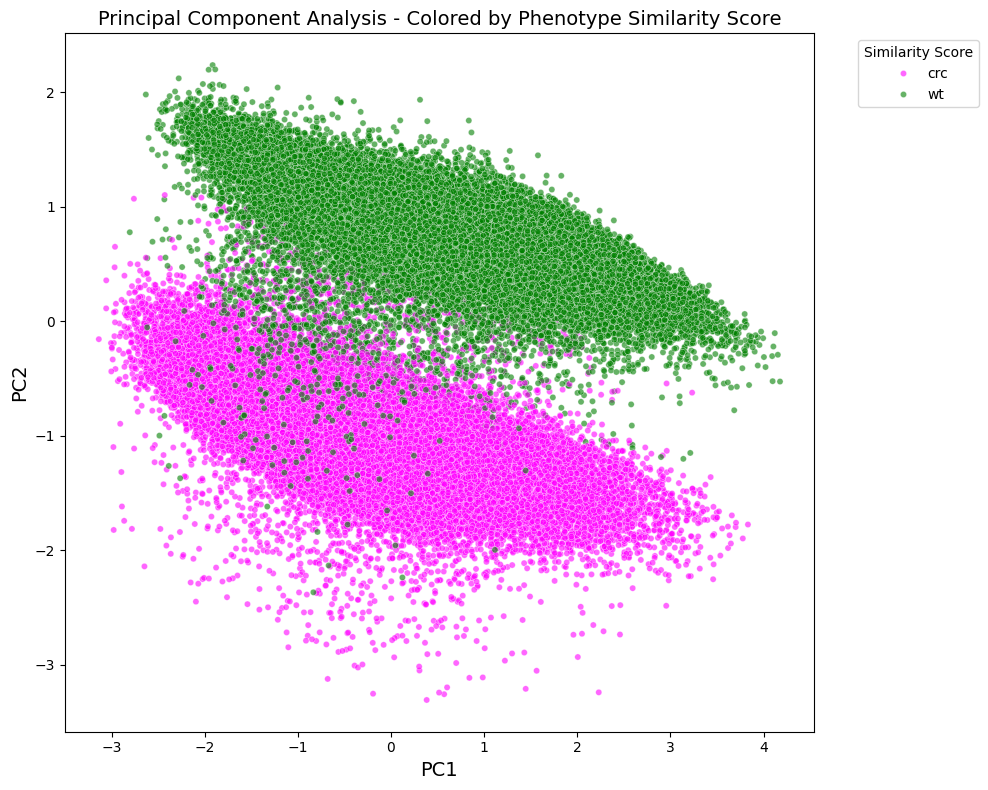

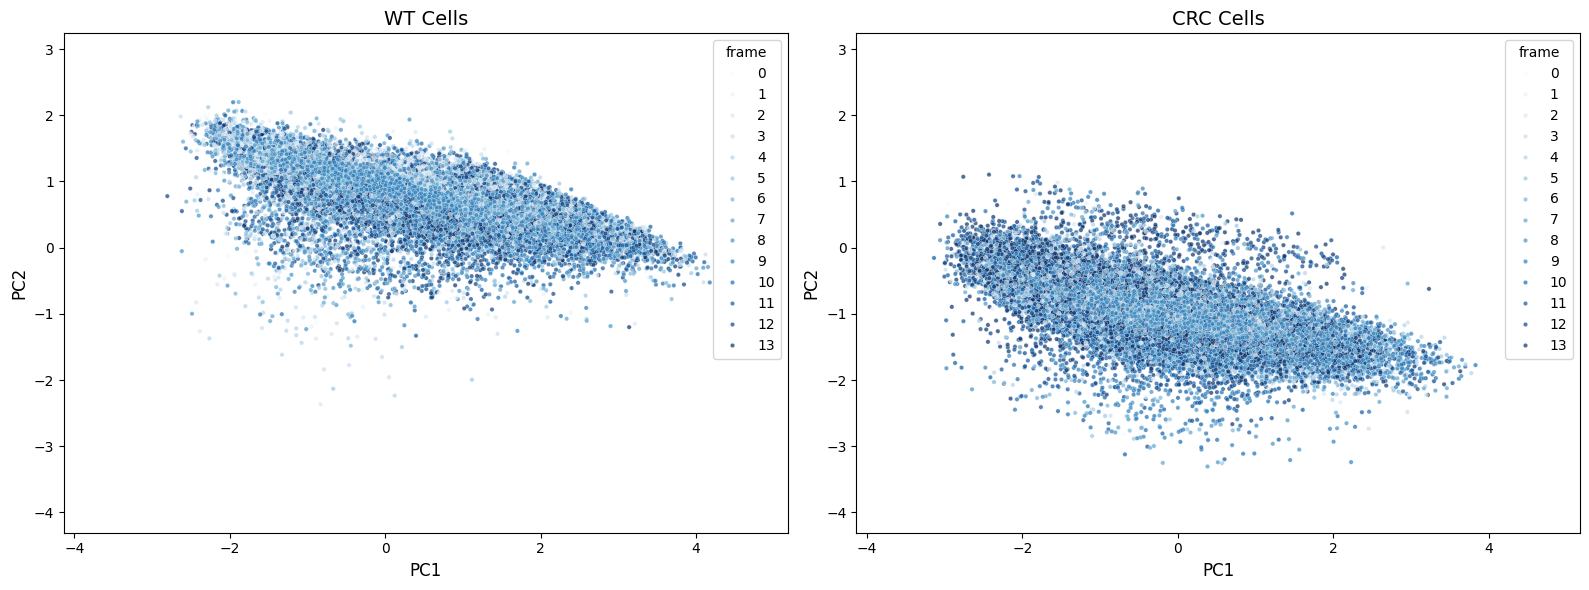

Feature loadings for each principal component:
                        PC1       PC2
volume             0.698287 -0.055247
log_ratio_wt_crc   0.271432  0.942994
mean_knn_distance  0.662359 -0.328192


Feature contributions (sorted by absolute loading):

PC1 (largest contributors):
                        PC1   PC1_abs
volume             0.698287  0.698287
mean_knn_distance  0.662359  0.662359
log_ratio_wt_crc   0.271432  0.271432

PC2 (largest contributors):
                        PC2   PC2_abs
log_ratio_wt_crc   0.942994  0.942994
mean_knn_distance -0.328192  0.328192
volume            -0.055247  0.055247


In [73]:
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


def remove_outliers_zscore(df, columns, threshold=3):
    """Remove rows where any column has z-score > threshold"""
    z_scores = np.abs(stats.zscore(df[columns]))
    return df[(z_scores < threshold).all(axis=1)]


data = pd.DataFrame(data)

features_to_check = ["volume", "log_ratio_wt_crc", "mean_knn_distance"]
features_not_checked = list(data.columns.difference(features_to_check))
data = remove_outliers_zscore(data, features_to_check, threshold=3)
x = data.loc[:, data.columns.isin(features_to_check)].values
x = StandardScaler().fit_transform(x)  # normalizing the features

feat_cols = ["feature" + str(i) for i in range(x.shape[1])]
normalised_data = pd.DataFrame(x, columns=feat_cols)
pca = PCA(n_components=2)
pc = pca.fit_transform(x)

principal_df = pd.DataFrame(data=pc, columns=["PC1", "PC2"])
final_df = pd.concat([principal_df, data[features_not_checked].reset_index(drop=True)], axis=1)

print(
    "Explained variability per principal component: {}".format(
        pca.explained_variance_ratio_
    )
)


# Create seaborn scatterplot colored by phenotype_similarity_score
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=final_df,
    x="PC1",
    y="PC2",
    hue="phenotype",
    palette= ["magenta","green"],  # or "coolwarm", "RdYlBu", etc.
    s=20,
    alpha=0.6,
    legend="full",
)

plt.xlabel("PC1", fontsize=14)
plt.ylabel("PC2", fontsize=14)
plt.title(
    "Principal Component Analysis - Colored by Phenotype Similarity Score", fontsize=14
)
plt.legend(title="Similarity Score", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Alternative: Separate plots by phenotype with similarity score coloring
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# set same limits for both plots
x_limits = (final_df["PC1"].min() - 1, final_df["PC1"].max() + 1)
y_limits = (final_df["PC2"].min() - 1, final_df["PC2"].max() + 1)
for idx, phenotype in enumerate(["wt", "crc"]):
    subset = final_df[final_df["phenotype"] == phenotype]
    sns.scatterplot(
        data=subset,
        x="PC1",
        y="PC2",
        hue="frame",
        palette="Blues",
        s=10,
        alpha=0.7,
        ax=axes[idx],
        legend="full",
    )
    axes[idx].set_title(f"{phenotype.upper()} Cells", fontsize=14)
    axes[idx].set_xlabel("PC1", fontsize=12)
    axes[idx].set_ylabel("PC2", fontsize=12)
    axes[idx].set_xlim(x_limits)
    axes[idx].set_ylim(y_limits)

plt.tight_layout()
plt.show()

# Get feature loadings (eigenvectors)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=["volume", "log_ratio_wt_crc", "mean_knn_distance"],
)

print("Feature loadings for each principal component:")
print(loadings)
print("\n")

# Calculate contribution magnitude for each feature
loadings["PC1_abs"] = np.abs(loadings["PC1"])
loadings["PC2_abs"] = np.abs(loadings["PC2"])

print("Feature contributions (sorted by absolute loading):")
print("\nPC1 (largest contributors):")
print(loadings.sort_values("PC1_abs", ascending=False)[["PC1", "PC1_abs"]])

print("\nPC2 (largest contributors):")
print(loadings.sort_values("PC2_abs", ascending=False)[["PC2", "PC2_abs"]])

<Figure size 640x480 with 0 Axes>

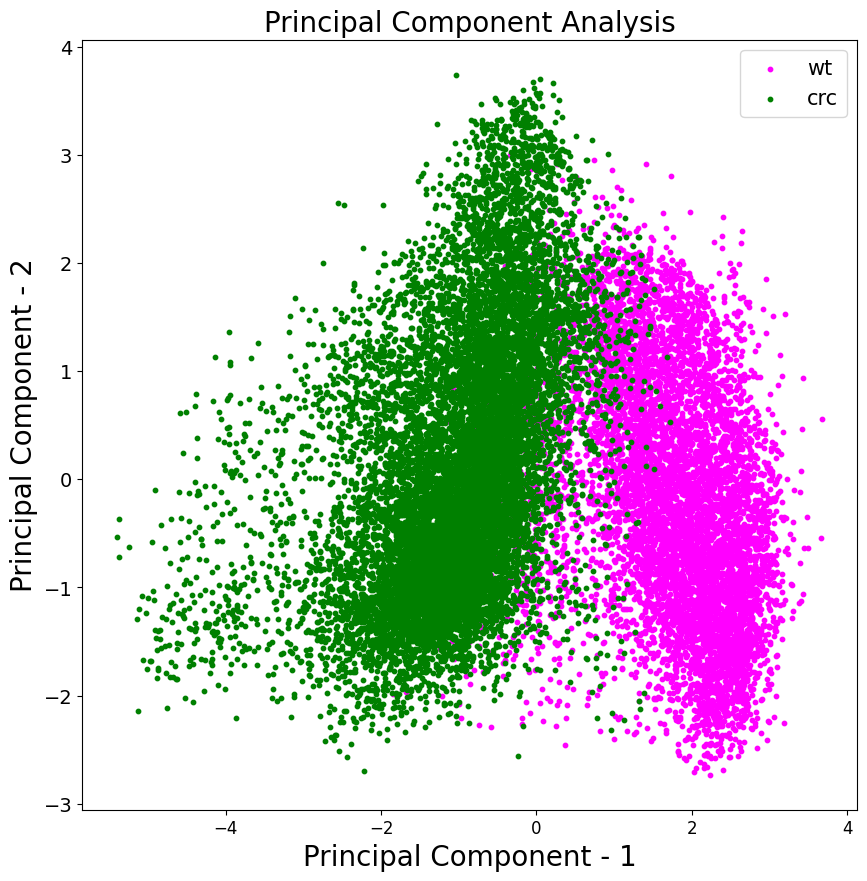

In [26]:
import h5py


def explore_full_structure(ims_path, max_depth=5):
    """Explore entire HDF5 file structure"""
    with h5py.File(ims_path, "r") as f:
        print("=== Full IMS File Structure ===\n")

        def print_structure(name, obj, depth=0):
            if depth > max_depth:
                return

            indent = "  " * depth

            if isinstance(obj, h5py.Group):
                print(f"{indent}{name}/ (Group)")
                # Print attributes if any
                if len(obj.attrs) > 0:
                    for key, val in obj.attrs.items():
                        print(f"{indent}  @{key}: {val}")

            elif isinstance(obj, h5py.Dataset):
                print(f"{indent}{name}: shape={obj.shape}, dtype={obj.dtype}")
                if len(obj.attrs) > 0:
                    for key, val in obj.attrs.items():
                        print(f"{indent}  @{key}: {val}")

        f.visititems(lambda name, obj: print_structure(name, obj, name.count("/")))


explore_full_structure(r"C:\Users\6331823\Local SSD\with_surfaces.ims")

=== Full IMS File Structure ===

DataSet/ (Group)
  DataSet/ResolutionLevel 0/ (Group)
    DataSet/ResolutionLevel 0/TimePoint 0/ (Group)
      DataSet/ResolutionLevel 0/TimePoint 0/Channel 0/ (Group)
        @HistogramMax: [b'6' b'8' b'0' b'9' b'.' b'0' b'0' b'0']
        @HistogramMax1024: [b'6' b'8' b'0' b'9' b'.' b'0' b'0' b'0']
        @HistogramMin: [b'0' b'.' b'0' b'0' b'0']
        @HistogramMin1024: [b'0' b'.' b'0' b'0' b'0']
        @ImageSizeX: [b'9' b'5' b'0']
        @ImageSizeY: [b'7' b'6' b'4']
        @ImageSizeZ: [b'5' b'6']
        DataSet/ResolutionLevel 0/TimePoint 0/Channel 0/Data: shape=(56, 768, 1024), dtype=uint16
        DataSet/ResolutionLevel 0/TimePoint 0/Channel 0/Histogram: shape=(256,), dtype=uint64
        DataSet/ResolutionLevel 0/TimePoint 0/Channel 0/Histogram1024: shape=(1024,), dtype=uint64
      DataSet/ResolutionLevel 0/TimePoint 0/Channel 1/ (Group)
        @HistogramMax: [b'2' b'4' b'0' b'3' b'.' b'0' b'0' b'0']
        @HistogramMax1024: [b'2' 

In [27]:
import h5py
import numpy as np
from typing import Dict, List, Tuple


def extract_surface_masks(
    ims_path: str, surface_name: str = "MegaSurfaces1", timepoint: int = 0
) -> Dict[int, np.ndarray]:
    """
    Extract surface masks from Imaris MegaSurfaces format.

    Args:
        ims_path: Path to .ims file
        surface_name: Name of surface group (e.g., 'MegaSurfaces1')
        timepoint: Which timepoint to extract (default: 0)

    Returns:
        Dictionary mapping surface_id -> 3D binary mask
    """
    with h5py.File(ims_path, "r") as f:
        surface_group = f[f"Scene8/Content/{surface_name}"]

        # Load surface model data
        surface_model = surface_group["SurfaceModel"][:]
        surface_info = surface_group["SurfaceModelInfo"][:]
        block_data = surface_group["BlockData"][:]
        block_info = surface_group["BlockInfo"][:]
        level_info = surface_group["LevelInfo"][:]

        # Filter surfaces for the specified timepoint
        time_mask = surface_model["ID_Time"] == timepoint
        surfaces_at_time = surface_model[time_mask]
        info_at_time = surface_info[time_mask]

        print(f"Found {len(surfaces_at_time)} surfaces at timepoint {timepoint}")

        masks = {}

        for idx, (surf, info) in enumerate(zip(surfaces_at_time, info_at_time)):
            surface_id = surf["ID"]

            # Get surface dimensions and extent
            size_x, size_y, size_z = surf["SizeX"], surf["SizeY"], surf["SizeZ"]
            extent_min = np.array(
                [surf["ExtendMinX"], surf["ExtendMinY"], surf["ExtendMinZ"]]
            )
            extent_max = np.array(
                [surf["ExtendMaxX"], surf["ExtendMaxY"], surf["ExtendMaxZ"]]
            )

            print(f"\nSurface {surface_id}:")
            print(f"  Size: {size_x} x {size_y} x {size_z}")
            print(f"  Extent: {extent_min} to {extent_max}")
            print(f"  Volume: {info['Volume']:.2f} µm³")
            print(
                f"  Position: ({info['PositionX']:.2f}, {info['PositionY']:.2f}, {info['PositionZ']:.2f})"
            )

            # Get block indices for this surface
            block_start = surf["BlockInfoBegin"]
            block_end = surf["BlockInfoEnd"]

            if block_end > block_start:
                # Initialize empty mask
                mask = np.zeros((size_z, size_y, size_x), dtype=bool)

                # Process blocks
                surface_blocks = block_info[block_start:block_end]

                for block in surface_blocks:
                    node_start = block["NodeBegin"]
                    node_end = block["NodeEnd"]

                    if node_end > node_start:
                        # Extract block data (this is simplified - actual extraction is complex)
                        # The block data contains octree nodes that need to be decoded
                        print(f"    Block: {node_end - node_start} nodes")

                masks[int(surface_id)] = mask
            else:
                print(f"  Warning: No block data found")

        return masks


def get_surface_statistics(
    ims_path: str, surface_name: str = "MegaSurfaces1"
) -> List[Dict]:
    """
    Extract surface statistics without decoding voxel data.
    This is faster and gives you position, volume, etc.
    """
    with h5py.File(ims_path, "r") as f:
        surface_group = f[f"Scene8/Content/{surface_name}"]

        surface_model = surface_group["SurfaceModel"][:]
        surface_info = surface_group["SurfaceModelInfo"][:]

        statistics = []

        for surf, info in zip(surface_model, surface_info):
            stat = {
                "timepoint": int(surf["ID_Time"]),
                "surface_id": int(surf["ID"]),
                "position": (
                    float(info["PositionX"]),
                    float(info["PositionY"]),
                    float(info["PositionZ"]),
                ),
                "center_of_mass": (
                    float(info["CenterOfMassX"]),
                    float(info["CenterOfMassY"]),
                    float(info["CenterOfMassZ"]),
                ),
                "volume": float(info["Volume"]),
                "area": float(info["Area"]),
                "sphericity": float(info["Sphericity"]),
                "extent_min": (
                    float(surf["ExtendMinX"]),
                    float(surf["ExtendMinY"]),
                    float(surf["ExtendMinZ"]),
                ),
                "extent_max": (
                    float(surf["ExtendMaxX"]),
                    float(surf["ExtendMaxY"]),
                    float(surf["ExtendMaxZ"]),
                ),
            }
            statistics.append(stat)

        return statistics


# Usage example:
if __name__ == "__main__":
    ims_path = r"C:\Users\6331823\Local SSD\with_surfaces.ims"

    # Get statistics (fast)
    print("=== Surface Statistics ===")
    stats = get_surface_statistics(ims_path, "MegaSurfaces1")

    for stat in stats[:5]:  # Show first 5
        print(f"\nTimepoint {stat['timepoint']}, Surface {stat['surface_id']}:")
        print(f"  Position: {stat['position']}")
        print(f"  Volume: {stat['volume']:.2f} µm³")
        print(f"  Sphericity: {stat['sphericity']:.3f}")

    # Extract masks (slow - octree decoding needed)
    # masks = extract_surface_masks(ims_path, timepoint=0)

=== Surface Statistics ===

Timepoint 0, Surface 0:
  Position: (190.02157592773438, 204.8273162841797, 65.13399505615234)
  Volume: 689.73 µm³
  Sphericity: 0.728

Timepoint 0, Surface 1:
  Position: (202.31198120117188, 182.8560028076172, 58.045005798339844)
  Volume: 0.05 µm³
  Sphericity: 0.481

Timepoint 0, Surface 2:
  Position: (223.18983459472656, 168.21371459960938, 52.63823318481445)
  Volume: 25.25 µm³
  Sphericity: 0.497

Timepoint 0, Surface 3:
  Position: (226.93597412109375, 156.55999755859375, 75.33500671386719)
  Volume: 0.15 µm³
  Sphericity: 0.545

Timepoint 0, Surface 4:
  Position: (226.63197326660156, 157.01600646972656, 75.33500671386719)
  Volume: 0.05 µm³
  Sphericity: 0.484


In [24]:
ims_path = r"C:\Users\6331823\Local SSD\with_surfaces.ims"

with h5py.File(ims_path, "r") as f:
    # Check if Scene/Content exists (where surfaces are stored)
    if "Scene" in f and "Content" in f["Scene"]:
        content = f["Scene"]["Content"]
        print(content.keys())  # List all datasets in Content
        # Iterate through all items in Content
        for key in content.keys():
            item = content[key]
            print(f"Item: {key}")
            print(item)
            # Check if it's a Surface object
            if "Surface" in key:
                name = (
                    item.attrs.get("Name", key).decode()
                    if isinstance(item.attrs.get("Name", key), bytes)
                    else str(key)
                )
                print(f"  Surface Name: {name}")
                if "Data" in item:
                    mask_data = item["Data"][:]
                    surfaces[name] = mask_data
                    print(f"Found surface: {name}, shape: {mask_data.shape}")

<KeysViewHDF5 ['MegaSurfaces0', 'MegaSurfaces1', 'MegaSurfaces2', 'MegaSurfaces3', 'MegaSurfaces4', 'MegaSurfaces5', 'MegaSurfaces6']>
Item: MegaSurfaces0
<HDF5 group "/Scene/Content/MegaSurfaces0" (0 members)>
  Surface Name: MegaSurfaces0
Item: MegaSurfaces1
<HDF5 group "/Scene/Content/MegaSurfaces1" (0 members)>
  Surface Name: MegaSurfaces1
Item: MegaSurfaces2
<HDF5 group "/Scene/Content/MegaSurfaces2" (0 members)>
  Surface Name: MegaSurfaces2
Item: MegaSurfaces3
<HDF5 group "/Scene/Content/MegaSurfaces3" (0 members)>
  Surface Name: MegaSurfaces3
Item: MegaSurfaces4
<HDF5 group "/Scene/Content/MegaSurfaces4" (0 members)>
  Surface Name: MegaSurfaces4
Item: MegaSurfaces5
<HDF5 group "/Scene/Content/MegaSurfaces5" (0 members)>
  Surface Name: MegaSurfaces5
Item: MegaSurfaces6
<HDF5 group "/Scene/Content/MegaSurfaces6" (0 members)>
  Surface Name: MegaSurfaces6


In [ ]:
import imaris_ims_file_reader.ims as ims

ims_path = r"C:\Users\6331823\Local SSD\with_surfaces_channel.ims"
image = ims(ims_path)

# The mask is the last channel of the image, index 4 in my case
mask = image[:,4]

viewer = napari.Viewer()
viewer.add_image(image[:,1], name="Nuclei", scale=(7,1,1), blending="additive")
viewer.add_labels(mask, name="Surface Mask", scale=(7,1,1), blending="additive")

Opening readonly file: C:\Users\6331823\Local SSD\with_surfaces_channel.ims 

Closing file: C:\Users\6331823\Local SSD\with_surfaces_channel.ims 

(1, 5, 56, 764, 950)


<Labels layer 'Surface Mask' at 0x2700fe07d90>

In [7]:
import napari

viewer = napari.Viewer()
image = tifffile.imread(r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\cropped\Frame-0.tif")
segmentation = tifffile.imread(r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\segmented\Frame-0_masks.tif")
segmentation1 = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\cropped_nuclei_mask_flow3D_0.tif"
)
segmentation2 = tifffile.imread(r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\cropped_nuclei_mask_flow3D_1.tif")
segmentation3 = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\cropped_nuclei_mask_flow3D_3_stitch_1.tif"
)
segmentation4 = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\cropped_nuclei_mask_flow3D_3_stitch_0.5.tif"
)
segmentation5 = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\cropped_nuclei_mask_flow3D_2_stitch_0.5.tif"
)
segmentation6 = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\cropped_nuclei_mask_flow3D_1.5_stitch_0.5.tif"
)
segmentation7 = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\cropped_nuclei_mask_flow3D_1.5_stitch_0.5_new_model.tif")

viewer.add_image(image[:, 0], name="mTmG", scale=(8.125, 1, 1), blending="additive", colormap="magenta", contrast_limits=[200,3000])
viewer.add_image(
    image[:, 1],
    name="DAPI",
    scale=(8.125, 1, 1),
    blending="additive",
    colormap="blue",
    contrast_limits=[200, 2500],
)
viewer.add_image(
    image[:, 2],
    name="AldoB",
    scale=(8.125, 1, 1),
    blending="additive",
    colormap="green",
    contrast_limits=[200, 4000],
)
viewer.add_image(
    image[:, 3],
    name="Lyz",
    scale=(8.125, 1, 1),
    blending="additive",
    colormap="gray",
    contrast_limits=[200, 5000],
)
viewer.add_labels(
    segmentation,
    name="Segmentation",
    scale=(8.125, 1, 1),
    blending="additive",
    visible=False,
)
viewer.add_labels(
    segmentation1,
    name="Segmentation1",
    scale=(8.125, 1, 1),
    blending="additive",
    visible=False,
)
viewer.add_labels(
    segmentation2,
    name="Segmentation2",
    scale=(8.125, 1, 1),
    blending="additive",
    visible=False,
)
viewer.add_labels(
    filtered_mask,
    name="Filtered Segmentation2",
    scale=(8.125, 1, 1),
    blending="additive",
    visible=False,
)
viewer.add_labels(
    segmentation3,
    name="Segmentation3",
    scale=(8.125, 1, 1),
    blending="additive",
    visible=False,
)
viewer.add_labels(
    segmentation4,
    name="Segmentation4",
    scale=(8.125, 1, 1),
    blending="additive",
    visible=False,
)
viewer.add_labels(
    segmentation5,
    name="Segmentation5",
    scale=(8.125, 1, 1),
    blending="additive",
    visible=False,
)
viewer.add_labels(
    segmentation6,
    name="Segmentation6",
    scale=(8.125, 1, 1),
    blending="additive",
    visible=False,
)
viewer.add_labels(
    segmentation7,
    name="Segmentation7",
    scale=(8.125, 1, 1),
    blending="additive",
    visible=True,
)

KeyboardInterrupt: 

In [21]:
# make a new mask file from segmentation2 where only masks with volume > 50 are kept

# Function to get properties from masked images and put them in a pandas df

import pandas as pd
from skimage.measure import regionprops
import numpy as np


def properties_mask(image):

    # Get the properties of every mask in the image
    props = regionprops(image)

    data = []

    # For every mask found, get the label, centeroid, boundingbox, and volume
    for prop in props:
        label = prop.label
        volume = prop.area

        data.append(
            {
                "label": label,
                "volume": volume,
            }
        )

    # Make a pandas data frame from the data
    df_props = pd.DataFrame(data)

    return df_props


sample = segmentation4

data = properties_mask(sample)
labels_to_keep = [label for label in data["label"] if data[data["label"] == label]["volume"].values[0] > 500]


# Create new mask with only large enough labels
filtered_mask = np.zeros_like(sample)
for label in labels_to_keep:
    filtered_mask[sample == label] = label

In [1]:
# Function to load cellpose models
import os

import torch


def load_model(model_path=None):
    from cellpose import models

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using {device.upper()} for processing.")

    if model_path:
        model = models.CellposeModel(
            gpu=(device == "cuda"), pretrained_model=model_path
        )
        print(f"loaded custom model: {os.path.basename(model_path)}")
    else:
        model = models.CellposeModel(gpu=(device == "cuda"))
        print("loaded default SAM model")
    return model

# model = load_model(
#     r"C:\Users\6331823\Local SSD\Train fixed intestinal 40x\models\fixed_intestinal_40x"
# )

In [55]:
import tifffile
import napari
from cellpose.utils import stitch3D
import numpy as np

size = 40

# image = tifffile.imread(r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\cropped_nuclei.tif")
image = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\cropped\Frame-0.tif"
)

model = load_model(r"C:\Users\6331823\Local SSD\Train lyz\models\lyz")


masks = []
for z in range(image.shape[0]):
    mask, _, _ = model.eval(
        image[z, 3],
        diameter=None,
        normalize=True,
        flow_threshold=0.4,
        invert=False,
        resample=True,
        do_3D=False,
        min_size=size,
        niter=200,
    )
    masks.append(mask)
masks = np.stack(masks, axis=0)
tifffile.imwrite(
    rf"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\lyz_basic_mask.tif",
    masks,
    compression="zlib",
    compressionargs={"level": 8},
)

Using CUDA for processing.
loaded custom model: lyz


In [95]:
def break_tracks(tracked, max_length=10, area_column="area"):
    new_tracked = tracked.copy()
    next_particle_id = tracked["particle"].max() + 1

    while True:
        long_tracks = new_tracked.groupby("particle").size()
        long_tracks = long_tracks[long_tracks > max_length]

        if len(long_tracks) == 0:
            break  # No more long tracks

        for particle_id in long_tracks.index:
            particle_data = new_tracked[
                new_tracked["particle"] == particle_id
            ].sort_values("z")

            # Find weakest link
            areas = particle_data[area_column].values
            deltas =[]
            for i in range(len(areas[:-1])):
                area1 = areas[i]
                area2 = areas[i + 1]
                delta = abs(area2 - area1)
                pct = delta / max(area1, area2)
                deltas.append(pct)

            weakest_idx = np.argmax(deltas)
            break_z = particle_data.iloc[weakest_idx + 1]["z"]

            # Split track
            mask = (new_tracked["particle"] == particle_id) & (
                new_tracked["z"] >= break_z
            )
            new_tracked.loc[mask, "particle"] = next_particle_id
            next_particle_id += 1

            # print(f"Split particle {particle_id} between z={break_z-1} and z={break_z}")

    return new_tracked


In [13]:
import sklearn.neighbors


def compute_knn_features(data, k=5):
    # Get an array of the coordinates of every cell
    coordinates = data[["x_center", "y_center", "z_center"]].to_numpy()

    # Fit the k-nearest neighbors model and compute the k-nearest neighbors for each cell
    neighbours = sklearn.neighbors.NearestNeighbors(
        n_neighbors=k + 1, algorithm="kd_tree"
    ).fit(coordinates)
    distances, indices = neighbours.kneighbors(coordinates)
    knn_distances = distances[:, 1:]  # Exclude the first column (distance to itself)
    knn_indices = indices[:, 1:]  # Exclude the first column (index of itself)

    # Calculate the mean distance of every cell to its 5 nearest neighbours, which can measure density
    mean_knn_distance = [distance.mean() for distance in knn_distances]

    # Add the mean distance and the indices of the k-nearest neighbors to the dataframe
    data["mean_knn_distance"] = mean_knn_distance
    data[f"{k}_knn_neighbors"] = list(knn_indices)

    # This cell id is the same as the label-1, this is what you can compare the knn_neighbours column with
    data["cell_id"] = range(len(data))
    return data

In [28]:
# Get the properties of every mask in the image
def get_mask_stats(mask):
    particle_stats = []
    props = regionprops(mask)

    # For every mask found, get the label, centeroid, boundingbox, and volume
    for prop in props:
        label = prop.label
        centroid = prop.centroid  # (z, y, x)
        bounding_box = prop.bbox  # (min_z, min_y, min_x, max_z, max_y, max_x)
        volume = prop.area

        width_x = bounding_box[5] - bounding_box[2] 
        width_y = bounding_box[4] - bounding_box[1] 
        height_pixel = bounding_box[3] - bounding_box[0]
        height = (bounding_box[3] - bounding_box[0]) * 8.125
        aspect_ratio = height / np.mean([width_x, width_y])

        particle_stats.append(
            {
                "particle": label,
                "z_center": centroid[0],
                "y_center": centroid[1],
                "x_center": centroid[2],
                "bounding_box": bounding_box,
                "width_x": width_x,
                "width_y" : width_y,
                "height_pixel": height_pixel,
                "height": height,
                "aspect_ratio": aspect_ratio,
                "volume": volume,
            }
        )
    stats_df = pd.DataFrame(particle_stats)
    return stats_df

In [96]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas import DataFrame, Series  # for convenience
import tifffile

from skimage.measure import regionprops
from scipy.ndimage import center_of_mass
import trackpy as tp

# masks = tifffile.imread(
#     r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\basic_mask_40x_size40.tif"
# )

def stitch_sebastian(masks, max_search_range=10, max_height = 10):

    # Step 1: Extract centroids from each Z-slice
    all_centroids = []
    for z in range(masks.shape[0]):
        slice_mask = masks[z]
        props = regionprops(slice_mask)

        for prop in props:
            all_centroids.append({
                'z': z,  # frame
                'y': prop.centroid[0],
                'x': prop.centroid[1],
                'label_2d': prop.label,  # original 2D label
                'area': prop.area,
                'bounding_box': prop.bbox,
            })

    df = pd.DataFrame(all_centroids)

    tp.linking.Linker.MAX_SUB_NET_SIZE = 100

    tracked = tp.link(
        df, 
        search_range=6,  # max movement in XY
        memory=0,  # allow gaps in tracking
        pos_columns=['y', 'x'],  # columns for position
        t_column='z'  # use Z as time
    )

    # In the tracked df, add 1 to particle to avoid 0 labels
    tracked["particle"] = tracked["particle"].astype(int) + 1

    tracked = break_tracks(tracked, max_length=max_height, area_column="area")

    masks_3d = np.zeros_like(masks, dtype=np.uint32)

    for _, row in tracked.iterrows():
        z = int(row["z"])
        particle_id = int(row["particle"])  # trackpy assigns unique IDs
        original_label = int(row["label_2d"])

        # Copy the original mask pixels and relabel with particle_id
        masks_3d[z][masks[z] == original_label] = particle_id

    # Make a pandas data frame from the data
    stats_df = get_mask_stats(masks_3d)
    stats_df = stats_df[(stats_df["height_pixel"] != 1)]
    stats_df = compute_knn_features(stats_df, k=1)
    stats_df["aspect_ratio_score"] = (
        stats_df["aspect_ratio"] - stats_df["aspect_ratio"].min()
    ) / (stats_df["aspect_ratio"].max() - stats_df["aspect_ratio"].min())
    stats_df["density_normalized"] = 1 - (
        stats_df["mean_knn_distance"] - stats_df["mean_knn_distance"].min()
    ) / (stats_df["mean_knn_distance"].max() - stats_df["mean_knn_distance"].min())
    stats_df["background_score"] = (1 - stats_df["aspect_ratio_score"]) * (
        1 - stats_df["density_normalized"]
    )

    # Optionally normalize to 0-1 range
    stats_df["background_score_normalized"] = (
        stats_df["background_score"] - stats_df["background_score"].min()
    ) / (stats_df["background_score"].max() - stats_df["background_score"].min())
    filtered = stats_df#[stats_df["aspect_ratio"] < 1.8]
    tracked_filtered = tracked[tracked["particle"].isin(filtered["particle"])]

    masks_3d_filtered = np.zeros_like(masks, dtype=np.uint32)

    for _, row in tracked_filtered.iterrows():
        z = int(row["z"])
        particle_id = int(row["particle"])
        original_label = int(row["label_2d"])

        # Copy the original mask pixels and relabel with new particle_id
        masks_3d_filtered[z][masks[z] == original_label] = particle_id

    return masks_3d, masks_3d_filtered, stats_df


# tifffile.imwrite(
#     r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\40x_trackpy.tif",
#     masks_3d,
#     compression="zlib",
#     compressionargs={"level": 8},
# )

# tifffile.imwrite(
#     r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\40x_trackpy_filtered.tif",
#     masks_3d_filtered,
#     compression="zlib",
#     compressionargs={"level": 8},
# )

In [ ]:
import tifffile
import napari
from cellpose.utils import stitch3D

masks = tifffile.imread(rf"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\lyz_basic_mask.tif")

# stitched = stitch3D(masks)
# _, stitched_self,_ = stitch_sebastian(masks, max_search_range=50, max_height=10)

props = regionprops(stitched)
all_centroids = []
for prop in props:
            all_centroids.append({
                "height": prop.bbox[3] - prop.bbox[0],
                'particle': prop.label,  # original 2D label
                "volume": prop.area,
            })
tracked = pd.DataFrame(all_centroids)

tracked_filtered = tracked[tracked["height"] > 1]
tracked_filtered = tracked_filtered[tracked_filtered["volume"] < 500]
# stats = properties_channel(stitched_filtered, image[:, 3], "lyz").merge(properties_channel(stitched_filtered, image[:, 1], "dapi"),on="label")
# stats["ratio_lyz_dapi"] = stats["raw_lyz"] / stats["raw_dapi"]
# stats_filtered = stats[stats["ratio_lyz_dapi"] > 1.3]
# tracked_filtered = tracked_filtered[tracked_filtered["particle"].isin(stats_filtered["label"])]

stitched_filtered = np.zeros_like(stitched, dtype=np.uint32)
for _, row in tracked_filtered.iterrows():
    # z = int(row["z"])
    particle_id = int(row["particle"])

    # Copy the original mask pixels and relabel with new particle_id
    stitched_filtered[stitched == particle_id] = particle_id

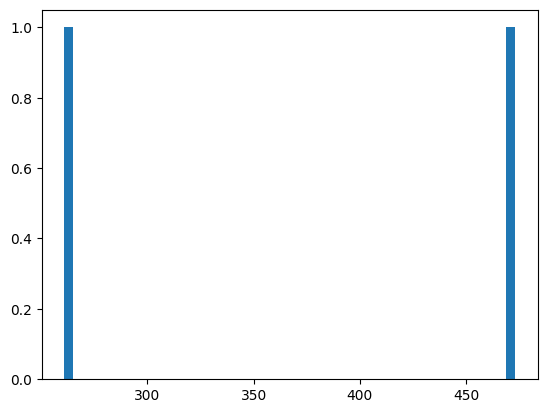

In [79]:
import matplotlib.pyplot as plt
lyz_stats = properties_channel(stitched_filtered, image[:,3], "lyz")
dapi_stats = properties_channel(stitched_filtered, image[:,1], "dapi")
# plt.hist(lyz_stats["raw_lyz"]/dapi_stats["raw_dapi"], bins=50)
plt.hist(tracked_filtered["volume"], bins=50)
plt.show()

In [80]:
# stitched = stitch3D(masks)
image = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\cropped\Frame-0.tif"
)
viewer = napari.Viewer()
viewer.add_image(image[:,3], name="Image", scale=(8.125, 1, 1), blending="additive")
viewer.add_labels(stitched, name="Stitched Mask", scale=(8.125, 1, 1), blending="additive")
viewer.add_labels(stitched_filtered, name="Stitched Mask Filtered", scale=(8.125, 1, 1), blending="additive")
viewer.add_labels(stitched_self, name="Stitched Mask Self", scale=(8.125, 1, 1), blending="additive")
viewer.add_labels(masks, name="Original Mask", scale=(8.125, 1, 1), blending="additive")

<Labels layer 'Original Mask' at 0x1e2ae224350>

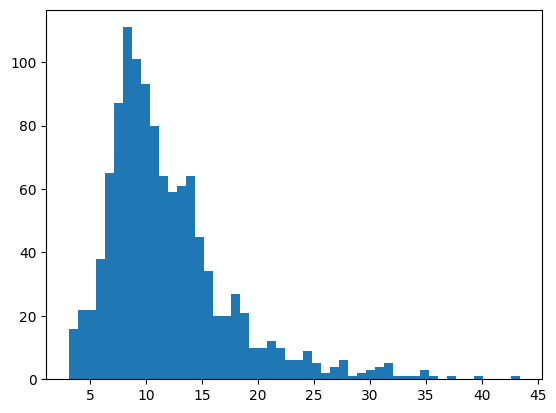

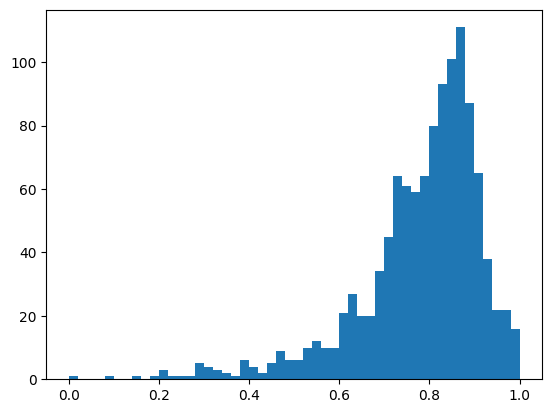

In [31]:
plt.hist(stats_df["mean_knn_distance"], bins=50)
plt.show()
plt.hist(stats_df["density_normalized"], bins=50)
plt.show()

In [8]:
import tifffile
import napari
from matplotlib.colors import Normalize

image = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\cropped\Frame-0.tif"
)
tracked_filtered = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\40x_trackpy_filtered.tif"
)
# masks = tifffile.imread(r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\basic_mask_size120.tif")
# segmented = stitch3D(masks)
# segmented_0_5 = stitch3D(masks, stitch_threshold=0.5)
# segmented_0_4 = stitch3D(masks, stitch_threshold=0.4)

viewer = napari.Viewer(ndisplay=3)
viewer.add_image(image[:,1], name="DAPI", scale=(8.125, 1, 1), blending="additive", contrast_limits=[0, 2500], visible=True, colormap="blue")
viewer.add_image(
    image[:,0],
    name="mTmG",
    scale=(8.125, 1, 1),
    blending="additive",
    contrast_limits=[0, 3000],
    colormap="magenta",
    visible=False
)
viewer.add_image(
    image[:, 2],
    name="AldoB",
    scale=(8.125, 1, 1),
    blending="additive",
    contrast_limits=[0, 3000],
    colormap="green",
    visible=False,
)
viewer.add_image(
    image[:, 3],
    name="Lyz",
    scale=(8.125, 1, 1),
    blending="additive",
    contrast_limits=[0, 3000],
    colormap="gray",
    visible=False,
)

# manual = tifffile.imread(r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\Manual corrected.tif")
viewer.add_labels(stitched, name="Lyz stitched", scale=(8.125, 1, 1), blending="additive", visible=True)
# viewer.add_labels(segmented_0_5, name="Segmented 0.5", scale=(8.125, 1, 1), blending="additive", visible=False)
# viewer.add_labels(segmented_0_4, name="Segmented 0.4", scale=(8.125, 1, 1), blending="additive", visible=False)
# viewer.add_labels(masks_3d, name="trackpy", scale=(8.125, 1, 1), blending="additive", visible=False)
viewer.add_labels(
    tracked_filtered, name="trackpy filtered", scale=(8.125, 1, 1), blending="additive", visible=True
)
# mask = tifffile.imread(
#     r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\manual_corrected_trackpy.tif"
# )
# viewer.add_labels(
#     mask, name="Manual corrected trackpy", scale=(8.125, 1, 1), blending="additive", visible=True
# )
# viewer.add_labels(
#     lyz,
#     name="lyz",
#     scale=(8.125, 1, 1),
#     blending="additive",
#     visible=True,
# )
# viewer.add_labels(
#     aldob,
#     name="aldob",
#     scale=(8.125, 1, 1),
#     blending="additive",
#     visible=True,
# )

# # from matplotlib.colors import Normalize

# # Get aspect ratios from stats_df
# density_normalizeds = stats_df.set_index("particle")["density_normalized"]

# # Normalize to 0-255 range
# norm = Normalize(vmin=density_normalizeds.min(), vmax=density_normalizeds.max())
# normalized_values = norm(density_normalizeds) * 255

# # Keep as Series with proper index
# normalized_values = pd.Series(
#     normalized_values.astype(np.uint8), index=density_normalizeds.index
# )

# # Create new 8-bit image with aspect ratio values
# density_normalized_image = np.zeros_like(masks_3d, dtype=np.uint8)

# # Iterate over the index and values together using .loc[] for proper indexing
# for particle_id in density_normalizeds.index:
#     value = normalized_values.loc[particle_id]  # Now this works!
#     density_normalized_image[masks_3d == particle_id] = value
# viewer.add_image(
#     density_normalized_image,
#     name="Density Normalized Heatmap",
#     scale=(8.125, 1, 1),
#     colormap="viridis",
#     blending="additive",
#     contrast_limits=[0, 255],
#     visible=True,
# )


# viewer.add_labels(segmented_0_25, name="Segmented 0.25", scale=(8.125, 1, 1), blending="additive", visible=True)

<Labels layer 'trackpy filtered' at 0x1e1989c6010>

c:\Users\6331823\AppData\Local\Programs\Python\Python311\Lib\site-packages\napari\layers\labels\labels.py:892: UserWarning: Contours are not displayed during 3D rendering
  warnings.warn(
c:\Users\6331823\AppData\Local\Programs\Python\Python311\Lib\site-packages\napari\layers\labels\labels.py:892: UserWarning: Contours are not displayed during 3D rendering
  warnings.warn(
c:\Users\6331823\AppData\Local\Programs\Python\Python311\Lib\site-packages\napari\layers\labels\labels.py:892: UserWarning: Contours are not displayed during 3D rendering
  warnings.warn(
c:\Users\6331823\AppData\Local\Programs\Python\Python311\Lib\site-packages\napari\layers\labels\labels.py:892: UserWarning: Contours are not displayed during 3D rendering
  warnings.warn(
c:\Users\6331823\AppData\Local\Programs\Python\Python311\Lib\site-packages\napari\layers\labels\labels.py:892: UserWarning: Contours are not displayed during 3D rendering
  warnings.warn(


In [6]:
import imaris_ims_file_reader.ims as ims

imaris = ims(
    r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\20250604_Lyz_AldoB_DAPI.40x_deconvolved_F10.ims"
)
imaris = imaris[0]
viewer = napari.Viewer(ndisplay=3)
viewer.add_image(imaris[0], name="mTmG", scale=(8.125, 1, 1), blending="additive", contrast_limits=[0, 3000], visible=False, colormap="magenta")
viewer.add_image(imaris[1], name="DAPI", scale=(8.125, 1, 1), blending="additive", contrast_limits=[0, 2500], visible=True, colormap="blue")
viewer.add_image(imaris[2], name="AldoB", scale=(8.125, 1, 1), blending="additive", contrast_limits=[0, 3000], visible=False, colormap="green")
viewer.add_image(imaris[3], name="Lyz", scale=(8.125, 1, 1), blending="additive", contrast_limits=[0, 3000], visible=False, colormap="gray")

Opening readonly file: C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\20250604_Lyz_AldoB_DAPI.40x_deconvolved_F10.ims 

Closing file: C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\20250604_Lyz_AldoB_DAPI.40x_deconvolved_F10.ims 



<Image layer 'Lyz' at 0x2a6ae38a010>

In [62]:
import pandas as pd
from skimage.measure import regionprops_table


def properties_channel(mask, image, type=None):

    # Get the properties of the mask for the channel you specified (image)
    props_channel = regionprops_table(
        mask, intensity_image=image, properties=["label", "intensity_mean", "intensity_max"]
    )

    # Make this into a pandas dataframe and rename some variables to the name of the channel for later merging
    props_channel = pd.DataFrame(props_channel).rename(
        columns={
            "label": "label",
            "intensity_mean": f"raw_{type}",
            "intensity_max": f"max_{type}",
        }
    )

    return props_channel

In [151]:
import cv2
from scipy.ndimage import distance_transform_edt

mask = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\dapi_stitched.tif"
)

def measure_dilated(mask, dilation_size=1, channels = [0,1,2,3], channel_names = ["mTmG", "DAPI", "AldoB", "Lyz"]):
    dilated = np.zeros_like(mask)
    # for z in range(mask.shape[0]):
    #     dilated_slice = np.zeros_like(mask[z])
    #     for cell in np.unique(mask[z]):
    #         if cell == 0:
    #             continue
    #         else:
    #             cell_dilated = cv2.dilate((mask[z] == cell).astype(np.uint8), kernel=np.ones((3, 3), np.uint8), iterations=dilation_size)
    #             dilated_slice = np.where(cell_dilated > 0, cell, dilated_slice)
    #     dilated[z] = dilated_slice

    for z in range(mask.shape[0]):
        slice_mask = mask[z]
        distance, indices = distance_transform_edt(
            slice_mask == 0, return_indices=True  # Find distances from background
        )
        expanded_slice = slice_mask.copy()
        expand_region = (slice_mask == 0) & (distance <= dilation_size)

        # Use indices to find which label each background pixel is nearest to
        expanded_slice[expand_region] = slice_mask[
            indices[0][expand_region], indices[1][expand_region]
        ]

        dilated[z] = expanded_slice

    # If you need to preserve the original dtype
    mask = dilated.astype(mask.dtype)

    props = regionprops(mask)

    props_mask=[]
    # For every mask found, get the label, centeroid, boundingbox, and volume
    for prop in props:
        label = prop.label
        centroid = prop.centroid  # (z, y, x)
        bounding_box = prop.bbox  # (min_z, min_y, min_x, max_z, max_y, max_x)
        volume = prop.area

        width_x = bounding_box[5] - bounding_box[2]
        width_y = bounding_box[4] - bounding_box[1]
        height_pixel = bounding_box[3] - bounding_box[0]
        height = (bounding_box[3] - bounding_box[0]) * 8.125
        aspect_ratio = height / np.mean([width_x, width_y])

        props_mask.append(
            {
                "label": label,
                "z_center": centroid[0],
                "y_center": centroid[1],
                "x_center": centroid[2],
                "bounding_box": bounding_box,
                "width_x": width_x,
                "width_y": width_y,
                "height_pixel": height_pixel,
                "height": height,
                "aspect_ratio": aspect_ratio,
                "volume": volume,
            }
        )
    props_mask = pd.DataFrame(props_mask)

    if len(channels) > 0:
        chan0 = properties_channel(mask, channels[0], type="DAPI")
        final_df = props_mask.merge(chan0, on="label")
    if len(channels) > 1:
        chan1 = properties_channel(mask, channels[1], type="mTmG")
        final_df = final_df.merge(chan1, on="label")
    if len(channels) > 2:
        chan2 = properties_channel(mask, channels[2], type="AldoB")
        final_df = final_df.merge(chan2, on="label")
    if len(channels) > 3:
        chan3 = properties_channel(mask, channels[3], type="Lyz")
        final_df = final_df.merge(chan3, on="label")

    final_df["log_ratio_lyz_dapi"] = np.log(final_df["raw_Lyz"] / final_df["raw_DAPI"])
    final_df["log_ratio_aldob_dapi"] = np.log(final_df["raw_AldoB"] / final_df["raw_DAPI"])

    return final_df, mask

In [147]:
mask = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\dapi_stitched.tif"
)
image = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\cropped\Frame-0.tif"
)
mtmg = image[:,0]
dapi = image[:,1]
aldob = image[:,2]
lyz = image[:,3]
stats, dilated_mask = measure_dilated(mask, dilation_size=12, channels = [mtmg,dapi,aldob,lyz], channel_names = ["mTmG", "DAPI", "AldoB", "Lyz"])

In [150]:
# Make a new masks_3d_filtered that only contains labels in final_df that have a log_ratio_lyz_dapi > 0.3
aldob_masks = mask.copy()
aldob_masks[~np.isin(mask, stats[stats["log_ratio_aldob_dapi"] > -0.5]["label"])] = 0
lyz_masks = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\lyz_stitched.tif")

viewer = napari.Viewer(ndisplay=3)
viewer.add_image(image[:,1], name="DAPI", scale=(8.125, 1, 1), blending="additive", contrast_limits=[0, 2500], visible=False, colormap="blue")
viewer.add_image(aldob, name="AldoB image", scale=(8.125, 1, 1), blending="additive", contrast_limits=[0, 3000], visible=True, colormap="green")
viewer.add_image(lyz, name="Lyz image", scale=(8.125, 1, 1), blending="additive", contrast_limits=[0, 3000], visible=False, colormap="gray")
viewer.add_labels(
    aldob_masks, name="AldoB filtered", scale=(8.125, 1, 1), blending="additive", visible=True
)
viewer.add_labels(
    mask, name="Original mask", scale=(8.125, 1, 1), blending="additive", visible=False
)
viewer.add_labels(
    dilated_mask, name="Dilated mask", scale=(8.125, 1, 1), blending="additive", visible=False
)
viewer.add_labels(lyz_masks, name="Lyz filtered", scale=(8.125, 1, 1), blending="additive", visible=False
)


RuntimeError: sequence argument must have length equal to input rank

RuntimeError: sequence argument must have length equal to input rank

RuntimeError: sequence argument must have length equal to input rank

<Labels layer 'Lyz filtered' at 0x1e939b50910>

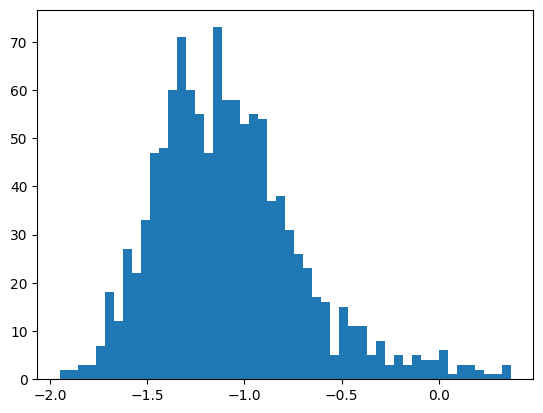

In [149]:
plt.hist(stats["log_ratio_aldob_dapi"], bins=50)
plt.show()

In [7]:
# Create a fake dapi channel only in the nuclei areas

masks_3d_filtered = tifffile.imread(r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\40x_trackpy_filtered.tif")
dapi_masked = np.zeros_like(image[:, 1])
dapi_masked = np.where(masks_3d_filtered, image[:, 1], 0)

c:\Users\6331823\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\6331823\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


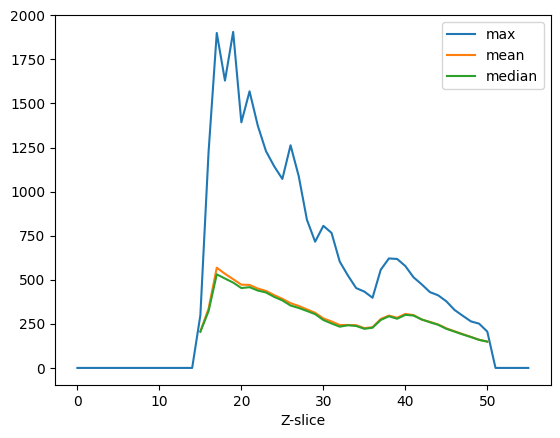

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
intensities = []
for z in range(dapi_masked.shape[0]):
    max = np.max(dapi_masked[z])
    mean = np.mean(dapi_masked[z][dapi_masked[z] > 0])
    median = np.median(dapi_masked[z][dapi_masked[z] > 0])
    intensities.append({"z": z, "max": max, "mean": mean, "median": median})

intensities = pd.DataFrame(intensities)

plt.plot(intensities["z"], intensities["max"], label="max")
plt.plot(intensities["z"], intensities["mean"], label="mean")
plt.plot(intensities["z"], intensities["median"], label="median")
plt.xlabel("Z-slice")
plt.legend()
plt.show()

In [12]:
altered_dapi = dapi_masked.copy()
altered_mtmg = image[:, 0].copy()
altered_aldob = image[:, 2].copy()
altered_lyz = image[:, 3].copy()
for z in range(dapi_masked.shape[0]):
    masked_max = np.max(dapi_masked[z])
    ratio = np.max(
        intensities["mean"]) / intensities[intensities["z"] == z]["mean"]
    if isinstance(ratio.values[0], (int, float)):
        altered_dapi[z] = dapi_masked[z] * ratio.values[0]
        altered_mtmg[z] = altered_mtmg[z] * ratio.values[0]
        altered_aldob[z] = altered_aldob[z] * ratio.values[0]
        altered_lyz[z] = altered_lyz[z] * ratio.values[0]
    else:
        altered_dapi[z] = dapi_masked[z]
        altered_mtmg[z] = altered_mtmg[z]
        altered_aldob[z] = altered_aldob[z]
        altered_lyz[z] = altered_lyz[z]

C:\Users\6331823\AppData\Local\Temp\ipykernel_26096\2953534912.py:10: RuntimeWarning: invalid value encountered in cast
  altered_dapi[z] = dapi_masked[z] * ratio.values[0]
C:\Users\6331823\AppData\Local\Temp\ipykernel_26096\2953534912.py:11: RuntimeWarning: invalid value encountered in cast
  altered_mtmg[z] = altered_mtmg[z] * ratio.values[0]
C:\Users\6331823\AppData\Local\Temp\ipykernel_26096\2953534912.py:12: RuntimeWarning: invalid value encountered in cast
  altered_aldob[z] = altered_aldob[z] * ratio.values[0]
C:\Users\6331823\AppData\Local\Temp\ipykernel_26096\2953534912.py:13: RuntimeWarning: invalid value encountered in cast
  altered_lyz[z] = altered_lyz[z] * ratio.values[0]


In [74]:
stats = measure_dilated(masks_3d_filtered, dilation_size=1, channels=[altered_dapi, altered_mtmg, altered_aldob, altered_lyz], channel_names=["DAPI", "mTmG", "AldoB", "Lyz"])

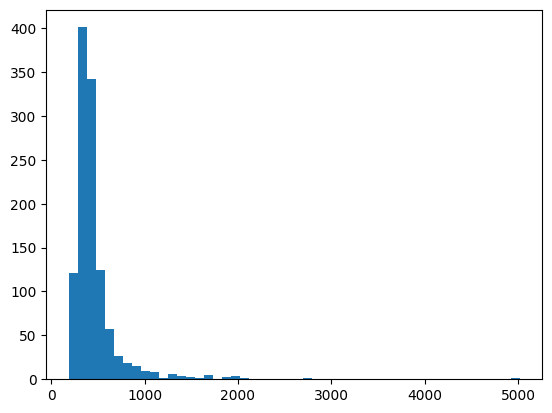

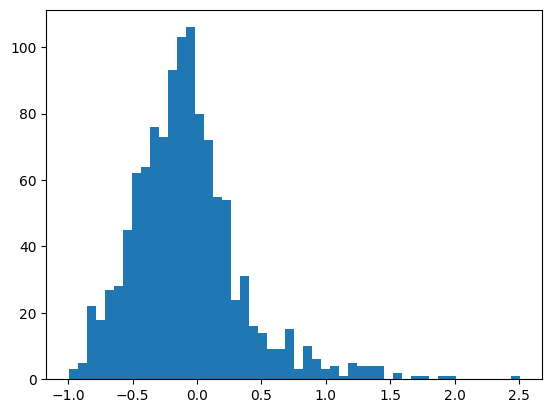

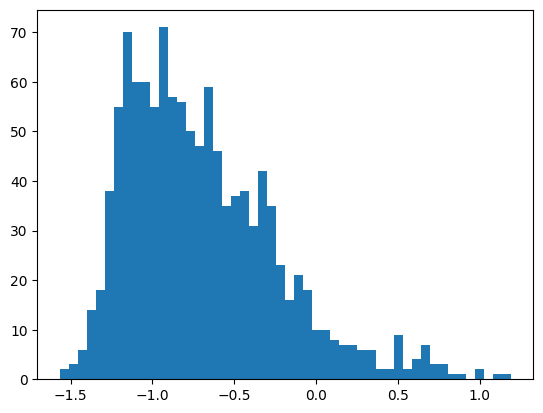

In [76]:
plt.hist(stats["raw_Lyz"], bins=50)
plt.show()
plt.hist(stats["log_ratio_lyz_dapi"], bins=50)
plt.show()
plt.hist(stats["log_ratio_aldob_dapi"], bins=50)
plt.show()

In [16]:
viewer = napari.Viewer(ndisplay=3)
viewer.add_image(
    dapi_masked,
    name="DAPI masked",
    scale=(8.125, 1, 1),
    blending="additive",
    contrast_limits=[0, 2500],
    visible=False,
    colormap="blue",
)
viewer.add_image(
    altered_dapi,
    name="Altered DAPI",
    scale=(8.125, 1, 1),
    blending="additive",
    contrast_limits=[0, 2500],
    visible=True,
    colormap="blue",
)
viewer.add_image(
    altered_mtmg,
    name="Altered MTMG",
    scale=(8.125, 1, 1),
    blending="additive",
    contrast_limits=[200, 2500],
    visible=True,
    colormap="magenta",
)
viewer.add_image(
    altered_aldob,
    name="Altered Aldob",
    scale=(8.125, 1, 1),
    blending="additive",
    contrast_limits=[200, 2500],
    visible=True,
    colormap="green",
)
viewer.add_image(
    altered_lyz,
    name="Altered LYZ",
    scale=(8.125, 1, 1),
    blending="additive",
    contrast_limits=[500, 2500],
    visible=True,
    colormap="gray",
)
# lyz = masks_3d_filtered.copy()
# lyz[
#     ~np.isin(masks_3d_filtered, final_df[final_df["log_ratio_lyz_dapi"] > 0.3]["label"])
# ] = 0
# aldob = masks_3d_filtered.copy()
# aldob[
#     ~np.isin(
#         masks_3d_filtered, final_df[final_df["log_ratio_aldob_dapi"] > -0.1]["label"]
#     )
# ] = 0
# viewer.add_labels(
#     lyz,
#     name="lyz",
#     scale=(8.125, 1, 1),
#     blending="additive",
#     visible=True,
# )
# viewer.add_labels(
#     aldob,
#     name="aldob",
#     scale=(8.125, 1, 1),
#     blending="additive",
#     visible=True,
# )
viewer.add_labels(
    masks_3d_filtered,
    name="masks_3d_filtered",
    scale=(8.125, 1, 1),
    blending="additive",
    visible=True,
)
viewer.add_labels(
    stitched, name="Stitched Mask", scale=(8.125, 1, 1), blending="additive"
)

<Labels layer 'Stitched Mask' at 0x1982078b590>

In [106]:
import os
output_directory = r"C:\Users\6331823\Local SSD\Train aldob"

aldob = image[:, 2]
lyz = image[:, 3]
dapi = image[:, 1]
combined = np.stack((dapi, lyz), axis=1)

for z in range(aldob.shape[0]):
    tifffile.imwrite(
        os.path.join(output_directory, f"Frame-{z}_aldob.tif"),
        aldob[z],
        compression="zlib",
        compressionargs={"level": 8},
    )

In [ ]:
import tifffile
import napari
from cellpose.utils import stitch3D
import numpy as np

size = 40

image = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\cropped_nuclei.tif"
)

masks = []
for z in range(image.shape[0]):
    mask, _, _ = model.eval(
        image[z],
        diameter=None,
        normalize=True,
        flow_threshold=0.4,
        invert=False,
        resample=True,
        do_3D=False,
        min_size=size,
        niter=200,
    )
    masks.append(mask)
masks = np.stack(masks, axis=0)
tifffile.imwrite(
    rf"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\basic_mask_40x_size{size}.tif",
    masks,
    compression="zlib",
    compressionargs={"level": 8},
)

In [9]:
for z in range(dapi.shape[0]):
    tifffile.imwrite(
        os.path.join(
            r"C:\Users\6331823\Local SSD\Train lyz",
            f"F00_z-{z}.tif",
        ),
        lyz[z],
        compression="zlib",
        compressionargs={"level": 8},
    )

In [14]:
import os
import tifffile
import napari
from cellpose.utils import stitch3D
import numpy as np

scale = (2.47, 0.304, 0.304)
input_directory = (
    r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F00"
)
image = tifffile.imread(
    os.path.join(input_directory, "cropped","Frame-0.tif")
)
print(image.shape)
dapi_masks = tifffile.imread(
    os.path.join(input_directory, "dapi_stitched.tif")
)
aldob_masks = tifffile.imread(
    os.path.join(input_directory, "aldob_stitched.tif")
)
lyz_masks = tifffile.imread(
    os.path.join(input_directory, "lyz_stitched.tif")
)

voronoi = dilated_dapi_masks = voronoi_dilate_mask(dapi_masks, dilation_size=10)
dapi = image[:, 1]
aldob = image[:, 2]
mtmg = image[:, 0]
lyz = image[:, 3]

viewer = napari.Viewer(ndisplay=3)
viewer.add_image(
    dapi,
    name="DAPI",
    scale=scale,
    blending="additive",
    contrast_limits=[0, 2500],
    visible=True,
    colormap="blue",
)
viewer.add_image(
    mtmg,
    name="mtmg",
    scale=scale,
    blending="additive",
    contrast_limits=[0, 3000],
    visible=False,
    colormap="magenta",
)
viewer.add_image(
    aldob,
    name="AldoB",
    scale=scale,
    blending="additive",
    contrast_limits=[0, 3000],
    visible=False,
    colormap="green",
)
viewer.add_image(
    lyz,
    name="Lyz",
    scale=scale,
    blending="additive",
    contrast_limits=[0, 3000],
    visible=False,
    colormap="gray",
)

viewer.add_labels(
    dapi_masks,
    name="DAPI Mask",
    scale=scale,
    blending="additive",
    visible=False,
    iso_gradient_mode="smooth",
)
viewer.add_labels(
    voronoi,
    name="DAPI stitch3D",
    scale=scale,
    blending="additive",
    visible=False,
    iso_gradient_mode="smooth"
)
viewer.add_labels(
    aldob_masks,
    name="AldoB Mask",
    scale=scale,
    blending="additive",
    visible=True,
    iso_gradient_mode="smooth",
)
viewer.add_labels(
    lyz_masks,
    name="Lyz Mask",
    scale=scale,
    blending="additive",
    visible=False,
    iso_gradient_mode="smooth",
)

(45, 6, 868, 807)


RuntimeError: sequence argument must have length equal to input rank

RuntimeError: sequence argument must have length equal to input rank

RuntimeError: sequence argument must have length equal to input rank

<Labels layer 'Lyz Mask' at 0x1ace9b48f50>

In [ ]:
image = tifffile.imread(r"E:\Transduction 20251106\CRC D2 H2B-mCherry 1.tiff")
image.shapes

(1536, 2048, 3)

(array([  1.,   0.,   0.,   0.,   1.,   0.,   3.,   6.,   8.,  30.,  30.,
         38.,  49.,  62.,  73.,  84.,  99., 113., 119., 140., 114., 172.,
        114., 125.,  95.,  82.,  61.,  44.,  48.,  26.,  21.,  12.,   7.,
         11.,  11.,   3.,   5.,   7.,   4.,   5.,   5.,   5.,   8.,   7.,
          2.,   3.,   1.,   1.,   2.,   1.]),
 array([-1.96593568, -1.90146765, -1.83699963, -1.77253161, -1.70806359,
        -1.64359557, -1.57912755, -1.51465952, -1.4501915 , -1.38572348,
        -1.32125546, -1.25678744, -1.19231941, -1.12785139, -1.06338337,
        -0.99891535, -0.93444733, -0.86997931, -0.80551128, -0.74104326,
        -0.67657524, -0.61210722, -0.5476392 , -0.48317118, -0.41870315,
        -0.35423513, -0.28976711, -0.22529909, -0.16083107, -0.09636305,
        -0.03189502,  0.032573  ,  0.09704102,  0.16150904,  0.22597706,
         0.29044509,  0.35491311,  0.41938113,  0.48384915,  0.54831717,
         0.61278519,  0.67725322,  0.74172124,  0.80618926,  0.87065728,
 

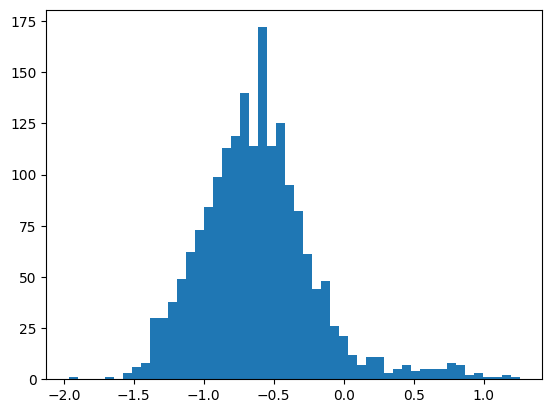

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
data = pd.read_csv(r"C:\Users\6331823\Local SSD\Data_Merel\Exp115\Experiment_F00\properties\Frame-0_props.csv")
plt.hist(data["log_ratio_aldob_dapi"], bins=50)

In [14]:
# Full Lyz Alb pipeline

image = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F26\cropped\Frame-0.tif"
)

# Dapi segmentation
mtmg = image[:, 0]
dapi = image[:, 1]
aldob = image[:, 2]
lyz = image[:, 3]
model = load_model(
    r"C:\Users\6331823\Local SSD\Train fixed intestinal 40x\models\fixed_intestinal_40x"
)

dapi_masks = []
for z in range(dapi.shape[0]):
    mask, _, _ = model.eval(
        dapi[z],
        diameter=None,
        normalize=True,
        flow_threshold=0.4,
        invert=False,
        resample=True,
        do_3D=False,
        min_size=size,
        niter=200,
    )
    dapi_masks.append(mask)
dapi_masks = np.stack(dapi_masks, axis=0)
tifffile.imwrite(
    rf"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\dapi_basic_mask.tif",
    dapi_masks,
    compression="zlib",
    compressionargs={"level": 8},
)

unfiltered_dapi_masks, dapi_masks, stats_df = stitch_sebastian(dapi_masks, max_search_range=6, max_height=5)

tifffile.imwrite(
    rf"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\dapi_stitched.tif",
    dapi_masks,
    compression="zlib",
    compressionargs={"level": 8},
)

count_dapi = len(np.unique(dapi_masks)) - 1  # Subtract 1 to exclude background
print(f"Counted {count_dapi} DAPI positive cells")

# Lyz segmentation
model = load_model(r"C:\Users\6331823\Local SSD\Train lyz\models\lyz")

lyz_masks = []
for z in range(lyz.shape[0]):
    mask, _, _ = model.eval(
        lyz[z],
        diameter=None,
        normalize=True,
        flow_threshold=0.4,
        invert=False,
        resample=True,
        do_3D=False,
        min_size=size,
        niter=200,
    )
    lyz_masks.append(mask)
lyz_masks = np.stack(lyz_masks, axis=0)
tifffile.imwrite(
    rf"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\lyz_basic_mask.tif",
    lyz_masks,
    compression="zlib",
    compressionargs={"level": 8},
)

lyz_masks = stitch3D(lyz_masks)
props = regionprops(lyz_masks)
all_centroids = []
for prop in props:
    all_centroids.append(
        {
            "height": prop.bbox[3] - prop.bbox[0],
            "particle": prop.label,  # original 2D label
            "volume": prop.area,
        }
    )
lyz_tracked = pd.DataFrame(all_centroids)

lyz_tracked_filtered = lyz_tracked[lyz_tracked["height"] > 1]
lyz_tracked_filtered = lyz_tracked_filtered[lyz_tracked_filtered["volume"] > 600]

lyz_masks_filtered = np.zeros_like(lyz_masks, dtype=np.uint32)
for _, row in lyz_tracked_filtered.iterrows():
    # z = int(row["z"])
    particle_id = int(row["particle"])

    # Copy the original mask pixels and relabel with new particle_id
    lyz_masks_filtered[lyz_masks == particle_id] = particle_id

tifffile.imwrite(
    rf"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\lyz_stitched.tif",
    lyz_masks_filtered,
    compression="zlib",
    compressionargs={"level": 8},
)

count_lyz = len(np.unique(lyz_masks_filtered)) - 1  # Subtract 1 to exclude background
print(f"Counted {count_lyz} Lyz positive cells")

stats, dilated_mask = measure_dilated(
    dapi_masks,
    dilation_size=12,
    channels=[mtmg, dapi, aldob, lyz],
    channel_names=["mTmG", "DAPI", "AldoB", "Lyz"],
)

aldob_filtered = stats[stats["log_ratio_aldob_dapi"] > -0.5]

aldob_masks = np.zeros_like(dapi_masks, dtype=np.uint32)
for _, row in aldob_filtered.iterrows():
    # z = int(row["z"])
    particle_id = int(row["label"])

    # Copy the original mask pixels and relabel with new particle_id
    aldob_masks[dapi_masks == particle_id] = particle_id

tifffile.imwrite(
    rf"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\aldob_stitched.tif",
    aldob_masks,
    compression="zlib",
    compressionargs={"level": 8},
)

count_aldob = len(aldob_filtered)
print(f"Counted {count_aldob} Aldob positive cells.")

print(f"Found {count_lyz} paneth cells out of {count_dapi} total cells. Which is {count_lyz / count_dapi * 100:.2f}%")
print(
    f"Found {count_aldob} AldoB positive cells out of {count_dapi} total cells. Which is {count_aldob / count_dapi * 100:.2f}%"
)

NameError: name 'load_model' is not defined

In [158]:
viewer = napari.Viewer(ndisplay=3)
viewer.add_image(dapi, name="DAPI", scale=(8.125, 1, 1), blending="additive", contrast_limits=[0, 2500], visible=True, colormap="blue")
viewer.add_image(
    mtmg,
    name="mtmg",
    scale=(8.125, 1, 1),
    blending="additive",
    contrast_limits=[0, 3000],
    visible=False,
    colormap="green",
)
viewer.add_image(
    aldob,
    name="AldoB",
    scale=(8.125, 1, 1),
    blending="additive",
    contrast_limits=[0, 3000],
    visible=False,
    colormap="green",
)
viewer.add_image(
    lyz,
    name="Lyz",
    scale=(8.125, 1, 1),
    blending="additive",
    contrast_limits=[0, 3000],
    visible=False,
    colormap="gray",
)
viewer.add_labels(dapi_masks, name="DAPI Mask", scale=(8.125, 1, 1), blending="additive", visible=False)
viewer.add_labels(
    aldob_masks, name="AldoB Mask", scale=(8.125, 1, 1), blending="additive", visible=True
)
viewer.add_labels(
    lyz_masks_filtered, name="Lyz Mask", scale=(8.125, 1, 1), blending="additive", visible=False
)

RuntimeError: sequence argument must have length equal to input rank

RuntimeError: sequence argument must have length equal to input rank

<Labels layer 'Lyz Mask' at 0x1e8077ae450>

In [48]:
import os
import numpy as np
from cellpose import io, transforms

def make_train_3d(
    input_image,
    input_mask,
    nimg_per_tif=10,
    crop_size=None,
    channel_axis=-1,
    z_axis=0,
    anisotropy=1.0,
    tile_norm=0,
    sharpen_radius=0.0,
):
    np.random.seed(0)
    nimg_per_tif = nimg_per_tif
    crop_size = crop_size
    dirname = os.path.split(input_image)[0]
    os.makedirs(os.path.join(dirname, "train/"), exist_ok=True)
    pm = [(0, 1, 2, 3), (2, 0, 1, 3), (1, 0, 2, 3)]
    npm = ["YX", "ZY", "ZX"]
    name = os.path.splitext(os.path.split(input_image)[-1])[0]
    img0 = io.imread_3D(input_image)
    mask0 = io.imread_3D(input_mask)

    try:
        img0 = transforms.convert_image(
            img0, channel_axis=channel_axis, z_axis=z_axis, do_3D=True
        )
        mask0 = transforms.convert_image(
            mask0, channel_axis=channel_axis, z_axis=z_axis, do_3D=True
        )
    except ValueError:
        print(
            "Error converting image. Did you provide the correct --channel_axis and --z_axis ?"
        )

    for p in range(3):
        img = img0.transpose(pm[p]).copy()
        mask = mask0.transpose(pm[p]).copy()
        print(npm[p], img[0].shape)
        Ly, Lx = img.shape[1:3]
        indices = np.random.permutation(img.shape[0])[:nimg_per_tif]
        imgs = img[indices]
        masks = mask[indices]
        if anisotropy > 1.0 and p > 0:
            imgs = transforms.resize_image(imgs, Ly=int(anisotropy * Ly), Lx=Lx)
            # Use nearest neighbor for masks to preserve integer labels
            from scipy.ndimage import zoom

            zoom_factors = (
                (1, anisotropy, 1) if len(masks.shape) == 3 else (1, anisotropy, 1, 1)
            )
            masks = zoom(masks, zoom_factors, order=0)
        for k, (img, mask, indice) in enumerate(zip(imgs, masks, indices)):
            # if the mask file is emtpy, we skip it
            print(f"Processing {name}_{npm[p]}_{k}_slice{indice}: {len(np.unique(mask))}")
            if len(np.unique(mask)) == 1:
                print(f"Skipping empty mask for {name}_{npm[p]}_{k}")
                continue

            if tile_norm:
                img = transforms.normalize99_tile(img, blocksize=tile_norm)
            if sharpen_radius:
                img = transforms.smooth_sharpen_img(img, sharpen_radius=sharpen_radius)

            if crop_size != None:
                ly = 0 if Ly - crop_size <= 0 else np.random.randint(0, Ly - crop_size)
                lx = 0 if Lx - crop_size <= 0 else np.random.randint(0, Lx - crop_size)
                img = img[ly : ly + crop_size, lx : lx + crop_size]
                mask = mask[ly : ly + crop_size, lx : lx + crop_size]

            io.imsave(
                os.path.join(
                    dirname, f"train/{name}_{npm[p]}_{k}_slice{indice}.tif"
                ),
                img.squeeze(),
            )
            io.imsave(
                os.path.join(dirname, f"train/{name}_{npm[p]}_{k}_slice{indice}_masks.tif"),
                mask.squeeze(),
            )


make_train_3d(
    input_image=r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\cropped_nuclei.tif",
    input_mask=r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\Manual corrected.tif",
    anisotropy=8.125,
    nimg_per_tif=30
)

from cellpose import io, models, train

io.logger_setup()

output = io.load_train_test_data(
    r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\train",
    mask_filter="_masks",
    look_one_level_down=False,
)
images, labels, image_names, test_images, test_labels, image_names_test = output


model_path, train_losses, test_losses = train.train_seg(
    model.net,
    train_data=images,
    train_labels=labels,
    # test_data=test_images,
    # test_labels=test_labels,
    weight_decay=0.1,
    learning_rate=1e-5,
    n_epochs=100,
    model_name="my_new_model",
)

2025-10-28 16:25:29,471 [INFO] reading tiff with 56 planes


100%|██████████| 56/56 [00:00<00:00, 848.10it/s]


2025-10-28 16:25:29,878 [INFO] reading tiff with 56 planes


100%|██████████| 56/56 [00:00<00:00, 354.53it/s]


YX (764, 950, 3)
Processing cropped_nuclei_YX_0_slice45: 34
Processing cropped_nuclei_YX_1_slice33: 137
Processing cropped_nuclei_YX_2_slice40: 55
Processing cropped_nuclei_YX_3_slice26: 231
Processing cropped_nuclei_YX_4_slice11: 1
Skipping empty mask for cropped_nuclei_YX_4
Processing cropped_nuclei_YX_5_slice2: 1
Skipping empty mask for cropped_nuclei_YX_5
Processing cropped_nuclei_YX_6_slice32: 168
Processing cropped_nuclei_YX_7_slice43: 32
Processing cropped_nuclei_YX_8_slice46: 29
Processing cropped_nuclei_YX_9_slice30: 213
Processing cropped_nuclei_YX_10_slice4: 1
Skipping empty mask for cropped_nuclei_YX_10
Processing cropped_nuclei_YX_11_slice10: 1
Skipping empty mask for cropped_nuclei_YX_11
Processing cropped_nuclei_YX_12_slice28: 211
Processing cropped_nuclei_YX_13_slice22: 270
Processing cropped_nuclei_YX_14_slice31: 193
Processing cropped_nuclei_YX_15_slice49: 24
Processing cropped_nuclei_YX_16_slice37: 71
Processing cropped_nuclei_YX_17_slice7: 1
Skipping empty mask for 

  0%|          | 0/76 [00:00<?, ?it/s]c:\Users\6331823\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
c:\Users\6331823\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
100%|██████████| 76/76 [00:00<00:00, 37880.82it/s]

2025-10-28 16:25:35,448 [WARNING] 76 train images with number of masks less than min_train_masks (5), removing from train set


ZeroDivisionError: float division by zero

100%|██████████| 56/56 [00:00<00:00, 447.80it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..412].


YX (764, 950, 3)
[44  0 16 19 25 23 37 33 46 14]


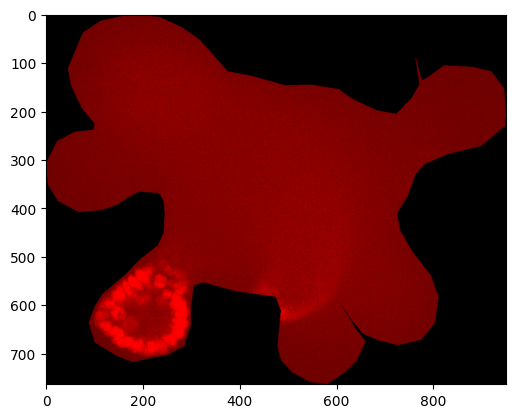

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..2766].


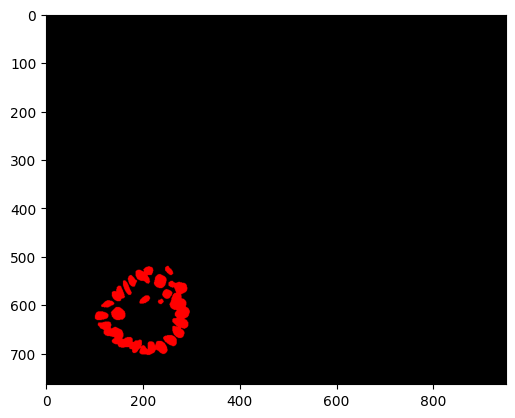

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..1044].


ZY (56, 764, 3)
[721 695 838  29 302 527 358   8 684 279]


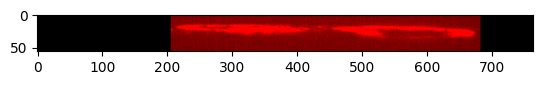

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..2520].


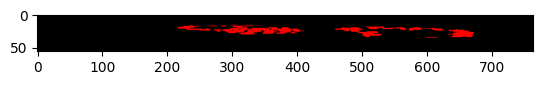

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..1041].


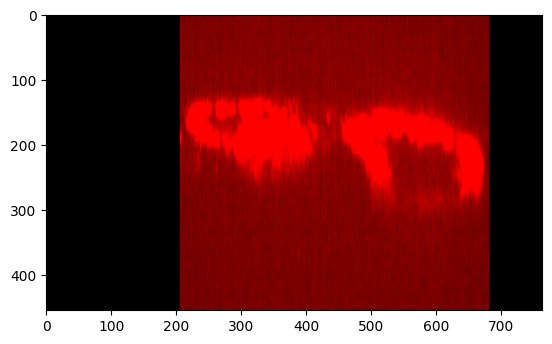

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..2520].


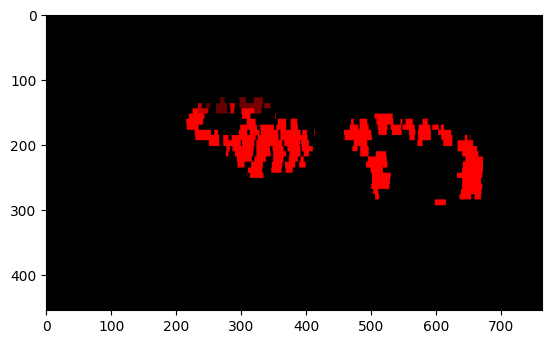

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..1215].


ZX (56, 950, 3)
[528 290 635 556 719 631 487 208 171 697]


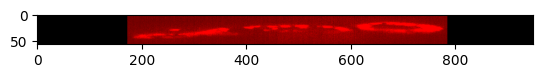

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..2757].


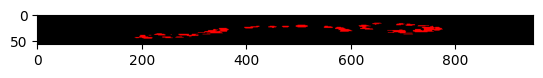

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..1190].


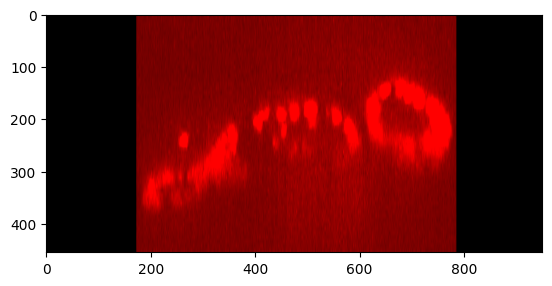

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..2757].


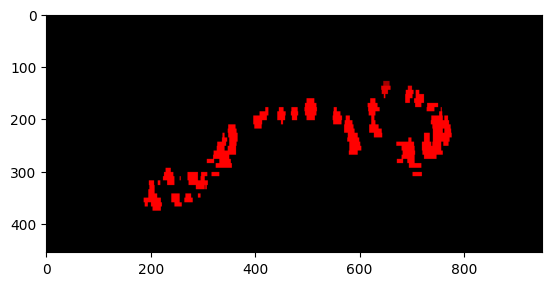

In [ ]:
import napari
import matplotlib.pyplot as plt
from cmap import Colormap

cm = Colormap("glasbey:glasbey")
mpl_cmap = cm.to_mpl()

input_image = r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\cropped_nuclei.tif"
input_mask = r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\Manual corrected.tif"

channel_axis=-1
z_axis=0
pm = [(0, 1, 2, 3), (2, 0, 1, 3), (1, 0, 2, 3)]
npm = ["YX", "ZY", "ZX"]
nimg_per_tif = 10
anisotropy = 8.125

img0 = io.imread_3D(input_image)
mask0 = io.imread_3D(input_mask)

for p in range(3):
    img = img0.transpose(pm[p]).copy() #make image either normal, yz or xz
    mask = mask0.transpose(pm[p]).copy()
    print(npm[p], img[0].shape)
    Ly, Lx = img.shape[1:3]
    indices = np.random.permutation(img.shape[0])[:nimg_per_tif]
    print(indices)
    imgs = img[indices]
    plt.imshow(imgs[0], cmap="gray")
    plt.show()
    masks = mask[indices]
    plt.imshow(masks[0], cmap="viridis")
    plt.show()
    if anisotropy > 1.0 and p > 0: #on XZ and YZ planes
        imgs = transforms.resize_image(imgs, Ly=int(anisotropy * Ly), Lx=Lx)
        plt.imshow(imgs[0], cmap="gray")
        plt.show()
        # Use nearest neighbor for masks to preserve integer labels
        from scipy.ndimage import zoom

        zoom_factors = (
            (1, anisotropy, 1) if len(masks.shape) == 3 else (1, anisotropy, 1, 1)
        )
        masks = zoom(masks, zoom_factors, order=0)
        plt.imshow(masks[0], cmap="gray")
        plt.show()

# viewer = napari.Viewer(ndisplay=3)
# viewer.add_image(img0[:,:,:,0], name="nuclei", scale=(8.125, 1, 1), blending="additive", contrast_limits=[0, 2500])

In [11]:
from scipy.ndimage import distance_transform_edt

mask = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F27\dapi_stitched.tif"
)


def voronoi_dilate_mask(
    mask,
    dilation_size=1,
):
    dilated = np.zeros_like(mask)

    for z in range(mask.shape[0]):
        slice_mask = mask[z]
        distance, indices = distance_transform_edt(
            slice_mask == 0, return_indices=True  # Find distances from background
        )
        expanded_slice = slice_mask.copy()
        expand_region = (slice_mask == 0) & (distance <= dilation_size)

        # Use indices to find which label each background pixel is nearest to
        expanded_slice[expand_region] = slice_mask[
            indices[0][expand_region], indices[1][expand_region]
        ]

        dilated[z] = expanded_slice

    # If you need to preserve the original dtype
    mask = dilated.astype(mask.dtype)
    return mask

In [ ]:
# Movie for presentation
import os
import tifffile
import napari
import numpy as np
from napari_animation import Animation
from napari.layers import Labels


scale = (2.47, 0.304, 0.304)
input_directory = (
    r"C:\Users\6331823\Local SSD\Data_Merel\EXP087\20250604_Lyz_AldoB_DAPI.40x_F00"
)
image = tifffile.imread(os.path.join(input_directory, "cropped", "Frame-0.tif"))
print(image.shape)
dapi_masks = tifffile.imread(os.path.join(input_directory, "dapi_stitched.tif"))
aldob_masks = tifffile.imread(os.path.join(input_directory, "aldob_stitched.tif"))
lyz_masks = tifffile.imread(os.path.join(input_directory, "lyz_stitched.tif"))

# Dapi segmentation
dapi = image[:, 1]
aldob = image[:, 2]
mtmg = image[:, 0]
lyz = image[:, 3]

viewer = napari.Viewer(ndisplay=3)
viewer.add_image(
    dapi,
    name="DAPI",
    scale=scale,
    blending="additive",
    contrast_limits=[100, 900],
    visible=True,
    colormap="blue",
)
viewer.add_image(
    mtmg,
    name="mtmg",
    scale=scale,
    blending="additive",
    contrast_limits=[300, 2000],
    visible=False,
    colormap="magenta",
)
viewer.add_image(
    aldob,
    name="AldoB",
    scale=scale,
    blending="additive",
    contrast_limits=[200, 2000],
    visible=True,
    colormap="green",
)
viewer.add_image(
    lyz,
    name="Lyz",
    scale=scale,
    blending="additive",
    contrast_limits=[100, 3000],
    visible=True,
    colormap="gray",
)

# Make an 8 bit image with pixel 255 where DAPI masks are present
dapi_masks_image = np.zeros_like(dapi_masks, dtype=np.uint8)
dapi_masks_image[dapi_masks > 0] = 1

from napari.utils.colormaps import label_colormap
default_colors = label_colormap(49)
default_colors.colors[1] = [0, 0, 1, 1]  # Blue
default_colors.colors[2] = [0, 1, 0, 1]  # Green
default_colors.colors[3] = [1, 1, 1, 1]  # White

opacity = 1

viewer.add_labels(
    dapi_masks_image,
    name="DAPI Masks",
    scale=scale,
    blending="translucent",
    visible=False,
    iso_gradient_mode="smooth",
    colormap=default_colors,  # Apply blue color
    opacity=opacity
)


aldob_masks_image = np.zeros_like(aldob_masks, dtype=np.uint8)
aldob_masks_image[aldob_masks > 0] = 2
viewer.add_labels(
    aldob_masks_image,
    name="AldoB Masks",
    scale=scale,
    blending="translucent",
    visible=False,
    iso_gradient_mode="smooth",
    colormap=default_colors,  # Apply green color
    opacity=opacity
)

lyz_masks_image = np.zeros_like(lyz_masks, dtype=np.uint8)
lyz_masks_image[lyz_masks > 0] = 3
viewer.add_labels(
    lyz_masks_image,
    name="Lyz Masks",
    scale=scale,
    blending="translucent",
    visible=False,
    iso_gradient_mode="smooth",
    colormap=default_colors,  # Apply white color
    opacity=opacity
)

viewer.layers["DAPI"].visible = True
viewer.layers["mtmg"].visible = False
viewer.layers["AldoB"].visible = True
viewer.layers["Lyz"].visible = True
viewer.layers["DAPI Masks"].visible = False
viewer.layers["AldoB Masks"].visible = False
viewer.layers["Lyz Masks"].visible = False


animation = Animation(viewer)
viewer.camera.angles = (0.0, 0.0, 90.0)

n_frames = 300
n_steps = 20  # total keyframes for rotation

# Forward sweep - capture keyframes for 0° to 360°
for i in range(n_steps):
    frame = int(i * n_frames / n_steps)
    angle = i * 360 / n_steps  # Angles: 0, 36, 72, ..., 324
    viewer.dims.set_point(0, frame)
    viewer.camera.angles = (angle, 30)
    animation.capture_keyframe()

# **Important**: Add final keyframe at 360° (same as 0°) to close the loop
viewer.dims.set_point(0, 0)  # Return to first frame
viewer.camera.angles = (360, 30)  # Or (0, 30) - they're equivalent
animation.capture_keyframe()

# Export animation
animation.animate(filename=r"C:\Users\6331823\Downloads\test2.mp4", fps=30)

(45, 6, 868, 807)


<Image layer 'Lyz' at 0x1cf82bc8ad0>

In [54]:
import pandas as pd
import os
import re
# input_directories = [
#     r"D:\Exp139",
#     r"C:\Users\6331823\Local SSD\Data_Anna\Exp137",
#     r"C:\Users\6331823\Local SSD\Data_Anna\Exp140",
# ]
# to_skip = [
#     "CRC_s39",
#     "CRC_s41",
#     "CRC_s90",
#     "MIX_s48" "EXpansionLMix_11",
#     "EXpansionLMix_5",
#     "EXpansionLWT_Pure_10",
#     "EXpansionLWT_Pure_14",
#     "EXpansion_CRC_1",
#     "EXpansion_CRC_4",
#     "EXpansion_CRC_5",
#     "EXpansion_CRC_6",
#     "EXpansion_CRC_7",
#     "EXpansion_CRC_8",
#     "EXpansion_CRC_11",
#     "EXpansion_CRC_13",
#     "EXpansion_CRC_14",
#     "CRC_Expension_7",
#     # "CRC_Expension_8",
#     "MIX_Expension_32",
#     "MIX_Expension_39",
# ]
input_directories = [r"E:\elise"]
to_skip = ["TL2_Imaging_20x_F19"]

data = []
for input_directory in input_directories:
    for organoid in os.listdir(input_directory):
        if not os.path.isdir(os.path.join(input_directory, organoid)) or organoid in to_skip:
            continue
        df = pd.read_csv(os.path.join(input_directory, organoid, "summary_results_organoid.csv"))
        data.append(df)
data = pd.concat(data, ignore_index=True)


# Find the frame number in file column and create time column my multiplying by 5
data["time"] = data["file"].str.extract(r"Frame-(\d+)").astype(int) * 4

def classify_organoid(name: str) -> str:
    m = re.search(r"F(\d+)", name, flags=re.IGNORECASE)
    if not m:
        return "Mix"
    n = int(m.group(1))
    if n < 10:
        return "Primary"
    if 10 <= n <= 35:
        return "Mix"
    return "Enriched"


data["type"] = data["organoid"].apply(classify_organoid)
# Create a binary indicator for pure vs mixed
data["phenotype_category"] = data["type"].apply(
    lambda x: "Pure" if x in ["Primary", "Enriched"] else "Mixed"
)

# rename data columns wt to enriched and crc to primary
data = data.rename(columns={"wt_count": "enriched_count", "crc_count": "primary_count", "relative_wt": "relative_enriched", "relative_crc": "relative_primary"})

data.to_csv(r"E:\elise\data.csv", index=False)

In [37]:
# selected = data[(data["time"] == 0) & (data["phenotype_category"] == "Mixed")  & (data["%wt"] >=35) & (data["%wt"] <=65)]
# print(selected["organoid"].unique())
# selected = data[data["organoid"].isin(selected["organoid"].unique())]
# selected = pd.concat(
#     [selected, data[data["phenotype_category"] == "Pure"]], ignore_index=True
# )

# selected
data

,organoid,file,enriched_count,primary_count,%wt,%crc,relative_enriched,relative_primary,time,type,phenotype_category
0,TL2_Imaging_20x_F44,Frame-0.tif,89,0,100.000000,0.000000,1.000000,NaN,0,Enriched,Pure
1,TL2_Imaging_20x_F44,Frame-1.tif,97,0,100.000000,0.000000,1.089888,NaN,4,Enriched,Pure
2,TL2_Imaging_20x_F44,Frame-2.tif,123,0,100.000000,0.000000,1.382022,NaN,8,Enriched,Pure
3,TL2_Imaging_20x_F44,Frame-3.tif,143,0,100.000000,0.000000,1.606742,NaN,12,Enriched,Pure
4,TL2_Imaging_20x_F44,Frame-4.tif,158,1,99.371069,0.628931,1.775281,inf,16,Enriched,Pure
...,...,...,...,...,...,...,...,...,...,...,...
229,TL2_Imaging_20x_F38,Frame-13.tif,198,0,100.000000,0.000000,3.000000,NaN,52,Enriched,Pure
230,TL2_Imaging_20x_F38,Frame-14.tif,164,0,100.000000,0.000000,2.484848,NaN,56,Enriched,Pure
231,TL2_Imaging_20x_F38,Frame-15.tif,184,1,99.459459,0.540541,2.787879,inf,60,Enriched,Pure
232,TL2_Imaging_20x_F38,Frame-16.tif,230,0,100.000000,0.000000,3.484848,NaN,64,Enriched,Pure


In [38]:
for i, row in data.iterrows():
    if row["type"] == "Primary":
        data.at[i, "relative_enriched"] = 0
    elif row["type"] == "Enriched":
        data.at[i, "relative_primary"] = 0

display(data)

,organoid,file,enriched_count,primary_count,%wt,%crc,relative_enriched,relative_primary,time,type,phenotype_category
0,TL2_Imaging_20x_F44,Frame-0.tif,89,0,100.000000,0.000000,1.000000,0.0,0,Enriched,Pure
1,TL2_Imaging_20x_F44,Frame-1.tif,97,0,100.000000,0.000000,1.089888,0.0,4,Enriched,Pure
2,TL2_Imaging_20x_F44,Frame-2.tif,123,0,100.000000,0.000000,1.382022,0.0,8,Enriched,Pure
3,TL2_Imaging_20x_F44,Frame-3.tif,143,0,100.000000,0.000000,1.606742,0.0,12,Enriched,Pure
4,TL2_Imaging_20x_F44,Frame-4.tif,158,1,99.371069,0.628931,1.775281,0.0,16,Enriched,Pure
...,...,...,...,...,...,...,...,...,...,...,...
229,TL2_Imaging_20x_F38,Frame-13.tif,198,0,100.000000,0.000000,3.000000,0.0,52,Enriched,Pure
230,TL2_Imaging_20x_F38,Frame-14.tif,164,0,100.000000,0.000000,2.484848,0.0,56,Enriched,Pure
231,TL2_Imaging_20x_F38,Frame-15.tif,184,1,99.459459,0.540541,2.787879,0.0,60,Enriched,Pure
232,TL2_Imaging_20x_F38,Frame-16.tif,230,0,100.000000,0.000000,3.484848,0.0,64,Enriched,Pure


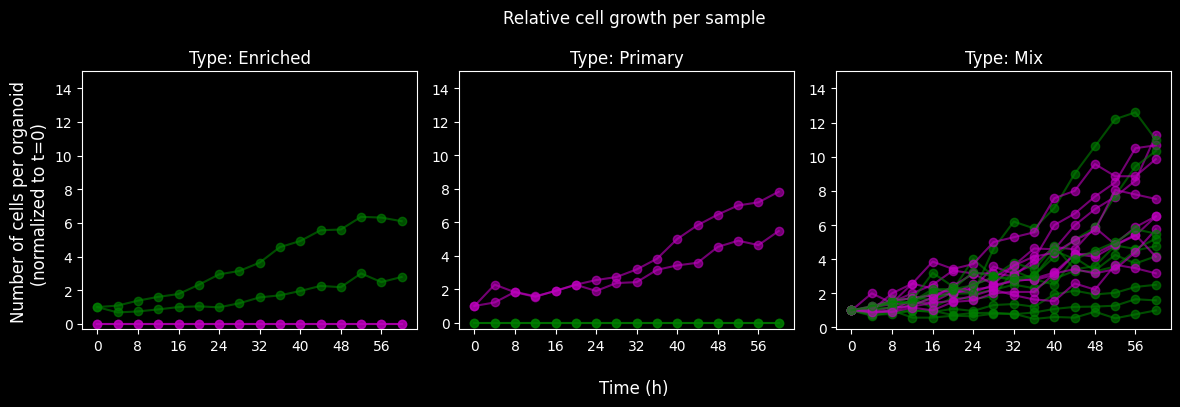

In [41]:
import matplotlib.pyplot as plt

ylim_max = 15
df = data.copy()
df = df[df["time"] <= 60]


fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=False)
plt.style.use("dark_background")

for i, type_name in enumerate(df["type"].unique()):
    ax = axes[i]
    subset = df[df["type"] == type_name]

    for organoid, group in subset.groupby("organoid"):
        ax.plot(
            group["time"],
            group["relative_primary"],
            "m-",
            marker="o",
            label=f"{organoid} primary",
            alpha=0.6,
        )
        ax.plot(
            group["time"],
            group["relative_enriched"],
            "g-",
            marker="o",
            label=f"{organoid} enriched",
            alpha=0.6,
        )
    ax.set_title(f"Type: {type_name}")
    ax.set_xticks(sorted(subset["time"].unique())[::2])
    # ax.legend(fontsize="small", loc="upper left", ncol=1)

    # Apply y-axis limit if provided
    if ylim_max is not None:
        ax.set_ylim(top=ylim_max)

fig.suptitle("Relative cell growth per sample", x=0.54)
fig.supxlabel("Time (h)", x=0.54)
fig.supylabel("Number of cells per organoid\n       (normalized to t=0)")
plt.tight_layout()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


3.0506152506282427


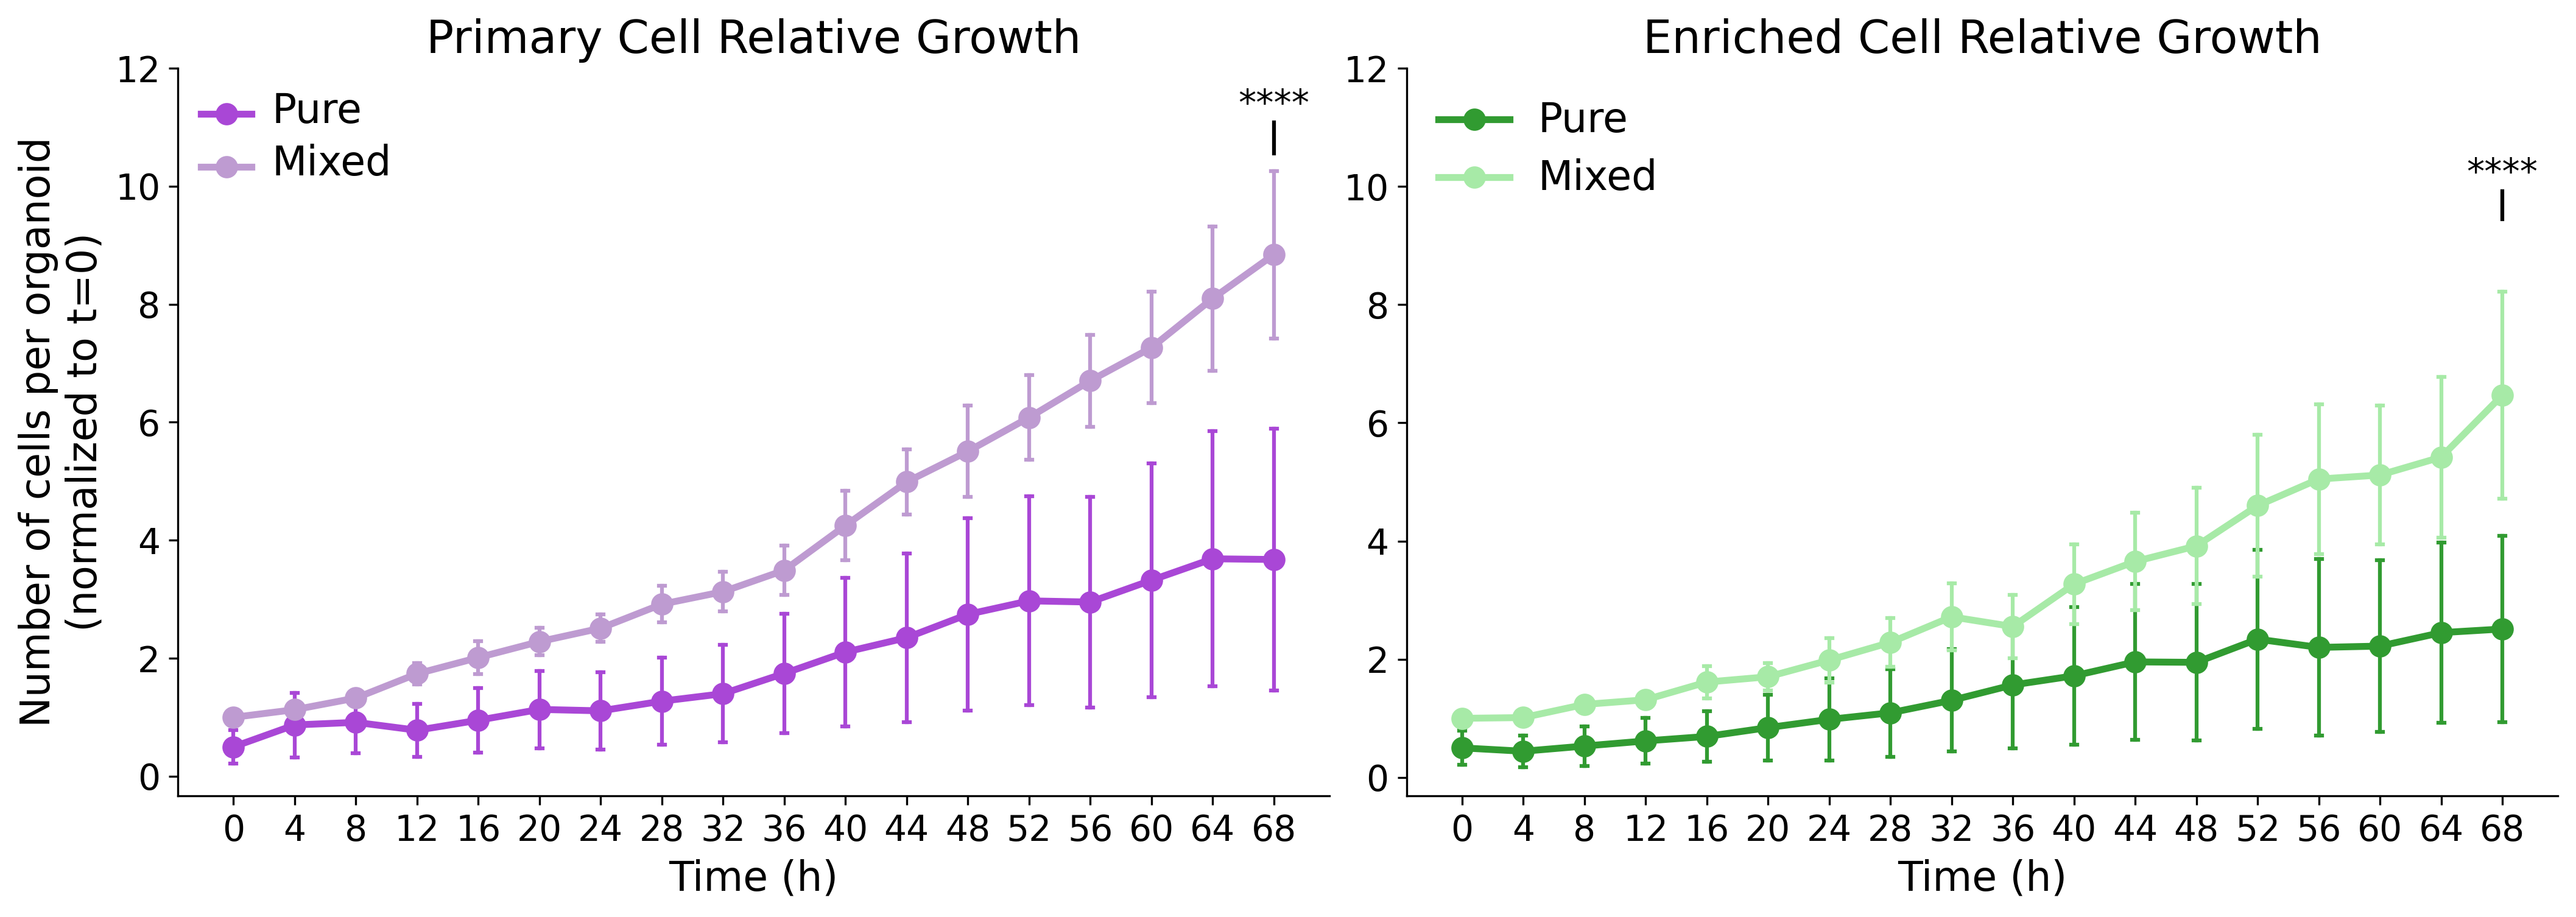

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from matplotlib.ticker import MaxNLocator


def add_stat_annotation(ax, x, y, p_value, height_offset=0.05, fontsize=12, colour="black"):
    """Add statistical annotation bracket"""
    # Format p-value
    if p_value < 0.0001:
        text = "****"
    elif p_value < 0.001:
        text = "***"
    elif p_value < 0.01:
        text = "**"
    elif p_value < 0.05:
        text = "*"
    else:
        text = "ns"

    # Get y-axis limits
    ylim = ax.get_ylim()
    y_range = ylim[1] - ylim[0]
    y_pos = y + (y_range * height_offset)

    # Draw straight horizontal line
    ax.plot([x, x], [y_pos, y_pos + y_pos*0.05], lw=1.5, c=colour)

    # Add text
    ax.text(
        x,
        y_pos + y_pos*0.05,
        text,
        ha="center",
        va="bottom",
        fontsize=fontsize,
        color=colour,
    )


# plt.style.use("dark_background")
plt.style.use("default")

ylim_max = 12
df = data.copy()
# df = selected.copy()
# df = df[df["time"] <= 60]

# Create two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=False, dpi=300)

# Plot 1: relative_wt
sns.pointplot(
    data=df,
    x="time",
    y="relative_primary",
    hue="phenotype_category",
    hue_order=["Pure", "Mixed"],
    palette={"Pure": "#a947d6", "Mixed": "#be9bd1"},
    ax=axes[0],
    errorbar="se",  # or "se" for standard error, or ("ci", 95) for confidence interval
    capsize=0.1,  # Width of error bar caps
    err_kws={"linewidth": 1.5},  # Style the error bars
)
axes[0].set_title("Primary Cell Relative Growth", fontsize=14)
axes[0].set_ylabel("Number of cells per organoid\n(normalized to t=0)", fontsize=12)
axes[0].set_xlabel("Time (h)", fontsize=12)
axes[0].legend(title="", fontsize=10)

# Plot 2: relative_enriched
sns.pointplot(
    data=df,
    x="time",
    y="relative_enriched",
    hue="phenotype_category",
    hue_order=["Pure", "Mixed"],
    palette={"Pure": "#319b31", "Mixed": "#a7eaa7"},
    ax=axes[1],
    errorbar="se",
    capsize=0.1,
    err_kws={"linewidth": 1.5},
)
axes[1].set_title("Enriched Cell Relative Growth", fontsize=14)
axes[1].set_ylabel("")
axes[1].set_xlabel("Time (h)", fontsize=14)
axes[1].legend(title="", fontsize=14)


pure_primary = df[(df["phenotype_category"] == "Pure")]["relative_primary"].dropna()
mixed_primary = df[(df["phenotype_category"] == "Mixed")]["relative_primary"].dropna()
# Independent t-test (assumes normality)
t_stat, p_value = stats.ttest_ind(pure_primary, mixed_primary)

primary_pure_mean = df[(df["phenotype_category"] == "Pure")]["relative_primary"].mean()
primary_mixed_mean = df[(df["phenotype_category"] == "Mixed")]["relative_primary"].mean()
primary_max = max(primary_pure_mean, primary_mixed_mean)

add_stat_annotation(axes[0], len(df["time"].unique()) - 1, 10, p_value, fontsize=14)

# Independent samples t-test (or Mann-Whitney if non-normal)
pure_enriched = df[(df["phenotype_category"] == "Pure")]["relative_enriched"].dropna()
mixed_enriched = df[(df["phenotype_category"] == "Mixed")]["relative_enriched"].dropna()

# Independent t-test (assumes normality)
t_stat, p_value = stats.ttest_ind(pure_enriched, mixed_enriched)

enriched_pure_mean = df[(df["phenotype_category"] == "Pure")]["relative_enriched"].mean()
enriched_mixed_mean = df[(df["phenotype_category"] == "Mixed")]["relative_enriched"].mean()
enriched_max = max(enriched_pure_mean, enriched_mixed_mean)
print(enriched_max)

add_stat_annotation(axes[1], len(df["time"].unique()) - 1, 9, p_value, fontsize=14)

# fig.suptitle("Relative Cell Growth: Pure vs Mixed Organoids", fontsize=16, y=1.02)
plt.tight_layout()
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # remove legend box
    ax.legend_.get_frame().set_linewidth(0.0)
    ax.title.set_fontsize(18)
    ax.xaxis.label.set_fontsize(16)
    ax.yaxis.label.set_fontsize(16)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    # make legend text bigger
    ax.set_ylim(top=ylim_max)
    for text in ax.legend_.get_texts():
        text.set_fontsize(16)

plt.savefig(
    r"C:\Users\6331823\Downloads\Population plot.eps",
    format="eps",
    bbox_inches="tight",
    dpi=300,
)
plt.show()

In [1]:
import pandas as pd
import os
import numpy as np

input_directories = [
    r"D:\Exp139",
    r"C:\Users\6331823\Local SSD\Data_Anna\Exp137",
    r"C:\Users\6331823\Local SSD\Data_Anna\Exp140",
]
to_skip = [
    "CRC_s39",
    "CRC_s41",
    "CRC_s90",
    "MIX_s48" "EXpansionLMix_11",
    "EXpansionLMix_5",
    "EXpansionLWT_Pure_10",
    "EXpansionLWT_Pure_14",
    "EXpansion_CRC_1",
    "EXpansion_CRC_4",
    "EXpansion_CRC_5",
    "EXpansion_CRC_6",
    "EXpansion_CRC_7",
    "EXpansion_CRC_8",
    "EXpansion_CRC_11",
    "EXpansion_CRC_13",
    "EXpansion_CRC_14",
    "CRC_Expension_7",
    # "CRC_Expension_8",
    "MIX_Expension_32",
    "MIX_Expension_39",
]

data = []
for input_directory in input_directories:
    for organoid in os.listdir(input_directory):
        if (
            not os.path.isdir(os.path.join(input_directory, organoid))
            or organoid in to_skip
        ):
            continue
        print(f"Processing organoid: {organoid}")
        for frame in os.listdir(os.path.join(input_directory, organoid, "properties")):
            if not frame.endswith("_props.csv"):
                continue
            df = pd.read_csv(
                os.path.join(input_directory, organoid, "properties", frame)
            )
            df["organoid"] = organoid
            if not input_directory.endswith("Exp137"):
                df["new_x"] = df["x_pixel"] * 0.64
                df["new_y"] = df["y_pixel"] * 0.64
                df["new_z"] = df["z_pixel"] * 5
            else:
                df["new_x"] = df["x"] * 0.64
                df["new_y"] = df["y"] * 0.64
                df["new_z"] = df["z"] * 5

            # Create lookup dict for faster access
            coord_lookup = df.set_index("cell_id")[["new_x", "new_y", "new_z"]].to_dict(
                "index"
            )

            new_distances = []
            for idx, row in df.iterrows():
                # Parse neighbor IDs (assuming space-separated string)
                neighbours = row["5_knn_neighbors"].split("[")[1].split("]")[0]
                neighbors = [int(n) for n in str(neighbours).split()]

                distances = []
                for neighbor_id in neighbors:
                    if neighbor_id in coord_lookup:  # Check if neighbor exists
                        neighbor_coords = coord_lookup[neighbor_id]
                        distance = np.sqrt(
                            (neighbor_coords["new_x"] - row["new_x"]) ** 2
                            + (neighbor_coords["new_y"] - row["new_y"]) ** 2
                            + (neighbor_coords["new_z"] - row["new_z"]) ** 2
                        )
                        distances.append(distance)

                new_distances.append(np.mean(distances) if distances else np.nan)

            df["new_5_knn_distances"] = new_distances
            data.append(df)
data = pd.concat(data, ignore_index=True)

# Find the frame number in file column and create time column my multiplying by 5
data["time"] = (data["frame"] * 5).astype(int)
data["type"] = data["organoid"].apply(
    lambda x: "WT" if "WT" in x else ("CRC" if "CRC" in x else "Mix")
)
# Create a binary indicator for pure vs mixed
data["phenotype_category"] = data["type"].apply(
    lambda x: "Pure" if x in ["WT", "CRC"] else "Mixed"
)
# move these columns to the left
data = data[
    [
        "organoid",
        "frame",
        "time",
        "phenotype_category",
        "type",
    ]
    + [
        col
        for col in data.columns
        if col not in ["organoid", "frame", "time", "phenotype_category", "type"]
    ]
]

Processing organoid: EXpansionLMix_11
Processing organoid: EXpansionLMix_12
Processing organoid: EXpansionLMix_14
Processing organoid: EXpansionLMix_16
Processing organoid: EXpansionLMix_17
Processing organoid: EXpansionLMix_19
Processing organoid: EXpansionLMix_3
Processing organoid: EXpansionLMix_8
Processing organoid: EXpansionLWT_Pure_1
Processing organoid: EXpansionLWT_Pure_11
Processing organoid: EXpansionLWT_Pure_12
Processing organoid: EXpansionLWT_Pure_13
Processing organoid: EXpansionLWT_Pure_2
Processing organoid: EXpansionLWT_Pure_3
Processing organoid: EXpansionLWT_Pure_4
Processing organoid: EXpansionLWT_Pure_5
Processing organoid: EXpansionLWT_Pure_6
Processing organoid: EXpansionLWT_Pure_7
Processing organoid: EXpansionLWT_Pure_8
Processing organoid: EXpansionLWT_Pure_9
Processing organoid: EXpansion_CRC_10
Processing organoid: EXpansion_CRC_12
Processing organoid: EXpansion_CRC_15
Processing organoid: EXpansion_CRC_3
Processing organoid: CRC_s89
Processing organoid: CR

In [41]:
data

,organoid,frame,time,phenotype_category,type,label,z_pixel,y_pixel,x_pixel,bounding_box,...,log_ratio_crc_wt,phenotype,mean_knn_distance,5_knn_neighbors,cell_id,phenotype_similarity_score,new_x,new_y,new_z,new_5_knn_distances
0,EXpansionLMix_11,0,0,Mixed,Mix,1,3.939349,48.883136,97.829882,"(3, 41, 84, 6, 60, 110)",...,-0.204088,crc,14.041447,[30 77 75 1 11],0,5,62.611124,31.285207,19.696746,25.749160
1,EXpansionLMix_11,0,0,Mixed,Mix,2,3.000000,55.785714,84.805195,"(3, 49, 78, 4, 63, 93)",...,0.575021,crc,17.724095,[77 0 11 79 61],1,4,54.275325,35.702857,15.000000,37.837531
2,EXpansionLMix_11,0,0,Mixed,Mix,3,3.949710,63.205029,108.210832,"(3, 57, 98, 6, 72, 118)",...,-0.041388,crc,16.476182,[44 5 20 0 23],2,4,69.254932,40.451219,19.748549,14.585266
3,EXpansionLMix_11,0,0,Mixed,Mix,4,3.381333,72.901333,58.048000,"(3, 62, 50, 5, 87, 66)",...,-1.747802,wt,15.869784,[ 4 61 80 84 13],3,5,37.150720,46.656853,16.906667,37.584452
4,EXpansionLMix_11,0,0,Mixed,Mix,5,3.000000,71.525253,47.898990,"(3, 66, 43, 4, 78, 54)",...,-1.989209,wt,12.838356,[13 3 80 78 84],4,5,30.655354,45.776162,15.000000,37.089784
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
448995,WT_Expansion_9,9,45,Pure,WT,516,33.532673,216.637624,161.223762,"(32, 209, 155, 36, 224, 170)",...,-1.395539,wt,18.436668,[488 490 514 516 450],515,5,103.183208,138.648079,167.663366,11.824439
448996,WT_Expansion_9,9,45,Pure,WT,517,33.666667,225.929524,177.958095,"(32, 220, 168, 36, 233, 193)",...,-1.426995,wt,17.057576,[450 489 490 515 491],516,5,113.893181,144.594895,168.333333,11.064438
448997,WT_Expansion_9,9,45,Pure,WT,518,34.505882,148.404412,159.280882,"(33, 139, 151, 37, 161, 169)",...,-1.303191,wt,20.165013,[477 500 479 504 498],517,5,101.939765,94.978824,172.529412,13.068146
448998,WT_Expansion_9,9,45,Pure,WT,519,33.580282,175.011268,179.492958,"(33, 167, 170, 35, 184, 188)",...,-1.249293,wt,20.053212,[508 519 504 511 477],518,5,114.875493,112.007211,167.901408,12.863390


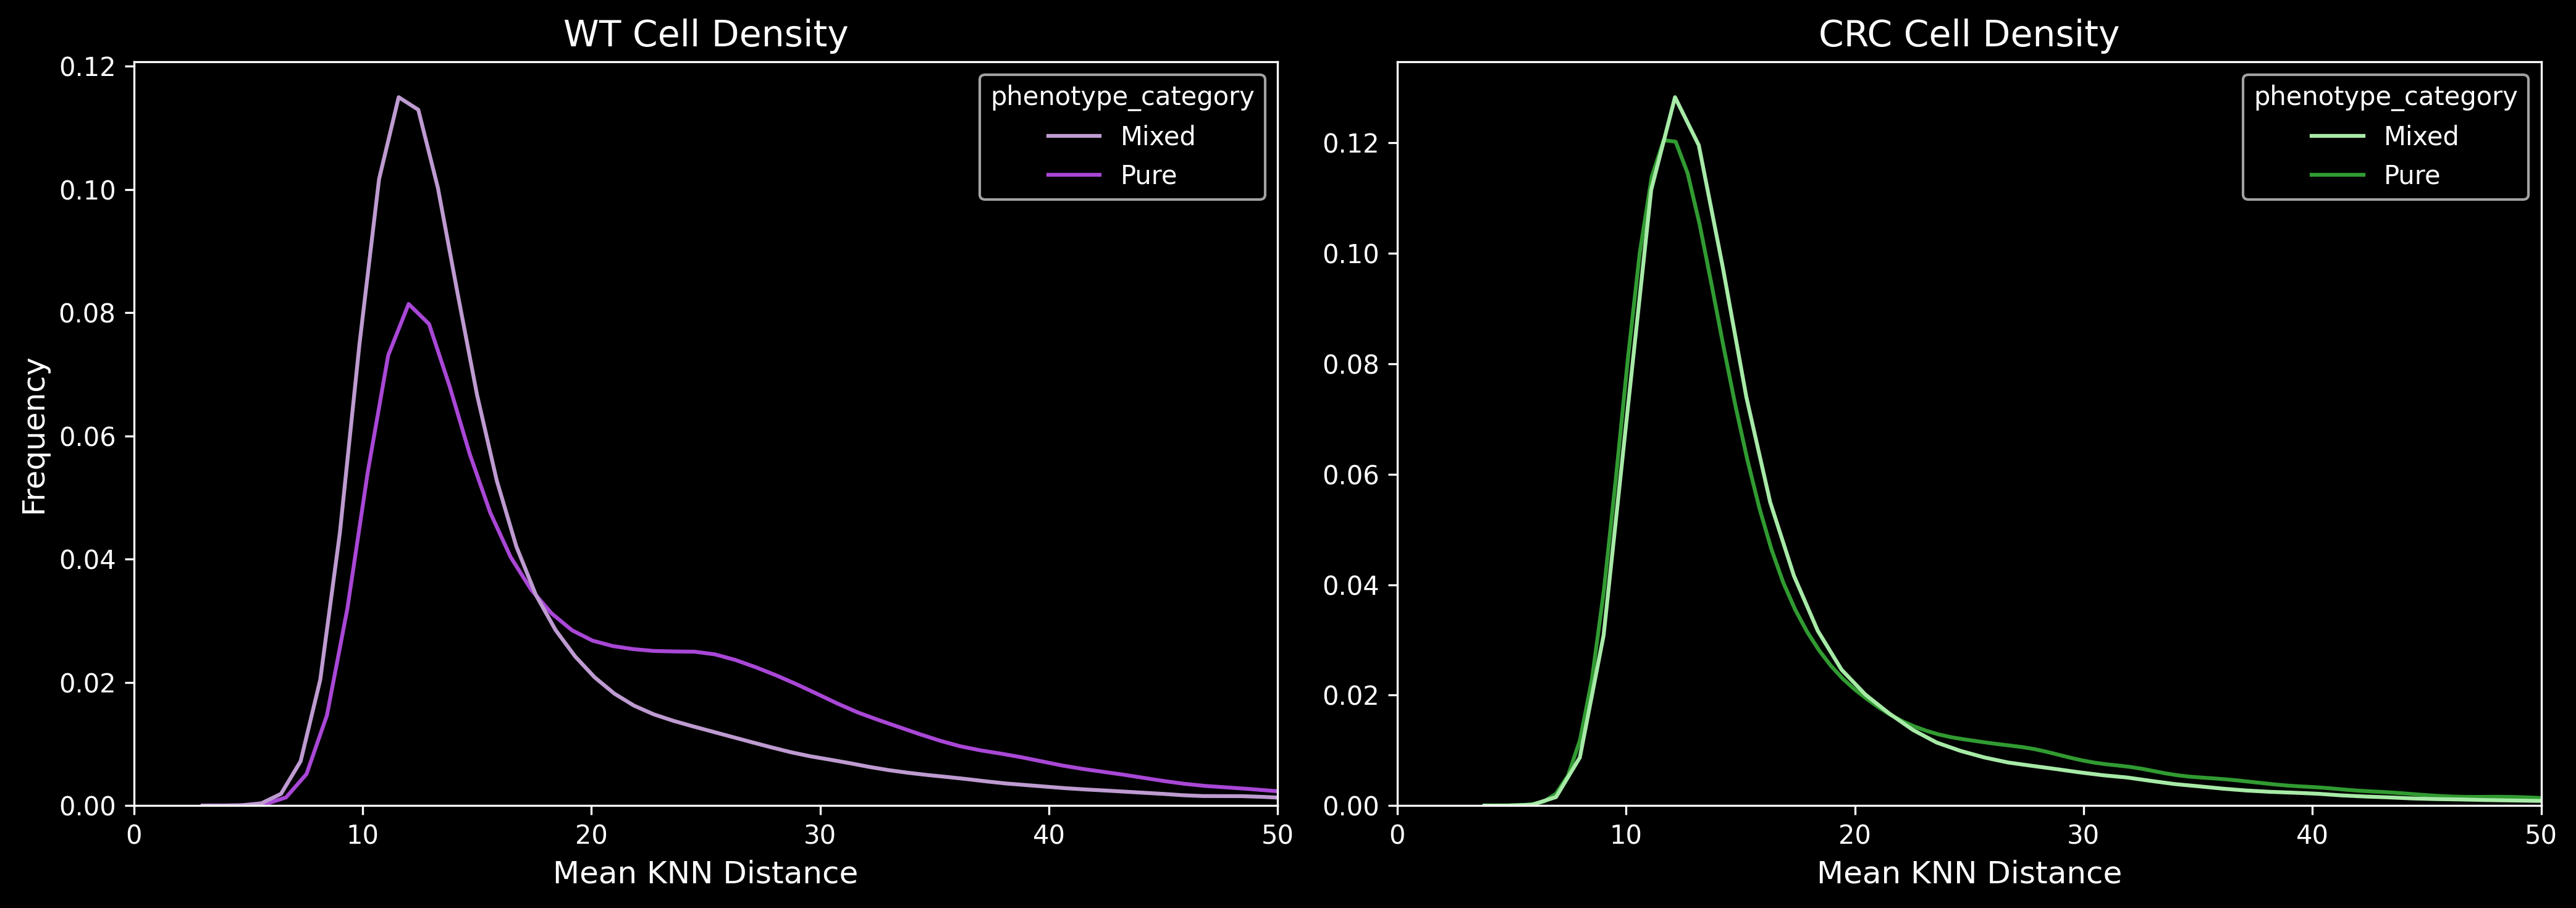

In [109]:
df = data[data["time"] <= 60]
wt_data = df[(df["phenotype"] == "wt")]
crc_data = df[(df["phenotype"] == "crc")]
# Create two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=False, dpi=300)

# Plot 1: relative_wt
sns.kdeplot(
    data=wt_data,
    x="new_5_knn_distances",
    hue="phenotype_category",
    palette={"Pure": "#a947d6", "Mixed": "#be9bd1"},
    ax=axes[0],
    common_norm=False,
    legend=True,
)
axes[0].set_title("WT Cell Density", fontsize=14)
axes[0].set_ylabel("Frequency", fontsize=12)
axes[0].set_xlabel("Mean KNN Distance", fontsize=12)
#axes[0].legend(title="", fontsize=10)
axes[0].set_xlim(0,50)

# Plot 2: relative_crc
sns.kdeplot(
    data=crc_data,
    x="new_5_knn_distances",
    hue="phenotype_category",
    palette={"Pure": "#319b31", "Mixed": "#a7eaa7"},
    ax=axes[1],
    common_norm=False,
    legend=True,
)
axes[1].set_title("CRC Cell Density", fontsize=14)
axes[1].set_ylabel("")
axes[1].set_xlabel("Mean KNN Distance", fontsize=12)
# axes[1].legend(title="", fontsize=10)
axes[1].set_xlim(0, 50)
plt.tight_layout()
plt.show()

65350
16577


C:\Users\6331823\AppData\Local\Temp\ipykernel_32772\26057980.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("organoid").apply(


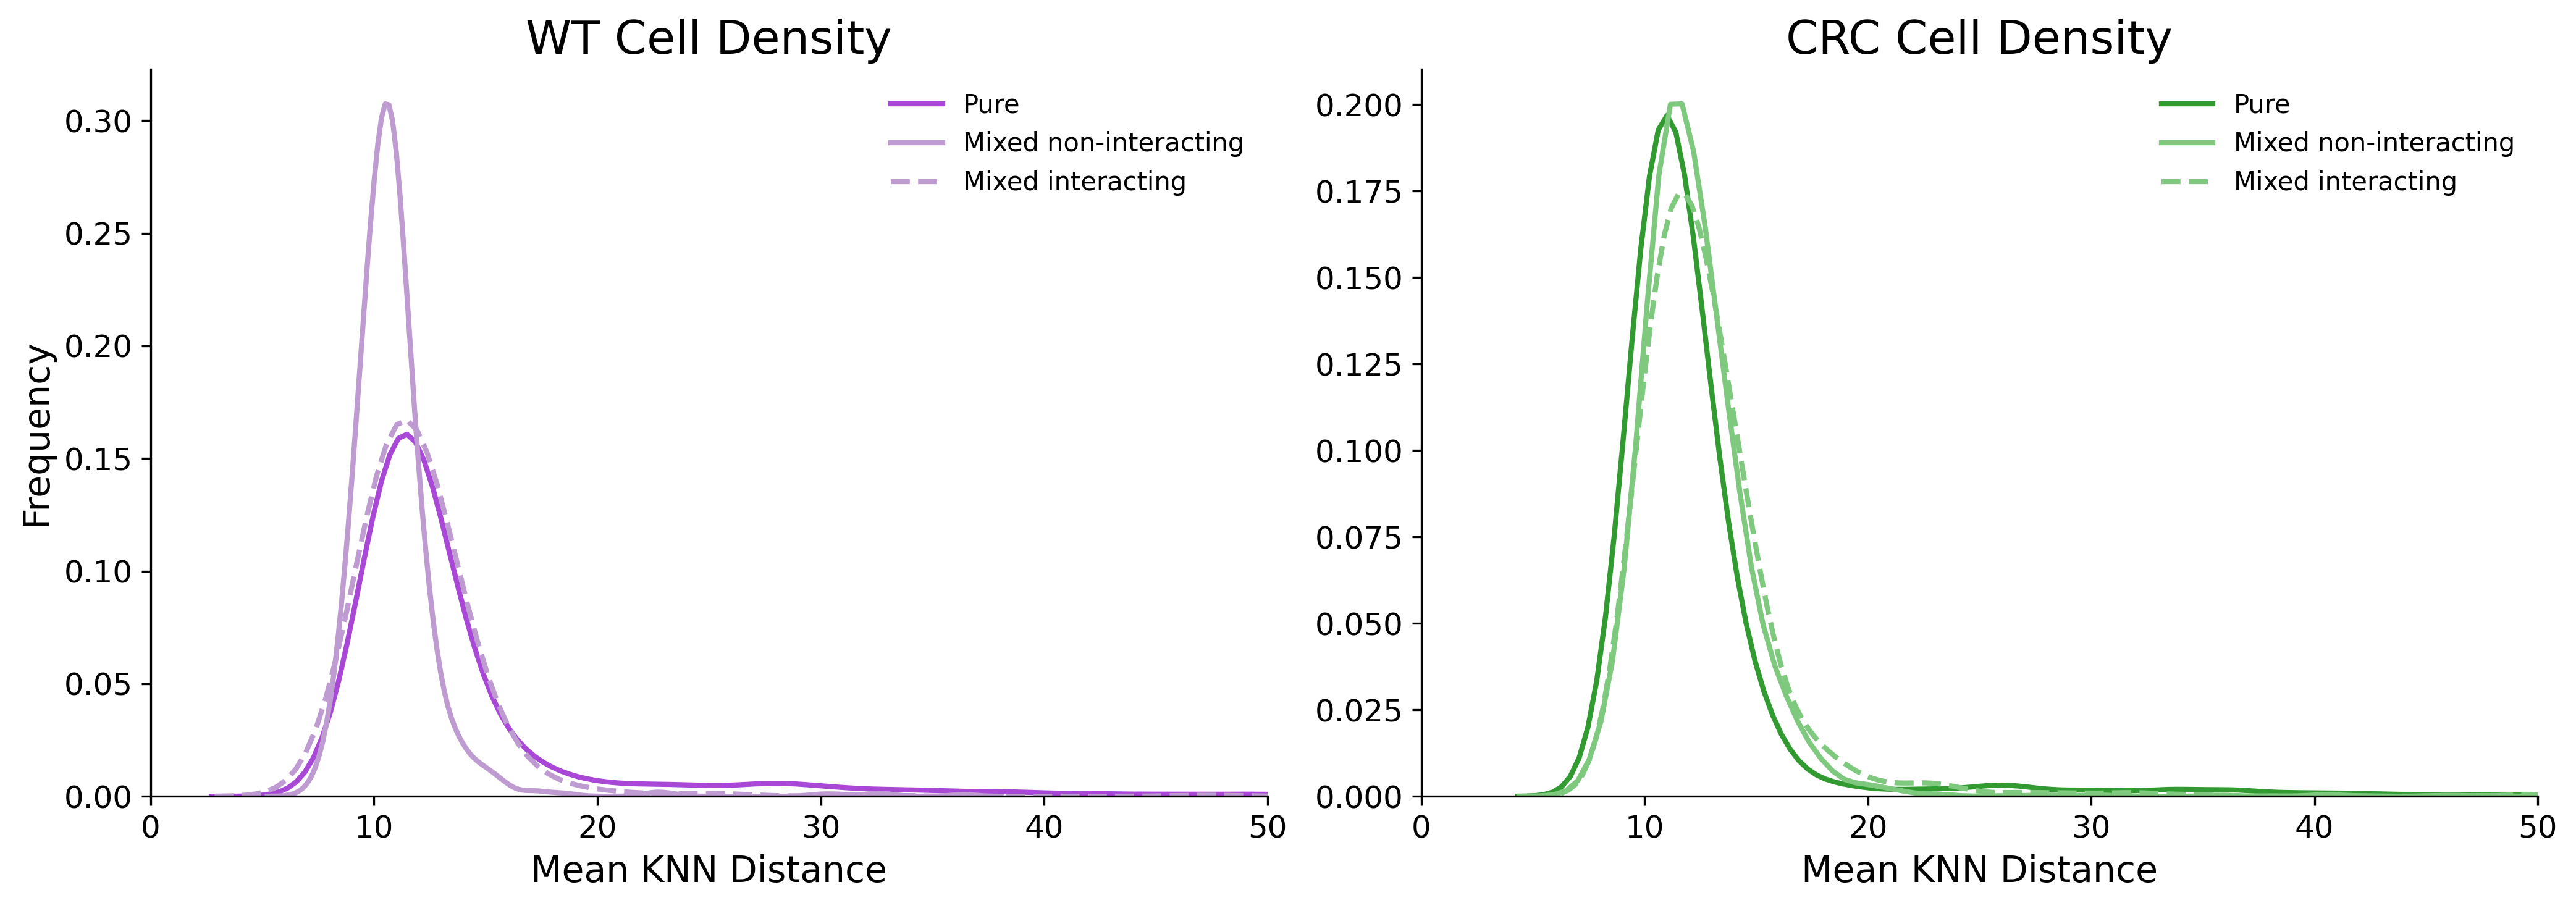

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MaxNLocator

df = data[data["time"] == 60].copy()
print(len(df))
# from every organoid only select the lowest 25% of cells in z
df = df.groupby("organoid").apply(
    lambda x: x[x["new_z"] <= x["new_z"].quantile(0.25)]
).reset_index(drop=True)
print(len(df))
# df = data.copy()
df["interaction_type"] = np.where(
    df["phenotype_category"] == "Pure",
    "Pure",
    np.where(
        df["phenotype_similarity_score"] < 5,
        "Mixed interacting",
        "Mixed non-interacting",
    ),
)

# Create two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=False, dpi=300)

# Define the order for the legend
interaction_order = ["Pure", "Mixed non-interacting", "Mixed interacting"]

# Define line styles for each category
linestyles = {
    "Pure": "-",  # solid
    "Mixed interacting": "--",  # dashed
    "Mixed non-interacting": "-",  # solid
}

# Plot 1: WT cells
for interaction_type in interaction_order:  # Use the defined order
    subset = df[
        (df["phenotype"] == "wt") & (df["interaction_type"] == interaction_type)
    ]
    if len(subset) > 0:
        color = {
            "Pure": "#a947d6",
            "Mixed interacting": "#be9bd1",
            "Mixed non-interacting": "#be9bd1",
        }[interaction_type]
        sns.kdeplot(
            data=subset,
            x="new_5_knn_distances",
            ax=axes[0],
            color=color,
            linestyle=linestyles[interaction_type],
            linewidth=2,
            label=interaction_type,
        )

axes[0].set_title("WT Cell Density", fontsize=14)
axes[0].set_ylabel("Frequency", fontsize=12)
axes[0].set_xlabel("Mean KNN Distance", fontsize=12)

# Manually set legend order
handles, labels = axes[0].get_legend_handles_labels()
# Reorder handles and labels according to interaction_order
label_order = {label: i for i, label in enumerate(interaction_order)}
sorted_handles_labels = sorted(
    zip(handles, labels), key=lambda x: label_order.get(x[1], len(interaction_order))
)
handles, labels = zip(*sorted_handles_labels)
axes[0].legend(handles, labels, fontsize=10)
axes[0].set_xlim(0, 50)

# Plot 2: CRC cells
for interaction_type in interaction_order:  # Use the defined order
    subset = df[
        (df["phenotype"] == "crc") & (df["interaction_type"] == interaction_type)
    ]
    if len(subset) > 0:
        color = {
            "Pure": "#319b31",
            "Mixed interacting": "#7fc97f",
            "Mixed non-interacting": "#7fc97f",
        }[interaction_type]
        sns.kdeplot(
            data=subset,
            x="new_5_knn_distances",
            ax=axes[1],
            color=color,
            linestyle=linestyles[interaction_type],
            linewidth=2,
            label=interaction_type,
        )

axes[1].set_title("CRC Cell Density", fontsize=14)
axes[1].set_ylabel("")
axes[1].set_xlabel("Mean KNN Distance", fontsize=12)

# Manually set legend order for second plot
handles, labels = axes[1].get_legend_handles_labels()
sorted_handles_labels = sorted(
    zip(handles, labels), key=lambda x: label_order.get(x[1], len(interaction_order))
)
handles, labels = zip(*sorted_handles_labels)
axes[1].legend(handles, labels, fontsize=10)
axes[1].set_xlim(0, 50)
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    #remove legend box
    ax.legend_.get_frame().set_linewidth(0.0)
    ax.title.set_fontsize(18)
    ax.xaxis.label.set_fontsize(14)
    ax.yaxis.label.set_fontsize(14)
    ax.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.show()

In [8]:
from scipy import stats

# df = data.copy()
df = data[data["time"] == 60].copy()
df = (
    df.groupby("organoid")
    .apply(lambda x: x[x["new_z"] <= x["new_z"].quantile(0.25)])
    .reset_index(drop=True)
)
df = df[df["phenotype_category"] == "Mixed"]
df["interacting"] = df["phenotype_similarity_score"] < 5
to_visualize = "new_5_knn_distances"

phenotypes = ["wt", "crc"]
for phenotype in phenotypes:
    interacting = df[(df["interacting"] == True) & (df["phenotype"] == phenotype)]
    mean_interacting = interacting[to_visualize].mean()
    non_interacting = df[(df["interacting"] == False) & (df["phenotype"] == phenotype)]
    mean_non_interacting = non_interacting[to_visualize].mean()
    print(f"Mean KNN distance for interacting {phenotype} cells: {mean_interacting:.2f}, N={len(interacting)}")
    print(f"Mean KNN distance for non-interacting {phenotype} cells: {mean_non_interacting:.2f}, N={len(non_interacting)}")
    # calculate p score
    interacting_data = interacting[to_visualize].dropna()
    non_interacting_data = non_interacting[to_visualize].dropna()

    # Perform Mann-Whitney U test (non-parametric alternative to t-test)
    statistic, p_value = stats.mannwhitneyu(interacting_data, non_interacting_data, alternative="two-sided")
    print(f"Mann-Whitney U test p-value for {to_visualize} between interacting and non-interacting {phenotype} cells: {p_value}")

Mean KNN distance for interacting wt cells: 12.28, N=558
Mean KNN distance for non-interacting wt cells: 10.88, N=981
Mann-Whitney U test p-value for new_5_knn_distances between interacting and non-interacting wt cells: 1.0650124214727883e-27
Mean KNN distance for interacting crc cells: 12.83, N=883
Mean KNN distance for non-interacting crc cells: 12.35, N=5828
Mann-Whitney U test p-value for new_5_knn_distances between interacting and non-interacting crc cells: 0.000731468290097425


C:\Users\6331823\AppData\Local\Temp\ipykernel_35364\3746626972.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x[x["new_z"] <= x["new_z"].quantile(0.25)])


C:\Users\6331823\AppData\Local\Temp\ipykernel_32772\4247716078.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x[x["new_z"] <= x["new_z"].quantile(0.25)])


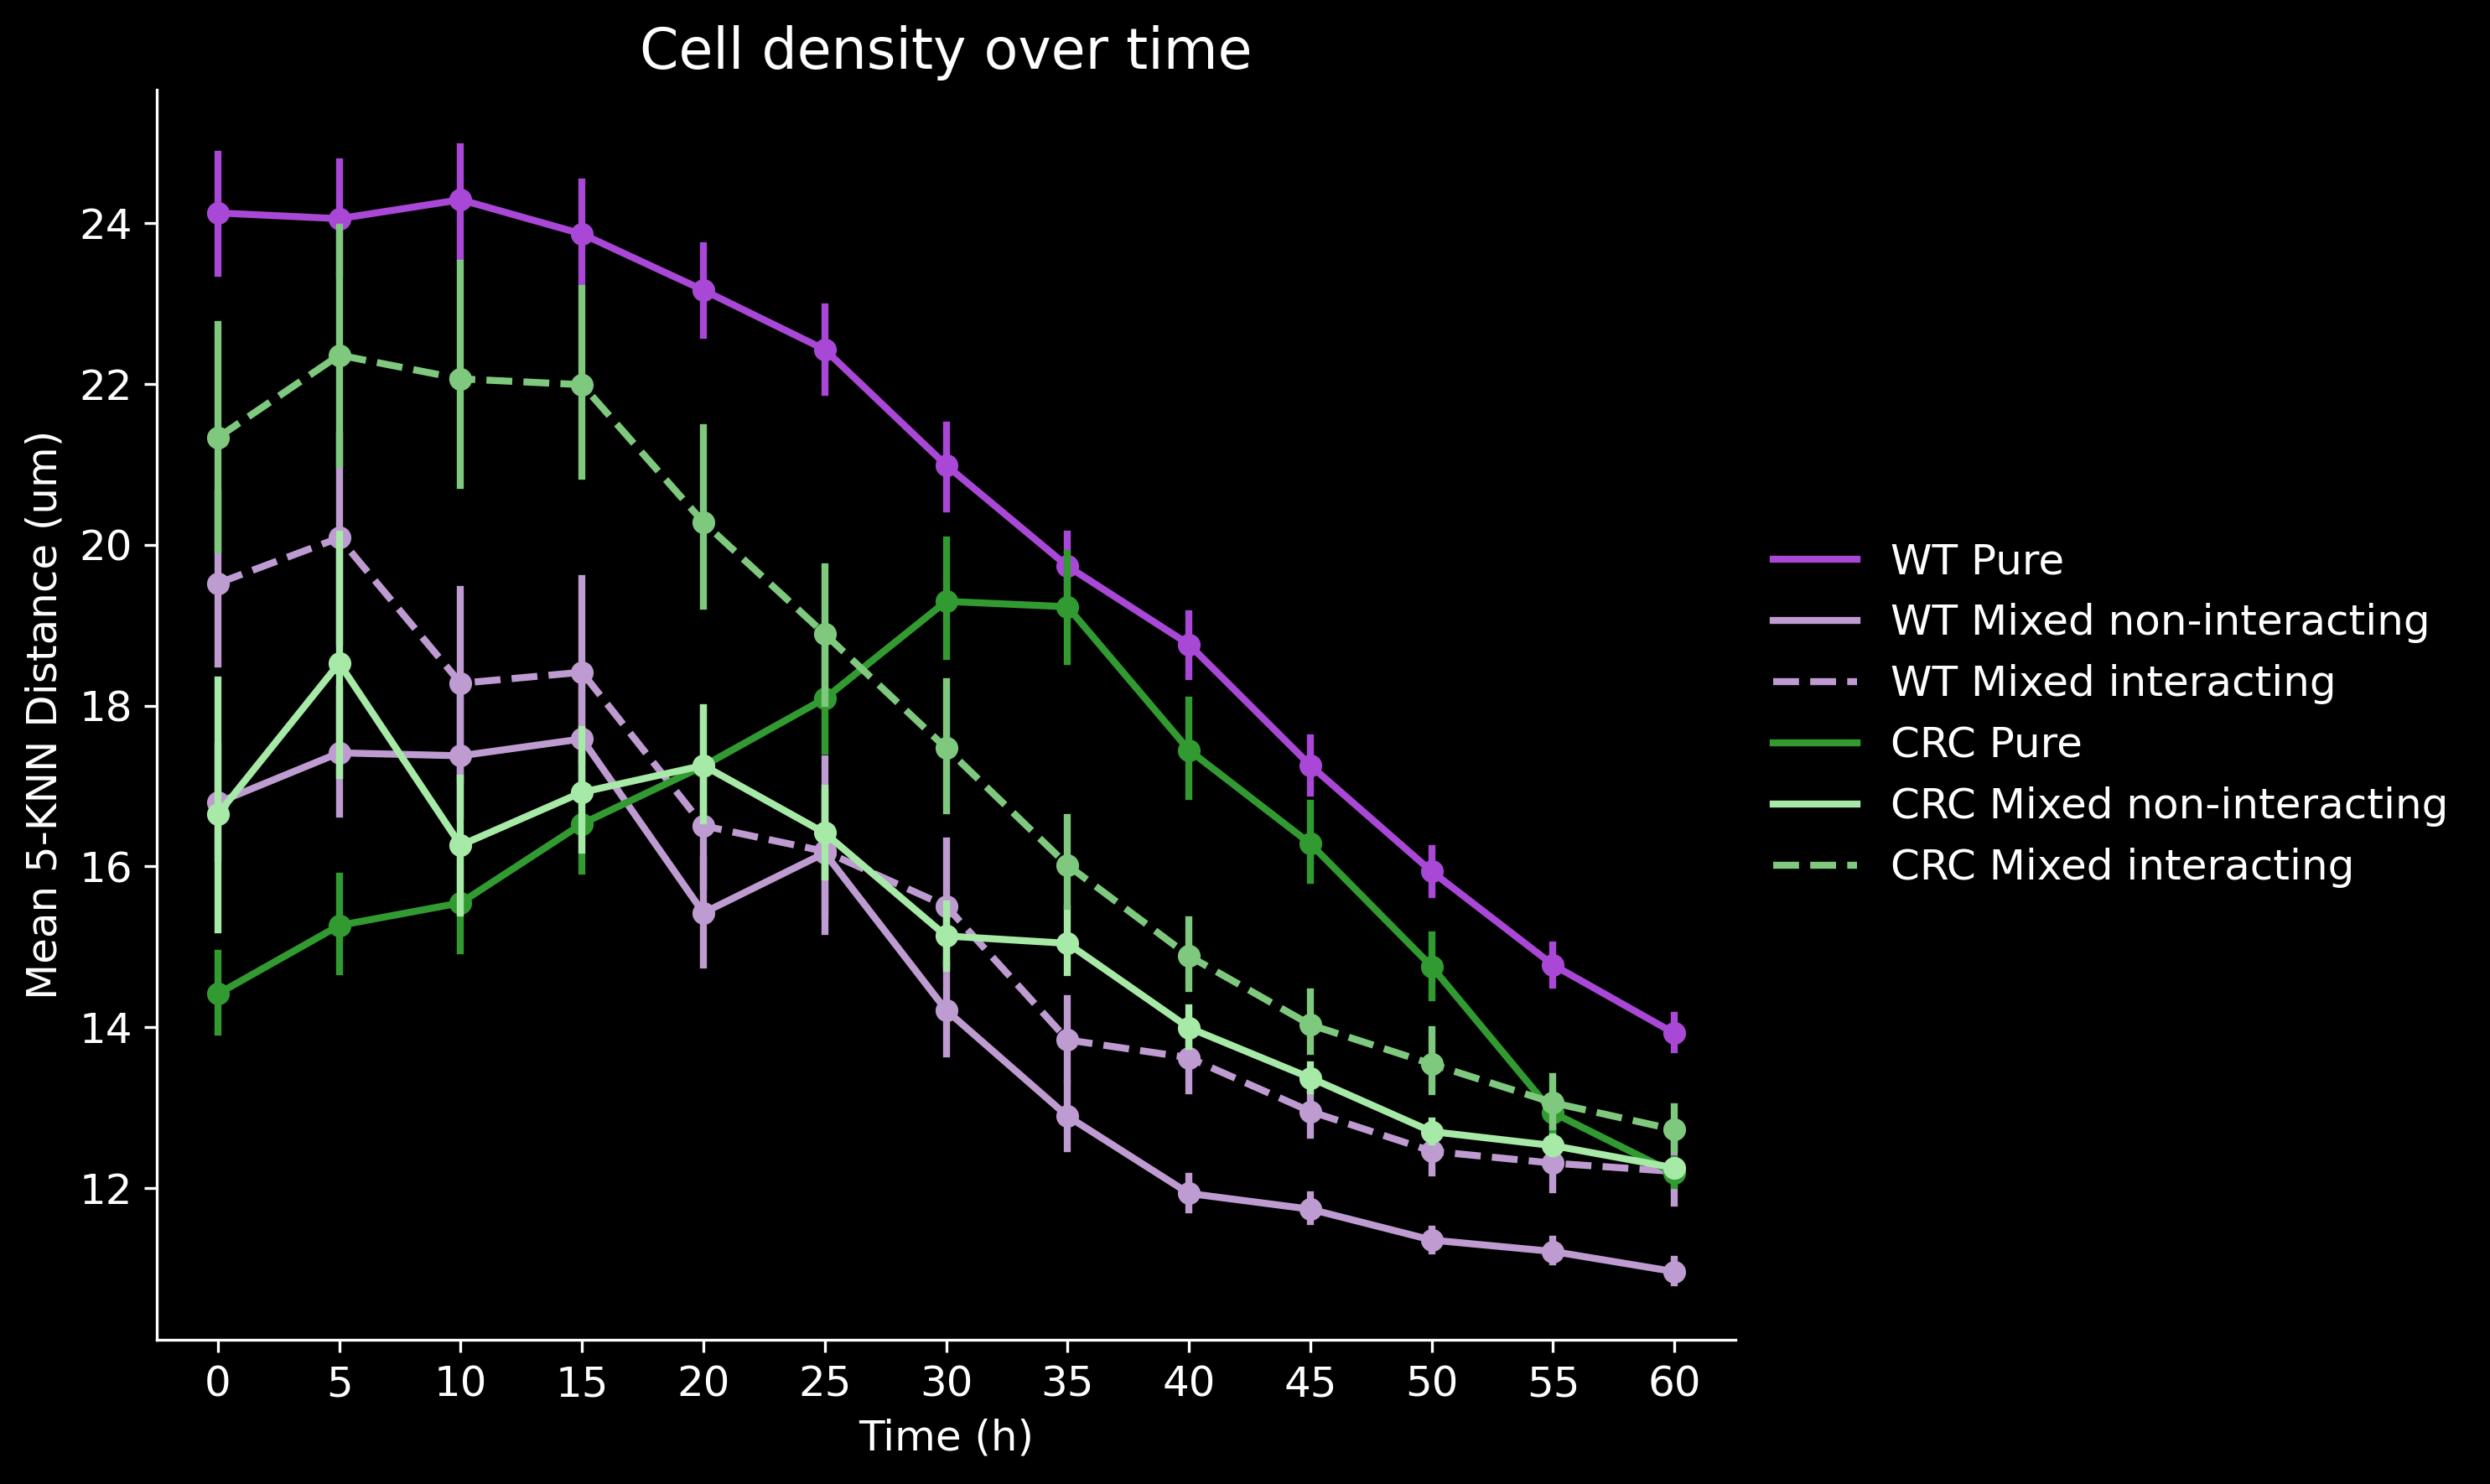

In [5]:
df = data[data["time"] <= 60].copy()  # Explicit copy
df = (
    df.groupby("organoid")
    .apply(lambda x: x[x["new_z"] <= x["new_z"].quantile(0.25)])
    .reset_index(drop=True)
)
df["interaction_type"] = np.where(
    df["phenotype_category"] == "Pure",
    "Pure",
    np.where(
        df["phenotype_similarity_score"] < 5,
        "Mixed interacting",
        "Mixed non-interacting",
    ),
)

linestyles = {
    "Pure": "-",  # solid
    "Mixed interacting": "--",  # dashed
    "Mixed non-interacting": "-",  # solid
}

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
plt.style.use("dark_background")

# Store handles and labels explicitly
plot_info = []

for interaction_type in df["interaction_type"].unique():
    subset = df[df["interaction_type"] == interaction_type]
    subset = subset[subset["phenotype"] == "wt"]
    color = {
        "Pure": "#a947d6",
        "Mixed interacting": "#be9bd1",
        "Mixed non-interacting": "#be9bd1",
    }[interaction_type]

    line = ax.plot(
        [], [], color=color, linestyle=linestyles[interaction_type], linewidth=2
    )[0]
    plot_info.append((line, interaction_type, "wt"))

    sns.pointplot(
        data=subset,
        x="time",
        y="new_5_knn_distances",
        color=color,
        linestyle=linestyles[interaction_type],
        linewidth=2,
        label=interaction_type,
        ax=ax,
    )

for interaction_type in df["interaction_type"].unique():
    subset = df[df["interaction_type"] == interaction_type]
    subset = subset[subset["phenotype"] == "crc"]
    color = {
        "Pure": "#319b31",
        "Mixed interacting": "#7fc97f",
        "Mixed non-interacting": "#a7eaa7",
    }[interaction_type]

    line = ax.plot(
        [], [], color=color, linestyle=linestyles[interaction_type], linewidth=2
    )[0]
    plot_info.append((line, interaction_type, "crc"))

    sns.pointplot(
        data=subset,
        x="time",
        y="new_5_knn_distances",
        color=color,
        linestyle=linestyles[interaction_type],
        linewidth=2,
        label=interaction_type,
        ax=ax,
    )

# Now create custom legend in desired order
legend_order = [
    ("Pure", "wt", "WT Pure"),
    ("Mixed non-interacting", "wt", "WT Mixed non-interacting"),
    ("Mixed interacting", "wt", "WT Mixed interacting"),
    ("Pure", "crc", "CRC Pure"),
    ("Mixed non-interacting", "crc", "CRC Mixed non-interacting"),
    ("Mixed interacting", "crc", "CRC Mixed interacting"),
]

ordered_handles = []
ordered_labels = []

for interaction, pheno, label in legend_order:
    for handle, int_type, phen in plot_info:
        if int_type == interaction and phen == pheno:
            ordered_handles.append(handle)
            ordered_labels.append(label)
            break

ax.legend(
    ordered_handles,
    ordered_labels,
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=12,
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend_.get_frame().set_linewidth(0.0)
ax.set_title("Cell density over time", fontsize=16)
ax.set_ylabel("Mean 5-KNN Distance (um)", fontsize=12)
ax.set_xlabel("Time (h)", fontsize=12)
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from skimage.measure import regionprops_table
import tifffile
import numpy as np


def properties_channel(mask, image, type=None):

    # Get the properties of the mask for the channel you specified (image)
    props_channel = regionprops_table(
        mask, intensity_image=image, properties=["label", "mean_intensity"]
    )

    # Make this into a pandas dataframe and rename some variables to the name of the channel for later merging
    props_channel = pd.DataFrame(props_channel).rename(
        columns={
            "label": "label",
            "mean_intensity": f"raw_{type}",
        }
    )

    return props_channel


image = tifffile.imread(
    os.path.join(os.path.dirname(input_directory), "cropped", "Frame-0.tif")
)
print(image.shape)
dapi = image[:, 2]
dapi_masks = tifffile.imread(
    os.path.join(os.path.dirname(input_directory), "segmented", "Frame-0_masks.tif")
)
props = properties_channel(dapi_masks, dapi, type="dapi")

In [87]:
input_directory = r"Z:\users\6331823\test\251103_Exp_ML_034_ZVAD_treated_uTs_cJUN_stained_2025_11_03__16_44_13(1)-Stitching-01\properties"

data = pd.read_csv(os.path.join(input_directory, "Frame-0_props.csv"))
data = data.merge(props, on="label", how="left")
data = data[data["volume"] < 2000]
data["log_ratio_cjun_dapi"] = np.log10((data["raw_cjun"] + 1) / (data["raw_dapi"] + 1))

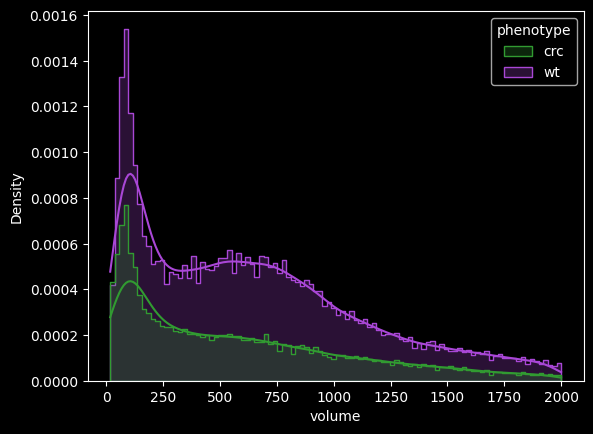

In [90]:
sns.histplot(
    data=data,
    x="volume",
    hue="phenotype",
    element="step",
    stat="density",
    bins=100,
    palette={"wt": "#a947d6", "crc": "#319b31"},
    kde=True,
    legend=True,
)
plt.show()

Mann-Whitney U test statistic: 21374056.0, p-value: 6.060871211483442e-211


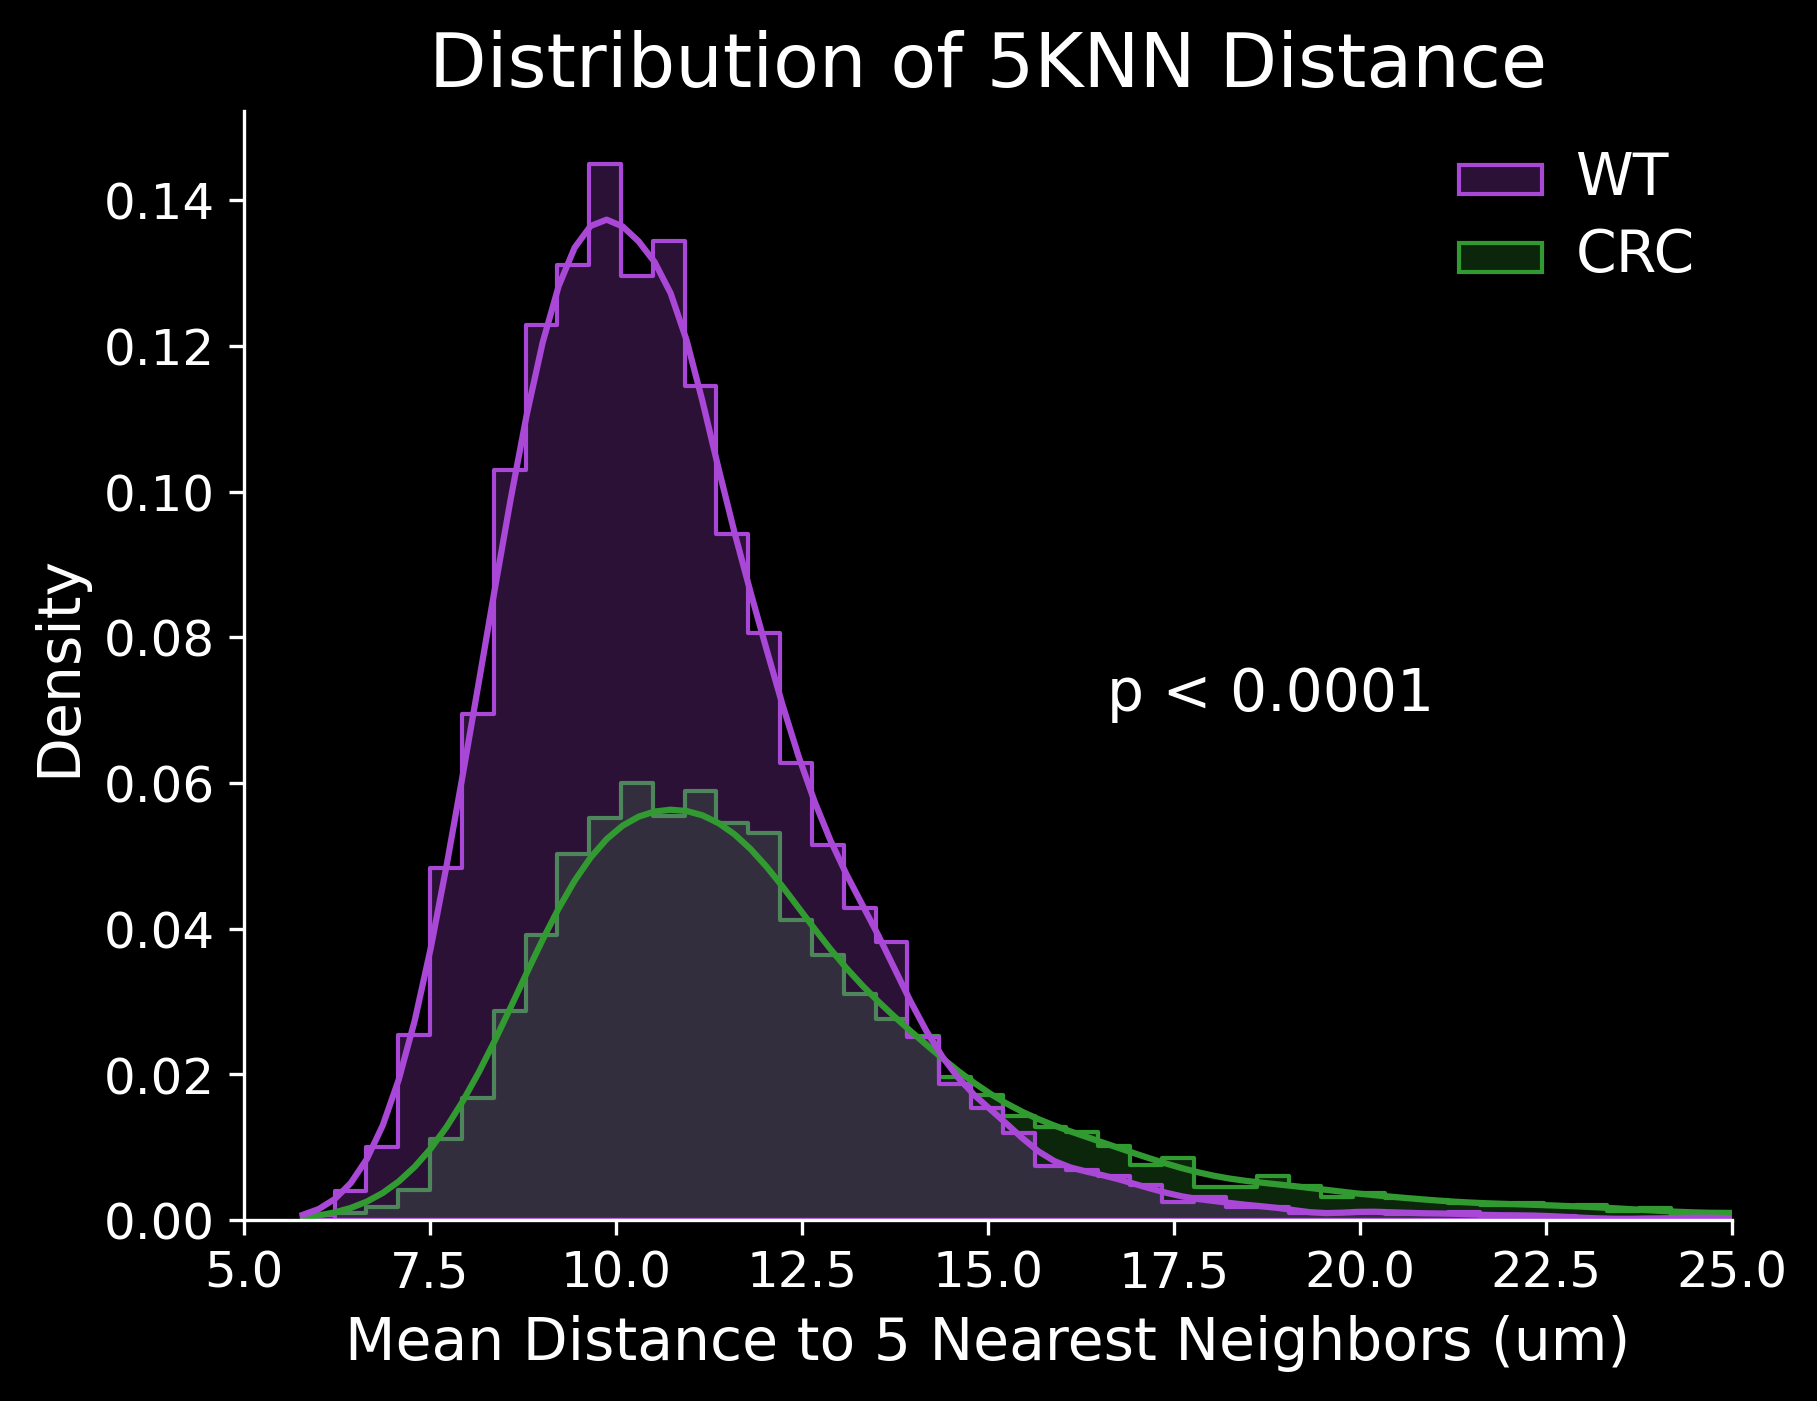

In [124]:
from scipy import stats

subset = data[data["volume"] < 280]
# subset = data
to_visualize = "mean_knn_distance"

# Split data by phenotype
wt_data = subset[subset["phenotype"] == "wt"][to_visualize].dropna()
crc_data = subset[subset["phenotype"] == "crc"][to_visualize].dropna()

# Perform Mann-Whitney U test (non-parametric alternative to t-test)
statistic, p_value = stats.mannwhitneyu(wt_data, crc_data, alternative="two-sided")

# Create histogram with p-value annotation
# make fig 300dpi
plt.style.use("dark_background")
plt.figure(dpi=300)
sns.histplot(
    data=subset,
    x=to_visualize,
    hue="phenotype",
    element="step",
    stat="density",
    bins=100,
    palette={"wt": "#a947d6", "crc": "#319b31"},
    kde=True,
    legend=True,
)
ax = plt.gca()
print(f"Mann-Whitney U test statistic: {statistic}, p-value: {p_value}")
plt.title(f"Distribution of 5KNN Distance")
# add p-value to the plot
if p_value < 0.0001:
    p_text = "p < 0.0001"
elif p_value < 0.001:
    p_text = "p < 0.001"
elif p_value < 0.01:
    p_text = "p < 0.01"
elif p_value < 0.05:
    p_text = "p < 0.05"

ax.text(0.8, 0.5, p_text, transform=ax.transAxes, ha="right", va="top", fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# remove legend box
ax.legend_.get_frame().set_linewidth(0.0)
ax.legend_.set_title("")
# make the legend text in all caps
for text in ax.legend_.get_texts():
    text.set_text(text.get_text().upper())
ax.title.set_fontsize(18)
ax.xaxis.label.set_fontsize(14)
ax.yaxis.label.set_fontsize(14)
ax.tick_params(axis='both', which='major', labelsize=12)
# make legend text bigger
for text in ax.legend_.get_texts():
    text.set_fontsize(14)
ax.set_xlim(5,25)
ax.set_xlabel("Mean Distance to 5 Nearest Neighbors (um)")
plt.show()

In [4]:
import os
import tifffile
import napari

scale = (0.995, 0.321, 0.321)
# Better stitch3d code
input_directory = (
    r"C:\Users\6331823\Local SSD\Data_Merel\Quality_test\Plate12_20x_1x1bin_1um_F0"
)
image = tifffile.imread(os.path.join(input_directory, "cropped", "Frame-0.tif"))
dapi = image[:, 0]
mtmg = image[:, 3]
masks = tifffile.imread(os.path.join(input_directory, "dapi_basic_mask.tif"))
stitched = tifffile.imread(os.path.join(input_directory, "dapi_stitched.tif"))

viewer = napari.Viewer(ndisplay=3)
viewer.add_image(
    dapi,
    name="DAPI",
    scale=scale,
    blending="additive",
    visible=True,
    colormap="blue",
)
viewer.add_labels(
    stitched,
    name="DAPI Stitched",
    scale=scale,
    blending="additive",
    visible=True,
)
viewer.add_labels(
    masks,
    name="Basic Masks",
    scale=scale,
    blending="additive",
    visible=True,
)

<Labels layer 'Basic Masks' at 0x248eed75850>

c:\Users\6331823\AppData\Local\Programs\Python\Python311\Lib\site-packages\napari\layers\labels\labels.py:892: UserWarning: Contours are not displayed during 3D rendering
  warnings.warn(


In [3]:
import matplotlib.pyplot as plt

cropped = dapi[:, 100:300, 100:200]
cropped_mtmg = mtmg[:, 100:300, 100:200]
cropped_masks = masks[:, 100:300, 100:200]
croppped_stitched = stitched[:, 100:300, 100:200]

def stitch(masks, max_search_range=6):
    all_centroids = []
    for z in range(masks.shape[0]):
        slice_mask = masks[z]
        props = regionprops(slice_mask)

        for prop in props:
            all_centroids.append(
                {
                    "z": z,  # frame
                    "y": prop.centroid[0],
                    "x": prop.centroid[1],
                    "label_2d": prop.label,  # original 2D label
                    "area": prop.area,
                    "bounding_box": prop.bbox,
                }
            )

    df = pd.DataFrame(all_centroids)

    tp.linking.Linker.MAX_SUB_NET_SIZE = 100

    tracked = tp.link(
        df,
        search_range=max_search_range,  # max movement in XY
        memory=0,  # allow gaps in tracking
        pos_columns=["y", "x"],  # columns for position
        t_column="z",  # use Z as time
    )

    # In the tracked df, add 1 to particle to avoid 0 labels
    tracked["particle"] = tracked["particle"].astype(int) + 1

    masks_3d = np.zeros_like(masks, dtype=np.uint32)

    for _, row in tracked.iterrows():
        z = int(row["z"])
        particle_id = int(row["particle"])  # trackpy assigns unique IDs
        original_label = int(row["label_2d"])

        # Copy the original mask pixels and relabel with particle_id
        masks_3d[z][masks[z] == original_label] = particle_id
    return masks_3d, tracked

new_stitched, df = stitch(cropped_masks)

viewer = napari.Viewer(ndisplay=3)
viewer.add_image(
    cropped,
    name="DAPI Cropped",
    scale=scale,
    blending="additive",
    contrast_limits=[100, 900],
    visible=True,
    colormap="blue",
)
viewer.add_image(
    cropped_mtmg,
    name="mtmg Cropped",
    scale=scale,
    blending="additive",
    contrast_limits=[100, 900],
    visible=True,
    colormap="magenta",
)
viewer.add_labels(
    cropped_masks,
    name="Cropped Masks",
    scale=scale,
    blending="additive",
    visible=True,
)
viewer.add_labels(
    croppped_stitched,
    name="Cropped Stitched",
    scale=scale,
    blending="additive",
    visible=True,
)
viewer.add_labels(
    new_stitched,
    name="New Stitched",
    scale=scale,
    blending="additive",
    visible=True,
)

Frame 75: 3 trajectories present.


<Labels layer 'New Stitched' at 0x249418db9d0>

c:\Users\6331823\AppData\Local\Programs\Python\Python311\Lib\site-packages\napari\layers\labels\labels.py:892: UserWarning: Contours are not displayed during 3D rendering
  warnings.warn(
c:\Users\6331823\AppData\Local\Programs\Python\Python311\Lib\site-packages\napari\layers\labels\labels.py:892: UserWarning: Contours are not displayed during 3D rendering
  warnings.warn(
c:\Users\6331823\AppData\Local\Programs\Python\Python311\Lib\site-packages\napari\layers\labels\labels.py:892: UserWarning: Contours are not displayed during 3D rendering
  warnings.warn(
c:\Users\6331823\AppData\Local\Programs\Python\Python311\Lib\site-packages\napari\layers\labels\labels.py:892: UserWarning: Contours are not displayed during 3D rendering
  warnings.warn(


In [4]:
import numpy as np
import pandas as pd

from skimage.measure import regionprops
import trackpy as tp

# Function to calculate the k-nearest neighbors for all cells in an organoid.


import sklearn.neighbors


def compute_knn_features(
    data, k=5, position_columns=["x", "y", "z"], get_phenotype_score=True
):
    # Get an array of the coordinates of every cell
    coordinates = data[position_columns].to_numpy()

    # Fit the k-nearest neighbors model and compute the k-nearest neighbors for each cell
    neighbours = sklearn.neighbors.NearestNeighbors(
        n_neighbors=k + 1, algorithm="kd_tree"
    ).fit(coordinates)
    distances, indices = neighbours.kneighbors(coordinates)
    knn_distances = distances[:, 1:]  # Exclude the first column (distance to itself)
    knn_indices = indices[:, 1:]  # Exclude the first column (index of itself)

    # Calculate the mean distance of every cell to its 5 nearest neighbours, which can measure density
    mean_knn_distance = [distance.mean() for distance in knn_distances]

    # Add the mean distance and the indices of the k-nearest neighbors to the dataframe
    data["mean_knn_distance"] = mean_knn_distance
    data[f"{k}_knn_neighbors"] = list(knn_indices)

    # This cell id is the same as the label-1, this is what you can compare the knn_neighbours column with
    data["cell_id"] = range(len(data))

    if not get_phenotype_score:
        return data

    # Here we calculate a phenotype similarity score
    # This means that each cell gets a score of 0 to 5 based on how many of its nearest neigbours have the same phenotype
    # A score of 5 means that all 5 nearest neighbours have the same phenotype,
    phenotype_scores = []
    for i, nn_indices_row in enumerate(data[f"{k}_knn_neighbors"]):
        score = calculate_phenotype_similarity_score(
            i, nn_indices_row, data["phenotype"]
        )
        phenotype_scores.append(score)

    # Add score to dataframe
    data["phenotype_similarity_score"] = phenotype_scores

    return data


def calculate_phenotype_similarity_score(row_idx, nn_indices_row, phenotype_series):
    # Get the phenotype of the current cell
    current_phenotype = phenotype_series.iloc[row_idx]

    # Get phenotypes of the nearest neighbors
    neighbor_phenotypes = phenotype_series.iloc[nn_indices_row]

    # Count how many neighbors have the same phenotype
    same_phenotype_count = (neighbor_phenotypes == current_phenotype).sum()

    return same_phenotype_count


def stitch_organoid(masks, max_search_range=6, max_height=5):

    # Step 1: Extract centroids from each Z-slice
    all_centroids = []
    for z in range(masks.shape[0]):
        slice_mask = masks[z]
        props = regionprops(slice_mask)

        for prop in props:
            all_centroids.append(
                {
                    "z": z,  # frame
                    "y": prop.centroid[0],
                    "x": prop.centroid[1],
                    "label_2d": prop.label,  # original 2D label
                    "area": prop.area,
                    "bounding_box": prop.bbox,
                }
            )

    df = pd.DataFrame(all_centroids)

    tp.linking.Linker.MAX_SUB_NET_SIZE = 100

    tracked = tp.link(
        df,
        search_range=max_search_range,  # max movement in XY
        memory=0,  # allow gaps in tracking
        pos_columns=["y", "x"],  # columns for position
        t_column="z",  # use Z as time
    )

    # In the tracked df, add 1 to particle to avoid 0 labels
    tracked["particle"] = tracked["particle"].astype(int) + 1

    tracked = break_tracks(tracked, max_length=max_height, area_column="area")

    masks_3d = np.zeros_like(masks, dtype=np.uint32)

    for _, row in tracked.iterrows():
        z = int(row["z"])
        particle_id = int(row["particle"])  # trackpy assigns unique IDs
        original_label = int(row["label_2d"])

        # Copy the original mask pixels and relabel with particle_id
        masks_3d[z][masks[z] == original_label] = particle_id

    # Make a pandas data frame from the data
    stats_df = get_mask_stats(masks_3d)
    stats_df = stats_df[(stats_df["height_pixel"] != 1)]
    stats_df = compute_knn_features(
        stats_df,
        k=1,
        position_columns=["x_center", "y_center", "z_center"],
        get_phenotype_score=False,
    )
    stats_df["aspect_ratio_score"] = (
        stats_df["aspect_ratio"] - stats_df["aspect_ratio"].min()
    ) / (stats_df["aspect_ratio"].max() - stats_df["aspect_ratio"].min())
    stats_df["density_normalized"] = 1 - (
        stats_df["mean_knn_distance"] - stats_df["mean_knn_distance"].min()
    ) / (stats_df["mean_knn_distance"].max() - stats_df["mean_knn_distance"].min())
    stats_df["background_score"] = (1 - stats_df["aspect_ratio_score"]) * (
        1 - stats_df["density_normalized"]
    )

    # Optionally normalize to 0-1 range
    stats_df["background_score_normalized"] = (
        stats_df["background_score"] - stats_df["background_score"].min()
    ) / (stats_df["background_score"].max() - stats_df["background_score"].min())
    filtered = stats_df  # [stats_df["aspect_ratio"] < 1.8]
    tracked_filtered = tracked[tracked["particle"].isin(filtered["particle"])]

    masks_3d_filtered = np.zeros_like(masks, dtype=np.uint32)

    for _, row in tracked_filtered.iterrows():
        z = int(row["z"])
        particle_id = int(row["particle"])
        original_label = int(row["label_2d"])

        # Copy the original mask pixels and relabel with new particle_id
        masks_3d_filtered[z][masks[z] == original_label] = particle_id

    return masks_3d, masks_3d_filtered, stats_df


def get_mask_stats(mask):
    particle_stats = []
    props = regionprops(mask)

    # For every mask found, get the label, centeroid, boundingbox, and volume
    for prop in props:
        label = prop.label
        centroid = prop.centroid  # (z, y, x)
        bounding_box = prop.bbox  # (min_z, min_y, min_x, max_z, max_y, max_x)
        volume = prop.area

        width_x = bounding_box[5] - bounding_box[2]
        width_y = bounding_box[4] - bounding_box[1]
        height_pixel = bounding_box[3] - bounding_box[0]
        height = (bounding_box[3] - bounding_box[0]) * 8.125
        aspect_ratio = height / np.mean([width_x, width_y])

        particle_stats.append(
            {
                "particle": label,
                "z_center": centroid[0],
                "y_center": centroid[1],
                "x_center": centroid[2],
                "bounding_box": bounding_box,
                "width_x": width_x,
                "width_y": width_y,
                "height_pixel": height_pixel,
                "height": height,
                "aspect_ratio": aspect_ratio,
                "volume": volume,
            }
        )
    stats_df = pd.DataFrame(particle_stats)
    return stats_df


def break_tracks(tracked, max_length=10, area_column="area"):
    new_tracked = tracked.copy()
    next_particle_id = tracked["particle"].max() + 1

    while True:
        long_tracks = new_tracked.groupby("particle").size()
        long_tracks = long_tracks[long_tracks > max_length]

        if len(long_tracks) == 0:
            break  # No more long tracks

        for particle_id in long_tracks.index:
            particle_data = new_tracked[
                new_tracked["particle"] == particle_id
            ].sort_values("z")

            # Find weakest link
            areas = particle_data[area_column].values
            deltas = []
            for i in range(len(areas[:-1])):
                area1 = areas[i]
                area2 = areas[i + 1]
                delta = abs(area2 - area1)
                pct = delta / max(area1, area2)
                deltas.append(pct)

            weakest_idx = np.argmax(deltas)
            break_z = particle_data.iloc[weakest_idx + 1]["z"]

            # Split track
            mask = (new_tracked["particle"] == particle_id) & (
                new_tracked["z"] >= break_z
            )
            new_tracked.loc[mask, "particle"] = next_particle_id
            next_particle_id += 1

            # print(f"Split particle {particle_id} between z={break_z-1} and z={break_z}")

    return new_tracked

In [7]:
import tifffile
import napari

mask = tifffile.imread(r"C:\Users\6331823\Local SSD\Data_Anna\Exp140\CRC_Expansion_5\segmented\Frame-12_masks.tif")

# stitched, stitched_filtered, stats_df = stitch_organoid(mask, max_search_range=6, max_height=5)
import sys
import os
sys.path.insert(0, os.path.dirname(os.getcwd()))
from OSCAR_stitching import stitch_3D

stitched_filtered = stitch_3D(mask, min_z=3, med_z=5, max_z=8)
scale = (5, 0.64, 0.64)
napari_viewer = napari.Viewer(ndisplay=3)
napari_viewer.add_labels(stitched_filtered, name="Filtered Stitched Masks", scale=scale)
napari_viewer.add_labels(mask, name="Original Masks", scale=scale)

Starting 3D object stitching...


100%|██████████| 27/27 [00:05<00:00,  4.68it/s]



=== Summary ===
Initiators found: 382
Valid 3D objects: 242
Objects truncated: 20
Cin/Cout triggers: 35
Pearson-based truncations: 20


<Labels layer 'Original Masks' at 0x1cf1bd9a810>

In [ ]:
import tifffile
import napari
import os
from scipy import ndimage as ndi
from napari_animation import Animation
import skimage
import scipy
from scipy.ndimage import zoom


def replace_labels_data():
    z_cutoff = int(image_layer.plane.position[0])
    new_labels_data = labels_data_upsampled.copy()
    new_labels_data[z_cutoff:] = 0
    labels_layer.data = new_labels_data


input_directory = r"C:\Users\6331823\Local SSD\Data_Anna\Exp140"
viewer = napari.Viewer(ndisplay=3)

for dir in os.listdir(input_directory):
    if not dir == "CRC_Expansion_5":
        continue
    # labels_data = tifffile.imread(
    #     os.path.join(input_directory, dir, "segmented", "Frame-12_masks.tif")
    # )
    labels_data = stitched_filtered
    nuclei = tifffile.imread(
        os.path.join(input_directory, dir, "cropped", "Frame-12.tif")
    )[:, 0]

    # **Upsample BOTH labels and nuclei to match Z resolution**
    labels_data_upsampled = zoom(
        labels_data, (2, 1, 1), order=0
    )  # nearest neighbor for labels
    nuclei_upsampled = zoom(
        nuclei, (2, 1, 1), order=1
    )  # linear interpolation for image
    z_upsampled = labels_data_upsampled.shape[0]

    animation = Animation(viewer)

    image_layer = viewer.add_image(
        nuclei_upsampled,
        name="nuclei",  # **Use upsampled nuclei**
        depiction="plane",
        blending="translucent",
        scale=(2.5, 0.64, 0.64),  # **Match the labels scale**
        contrast_limits=[100, 200],
    )
    labels_layer = viewer.add_labels(
        labels_data_upsampled,
        name="labels",
        blending="translucent",
        scale=(2.5, 0.64, 0.64),
        iso_gradient_mode="smooth",
    )

    # Initial view
    viewer.camera.angles = (180, 0, 20)
    viewer.camera.zoom *= 0.5
    labels_layer.visible = False
    image_layer.plane.position = (0, 0, 0)
    animation.capture_keyframe(steps=1)

    # move the clipping plane through the data
    image_layer.plane.events.position.connect(replace_labels_data)
    labels_layer.visible = True
    labels_layer.experimental_clipping_planes = [
        {
            "position": (0, 0, 0),
            "normal": (-1, 0, 0),
        }
    ]
    image_layer.plane.position = (z_upsampled, 0, 0)
    animation.capture_keyframe(steps=60)

    # 360° rotation
    labels_layer.experimental_clipping_planes = []
    animation.capture_keyframe(steps=5) #small pause before rotation
    for i in range(12):
        angle = 360 * (i + 1) / 12
        viewer.camera.angles = (180, angle, 20)
        animation.capture_keyframe(steps=20)

    animation.capture_keyframe(steps=5) # small pause
    # Reverse clipping plane
    image_layer.plane.position = (z_upsampled, 0, 0)
    animation.capture_keyframe(steps=1)
    labels_layer.experimental_clipping_planes = [
        {
            "position": (0, 0, 0),
            "normal": (-1, 0, 0),
        }
    ]
    image_layer.plane.position = (0, 0, 0)
    animation.capture_keyframe(steps=60)

    animation.animate(
        rf"{os.path.join(input_directory, dir, 'stitched_movie.mp4')}",
        canvas_only=True,
        fps=30,
        quality=9,
    )

Rendering frames...


100%|██████████| 372/372 [00:12<00:00, 30.54it/s]


In [11]:
import pandas as pd
import os
import numpy as np

input_directories = [
    r"E:\Elise\Exp_EM_007_timelapse_primaryvsenriched\251121_EM_Exp007_Imaging20x_final\2025-11-21"]
to_skip = [
    "CRC_s39",
    "CRC_s41",
    "CRC_s90",
    "MIX_s48" "EXpansionLMix_11",
    "EXpansionLMix_5",
    "EXpansionLWT_Pure_10",
    "EXpansionLWT_Pure_14",
    "EXpansion_CRC_1",
    "EXpansion_CRC_4",
    "EXpansion_CRC_5",
    "EXpansion_CRC_6",
    "EXpansion_CRC_7",
    "EXpansion_CRC_8",
    "EXpansion_CRC_11",
    "EXpansion_CRC_13",
    "EXpansion_CRC_14",
    "CRC_Expension_7",
    # "CRC_Expension_8",
    "MIX_Expension_32",
    "MIX_Expension_39",
    ".imaris_cache",
]

data = []
for input_directory in input_directories:
    for organoid in os.listdir(input_directory):
        if (
            not os.path.isdir(os.path.join(input_directory, organoid))
            or organoid in to_skip
        ):
            continue
        print(f"Processing organoid: {organoid}")
        for frame in os.listdir(os.path.join(input_directory, organoid, "properties")):
            if not frame.endswith("_props.csv"):
                continue
            df = pd.read_csv(
                os.path.join(input_directory, organoid, "properties", frame)
            )
            df["organoid"] = organoid
            
            data.append(df)
data = pd.concat(data, ignore_index=True)

# Find the frame number in file column and create time column my multiplying by 5
data["time"] = (data["frame"] * 2).astype(int)
data["type"] = data["organoid"].apply(
    lambda x: "WT" if "WT" in x else ("CRC" if "CRC" in x else "Mix")
)
# Create a binary indicator for pure vs mixed
data["phenotype_category"] = data["type"].apply(
    lambda x: "Pure" if x in ["WT", "CRC"] else "Mixed"
)
# move these columns to the left
data = data[
    [
        "organoid",
        "frame",
        "time",
    ]
    + [
        col
        for col in data.columns
        if col not in ["organoid", "frame", "time", "phenotype_category", "type"]
    ]
]

Processing organoid: EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_14.47.50_CZC34578YN_F00


In [15]:
data

,organoid,frame,time,label,z_pixel,y_pixel,x_pixel,bounding_box,volume,z,y,x,raw_rfp,raw_crc,ratio_rfp_crc,log_ratio_rfp_crc,ratio_crc_rfp,log_ratio_crc_rfp
0,EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_1...,0,0,1,2.783981,71.875243,142.501942,"(0, 62, 130, 7, 84, 154)",2104.814385,6.901488,46.143906,91.486247,2.364563,19.706796,0.119987,-0.920861,8.334220,0.920865
1,EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_1...,0,0,2,3.355610,93.470231,165.641960,"(0, 83, 152, 7, 106, 183)",2522.711999,8.318556,60.007888,106.342139,3.561766,19.989874,0.178179,-0.749142,5.612348,0.749145
2,EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_1...,0,0,3,1.609553,108.355828,131.913672,"(0, 94, 117, 4, 124, 147)",2331.643897,3.990082,69.564442,84.688578,2.316827,24.924189,0.092955,-1.031723,10.757893,1.031727
3,EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_1...,0,0,4,2.266003,109.830014,100.537696,"(0, 102, 90, 6, 120, 112)",1436.586906,5.617421,70.510869,64.545201,2.098862,34.733286,0.060428,-1.218755,16.548620,1.218762
4,EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_1...,0,0,5,3.044739,110.738194,78.823529,"(0, 98, 71, 7, 121, 87)",1233.257749,7.547908,71.093920,50.604706,2.264292,46.591549,0.048599,-1.313366,20.576647,1.313375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39293,EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_1...,34,68,2129,74.000000,484.021739,173.521739,"(74, 480, 170, 75, 488, 179)",47.000710,183.446000,310.741957,111.400957,2.608696,9.695652,0.269058,-0.570152,3.716666,0.570154
39294,EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_1...,34,68,2130,74.000000,487.581818,188.781818,"(74, 483, 186, 75, 493, 193)",56.196501,183.446000,313.027527,121.197927,2.072727,7.781818,0.266355,-0.574537,3.754385,0.574539
39295,EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_1...,34,68,2131,74.000000,492.046512,171.813953,"(74, 487, 167, 75, 499, 178)",87.870892,183.446000,315.893860,110.304558,2.151163,7.023256,0.306291,-0.513864,3.264864,0.513865
39296,EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_1...,34,68,2132,74.000000,516.368421,304.578947,"(74, 512, 299, 75, 522, 311)",97.066683,183.446000,331.508526,195.539684,1.894737,2.452632,0.772532,-0.112083,1.294444,0.112084


[ 0  4  8 12 16 20 24 28 32 36]


C:\Users\6331823\AppData\Local\Temp\ipykernel_19980\4113758320.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="", fontsize=10)


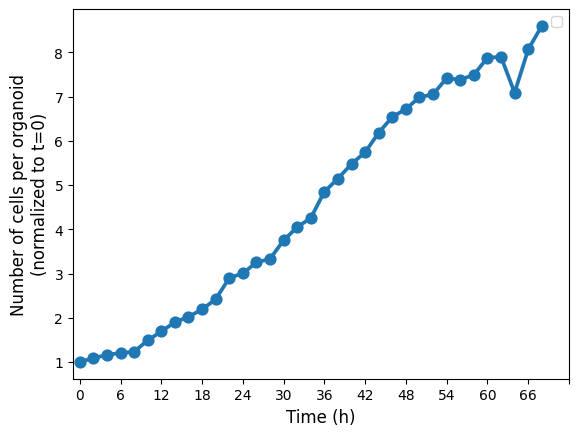

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Count all the cells per time point and organoid
cell_counts = (
    data.groupby(["organoid", "time"])
    .size()
    .reset_index(name="cell_count")
)

for organoid in cell_counts["organoid"].unique():
    organoid_data = cell_counts[cell_counts["organoid"] == organoid]
    t0_count = organoid_data[organoid_data["time"] == 0]["cell_count"].values[0]
    cell_counts.loc[
        cell_counts["organoid"] == organoid, "relative_growth"
    ] = organoid_data["cell_count"] / t0_count

sns.pointplot(
    data=cell_counts,
    x="time",
    y="relative_growth",
)
plt.ylabel("Number of cells per organoid\n(normalized to t=0)", fontsize=12)
plt.xlabel("Time (h)", fontsize=12)
# set x ticks to every 12 hours only
print(np.arange(0, 37, 4))
plt.xticks(np.arange(0, 39, 3))
plt.legend(title="", fontsize=10)
plt.show()

In [2]:
model = load_model(
    r"C:\Users\6331823\Local SSD\Train model cell segmentation\models\cell_segmentation_4"
)

Using CUDA for processing.
loaded custom model: cell_segmentation_4


In [3]:
import napari
from cellpose.utils import stitch3D
import tifffile 
import numpy as np

import sys
import os

# Add parent directory to path
parent_dir = os.path.dirname(os.getcwd())
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
from utils.segment import segment

frame = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Elise\EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_14.47.50_CZC34578YN_F24\cropped\Frame-20.tif"
)

# Select the nuclei channel for segmentation
nuclei_channel = [0,1]
viewer = napari.Viewer(ndisplay=3)

segmentation = []
for nuclei in nuclei_channel:
    frame_nuclei = frame[:, nuclei, :, :]
    segmented_stack = segment(frame_nuclei, model)
    segmented_stack_stitched = stitch3D(segmented_stack)
    segmentation.append(segmented_stack_stitched)

    viewer.add_image(
        frame_nuclei,
        name=f"nuclei_channel_{nuclei}",
        scale=(2.5, 0.64, 0.64),
        blending="additive",
        # contrast_limits=[100, 900],
    )
    viewer.add_labels(
        segmented_stack_stitched,
        name=f"segmented_nuclei_channel_{nuclei}",
        scale=(2.5, 0.64, 0.64),
        blending="additive",
    )

# Combine segmentation of both channels by taking the maximum label at each voxel
combined_segmentation = np.maximum(segmentation[0], segmentation[1])
viewer.add_labels(
    combined_segmentation,
    name="combined_segmentation",
    scale=(2.5, 0.64, 0.64),
    blending="additive",
)

utils package loaded successfully


100%|██████████| 91/91 [00:01<00:00, 54.06it/s]


<Labels layer 'combined_segmentation' at 0x227a3eece10>

In [4]:
import sys
import os

# Add parent directory to path
parent_dir = os.path.dirname(os.getcwd())
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
from utils.segment import segment

frame = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Elise\EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_14.47.50_CZC34578YN_F24\cropped\Frame-20.tif"
)

# Select the nuclei channel for segmentation
nuclei_channel = [0, 1]
viewer = napari.Viewer(ndisplay=3)


frame_nuclei = frame[:, nuclei_channel, :, :]
frame_nuclei = np.max(frame_nuclei, axis=1)  # Max projection if multiple channels
segmented_stack = segment(frame_nuclei, model)
segmented_stack_stitched = stitch3D(segmented_stack)
segmentation.append(segmented_stack_stitched)

viewer.add_image(
    frame_nuclei,
    name=f"nuclei_channel_{nuclei}",
    scale=(2.5, 0.64, 0.64),
    blending="additive",
    # contrast_limits=[100, 900],
)
viewer.add_labels(
    segmented_stack_stitched,
    name=f"segmented_nuclei_channel_{nuclei}",
    scale=(2.5, 0.64, 0.64),
    blending="additive",
)

100%|██████████| 91/91 [00:01<00:00, 53.14it/s]


<Labels layer 'segmented_nuclei_channel_1' at 0x227a44203d0>

In [5]:
import utils
import itertools
import re

props = utils.properties_mask(segmented_stack_stitched)


# Get properties of every cell in the WT and CRC channels at the masked nuclei locations
# We do this on an image where the median value (background) is subtracted from the signal
channel_dfs = {}  # Store channel dataframes during for loop
channel_indices = {"nuclei_wt": 0, "nuclei_crc": 1, "crc": 2}
for ch_name, ch_index in channel_indices.items():
    if ch_name == "nuclei":
        continue  # Skip nuclei because we already got data from that via properties_mask
    frame_ch = frame[:, ch_index, :, :]
    # Do a background subtraction on the image
    offset_ch = utils.offset_image(frame_ch, type="median")
    # Get intensity data of this channel at the locations of the nuclei masks
    df_ch = utils.properties_channel(
        segmented_stack_stitched, offset_ch, ch_name
    )
    channel_dfs[ch_name] = df_ch

# Combine the information of nuclei, WT, and CRC channel into a single dataframe
df_final = props.copy()
for ch_name, df_ch in channel_dfs.items():
    df_final = df_final.merge(df_ch, on="label")

# Add the ratios and log ratios of all combinations to the data frame
channels = [ch.lower() for ch in channel_dfs.keys() if ch.lower() != "nuclei"]
for ch_a, ch_b in itertools.combinations(channels, 2):
    raw_a = f"raw_{ch_a}"
    raw_b = f"raw_{ch_b}"
    ratio_col1 = f"ratio_{ch_a}_{ch_b}"
    log_col1 = f"log_{ratio_col1}"
    ratio_col2 = f"ratio_{ch_b}_{ch_a}"
    log_col2 = f"log_{ratio_col2}"

    df_final[ratio_col1] = df_final.apply(
        lambda row: (row[raw_a] + 1e-6) / (row[raw_b] + 1e-6),
        axis=1,
    )
    df_final[log_col1] = np.log10(df_final[ratio_col1] + 1e-6)
    df_final[ratio_col2] = df_final.apply(
        lambda row: (row[raw_b] + 1e-6) / (row[raw_a] + 1e-6),
        axis=1,
    )
    df_final[log_col2] = np.log10(df_final[ratio_col2] + 1e-6)

In [12]:
df_final["phenotype"] = df_final.apply(
    lambda row: "wt" if row["log_ratio_nuclei_wt_nuclei_crc"] >= 0 else "crc", axis=1)

display(df_final.head())

viewer = napari.Viewer(ndisplay=3)
viewer.add_image(
    frame[:, 0, :, :],
    name="nuclei_wt",
    scale=(2.5, 0.64, 0.64),
    blending="additive",
    contrast_limits=[100, 900],
)
viewer.add_image(
    frame[:, 1, :, :],
    name="nuclei_crc",
    scale=(2.5, 0.64, 0.64),
    blending="additive",
    contrast_limits=[100, 900],
)
wt_labels = df_final[df_final["phenotype"] == "wt"]["label"].values
crc_labels = df_final[df_final["phenotype"] == "crc"]["label"].values
# Create masks containing only WT or CRC cells
wt_segmentation = np.where(
    np.isin(segmented_stack_stitched, wt_labels), segmented_stack_stitched, 0
)
crc_segmentation = np.where(
    np.isin(segmented_stack_stitched, crc_labels), segmented_stack_stitched, 0
)

from vispy.color import Colormap


label_magenta = Colormap([[0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 1.0, 1.0]])
label_green = Colormap([[0.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 1.0]])


viewer.add_labels(
    wt_segmentation,
    name="WT segmentation",
    scale=(2.5, 0.64, 0.64),
    blending="additive",
)
viewer.add_labels(
    crc_segmentation,
    name="CRC segmentation",
    scale=(2.5, 0.64, 0.64),
    blending="additive",
)
viewer.add_image(
    wt_segmentation,
    name="WT segmentation",
    scale=(2.5, 0.64, 0.64),
    blending="additive",
    colormap=("label_magenta", label_magenta),
    contrast_limits=[0, 1],
)
viewer.add_image(
    crc_segmentation,
    name="CRC segmentation",
    scale=(2.5, 0.64, 0.64),
    blending="additive",
    colormap=("label_green", label_green),
    contrast_limits=[0, 1],
)

,label,z,y,x,bounding_box,volume,raw_nuclei_wt,raw_nuclei_crc,raw_crc,ratio_nuclei_wt_nuclei_crc,...,log_ratio_nuclei_crc_nuclei_wt,ratio_nuclei_wt_crc,log_ratio_nuclei_wt_crc,ratio_crc_nuclei_wt,log_ratio_crc_nuclei_wt,ratio_nuclei_crc_crc,log_ratio_nuclei_crc_crc,ratio_crc_nuclei_crc,log_ratio_crc_nuclei_crc,phenotype
0,1,4.040308,235.238293,378.639004,"(0, 225, 370, 9, 246, 388)",1687.0,2.013634,61.780676,17.659158,0.032593,...,1.486872,0.114028,-0.942986,8.769793,0.942989,3.498506,0.543883,0.285836,-0.543881,crc
1,2,2.523929,265.208564,289.200504,"(0, 255, 265, 7, 276, 305)",1985.0,2.193955,63.606549,9.600000,0.034493,...,1.462274,0.228537,-0.641042,4.375659,0.641044,6.625682,0.821231,0.150928,-0.821228,crc
2,3,3.232943,300.245458,284.819136,"(0, 285, 274, 7, 316, 298)",2477.0,2.033912,46.078724,19.329027,0.044140,...,1.355168,0.105226,-0.977874,9.503370,0.977878,2.383913,0.377291,0.419478,-0.377289,crc
3,4,4.053703,304.600622,380.530243,"(0, 291, 369, 9, 326, 396)",3538.0,3.527134,57.498869,22.023742,0.061343,...,1.212237,0.160151,-0.795466,6.244089,0.795469,2.610767,0.416768,0.383029,-0.416767,crc
4,5,3.361367,310.331581,300.416119,"(0, 298, 289, 7, 327, 314)",2283.0,2.309680,48.314060,14.033290,0.047806,...,1.320522,0.164586,-0.783605,6.075856,0.783608,3.442818,0.536914,0.290460,-0.536913,crc


<Image layer 'CRC segmentation [1]' at 0x227c08e6850>

Text(0.5, 0, 'Log Ratio mCherry / iRFP670')

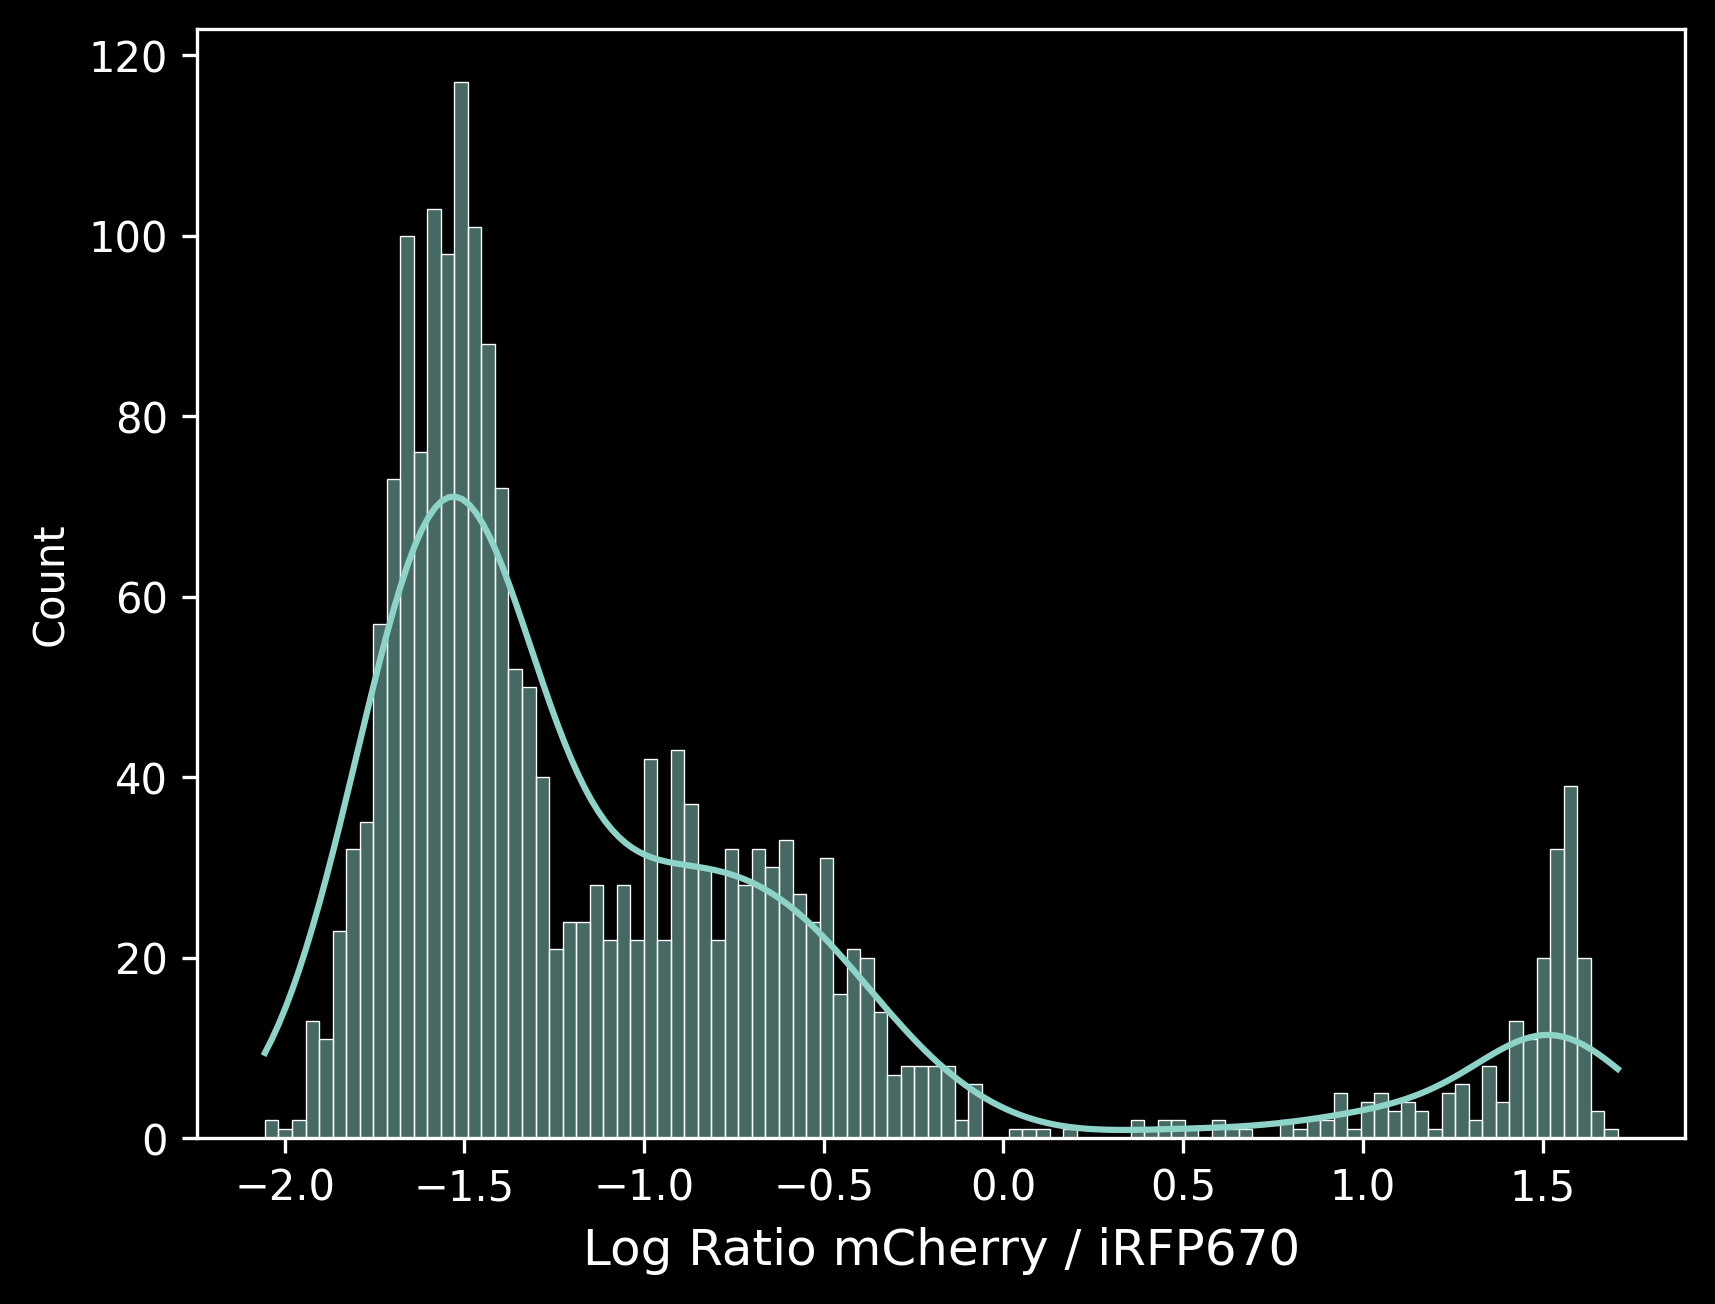

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("dark_background")
plt.figure(dpi=300)

sns.histplot(df_final, x="log_ratio_nuclei_wt_nuclei_crc", bins=100, kde=True)
plt.xlabel("Log Ratio mCherry / iRFP670", fontsize=12)

In [1]:
import napari
import tifffile
import os
import numpy as np
import sys


# Add the parent directory to the Python path
sys.path.insert(0, os.path.dirname(os.getcwd()))

# Now you can import from OSCAR_stitching
from OSCAR_stitching import object_splitter_3D


image = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Elise\EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_14.47.50_CZC34578YN_F24\cropped\Frame-10.tif"
).astype(np.uint16)
image = np.max(image[:, [0, 1], :, :], axis=1)  # Max projection of nuclei channels

labels = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Elise\EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_14.47.50_CZC34578YN_F24\segmented\Frame-10_masks.tif"
).astype(np.uint32)
print(labels.shape)
# labels = tifffile.imread(
#     r"C:\Users\6331823\Local SSD\Data_Anna\Exp140\CRC_Expansion_5\segmented\Frame-10_masks.tif"
# ).astype(np.uint32)
print(labels.shape)

object3D, _, _ = object_splitter_3D(labels, min_z=3, med_z=4, max_z=6)

(92, 528, 606)
(92, 528, 606)
Starting 3D object stitching...


100%|██████████| 91/91 [00:52<00:00,  1.73it/s]


=== Summary ===
Initiators found: 1988
Valid 3D objects: 1435
Objects truncated: 239
Cin/Cout triggers: 449
Pearson-based truncations: 239


In [ ]:
# Add the parent directory to the Python path
import sys
import os
sys.path.insert(0, os.path.dirname(os.getcwd()))
from OSCAR_stitching import create_summary_from_objects, draw_3D_ellipses

# Create summary DataFrame from the validated objects
summary_df = create_summary_from_objects(object3D)
print(f"\nSummary DataFrame:\n{summary_df.head()}")

# Draw the 3D ellipses
stitched = draw_3D_ellipses(
    summary_df=summary_df,  # Use the new summary
    dims=labels.shape,
    label_ellipses=True,
)

viewer = napari.Viewer(ndisplay=3)
viewer.add_image(
    image,
    name="Nuclei Image",
    scale=(2.5, 0.64, 0.64),
    blending="additive",
    contrast_limits=[100, 900],
)
viewer.add_labels(stitched, name="stitched", scale=(2.5, 0.64, 0.64))
viewer.add_labels(labels, name="original", scale=(2.5, 0.64, 0.64))


Summary DataFrame:
   Label     Xcenter     Ycenter  Zcenter          A          B  Vz  \
0      1  246.666667  172.666667      2.5  16.413691  11.900838   6   
1      2  327.333333  202.166667      2.5  13.876699   9.320629   6   
2      3  277.833333  140.833333      3.5  18.811640  16.377139   6   
3      4  249.500000  151.333333      3.5  20.118823  14.502906   6   
4      5  221.666667  165.166667      3.5  24.703735  15.959717   6   

      AngleXY        Vx        Vy         C  
0  115.318251  0.571429 -2.857143  6.670067  
1  119.986516  0.000000  0.714286  6.042367  
2  122.576000  3.571429 -3.285714  7.716931  
3   79.143697 -1.571429 -3.714286  7.229475  
4   91.267371 -2.571429 -2.714286  7.069625  


<Labels layer 'original' at 0x134990eb690>

c:\Users\6331823\AppData\Local\Programs\Python\Python311\Lib\site-packages\napari\layers\labels\labels.py:892: UserWarning: Contours are not displayed during 3D rendering
  warnings.warn(
c:\Users\6331823\AppData\Local\Programs\Python\Python311\Lib\site-packages\napari\layers\labels\labels.py:892: UserWarning: Contours are not displayed during 3D rendering
  warnings.warn(


In [7]:
import subprocess
import tifffile
import numpy as np


def run_julia_oscar(labels, output_path, zparams=[3, 4, 6], nCh=1):
    # Save input
    temp_input = "temp_labels.tif"
    tifffile.imwrite(temp_input, labels.astype(np.uint32))
    output_path_escaped = output_path.replace("\\", "/")

    # Call Julia script
    julia_code = f"""
    include("OSCARv1.6.1.jl")
    using TiffImages
    
    labels = TiffImages.load("{temp_input}")
    objc3d, df = ObjSplitter3D(labels, zparams={zparams}, nCh={nCh})
    summ = summary_objs(objc3d)
    oscar_output = draw_3D_ellipses_from_summary(summ, dims=size(labels))
    
    TiffImages.save("{output_path_escaped}", oscar_output)
    """

    result = subprocess.run(["julia", "-e", julia_code], capture_output=True, text=True)

    if result.returncode != 0:
        print("Julia Error:", result.stderr)
        return None

    # Load output
    return tifffile.imread(output_path)


# Use it
labels = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Elise\EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_14.47.50_CZC34578YN_F24\segmented\Frame-10_masks.tif"
)
oscar_output = run_julia_oscar(labels, r"C:\Users\6331823\Local SSD\Data_Elise\EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_14.47.50_CZC34578YN_F24\Frame-10_oscar_output.tif", zparams=[3, 4, 6])

Julia Error:     Updating registry at `C:\Users\6331823\.julia\registries\General.toml`
   Resolving package versions...
   Installed IndirectArrays â”€ v1.0.0
    Updating `C:\Users\6331823\.julia\environments\v1.12\Project.toml`
  [9b13fd28] + IndirectArrays v1.0.0
    Updating `C:\Users\6331823\.julia\environments\v1.12\Manifest.toml`
  [9b13fd28] + IndirectArrays v1.0.0
Precompiling packages...
    399.3 ms  âœ“ IndirectArrays
  1 dependency successfully precompiled in 0 seconds. 26 already precompiled.
   Resolving package versions...
   Installed OffsetArrays â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€ v1.17.0
   Installed HypergeometricFunctions â”€â”€â”€â”€â”€ v0.3.28
   Installed StatsFuns â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€ v1.5.2
   Installed SciMLPublic â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€ v1.0.0
   Installed FFTW â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€ v1.10.0
   Installed Bootstrap â”€â”€â”€â”€â”€â

In [2]:
import julia
julia.install()


Precompiling PyCall...
Precompiling PyCall... DONE
PyCall is installed and built successfully.


In [1]:
from julia import Main
import tifffile

# One-time setup
Main.include("miscellaneous/OSCARv1.6.1.jl")
Main.eval("using TiffImages")


def run_julia_oscar(labels, zparams=[3, 4, 6]):
    # Save input
    temp_input = "temp_labels.tif"
    tifffile.imwrite(temp_input, labels.astype(np.uint32))

    # Call Julia functions directly
    Main.labels = Main.TiffImages.load(temp_input)
    Main.objc3d, Main.df = Main.ObjSplitter3D(Main.labels, zparams=zparams, nCh=1)
    Main.summ = Main.summary_objs(Main.objc3d)
    Main.oscar_output = Main.draw_3D_ellipses_from_summary(
        Main.summ, dims=Main.size(Main.labels)
    )
    return Main.oscar_output

oscar_output = run_julia_oscar(
    labels,
    zparams=[3, 4, 6],
)
tifffile.imwrite(r"C:\Users\6331823\Local SSD\Data_Elise\EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_14.47.50_CZC34578YN_F24\Frame-10_oscar_output.tif", oscar_output)


JuliaError: Exception 'InitError' occurred while calling julia code:
const PyCall = Base.require(Base.PkgId(Base.UUID("438e738f-606a-5dbb-bf0a-cddfbfd45ab0"), "PyCall"))

In [2]:
import napari
import tifffile
from skimage import measure
import numpy as np

viewer = napari.Viewer(ndisplay=3)
image = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Elise\EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_14.47.50_CZC34578YN_F24\cropped\Frame-10.tif"
).astype(np.uint16)
labels = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Elise\EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_14.47.50_CZC34578YN_F24\Frame-10_oscar_output.tif"
)
labels = (labels * 1000).astype(np.uint32)
mario = tifffile.imread(r"C:\Users\6331823\Downloads\Frame-10_masks_Stack_Total.tif")
own_segmentation = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Elise\EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_14.47.50_CZC34578YN_F24\segmented\Frame-10_masks.tif"
)

image = np.max(image[:, [0, 1], :, :], axis=1)  # Max projection of nuclei channels
viewer.add_labels(
    labels,
    name="OSCAR Output",
    scale=(2.5, 0.64, 0.64),
    blending="additive",
)
viewer.add_image(
    image,
    name="image",
    scale=(2.5, 0.64, 0.64),
    blending="additive",
)
viewer.add_labels(
    mario,
    name="Mario Output",
    scale=(2.5, 0.64, 0.64),
    blending="additive",
)
viewer.add_labels(
    own_segmentation,
    name="Own Segmentation",
    scale=(2.5, 0.64, 0.64),
    blending="additive",
)

<Labels layer 'Own Segmentation' at 0x2719478a250>

In [19]:
import subprocess
from pathlib import Path


def run_julia_oscar(input_path, output_path, zparams=[3, 4, 6]):
    """Run OSCAR segmentation using Julia script."""

    julia_script ="test.jl"

    cmd = [
        "julia",
        str(julia_script),
        str(input_path),
        str(output_path),
        str(zparams[0]),
        str(zparams[1]),
        str(zparams[2]),
    ]

    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode != 0:
        print("Julia stdout:", result.stdout)
        print("Julia stderr:", result.stderr)
        raise RuntimeError(f"Julia failed with return code {result.returncode}")

    print(result.stdout)
    return output_path


# Test it
input_path = r"C:\Users\6331823\Local SSD\Data_Elise\EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_14.47.50_CZC34578YN_F24\segmented\Frame-10_masks.csv"
output_path = r"C:\Users\6331823\Local SSD\Data_Elise\EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_14.47.50_CZC34578YN_F24\Frame-10_oscar_output.tif"

run_julia_oscar(input_path, output_path, zparams=[3, 4, 6])
print("Done!")

Julia stdout: Running OSCAR segmentation with zparams=[3, 4, 6], nCh=1, kernel=6.0

Julia stderr: ERROR: LoadError: ArgumentError: No file exists at given path: C:\Users\6331823\Local SSD\Data_Elise\EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_14.47.50_CZC34578YN_F24\segmented\Frame-10_masks.csv
Stacktrace:
 [1] checkpath_load
   @ C:\Users\6331823\.julia\packages\FileIO\EI2b8\src\loadsave.jl:167 [inlined]
 [2] load(::String; options::@Kwargs{})
   @ FileIO C:\Users\6331823\.julia\packages\FileIO\EI2b8\src\loadsave.jl:110
 [3] load
   @ C:\Users\6331823\.julia\packages\FileIO\EI2b8\src\loadsave.jl:109 [inlined]
 [4] run_oscar_segmentation(input_path::String, output_path::String, zparams::Vector{Int64}, nCh::Int64, kernel::Float64)
   @ Main c:\Users\6331823\Local SSD\Coding projects\organoid_segmenter\miscellaneous\test.jl:17
 [5] run_oscar_segmentation(input_path::String, output_path::String, zparams::Vector{Int64}, nCh::Int64)
   @ Main c:\Users\6331823\Local SSD\Coding projects\orga

RuntimeError: Julia failed with return code 1

In [48]:
import tifffile
import napari

image = tifffile.imread(
    r"C:\Users\6331823\Local SSD\20251205_Dual_nuclei\20251205_Mix-3\cropped\Frame-30.tif"
)
labels = tifffile.imread(r"C:\Users\6331823\Local SSD\20251205_Dual_nuclei\20251205_Mix-3\segmented\Frame-30_masks.tif")

crc = image[:, 0, :, :]
wt = image[:, 1, :, :]

viewer = napari.Viewer(ndisplay=3)
viewer.add_image(
    crc,
    name="CRC nuclei",
    scale=(2.5, 0.64, 0.64),
    blending="additive",
    contrast_limits=[100, 1500],
    colormap="lime"
)
viewer.add_image(
    wt,
    name="WT nuclei",
    scale=(2.5, 0.64, 0.64),
    blending="additive",
    contrast_limits=[100, 1500],
    colormap="magenta"
)
viewer.add_labels(
    labels,
    name="segmented nuclei",
    scale=(2.5, 0.64, 0.64),
    blending="additive",
)

<Labels layer 'segmented nuclei' at 0x24b57753650>

In [55]:
import numpy as np  

image = tifffile.imread(
    r"C:\Users\6331823\Local SSD\20251205_Dual_nuclei\20251205_Mix-3\cropped\Frame-10.tif"
)
image = image[11:76]
nuclei = np.max(image, axis = 1)
no_background = [image[z] - (np.median(nuclei) + 15) for z in range(nuclei.shape[0])]
no_background = np.stack(no_background, axis=0)
# no_background = []
# for z in range(nuclei.shape[0]):
#     slice = nuclei[z]
#     background = np.median(slice) + 50
#     no_background.append(slice - background)
# no_background = np.stack(no_background, axis=0)
# get 95th percentile of each z slice
max_values = [np.percentile(no_background[z], 99) for z in range(no_background.shape[0])] # but if negative make 0
print(max_values)
ratios = [np.max(max_values) / max_values[z] if max_values[z] > 0 else 0 for z in range(no_background.shape[0])]
print(ratios)

new_image = []
for z in range(image.shape[0]):
    new_image.append(no_background[z] * ratios[z])
new_image = np.stack(new_image, axis=0)
print(new_image.shape)


viewer = napari.Viewer(ndisplay=3)
viewer.add_image(
    new_image[:, 0, :, :],
    name="crc",
    scale=(2.5, 0.64, 0.64),
    blending="additive",
    contrast_limits=[100, 1500],
)
viewer.add_image(
    new_image[:, 1, :, :],
    name="wt",
    scale=(2.5, 0.64, 0.64),
    blending="additive",
    contrast_limits=[100, 1500],
)

[11.0, 14.0, 16.0, 21.0, 27.0, 33.0, 42.0, 51.0, 65.0, 82.0, 105.0, 131.0, 165.0, 206.0, 259.0, 321.0, 391.0, 453.0, 501.63000000000466, 528.6300000000047, 544.0, 551.0, 528.6300000000047, 483.63000000000466, 446.0, 402.0, 371.0, 336.0, 317.0, 338.63000000000466, 344.0, 335.0, 323.0, 304.0, 271.0, 234.0, 198.0, 156.0, 118.0, 84.0, 57.0, 35.0, 20.0, 11.0, 6.0, 2.0, -1.0, -2.0, -4.0]
[50.09090909090909, 39.357142857142854, 34.4375, 26.238095238095237, 20.40740740740741, 16.696969696969695, 13.119047619047619, 10.803921568627452, 8.476923076923077, 6.719512195121951, 5.247619047619048, 4.206106870229007, 3.3393939393939394, 2.674757281553398, 2.1274131274131274, 1.7165109034267914, 1.4092071611253196, 1.216335540838852, 1.0984191535593861, 1.0423169324480168, 1.0128676470588236, 1.0, 1.0423169324480168, 1.1393007050844544, 1.2354260089686098, 1.3706467661691542, 1.4851752021563343, 1.6398809523809523, 1.7381703470031546, 1.6271446711750064, 1.6017441860465116, 1.644776119402985, 1.7058823

<Image layer 'wt' at 0x24d2062e650>

In [67]:
from scipy import ndimage
image = tifffile.imread(
    r"C:\Users\6331823\Local SSD\20251205_Dual_nuclei\20251205_Mix-3\cropped\Frame-30.tif"
)
print(np.median(image))
print(np.median(np.max(image, axis=0)))

blur = ndimage.gaussian_filter(image, sigma=(2, 0, 2, 2))
print(np.median(blur))
print(np.median(np.max(blur, axis=0)))
no_background = blur - (np.median(blur) + 100)
no_background[no_background < 0] = 0

max_values = [
    np.percentile(background_removed[z], 99) for z in range(background_removed.shape[0])
]  # but if negative make 0
print(max_values)
ratios = [
    np.max(max_values) / max_values[z] if max_values[z] > 0 else 0
    for z in range(background_removed.shape[0])
]
print(ratios)

new_image = []
for z in range(background_removed.shape[0]):
    new_image.append(background_removed[z] * ratios[z])
new_image = np.stack(new_image, axis=0)
print(new_image.shape)

background_removed = np.where(no_background > 0, image, 0)
viewer = napari.Viewer(ndisplay=3)
viewer.add_image(image[:,0], name="original", scale=(2.5, 0.64, 0.64), blending="additive")
viewer.add_image(blur[:,0], name="blurred", scale=(2.5, 0.64, 0.64), blending="additive")
viewer.add_image(no_background[:,0], name="no background", scale=(2.5, 0.64, 0.64), blending="additive")
viewer.add_image(
    background_removed[:, 0],
    name="background removed",
    scale=(2.5, 0.64, 0.64),
    blending="additive",
)
viewer.add_image(
    new_image[:, 0],
    name="corrected",
    scale=(2.5, 0.64, 0.64),
    blending="additive",
)
viewer.add_image(
    new_image[:, 1],
    name="corrected wt",
    scale=(2.5, 0.64, 0.64),
    blending="additive",
)

109.0
128.0
111.0
114.0
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 208.0, 248.0, 282.0, 305.0, 311.0, 317.0, 326.0, 339.0, 352.0, 358.0, 365.0, 375.0, 390.0100000000093, 406.0, 422.0, 435.0, 455.0, 472.0, 483.0, 487.0, 503.0, 515.0, 523.0, 530.0, 538.0, 547.0, 558.0, 562.0, 555.0, 551.0, 544.0, 532.0, 518.0, 500.0, 481.0, 451.0, 420.0, 386.0, 349.0, 320.0, 299.0, 278.0, 263.0, 251.0, 242.0, 238.0, 232.0, 217.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2.701923076923077, 2.2661290322580645, 1.9929078014184398, 1.842622950819672, 1.8070739549839228, 1.772870662460568, 1.7239263803680982, 1.6578171091445428, 1.5965909090909092, 1.5698324022346368, 1.5397260273972602, 1.4986666666666666, 1.4409886925975912, 1.3842364532019704, 1.3317535545023698, 1.2919540229885058, 1.2351648351648352, 1.1906779661016949, 1.1635610766045548, 1.1540041067761806, 1.117296222664016, 1.091262135

<Image layer 'corrected wt' at 0x24e073c2a50>

---------------------------------------------------------------------------
TypeError                                 Traceback (most recent call last)
File c:\Users\6331823\AppData\Local\Programs\Python\Python311\Lib\site-packages\napari\_qt\threads\status_checker.py:126, in StatusChecker.calculate_status(self=<napari._qt.threads.status_checker.StatusChecker object>)
    122     return
    124 try:
    125     # Calculate the status change from cursor's movement
--> 126     res = viewer._calc_status_from_cursor()
        viewer = Viewer(camera=Camera(center=(95.0, 124.48, 167.68), zoom=4.400098816241072, angles=(-11.579723047986402, 35.209185673811824, -168.49153445333724), perspective=0.0, mouse_pan=True, mouse_zoom=True, orientation=(<DepthAxisOrientation.TOWARDS: 'towards'>, <VerticalAxisOrientation.DOWN: 'down'>, <HorizontalAxisOrientation.RIGHT: 'right'>)), cursor=Cursor(position=(201.7718879101914, 167.62836461616251, 157.90401506367846), scaled=True, style=<CursorStyle.STANDARD

In [9]:
import tifffile
import cv2
import napari
import numpy as np
from scipy import ndimage


def find_touching_labels(slice_mask):
    """Find pairs of labels that are touching (adjacent) in a 2D slice."""
    # Dilate each label by 1 pixel and check for overlaps
    unique_labels = np.unique(slice_mask)
    unique_labels = unique_labels[unique_labels != 0]  # Remove background

    touching_labels = set()

    for label in unique_labels:
        # Create binary mask for this label
        mask = (slice_mask == label).astype(np.uint8)
        # Dilate by 1 pixel
        dilated = cv2.dilate(mask, kernel=np.ones((3, 3), np.uint8), iterations=1)
        # Find which other labels overlap with dilated mask
        overlap_region = dilated > 0
        overlapping_labels = np.unique(slice_mask[overlap_region])
        # Remove self and background
        overlapping_labels = overlapping_labels[
            (overlapping_labels != label) & (overlapping_labels != 0)
        ]

        if len(overlapping_labels) > 0:
            touching_labels.add(label)

    return touching_labels


# Your original code with touching detection
image = tifffile.imread(
    r"C:/Users/6331823/Local SSD/Data_Elise/EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_14.47.50_CZC34578YN_F24/segmented/Frame-10_masks.tif"
)

eroded_image = np.zeros_like(image)
for z in range(image.shape[0]):
    slice = image[z]

    # Find which labels are touching in this slice
    touching_labels = find_touching_labels(slice)

    unique_labels = np.unique(slice)
    eroded_slice = np.zeros_like(slice)

    for label in unique_labels:
        if label == 0:
            continue

        mask = (slice == label).astype(np.uint8)

        # Only erode if this label is touching another label
        if label in touching_labels:
            eroded_mask = cv2.erode(
                mask, kernel=np.ones((3, 3), np.uint8), iterations=1
            )
            eroded_slice[eroded_mask == 1] = label
        else:
            # Keep original mask if not touching
            eroded_slice[mask == 1] = label

    eroded_image[z] = eroded_slice

# binarize image and save
binarized = (eroded_image > 0).astype(np.uint8)

# viewer = napari.Viewer(ndisplay=3)
# viewer.add_labels(image, name="original", scale=(2.5, 0.64, 0.64), blending="additive")
# viewer.add_labels(
#     eroded_image,
#     name="eroded (touching only)",
#     scale=(2.5, 0.64, 0.64),
#     blending="additive",
# )
# viewer.add_labels(
#     binarized,
#     name="binarized eroded",
#     scale=(2.5, 0.64, 0.64),
#     blending="additive",
# )


tifffile.imwrite(
    r"C:/Users/6331823/Local SSD/Data_Elise/EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_14.47.50_CZC34578YN_F24/Frame-10_masks_binarized.tif",
    binarized,
    compression="zlib",
    compressionargs={"level": 8},
)

In [10]:
viewer = napari.Viewer(ndisplay=3)

labels = tifffile.imread(r"C:/Users/6331823/Local SSD/Data_Elise/EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_14.47.50_CZC34578YN_F24/Frame-10_oscar_output_new.tif")
# give every unique value a new integer label
unique_labels = np.unique(labels)
label_mapping = {old_label: new_label for new_label, old_label in enumerate(unique_labels)}
labels = np.vectorize(label_mapping.get)(labels).astype(np.uint32)
# viewer.add_labels(
#     labels,
#     name="OSCAR Output",
#     scale=(2.5, 0.64, 0.64),
#     blending="additive",
# )
# viewer.add_labels(image, name="original", scale=(2.5, 0.64, 0.64), blending="additive")

tifffile.imwrite(
    r"C:/Users/6331823/Local SSD/Data_Elise/EM_Exp007_Imaging_20x_2025-11-21_Maria_Elise_14.47.50_CZC34578YN_F24/Frame-10_OSCAR_output_new.tif",
    labels,
    compression="zlib",
    compressionargs={"level": 8},
)

In [11]:
def pad_to_shape(array, target_shape):
    pad_width = []
    for dim, target in zip(array.shape, target_shape):
        total_pad = target - dim
        pad_before = total_pad // 2
        pad_after = total_pad - pad_before
        pad_width.append((pad_before, pad_after))
    return np.pad(array, pad_width, mode="constant", constant_values=0)

In [45]:
import tifffile
import os
import pandas as pd
import numpy as np

input_directory = r"E:\elise"


timepoints = 18

for dir in os.listdir(input_directory):
    print(f"Processing directory: {dir}")
    if dir == "TL2_Imaging_20x_F19":
        print("Skipping directory TL2_Imaging_20x_F19")
        continue
    sample_dir = os.path.join(input_directory, dir)
    segmentation_dir = os.path.join(sample_dir, "segmented")
    properties_dir = os.path.join(sample_dir, "properties")

    primary_movie = []
    enriched_movie = []

    for timepoint in range(timepoints):
        segmentation = tifffile.imread(
            os.path.join(segmentation_dir, f"Frame-{timepoint}_masks.tif")
        )
        properties = pd.read_csv(
            os.path.join(properties_dir, f"Frame-{timepoint}_props.csv")
        )
        enriched_segmentation = np.zeros_like(segmentation)
        primary_segmentation = np.zeros_like(segmentation)
        for _, row in properties.iterrows():
            label = row["label"]
            phenotype = row["phenotype"]
            if phenotype == "wt":
                enriched_segmentation[segmentation == label] = label

            elif phenotype == "crc":
                primary_segmentation[segmentation == label] = label
        primary_movie.append(primary_segmentation)
        enriched_movie.append(enriched_segmentation)



    max_dims = [0, 0, 0]
    movie_primary_padded = []


    for frame in range(timepoints):
        image = primary_movie[frame]
        movie_primary_padded.append(image)
        for i in range(3):
            max_dims[i] = max(max_dims[i], image.shape[i])

    # Pad all frames
    movie_primary_padded = [pad_to_shape(frame, max_dims) for frame in movie_primary_padded]

    max_dims = [0, 0, 0]
    movie_enriched_padded = []
    for frame in range(timepoints):
        image = enriched_movie[frame]
        movie_enriched_padded.append(image)
        for i in range(3):
            max_dims[i] = max(max_dims[i], image.shape[i])

    # Pad all frames
    movie_enriched_padded = [pad_to_shape(frame, max_dims) for frame in movie_enriched_padded]
    movie_primary_padded = np.stack(movie_primary_padded, axis=0).astype(np.uint16)
    movie_enriched_padded = np.stack(movie_enriched_padded, axis=0).astype(np.uint16)

    tifffile.imwrite(
        os.path.join(sample_dir, f"Movie_primary.tif"),
        movie_primary_padded,
        metadata={"axes": "TZYX"},
        imagej=True,
        compression="zlib",
        compressionargs={"level": 8},
    )
    tifffile.imwrite(
        os.path.join(sample_dir, f"Movie_enriched.tif"),
        movie_enriched_padded,
        metadata={"axes": "TZYX"},
        imagej=True,
        compression="zlib",
        compressionargs={"level": 8},
    )


Processing directory: TL2_Imaging_20x_F44
Processing directory: TL2_Imaging_20x_F01
Processing directory: TL2_Imaging_20x_F02
Processing directory: TL2_Imaging_20x_F13
Processing directory: TL2_Imaging_20x_F16
Processing directory: TL2_Imaging_20x_F18
Processing directory: TL2_Imaging_20x_F19
Skipping directory TL2_Imaging_20x_F19
Processing directory: TL2_Imaging_20x_F22
Processing directory: TL2_Imaging_20x_F24
Processing directory: TL2_Imaging_20x_F26
Processing directory: TL2_Imaging_20x_F28
Processing directory: TL2_Imaging_20x_F29
Processing directory: TL2_Imaging_20x_F30
Processing directory: TL2_Imaging_20x_F38
Processing directory: summary_results.csv


FileNotFoundError: [Errno 2] No such file or directory: 'E:\\elise\\summary_results.csv\\segmented\\Frame-0_masks.tif'

In [6]:
from imaris_ims_file_reader import ims
import tifffile
import os
import napari
import numpy as np
from napari_animation import Animation

# Create a magenta colormap for labels
# 0 = black (transparent), all others = magenta

input_dir = r"E:\elise\TL2_Imaging_20x_F30"
movie = ims(os.path.join(input_dir, "TL2_Imaging_20x_F30_cropped.ims"))
enriched = tifffile.imread(os.path.join(input_dir, "Movie_enriched.tif"))
primary = tifffile.imread(os.path.join(input_dir, "Movie_primary.tif"))
enriched_binary = np.where(enriched > 0, 1, 0).astype(np.uint16)
primary_binary = np.where(primary > 0, 1, 0).astype(np.uint16)

magenta_cmap = {0: (0, 0, 0, 0), 1: (1, 0, 1, 1)}  # black, magenta
cyan_cmap = {0: (0, 0, 0, 0), 1: (0, 1, 1, 1)}  # black, cyan
magenta_colors = [[0, 0, 0, 0], [1, 0, 1, 1]]  # 0=transparent, 1=magenta
cyan_colors = [[0, 0, 0, 0], [0, 1, 1, 1]]  # 0=transparent, 1=cyan

viewer = napari.Viewer(ndisplay=3)
viewer.add_image(
    movie[:, 1, :, :, :],
    name="nuclei_primary",
    scale=(2.5, 0.64, 0.64),
    blending="additive",
    contrast_limits=[100, 350],
    colormap="magenta"
)
# viewer.add_image(enriched_binary, name="enriched_binary", scale=(2.5, 0.64, 0.64), blending="additive")
viewer.add_image(
    movie[:, 0, :, :, :],
    name="nuclei_enriched",
    scale=(2.5, 0.64, 0.64),
    blending="additive",
    contrast_limits=[100, 350],
    colormap="cyan"
)
viewer.add_labels(
    primary_binary,
    name="segmented_primary",
    scale=(2.5, 0.64, 0.64),
    blending="opaque",
    colormap=magenta_colors
)
viewer.add_labels(
    enriched_binary,
    name="segmented_enriched",
    scale=(2.5, 0.64, 0.64),
    blending="opaque",
    colormap=cyan_colors
)
viewer.add_labels(
    primary,
    name="segmented_primary_labels",
    scale=(2.5, 0.64, 0.64),
    blending="opaque",
)
viewer.add_labels(
    enriched,
    name="segmented_enriched_labels",
    scale=(2.5, 0.64, 0.64),
    blending="opaque",
)

# Create animation
animation = Animation(viewer)
viewer.layers["segmented_primary"].visible = False
viewer.layers["segmented_enriched"].visible = False
viewer.layers["nuclei_primary"].visible = False
viewer.layers["nuclei_enriched"].visible = False
n_frames = enriched.shape[0]
n_steps = 18  # total keyframes for each direction
# original = Labels._update_thumbnail
angle_offset = 0
# Forward sweep
for i in range(n_steps):
    frame = int(i * n_frames / n_steps)
    angle = angle_offset + i * 360 / n_steps
    viewer.dims.set_point(0, frame)
    viewer.camera.angles = (angle, 30)
    # Labels._update_thumbnail = lambda self: None
    animation.capture_keyframe()
    angle_offset += 360

    # Export animation
animation.animate(filename=os.path.join(input_dir, "labels_individual.mp4"), fps=30)

# animation = Animation(viewer)
# viewer.layers["nuclei_primary"].visible = False
# viewer.layers["nuclei_enriched"].visible = False
# viewer.layers["segmented_primary"].visible = True
# viewer.layers["segmented_enriched"].visible = True

# for i in range(n_steps):
#     frame = int(i * n_frames / n_steps)
#     angle = angle_offset + i * 360 / n_steps
#     viewer.dims.set_point(0, frame)
#     viewer.camera.angles = (angle, 30)
#     # Labels._update_thumbnail = lambda self: None
#     animation.capture_keyframe()
#     angle_offset += 360

# Export animation
# animation.animate(filename=os.path.join(input_dir, "label_data.mp4"), fps=30)

Opening readonly file: E:\elise\TL2_Imaging_20x_F30\TL2_Imaging_20x_F30_cropped.ims 

Closing file: E:\elise\TL2_Imaging_20x_F30\TL2_Imaging_20x_F30_cropped.ims 

Rendering frames...


100%|██████████| 256/256 [00:12<00:00, 20.34it/s]


In [ ]:
import napari
import numpy as np
from napari_animation import Animation
from napari.layers import Labels

# Create viewer
viewer = napari.Viewer(ndisplay=3)

# Add all layers
viewer.add_image(
    padded[:, 0].astype(np.uint16),
    name="WT",
    scale=(1, 8, 1, 1),
    colormap="magenta",
    blending="additive",
    contrast_limits=(100, 500),
    visible=False,
)

viewer.add_image(
    padded[:, 1].astype(np.uint16),
    name="CRC",
    scale=(1, 8, 1, 1),
    colormap="green",
    blending="additive",
    contrast_limits=(150, 250),
    visible=False,
)

viewer.add_image(
    padded[:, 2].astype(np.uint16),
    name="Nuclei",
    scale=(1, 8, 1, 1),
    colormap="blue",
    blending="additive",
    contrast_limits=(120, 200),
)

viewer.add_labels(
    labeled,
    name="Labeled",
    scale=(1, 8, 1, 1),
    colormap=["black", "lime", "magenta"],
    blending="additive",
    visible=False,
)

viewer.add_labels(
    collapsed,
    name="Segmented Nuclei",
    colormap=["black", "blue"],
    scale=(1, 8, 1, 1),
    blending="additive",
    visible=False,
)

# Create animation
animation = Animation(viewer)

n_frames = padded.shape[0]
n_steps = 9  # total keyframes for each direction
original = Labels._update_thumbnail
angle_offset = 0
# Forward sweep
for i in range(n_steps):
    frame = int(i * n_frames / n_steps)
    angle = angle_offset + i * 360 / n_steps
    viewer.dims.set_point(0, frame)
    viewer.camera.angles = (angle, 30)
    Labels._update_thumbnail = lambda self: None
    animation.capture_keyframe()
    angle_offset += 360

    # Export animation
animation.animate(filename=r"C:\Users\6331823\Downloads\top_left.mp4", fps=30)

animation = Animation(viewer)
viewer.layers["Segmented Nuclei"].visible = True
viewer.layers["Nuclei"].visible = False

for i in range(n_steps):
    frame = int(i * n_frames / n_steps)
    angle = angle_offset + i * 360 / n_steps
    viewer.dims.set_point(0, frame)
    viewer.camera.angles = (angle, 30)
    Labels._update_thumbnail = lambda self: None
    animation.capture_keyframe()
    angle_offset += 360

    # Export animation
animation.animate(filename=r"C:\Users\6331823\Downloads\top_right.mp4", fps=30)

animation = Animation(viewer)
viewer.layers["WT"].visible = True
viewer.layers["CRC"].visible = True

for i in range(n_steps):
    frame = int(i * n_frames / n_steps)
    angle = angle_offset + i * 360 / n_steps
    viewer.dims.set_point(0, frame)
    viewer.camera.angles = (angle, 30)
    Labels._update_thumbnail = lambda self: None
    animation.capture_keyframe()
    angle_offset += 360

    # Export animation
animation.animate(filename=r"C:\Users\6331823\Downloads\bottom_left.mp4", fps=30)
animation = Animation(viewer)
viewer.layers["Segmented Nuclei"].visible = False
viewer.layers["Labeled"].visible = True
viewer.layers["WT"].visible = False
viewer.layers["CRC"].visible = False
for i in range(n_steps):
    frame = int(i * n_frames / n_steps)
    angle = angle_offset + i * 360 / n_steps
    viewer.dims.set_point(0, frame)
    viewer.camera.angles = (angle, 30)
    Labels._update_thumbnail = lambda self: None
    animation.capture_keyframe()
    angle_offset += 360

    # Export animation
animation.animate(filename=r"C:\Users\6331823\Downloads\bottom_right.mp4", fps=30)


viewer.close_all()